In [1]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import torch
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
from sklearn.metrics import RocCurveDisplay
from statsmodels.stats.multitest import fdrcorrection
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
from shap.plots import colors
from typing import Optional

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


# CREATE DATAFRAME WITH TRAIN PARAMETER COMBINATIONS FOR SLURM PARALLEL COMPUTING

In [36]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                          'tb20_21_22_2908_pats_7_vars_relapse':{
                            'result_cat':'RELAPSE',
                            'fn':'tb20_21_22_2908_pats_7_vars_relapse',
                           'include_rifaquin':True},

                        'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                        'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},
                         
                        'tb21_22_2984_pats_22_vars_relapse_basic_vars':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},
                         
                        'tb21_22_2263_pats_24_vars_relapse':{
                            'fn':'tb21_22_2263_pats_24_vars_relapse',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_with_adherence':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_with_adherence':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
  

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                         'tb21_22_2984_pats_22_vars_raw_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'raw_pred_prob_norm'},
                         
                        'tb21_22_2984_pats_22_vars_llm_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'llm_pred_prob_norm'},
                         
                        }


#dataset_names=[*parameters_for_analysis][:2] + [*parameters_for_analysis][3:4] + [*parameters_for_analysis][5:6]
dataset_names=[*parameters_for_analysis][6:8]
period_end_days=['baseline',31,62,93,125,160,'all'][:]
training_data_types=['all_days_in_period','last_therapy_day'][:]
model_names=['XGBoost','LogisticRegression'][1:]

#Create all combinations of the lists
combinations = list(itertools.product(dataset_names,model_names,period_end_days, training_data_types))

# Create the dataframe
df = pd.DataFrame(combinations, columns=['dataset_names','model_names','period_end_days', 'training_data_types'])

# Add a column for the row number
df['ArrayTaskID'] = range(1, len(df) + 1)

print(dataset_names)
file_path = "raw_data_train_param_combinations.tsv"
df.to_csv(file_path, sep='\t', index=False)
df#[df['ArrayTaskID']>200]

['tb21_22_2984_pats_22_vars_relapse_without_dr_reg', 'tb21_22_2984_pats_22_vars_relapse_basic_vars']


,dataset_names,model_names,period_end_days,training_data_types,ArrayTaskID
0,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,baseline,all_days_in_period,1
1,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,baseline,last_therapy_day,2
2,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,31,all_days_in_period,3
3,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,31,last_therapy_day,4
4,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,62,all_days_in_period,5
5,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,62,last_therapy_day,6
6,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,93,all_days_in_period,7
7,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,93,last_therapy_day,8
8,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,125,all_days_in_period,9
9,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,125,last_therapy_day,10


In [ ]:
[*parameters_for_analysis][6:7]

# DEFINE DATASET NAMES + FUNCTIONS

In [24]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                         'tb20_21_22_2908_pats_7_vars_relapse':{
                            'result_cat':'RELAPSE',
                            'fn':'tb20_21_22_2908_pats_7_vars_relapse',
                           'include_rifaquin':True},

                        'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'pat_ids_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'}, 

                         
                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'pat_ids_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_basic_vars':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},
                         
                        'tb21_22_2263_pats_24_vars_relapse':{
                            'fn':'tb21_22_2263_pats_24_vars_relapse',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_with_adherence':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_with_adherence':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
  

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                         'tb21_22_2984_pats_22_vars_raw_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'raw_pred_prob_norm'},
                         
                        'tb21_22_2984_pats_22_vars_llm_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'llm_pred_prob_norm'},
                         
                        }





'''
                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         
                         }
'''

'''
 'tb21_1405_pats_40_vars_relapse_MGIT_LJ_disc':{
    'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
    'result_cat':'RELAPSE'},
'''
###===================
def load_merged_data_of_lab_vars():
    #load patient IDs who are considered in this  analysis
    pat_id_df=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
    # get all pat ids
    all_ids=pat_id_df['USUBJID'].to_list()

    fname='merged_df.csv.gz'
    
    fn=os.path.join('../data/',fname)
    merged_df=pd.read_csv(fn,low_memory=False,index_col=0)

    return merged_df

###===================
def return_race_dict():
    data=load_merged_data_of_lab_vars()
    race_df=data.drop_duplicates(subset=['USUBJID'])[['USUBJID','STUDYID','RACE']]
    race_df.loc[race_df['STUDYID']=='TB-1022','RACE']='BLACK'
    race_dict=race_df.set_index('USUBJID')['RACE'].to_dict()

    return race_dict

##=========================================
## SCALE TRAINING AND TESTING DATA WITH A STANDARD SCALER TRAINED ON THE TRAINING DATA
def scale_by_training_data(X_train, X_test):
    from sklearn.preprocessing import StandardScaler

    ## Standardise non-binary numerical columns ==> select numerical columns and drop columns already scaled
    numerical_cols=X_train.select_dtypes(exclude=['object'])
    non_binary_num_cols = []

    for col in numerical_cols.columns:
        unique_values = np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)


    if len(non_binary_num_cols)>0:

        #print((X_train==np.inf).any())
        std_scaler = StandardScaler()
        std_scaler.fit(X_train.loc[:,non_binary_num_cols])
        X_train.loc[:,non_binary_num_cols]=std_scaler.transform(X_train.loc[:,non_binary_num_cols])
        X_test.loc[:,non_binary_num_cols]=std_scaler.transform(X_test.loc[:,non_binary_num_cols])

        #X_train.loc[:,non_binary_num_cols]=(StandardScaler().fit_transform(X_train.loc[:,non_binary_num_cols]))

        '''        
        ## As DAY colum,n also gets standardised, transform the training_days number as well, in order to susbet the
        #  data to training-testing set
        std_scaler = StandardScaler()
        std_scaler.fit(X.loc[:, 'DAY'].values.reshape(-1, 1))
        std_training_days = std_scaler.transform([[training_days]])
        '''

    return (X_train, X_test)


##=========================================
## 
def backward_fill_and_extract_vars_at_baseline(X_subset,columns_to_drop):

    ## Extract columns selected for input 
    final_cols=X_subset.drop(columns=columns_to_drop).columns.tolist()

    ## For each final variable, check the number of  patiens who have only missing values in the first month.
    #. If a variable has a high relative missing rate in the first month across the patients (>0.1, i.e. missing for more than 10 % of patients),
    #. don't backfill that variable 
    num_of_pats_with_missing_vars_in_first_month=X_subset[['DAY']+final_cols].sort_values('DAY').groupby('USUBJID').apply(lambda x:x.loc[x['DAY']<31,:].isna().all()).sum().sort_values()
    num_of_pats_with_missing_vars_in_first_month_=num_of_pats_with_missing_vars_in_first_month/X_subset['USUBJID'].unique().shape[0]
    vars_to_backfill = num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_<=0.05].index.tolist()
    vars_not_to_backfill = num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_>0.0].index.tolist()


    #print('num_of_pats_with_missing_vars_in_first_month_',num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_>0])

    ## Drop variables not to backfill from the final cols
    final_cols_=[fin_col for fin_col in final_cols if fin_col in vars_to_backfill]
    #final_cols_=final_cols
    #print('final_cols_',final_cols_)
    
    ## Drop visits (==rows), where there are missing data in the selected variable columns
    a=X_subset[['DAY']+final_cols_].dropna(how='any',subset=final_cols_,axis=0)

    #print(a.columns)
    #print(a)
    
   
    ## Extract the first day of study, where the patient has no missing information in the input variables
    ## ==> this way we can check which was the first visit where all of the selected variables have non-missing measurements 
    #. ==> To impute missing variables at earlier visits, backward fill the missing variable's first valid value
    #. ==> The upper limit where a backward fill is acceptable is 31 days.
    first_complete_day_df=a[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[0],:])
    
    pats_with_miss_vars=first_complete_day_df[(first_complete_day_df['DAY']>-10) &((first_complete_day_df['DAY']<31))].index

    #print('first_complete_day_df',first_complete_day_df)
    #print('final_cols_ to backfill',final_cols_)
    
    #print('pats_with_miss_vars',pats_with_miss_vars)
    
    X_subset_=X_subset[X_subset['DAY']<=31].copy()

    #print('before backfill func',X_subset_.loc[X_subset_['USUBJID']=='TB-1022/53003',['DAY']+final_cols_].sort_values('DAY'))

    
    def fast_backfill_per_patient(X_subset, final_cols_, pats_with_miss_vars):
        X_subset = X_subset.copy()
        X_subset = X_subset.sort_values(['USUBJID', 'DAY'])
    
        # Prepare a dict: patient -> columns needing backfill
        group = X_subset.groupby('USUBJID')
    
        # Store backfilled values for batch assignment
        all_interp_values = []
    
        for pat, pat_df in group:
            if pat not in pats_with_miss_vars:
                continue
    
            # Check which of the final_cols_ have NaNs for this patient
            cols_with_na = pat_df[final_cols_].isna().any().loc[lambda x: x].index.tolist()
    
            # Only interpolate those columns
            if not cols_with_na:
                continue
    
            interp = pat_df[cols_with_na].interpolate(method='bfill')
            interp.index = pat_df.index  # Align back to original DataFrame
            all_interp_values.append(interp)
    
        if all_interp_values:
            filled_df = pd.concat(all_interp_values)
            X_subset.update(filled_df)
    
        return X_subset

    X_subset_ = fast_backfill_per_patient(X_subset_, final_cols_, pats_with_miss_vars)
    '''
    
    #TOO SLOW
    ## Loop over patients who have missing data in their early visits, and backward fill missing data
    #for pat in pats_with_miss_vars[:]:
    for pat,pat_df in X_subset_.groupby('USUBJID'):

        if pat not in pats_with_miss_vars:
            continue
        #print(pat)
        #pat_df=X_subset[X_subset['USUBJID']==pat]
            
    
        ## Get columns which have NaNs in the final columns containing input variables
        nan_cols_bool=pat_df.loc[:,['DAY']+final_cols_].sort_values('DAY').isna().any(axis=0)
        nan_cols=nan_cols_bool[nan_cols_bool.values].index.tolist()#+ ['dr_reg_study_drugs_cumul']
    
        ## backward fill those columns with the first observed value + insert backward filled data into the X_subset dataframe
        interp_df=pat_df[nan_cols].interpolate('bfill')
        X_subset_.loc[interp_df.index,nan_cols] = interp_df.values
    '''
    
    ## Get all the visits before DAY 5 of the study and drop those visits, where despite of the backward filling, there are still NaNs
    c=X_subset_[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]).dropna(how='any',subset=final_cols_,axis=0)#['USUBJID'].unique().shape
    #c=X_subset_.loc[X_subset_['DAY']<5,['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').dropna(how='any',subset=final_cols_,axis=0)#['USUBJID'].unique().shape

    #print(X_subset_[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]))
    
    ## If there are multiple early visits (usually in the week prior to therapy start, and then on the first 1-5 days), take the earliest timepoint as the baseline
    #. + drop drug regimen data columns, as theoretically no drugs have been taken yet
    #  + drop cumulate adverse events columns, as there was no therapy 
    X_subset_baseline=c.drop(columns=['USUBJID']).groupby('USUBJID',as_index=True).apply(lambda x: x.loc[(x.index[0]),:]).drop(columns=c.columns[c.columns.str.contains('dr_reg|drugs_cumul|cumul_toxgrade|CULTURE_STATUS')])#.dropna(how='any',subset=final_cols,axis=0)#['DAY']
    #X_subset_baseline['index']=np.nan
    
    return X_subset_baseline.reset_index()#.drop(columns='')


##=========================================
## SPLIT TRAINING AND TESTING DATA IN A STRATIFIED MANNER
#  - Standardise non-binary numerical columns with a standard scaler trained on the training dataset
#  - If training_data_type=='last_therapy_day', just keep the information from the last therapy day
                                                                                     
def create_std_training_testing_data(X,y,pat_ids_,test_size_ratio,rand_state,
                                     training_data_type,columns_to_drop,period_end_day,outcome_label,
                                     cv_repeat_num=None,final_pat_ids_for_analysis=None):


    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ## IF STRATIFIED PATIENT IDS WERE ALREADY CALCULATED, LOAD THEM 
    if final_pat_ids_for_analysis is not None and cv_repeat_num is not None:

        X_train_pat_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
        X_test_pat_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
    
    ## IF STRATIFIED PATIENT IDS WERE NOT CALCULATED YET, PERFORM TRAIN-TEST SPLITTING
    else:   
        ##. ==> WITHIN STUDY ROC-AUC CALCULATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
        pat_ids_=X['USUBJID'].unique().tolist()
        df_=y.loc[pat_ids_].reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)
        
        X_train_pat_ids, X_test_pat_ids, _, _ = train_test_split(pat_ids_, y_for_strat, test_size=test_size_ratio, stratify=y_for_strat,random_state=rand_state)

    
    #print('original num of patients',len(pat_ids_))
    #print('train-test split: train:',len(X_train_pat_ids),'test:',len(X_test_pat_ids))

    period_end_ind=period_end_days.index(period_end_day)

    if training_data_type=='last_therapy_day':
        periods_for_anal=period_end_days[period_end_ind:(period_end_ind+1)]

    if training_data_type=='all_days_in_period':
        periods_for_anal=period_end_days[:(period_end_ind+1)]

    
    x_train_l,x_test_l,full_l=[],[],[]

    for period_end_day_ in periods_for_anal:
        #print('period_end_day_',period_end_day_)
    
        if period_end_day_=='baseline':
            
            X_=backward_fill_and_extract_vars_at_baseline(X,columns_to_drop)
    
        if period_end_day_!='baseline':
            ## Drop columns that are not necessary for training 
            if len(columns_to_drop)>0:
                if 'DAY' in columns_to_drop:
                    columns_to_drop_wo_day=[x for x in columns_to_drop if x!='DAY']
                else:
                    columns_to_drop_wo_day=columns_to_drop
        
                X_=X.drop(columns=columns_to_drop_wo_day)   

        ## Ad the period name as a prefix for tha columns
        if training_data_type=='all_days_in_period':
            X_.columns=[f'{period_end_day_}_{col}' if col not in ['DAY','USUBJID','AGE','SEX','RACE'] else col for col in X_.columns ]

            ## Subset dataset to the period
            if isinstance(period_end_day_,int):
                X_=X_[(X_['DAY']<=period_end_day_)].copy()

            #print(X_['DAY'].max())
        
        ## Extract the last visit values in period
        #print(f'Num of patients at ==={period_end_day_}===:',X_['USUBJID'].unique().shape[0])

        X__ = X_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

        ## Split last visit valies into training-testing data        
        X_train=X__.loc[X__.index.isin(X_train_pat_ids),:]
        X_test=X__.loc[X__.index.isin(X_test_pat_ids),:]
        X_full=X__.loc[X__.index.isin(pat_ids_),:]
        
        
        x_train_l.append(X_train)
        x_test_l.append(X_test)
        full_l.append(X_full)

    ## Concat dataeets of periods into one dataframe
    X_train=pd.concat(x_train_l,axis=1)
    X_test=pd.concat(x_test_l,axis=1)
    X_full=pd.concat(full_l,axis=1)

    #print('X_train shape after concatenation',X_train.shape)
   # print('X_test shape after concatenation',X_test.shape)
   

    ## Check number of visits with missing values per patient for each variable
    nan_visits_per_pat_per_var=(X_full.drop(columns=['USUBJID']).reset_index().groupby('USUBJID',as_index=False).apply(lambda x:x.isna().sum(axis=0)))

    ## Normalise by the number of patients, and select variables with a lower missing rate then a threshold to include in analysis
    #rel_missingness_of_vars=(nan_visits_per_pat_per_var.sum(axis=0).sort_values()/nan_visits_per_pat_per_var.shape[0])
    rel_missingness_of_vars=(nan_visits_per_pat_per_var.sum(axis=0)/nan_visits_per_pat_per_var.shape[0])
    non_sparse_vars = rel_missingness_of_vars[rel_missingness_of_vars<=0.05].index.tolist()

    #print(rel_missingness_of_vars[rel_missingness_of_vars<=0.05].sort_values())
    #print(non_sparse_vars)
    
    
    ## Drop rows (visits) with NaNs in the non-sparse-variables
    #X_train=X_train.dropna(how='any',axis=0)
    X_train=X_train[non_sparse_vars].dropna(how='any',axis=0)
    X_test=X_test[non_sparse_vars].dropna(how='any',axis=0)

    #print('X_train shape after dropping nan columns',X_train.shape)
    #print('X_test shape after dropping nan columns',X_test.shape)
    #print(np.sort(list(set(X_train.columns)))==np.sort(list(set(non_sparse_vars))))

    
    ## There will bb duplicated columns (USUBJID, DAY, ...) ==> drop them
    X_train = X_train.loc[:,~X_train.columns.duplicated()]
    X_test = X_test.loc[:,~X_test.columns.duplicated()]

    #print('after X_train.columns.duplicated()',X_train.shape)
    #print('after X_test.columns.duplicated()',X_test.shape)
    

    ## Some static variables have the same values at every period (i.e.m age, race, ...)
    ## ==> keep onlt the first instance of these columns
    static_cols_train=X_train.T.duplicated(keep='first')[X_train.T.duplicated(keep='first')].index.tolist()
    static_cols_test=X_test.T.duplicated(keep='first')[X_test.T.duplicated(keep='first')].index.tolist()

    ## Some drugs were stopped after a given period ==> their cumulative dose doesn't change in later periods, they get flagged as a static column
    #  ==> keep these drug regimen columns despite possibly having same values as their earlier period counterparts
    static_cols_train = [col for col in static_cols_train if 'dr_reg' not in col]
    static_cols_test = [col for col in static_cols_test if 'dr_reg' not in col]
    
    X_train=X_train.drop(columns=static_cols_train)
    X_test=X_test.drop(columns=static_cols_train)
    
    #print('static_cols_train to drop',static_cols_train)
    #print('X_train after dropping static_cols',X_train.shape)

    #X_train, X_test=scale_by_training_data(X_train, X_test)

    ## Subset y to training and testing set 
    # - If training_data_type=='last_therapy_day', this means one label per patient (i.e. Each patient has one row input)
    # - If training_data_type=='full', this means num_of_input_rows label per patient (i.e. Each patient has 'n' rows of input)
    #X_train_pat_ids=X_train['USUBJID'].values.tolist()
    #X_test_pat_ids=X_test['USUBJID'].values.tolist()
    X_train_pat_ids=X_train.index.tolist()
    X_test_pat_ids=X_test.index.tolist()

    #print(X_test)

    #print('X_train_pat_ids',X_train_pat_ids)
    #print('X_test_pat_ids',X_test_pat_ids)
    
    y_train=y.loc[X_train_pat_ids]
    y_test=y.loc[X_test_pat_ids]


    ## Drop 'DAY'  and USUBJID if still in columns
    if 'USUBJID' in X_train.columns:
        final_cols_to_drop=['DAY','USUBJID']
    else:
        final_cols_to_drop=['DAY']
    
    X_train=X_train.drop(columns=final_cols_to_drop)
    X_test=X_test.drop(columns=final_cols_to_drop)


    
    ## Add STUDYID information to index for y_test and y_train
    y_test_=y_test.reset_index()
    #print('X_test_pat_ids',X_test_pat_ids)
    y_test_['STUDYID']=y_test_['USUBJID'].str.split('/',expand=True)[0].values
    y_test_=y_test_.set_index(['USUBJID','STUDYID'])
    
    y_train_=y_train.reset_index()
    y_train_['STUDYID']=y_train_['USUBJID'].str.split('/',expand=True)[0].values
    y_train_=y_train_.set_index(['USUBJID','STUDYID'])

    
    return X_train,X_test,y_train_,y_test_,X_train_pat_ids,X_test_pat_ids
        



####======================================
from dataclasses import dataclass
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors

# --------- Helpers

def _safe_2d(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X

def _sigmoid_like(x, scale=1.0):
    # monotone decreasing conf from distances; stable and bounded
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + (x / (scale + 1e-8)))

# --------- Mahalanobis with optional PCA

@dataclass
class OODMahalanobis:
    use_pca: bool = False               
    pca_var: float = 0.95               # keep components explaining this variance
    lambda_scale: float = 1.0           # controls steepness of exp/score mapping
    standardize: bool = False            # standardize before PCA/cov
    _scaler: StandardScaler = None
    _pca: PCA = None
    _mu: np.ndarray = None
    _prec: np.ndarray = None            # precision matrix (cov^-1)
    _dist_scale: float = None           # robust scaling of distances for score mapping

    def fit(self, X_train):
        X = _safe_2d(X_train)
        # Standardize
        if self.standardize:
            self._scaler = StandardScaler()
            X = self._scaler.fit_transform(X)
        # PCA (optional, helps with embeddings / collinearity)
        if self.use_pca:
            self._pca = PCA(n_components=self.pca_var, svd_solver="full", random_state=0)
            X = self._pca.fit_transform(X)
        # Shrinkage covariance (stable in high-D)
        lw = LedoitWolf().fit(X)
        cov = lw.covariance_
        # Mean & precision
        self._mu = X.mean(axis=0)
        # Precision via pseudo-inverse for safety
        self._prec = np.linalg.pinv(cov)
        # Calibrate a robust distance scale (median of distances)
        d = self._mahal_dist(X)
        self._dist_scale = np.median(d) + 1e-8
        return self

    def _transform_X(self, X):
        X = _safe_2d(X)
        if self.standardize and self._scaler is not None:
            X = self._scaler.transform(X)
        if self.use_pca and self._pca is not None:
            X = self._pca.transform(X)
        return X

    def _mahal_dist(self, X_trans):
        diff = X_trans - self._mu
        # d^2 = (x-mu)^T * prec * (x-mu)
        d2 = np.einsum("...i,ij,...j->...", diff, self._prec, diff, optimize=True)
        return np.sqrt(np.clip(d2, 0, None))

    def distances(self, X):
        X_t = self._transform_X(X)
        return self._mahal_dist(X_t)

    def confidence(self, X):
        # Higher distance -> lower confidence; map distances to (0,1]
        d = self.distances(X)
        # Two good options; uncomment your preference

        # Option A: exponential falloff
        # return np.exp(-self.lambda_scale * d / (self._dist_scale + 1e-8))

        # Option B: logistic-like (robust to tails)
        return _sigmoid_like(d, scale=self._dist_scale / max(self.lambda_scale, 1e-8))

# --------- kNN density

@dataclass
class OODKNN:
    k: int = 20
    leaf_size: int = 30
    metric: str = "euclidean"
    standardize: bool = True
    use_pca: bool = False
    pca_var: float = 0.95
    _scaler: StandardScaler = None
    _pca: PCA = None
    _nn: NearestNeighbors = None
    _dist_scale: float = None

    def fit(self, X_train):
        X = _safe_2d(X_train)
        if self.standardize:
            self._scaler = StandardScaler()
            X = self._scaler.fit_transform(X)
        if self.use_pca:
            self._pca = PCA(n_components=self.pca_var, svd_solver="full", random_state=0)
            X = self._pca.fit_transform(X)
        self._nn = NearestNeighbors(n_neighbors=min(self.k, len(X)), leaf_size=self.leaf_size,
                                    metric=self.metric, n_jobs=-1)
        self._nn.fit(X)
        # Calibrate distance scale by average kNN distance on training
        d = self.avg_knn_distance(X)
        self._dist_scale = np.median(d) + 1e-8
        return self

    def _transform_X(self, X):
        X = _safe_2d(X)
        if self.standardize and self._scaler is not None:
            X = self._scaler.transform(X)
        if self.use_pca and self._pca is not None:
            X = self._pca.transform(X)
        return X

    def avg_knn_distance(self, X_trans):
        # returns average distance to k nearest neighbors for each sample
        # kneighbors returns distances to k neighbors per row (including self if fitted on same set)
        dists, _ = self._nn.kneighbors(X_trans, n_neighbors=min(self.k, self._nn.n_neighbors))
        # If self is included (distance 0), average still behaves sensibly
        return dists.mean(axis=1)

    def density(self, X):
        X_t = self._transform_X(X)
        avg_d = self.avg_knn_distance(X_t)
        # density proxy (higher is denser)
        dens = 1.0 / (avg_d + 1e-8)
        return dens

    def confidence(self, X):
        # Convert density to [0,1] confidence, robust scaling by training median distance
        X_t = self._transform_X(X)
        avg_d = self.avg_knn_distance(X_t)
        # map distance to confidence (lower distance -> higher confidence)
        return _sigmoid_like(avg_d, scale=self._dist_scale)


 

###=========================================
### FUNCTION FOR TRAINING THE ML MODELS & CALCULATING CV ROC-AUC SCORES
def init_model(model_name,
               X_train,
               y_train_data,
               k_folds,
               random_state,
               outcome_label,
               model_params,
               weight_by_label_freq,
               train_params,
               survival_anal) :

    from sklearn.model_selection import cross_val_score,RepeatedKFold,cross_validate,GridSearchCV
    from sklearn.linear_model import Lasso,LogisticRegressionCV,LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier
    from sksurv.ensemble import GradientBoostingSurvivalAnalysis
    from sksurv.linear_model import CoxnetSurvivalAnalysis

    
    
    if weight_by_label_freq==True:
        target_label_freq=y_train_data[outcome_label].value_counts(normalize=True)
        
        target_label_freq=target_label_freq.sort_index(ascending=False)

        label_weights_dict={label:1/x for label,x in zip(target_label_freq.index.tolist(),
                                                         target_label_freq.values.tolist())}

        rf_label_weight='balanced' 
        gb_label_weight=y_train_data[outcome_label].map(label_weights_dict).values
        #print(gb_label_weight)
        #print('label_weights_dict',label_weights_dict)

    if weight_by_label_freq==False:

        if train_params['label_weights'] is not None:
            rf_label_weight={label:x for label,x in enumerate(train_params['label_weights'])}
            gb_label_weight=y_train_data[outcome_label].map(rf_label_weight).values
            label_weights_dict=rf_label_weight

            #print('label_weights_dict',rf_label_weight)

        if train_params['label_weights'] is None:
            rf_label_weight=None   
            gb_label_weight=None
            label_weights_dict=None
    
        
    if survival_anal==False:
        if 'RandomForest' in model_name:
    
            label_weights=rf_label_weight
            label_weight_param_name='class_weight'
            
            '''
            rfCV=RandomForestClassifier(n_estimators=200, max_features='sqrt',random_state=random_state,
                                         class_weight=label_weights)
            params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'max_depth':[3,5,7],}
    
            grid=GridSearchCV(rfCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
            grid.fit(X_train,y_train_data)
            print(model_name,'parameter grid search...')
    
            '''
                                        
            model=RandomForestClassifier(class_weight=rf_label_weight,random_state=random_state,
                                         **model_params)
            
            #model=RandomForestClassifier(n_estimators=500, max_features='sqrt',random_state=random_state,
            #                             class_weight=label_weights)
            #model.fit(X_train, y_train_data)
            #feature_names=model.feature_names_in_
            #feature_importances=model.feature_importances_
    
            
        elif 'GradientBoost' in model_name:
            
            label_weights=gb_label_weight
            label_weight_param_name='sample_weight'
            '''
            gbCV=GradientBoostingClassifier(n_estimators=200, subsample=0.9,max_features='sqrt',random_state=random_state,\
                                            learning_rate=0.1)
            params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'learning_rate':[0.1,0.3,0.5],}
    
            print(model_name,'parameter grid search...')                        
            grid=GridSearchCV(gbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
            grid.fit(X_train,y_train_data,sample_weight=label_weights)
    
            model=GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'], subsample=0.9,
                                             max_features=grid.best_params_['max_features'],random_state=random_state,\
                                             learning_rate=grid.best_params_['learning_rate']) 
            '''                                                 
            
            model=GradientBoostingClassifier(random_state=random_state,**model_params)
            
            #model.fit(X_train, y_train_data,label_weights=gb_label_weight)
            #feature_names=model.feature_names_in_
            #feature_importances=model.feature_importances_
    
            
        elif 'XGBoost' in model_name:
            
            label_weights=gb_label_weight
            label_weight_param_name='sample_weight'
            
            '''
            xgbCV=XGBClassifier(n_estimators=200, max_depth=7, eta=0.1, subsample=1.0, colsample_bytree=0.8,\
                               random_state=random_state)
            params={'n_estimators':[250,500],'max_depth':[3,5,7],'eta':[0.1,0.3,0.5],}
    
            print(model_name,'parameter grid search...')                        
            grid=GridSearchCV(xgbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)    
            grid.fit(X_train,y_train_data,sample_weight=label_weights)
    
            model=XGBClassifier(n_estimators=grid.best_params_['n_estimators'], max_depth=grid.best_params_['max_depth'],
                                eta=grid.best_params_['eta'], subsample=1.0, colsample_bytree=0.8,\
                                random_state=random_state)
            '''
            model=XGBClassifier(random_state=random_state,**model_params,colsample_bytree=0.8)
            #model.fit(X_train, y_train_data,sample_weight=label_weights)
            #feature_names=X_train.columns.tolist()
            #feature_importances=model.feature_importances_
    
            
        elif 'LogisticRegression' in model_name:
            label_weights=rf_label_weight
            label_weight_param_name='class_weight'
            
            model=LogisticRegression(penalty='elasticnet',solver='saga',class_weight=label_weights,max_iter=1000,**model_params)
            #model.fit(X_train, y_train_data)
            #feature_names=X_train.columns.tolist()
            #feature_importances=np.abs(model.coef_)
    
        
        elif 'SVC' in model_name:
            
            label_weights=rf_label_weight
            label_weight_param_name='class_weight'
            '''
            svc=SVC(kernel='rbf',gamma='scale', C=1.0,class_weight=rf_label_weight)
            params={'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2]}
            #f1_macro_scorer=make_scorer(f1_score, average='macro')
    
            grid=GridSearchCV(svc,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
            grid.fit(X_train,y_train_data)
    
            model=SVC(kernel='rbf',gamma='scale', C=grid.best_params_['C'],class_weight=rf_label_weight)
            '''
            model=SVC(gamma='scale',class_weight=rf_label_weight,**model_params)
            #model.fit(X_train, y_train_data)
            #feature_importances=np.abs(model.coef_)
    
            
        elif 'KNN' in model_name:
            
            label_weights=None
            label_weight_param_name=None
            '''
            knn=KNeighborsClassifier(n_neighbors=2)
            params={'n_neighbors':[2,5,10,25,50,100]}
            #f1_macro_scorer=make_scorer(f1_score, average='macro')
    
            grid=GridSearchCV(knn,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
            grid.fit(X_train,y_train_data)
            model=KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
            '''
            model=KNeighborsClassifier(**model_params)
            #model.fit(X_train, y_train_data)
            #feature_importances=np.abs(model.coef_)   
    
    if survival_anal==True:
        if 'GradientBoost' in model_name:
            model = GradientBoostingSurvivalAnalysis(**model_params)

        elif 'LogisticRegression' in model_name:
            model = CoxnetSurvivalAnalysis(fit_baseline_model=True,max_iter=10000,**model_params)
        
                
        
    return model,label_weights,label_weights_dict

##=========================================
def compute_roc_auc(x, outcome_label):
    from sklearn.metrics import roc_auc_score
    """Computes the ROC-AUC score for binary or multiclass classification."""
    
    if isinstance(x,pd.DataFrame):
        y_true = x[outcome_label].values 
    if isinstance(x,pd.Series):    
        y_true = x.to_frame()[outcome_label].values  # True labels
    
    # Extract probability predictions for each class
    n_classes = len(np.unique(y_true))
    #print('x\n',x)
    y_score = x[[f'pred_class_{i}' for i in range(n_classes)]].values  # Extract correct class probabilities
    #print('np.sum(y_score,axis=1)',np.sum(y_score,axis=1))
    
    y_score /= y_score.sum(axis=1, keepdims=True)  
    
    if n_classes == 2:
        # **Binary Classification**
        return roc_auc_score(y_true, y_score[:, 1])  # Only use positive class
    else:
        # **Multiclass Classification**
        #per_class_auc = roc_auc_score(y_true, y_score, average=None, multi_class="ovr") 
        #print('Per class AUC:',per_class_auc)
        return roc_auc_score(y_true, y_score, average="macro", multi_class="ovo")  # Use OVO method



######====================================
## 1. Calibrate model with best hyperparams + extract calibrated prediction probs
## 2. Calculate confidence statistice from calirbated prediction probs.

def calibrate_model_and_extract_confidence_metrics(model,
                                                   X_train,
                                                   X_test,
                                                   y_train,
                                                   outcome_label,
                                                   label_weights_dict,
                                                   cv_roc_auc_scores=None,
                                                   cv_splitter=None):
    import copy

    ## Calculate calibrated probabilities of trained best model
    from sklearn.calibration import CalibratedClassifierCV

    if cv_splitter is None and cv_roc_auc_scores is not None:
        ## Extract train and validation ids to perform calibration on the same train-test sets as the hyperparam search
        cv_splits=zip(cv_roc_auc_scores['inner_train_val_splits']['train_ids'],
                      cv_roc_auc_scores['inner_train_val_splits']['test_ids'])
    
    if cv_splitter is None and cv_roc_auc_scores is None:
        raise('Please provide either a CV-splitter object for the internal CV or cv_roc_auc_scores dictionary of the trained model!')
        
    if cv_splitter is not None:
        
        ## STRATIFY ON OUTCOME LABEL & STUDYID 
        ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
        df_=y_train.reset_index().drop_duplicates(subset='USUBJID')#.set_index('USUBJID',drop=True)
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        df_=df_.set_index('USUBJID')
        y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)
    
        pat_ids=df_.index
        n_of_classes=len(y[outcome_label].unique())
        cv_splits=cv_splitter.split(pat_ids, y_for_strat.loc[pat_ids])

    
        
    sample_weights=y_train[outcome_label].map(label_weights_dict).values

    ## Fit calibrated model
    calibrated_model = CalibratedClassifierCV(estimator=model,
                                               cv=cv_splits,
                                               #n_jobs=-1,                                        
                                               method="isotonic")
    calibrated_model.fit(X_train.values, 
                         y_train.values,
                         sample_weight=sample_weights)

    ## Extract calibrated pred probs
    probs_calibrated = calibrated_model.predict_proba(X_test)[:, 1]
    probs_uncalibrated = model.predict_proba(X_test)[:, 1]

    
    """
    Compute per-model confidence statistics from probabilities.
    """
    eps = 1e-12
    p_cal = np.clip(probs_calibrated, eps, 1 - eps)
    p_uncal = np.clip(probs_uncalibrated, eps, 1 - eps)
    margin = np.abs(p_cal - 0.5)
    entropy = -(p_cal * np.log(p_cal) + (1 - p_cal) * np.log(1 - p_cal))
    conf_entropy = 1 - entropy / np.log(2)
    conf_metrics = pd.DataFrame({
        'prob_calibrated': p_cal,
        'prob_uncalibrated':p_uncal,
        'margin': margin,
        'entropy_conf': conf_entropy
    })
    if probs_uncalibrated is not None:
        conf_metrics['delta_calib'] = p_cal - p_uncal
    else:
        conf_metrics['delta_calib'] = 0.0

    conf_metrics.index=X_test.index

    ## Add out-of-distribution confidence variables (Mahalanobis and KNN confidence)
    #ood_conf_df=cv_roc_auc_scores['ood_conf']
    #conf_metrics.loc[ood_conf_df.index,ood_conf_df.columns.tolist()] = ood_conf_df.values
    
    return conf_metrics#,calibrated_model



##=========================================
def return_ood_metrics(X_train,X_test):
     
    # CAlculate Mahalanobis confidence value: Sigmoid(Mahal. distance to mean of training distribution)
    ood_mahal = OODMahalanobis(use_pca=False, standardize=False).fit(X_train)
    mahal_conf_val = ood_mahal.confidence(X_test)  # shape (n_val,)

    # Calculate KNN confidence value: Sigmoid((1/average distance) to its k nearest neighbours in the training data)
    ood_kbb = OODKNN(use_pca=False, standardize=False).fit(X_train)
    knn_conf_val = ood_kbb.confidence(X_test)  # shape (n_val,)

    ## Aggregate the OOD confidence values into one dataframe
    ood_df=pd.DataFrame({'knn_conf_val':knn_conf_val,
                              'mahal_conf_val':mahal_conf_val},
                               index=X_test.index)

    return ood_df



##=========================================
def run_cv(X,
           y,
           k_folds,
           model_name,
           weight_by_label_freq,
           random_state,
           outcome_label,
           model_params,
           train_params,
           survival_anal,
           calibrate_model=False):

    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import cross_validate
    pd.options.mode.chained_assignment = None
    
    
    pat_ids=y.index.get_level_values('USUBJID').unique()
    y_unique=y.reset_index().drop_duplicates(subset='USUBJID').set_index('USUBJID',drop=True)
    #print('y_unique',y_unique.loc[pat_ids,:])
   
    


    # Initialize lists to store the evaluation scores
    train_roc_auc_scores_all,test_roc_auc_scores_all=[],[]
    train_roc_auc_scores_per_study,test_roc_auc_scores_per_study=[],[]
    train_ids_,test_ids_,conf_metrics_list=[],[],[]
    
    
    cv_roc_auc_scores={}

    # Initialize a StratifiedKFold splitter
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    df_=y.reset_index().drop_duplicates(subset='USUBJID')#.set_index('USUBJID',drop=True)
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)

    pat_ids=df_.index
    n_of_classes=len(y[outcome_label].unique())

    
    cv_roc_auc_scores['inner_train_val_splits']={}
    
    # Loop through each fold
    #for train_index, test_index in skf.split(pat_ids, y_unique.loc[pat_ids,outcome_label]):
    for n_,(train_index, test_index) in enumerate(skf.split(pat_ids, y_for_strat.loc[pat_ids])):

        #cv_roc_auc_scores['inner_train_val_splits'][n_]={}
        
        train_pat_ids=pat_ids[train_index]
        test_pat_ids=pat_ids[test_index]

        train_ids_.append(train_index)
        test_ids_.append(train_index)
        
        #print('train test index set',set(train_pat_ids)&set(test_pat_ids))
        
        train_mask=y.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask=y.index.get_level_values('USUBJID').isin(test_pat_ids)
        
        
        # Split the data and standardise them by the training data's distribution
        #X_train_fold, X_test_fold = scale_by_training_data(X.loc[train_mask,:], X.loc[test_mask,:])
        X_train_fold, X_test_fold = X.loc[train_mask,:], X.loc[test_mask,:]
        y_train_fold,y_test_fold=y.loc[train_mask,:],y.loc[test_mask,:]

        
        
        ## Init model
        model,label_weights,label_weights_dict=init_model(model_name,X_train_fold,y_train_fold,
                                                         k_folds,random_state,outcome_label,
                                                         model_params,
                                                         weight_by_label_freq,
                                                         train_params,
                                                         survival_anal) 
                        
        ## Fit model
        if model_name in ['XGBoost','GradientBoost']:
            model.fit(X_train_fold, y_train_fold.values.ravel(),sample_weight=label_weights)
        else:
            model.fit(X_train_fold, y_train_fold.values.ravel())
                

        # Predict probabilities on the training and test data
        train_probabilities = model.predict_proba(X_train_fold)#[:, 1]
        test_probabilities = model.predict_proba(X_test_fold)#[:, 1]

        # Ensure probabilities are formatted correctly for multiclass
        if isinstance(train_probabilities, list):  
            train_probabilities = np.column_stack(train_probabilities)
            test_probabilities = np.column_stack(test_probabilities)

        #Fix for 1D case
        if train_probabilities.ndim == 1:
            train_probabilities = train_probabilities.reshape(-1, 1)
            test_probabilities = test_probabilities.reshape(-1, 1)

        #print('test_probabilities',test_probabilities.shape,test_probabilities)
        #print('y_train_fold',y_train_fold)

        y_train_fold_=y_train_fold.copy()

        # Store predictions in multiple columns (pred_class_0, pred_class_1, ...)
        for class_idx in range(train_probabilities.shape[1]):
            y_train_fold[f'pred_class_{class_idx}'] = train_probabilities[:, class_idx]
            y_test_fold[f'pred_class_{class_idx}'] = test_probabilities[:, class_idx]

               
        
        ## If patients come from multiple studies, calculate the ROC-AUC score within the studies as well
        if len(y.index.get_level_values('STUDYID').unique())>1:
            #y_train_fold['pred']=train_probabilities
            #y_test_fold['pred']=test_probabilities
            
            #train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred'],average="macro",multi_class='ovo'))
            #test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred'],average="macro",multi_class='ovo'))

            train_roc_auc_per_study = y_train_fold.groupby('STUDYID').apply(lambda x: compute_roc_auc(x, outcome_label))
            test_roc_auc_per_study = y_test_fold.groupby('STUDYID').apply(lambda x: compute_roc_auc(x, outcome_label))
            
            train_roc_auc_scores_per_study.append(train_roc_auc_per_study)
            test_roc_auc_scores_per_study.append(test_roc_auc_per_study)


        if calibrate_model==True:

            conf_metrics = calibrate_model_and_extract_confidence_metrics(
                                                               model=model,
                                                               X_train=X_train_fold,
                                                               X_test=X_test_fold,
                                                               y_train=y_train_fold_,
                                                               outcome_label=outcome_label,
                                                               label_weights_dict=label_weights_dict,
                                                               cv_roc_auc_scores=None,
                                                               cv_splitter=skf)
   
            
            ood_df = return_ood_metrics(X_train_fold,X_test_fold)
        
            #ood_conf_df=cv_roc_auc_scores['ood_conf']
            conf_metrics.loc[ood_df.index,ood_df.columns.tolist()] = ood_df.values
            conf_metrics_list.append(conf_metrics)

            
      
        # Calculate ROC AUC scores for all prediction across all studies
        #train_roc_auc=roc_auc_score(y_train_fold[outcome_label], train_probabilities)
        #test_roc_auc=roc_auc_score(y_test_fold[outcome_label], test_probabilities)

        #print('y_train_fold',y_train_fold)
        #print('y_test_fold',y_test_fold)

        #train_roc_auc = y_train_fold.apply(lambda x: compute_roc_auc(x, outcome_label))
        #test_roc_auc = y_test_fold.apply(lambda x: compute_roc_auc(x, outcome_label))
        train_roc_auc = compute_roc_auc(y_train_fold, outcome_label)
        test_roc_auc = compute_roc_auc(y_test_fold, outcome_label)

        #print('train_roc_auc',train_roc_auc)
        #print('test_roc_auc',test_roc_auc)

        # Append the scores to the lists
        train_roc_auc_scores_all.append(train_roc_auc)
        test_roc_auc_scores_all.append(test_roc_auc)

    ## Add train-test IDs
    cv_roc_auc_scores['inner_train_val_splits']['train_ids']=train_ids_
    cv_roc_auc_scores['inner_train_val_splits']['test_ids']=test_ids_

    if calibrate_model==True:
        ## Concatenate and add Confidence metrics + Mahalanobis and KNN confidence dataframes of the 5 validation sets
        cv_roc_auc_scores['inner_CV_conf_metrics'] = pd.concat(conf_metrics_list).loc[X.index,:]


    ## Add ROC-AUC values calculated across all studies to the result dictionary
    cv_roc_auc_scores['train_score']=train_roc_auc_scores_all
    cv_roc_auc_scores['test_score']=test_roc_auc_scores_all

    ## If multiple studies, join the per-study ROC-AUC scores into one dataframe containing scores per CV-fold 
    if len(y.index.get_level_values('STUDYID').unique())>1:
        
        train_roc_auc_per_study_df=pd.concat(train_roc_auc_scores_per_study,axis=1)
        test_roc_auc_per_study_df=pd.concat(test_roc_auc_scores_per_study,axis=1)
        
        cv_roc_auc_scores['train_score_per_study']=train_roc_auc_per_study_df
        cv_roc_auc_scores['test_score_per_study']=test_roc_auc_per_study_df
    
    return cv_roc_auc_scores 


##=========================================
def run_cv_survival(X,
                    y_df,          # dataframe with RELAPSE and RELAPSE_DAY columns
                    k_folds,
                    model_name,
                    random_state,
                    model_params,
                    train_params):

    from sklearn.model_selection import StratifiedKFold
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_censored
    import pandas as pd
    import numpy as np

    pd.options.mode.chained_assignment = None

    # Build structured survival array — used for model fitting and scoring
    y_surv = Surv.from_arrays(
        event=y_df['RELAPSE'].astype(bool),
        time=y_df['RELAPSE_DAY'].astype(float)
    )

    # Stratification label: event + study, same logic as your original
    y_df_ = y_df.copy()
    y_df_['STUDYID'] = y_df_.index.get_level_values('USUBJID').str.split('/').str[0]
    y_for_strat = y_df_['RELAPSE'].astype(str) + "_" + y_df_['STUDYID']

    pat_ids = y_df_.index.get_level_values('USUBJID').unique()

    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    train_c_index_all, test_c_index_all = [], []
    train_c_index_per_study, test_c_index_per_study = [], []

    for n_, (train_index, test_index) in enumerate(
            skf.split(pat_ids, y_for_strat.loc[pat_ids])):

        train_pat_ids = pat_ids[train_index]
        test_pat_ids = pat_ids[test_index]

        train_mask = y_df_.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask = y_df_.index.get_level_values('USUBJID').isin(test_pat_ids)

        X_train_fold = X.loc[train_mask, :]
        X_test_fold = X.loc[test_mask, :]

        y_train_surv = y_surv[train_mask]
        y_test_surv = y_surv[test_mask]

        y_test_df = y_df_.loc[test_mask, :]

        # Init and fit model — reuse your existing init_model if you adapt it
        # or construct directly:
        model = init_survival_model(model_name, model_params, random_state)
        model.fit(X_train_fold, y_train_surv)

        # Predict risk scores (higher = higher risk)
        train_risk = model.predict(X_train_fold)
        test_risk = model.predict(X_test_fold)

        # Store predictions back onto the test dataframe
        y_test_df = y_test_df.copy()
        y_test_df['pred_risk'] = test_risk

        # Overall C-index
        train_c = concordance_index_censored(
            y_train_surv['RELAPSE'], y_train_surv['RELAPSE_DAY'], train_risk
        )[0]
        test_c = concordance_index_censored(
            y_test_surv['RELAPSE'], y_test_surv['RELAPSE_DAY'], test_risk
        )[0]

        train_c_index_all.append(train_c)
        test_c_index_all.append(test_c)

        # Per-study C-index — same logic as your per-study AUC
        if y_df_['STUDYID'].nunique() > 1:
            def c_index_for_group(grp):
                events = grp['RELAPSE'].astype(bool).values
                times = grp['RELAPSE_DAY'].astype(float).values
                risks = grp['pred_risk'].values
                # Need at least one event and one non-event to compute C-index
                if events.sum() == 0 or (~events).sum() == 0:
                    return np.nan
                return concordance_index_censored(events, times, risks)[0]

            test_c_per_study = y_test_df.groupby('STUDYID').apply(c_index_for_group)
            test_c_index_per_study.append(test_c_per_study)

    results = {
        'train_score': train_c_index_all,
        'test_score': test_c_index_all,
    }

    if test_c_index_per_study:
        results['test_score_per_study'] = pd.concat(
            test_c_index_per_study, axis=1
        )

    return results




##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def run_parameter_search(model_name,
                         X_train,
                         y_train_data,
                         k_folds,
                         random_state,
                         outcome_label,
                         param_search_dict,
                         weight_by_label_freq,
                         train_params,
                         calibrate_model,
                        survival_anal):
    
    from tqdm.auto import tqdm
    
    param_search_results={}
        
    ### RUN CV WITH DIFFERENT PARAMETER SETS & SAVE THE CV-RESULTS INTO A DICT
    parameter_combinations = list(itertools.product(*param_search_dict[model_name].values()))
    parameter_sets=[{key: value for key, value in zip(param_search_dict[model_name].keys(), combination)} for combination in parameter_combinations]

    #for n, model_params in enumerate(parameter_sets):
    for n, model_params in enumerate(tqdm(parameter_sets[:], desc="Processing", unit="parameter_set")):

        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in model_params.items()]
        param_set_string='-'.join(pairs)
  
        #print(f'Running CV of {model_name} model with parameters:{param_set_string}')
        random_state_=random_state #+n
              
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state_,outcome_label,
                                 model_params,
                                train_params,
                                 survival_anal
                                )
        
        ## SAVE RESULT OF CV WITH GIVEN PARAMETER SET
        param_search_results[param_set_string]=cv_roc_auc_scores

        
    return param_search_results



##=========================================
def extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,
                              average_models_across_splits=False):
    
    def is_float(s):
        try:
            a=float(s)
            return True
        except ValueError:
            return False
    
    
    ## Init dictionary to hold the best results for each CV-repetition
    best_cv_rep_results={}
    
    ## Loop through all thr CV-repeats and extract the CV-scores of the validation splits
    for cv_rep_num in param_search_results['param_search_results'].keys():
        
        cv_rep_param_search_results = param_search_results['param_search_results'][cv_rep_num]

        ## Construct a dataframe with the parmeter sets and the corresponding mean or median of the validation ROC-AUC of model trained with parameter set
        param_roc_auc_df=pd.DataFrame.from_dict({param_set_string:cv_rep_param_search_results[param_set_string]['test_score'] for param_set_string in cv_rep_param_search_results.keys()})
        best_model_params = np.mean(param_roc_auc_df,axis=0).sort_values(ascending=False).index[:num_of_top_models_per_cv]

        best_params_dict={}
        for n,best_param_set in enumerate(best_model_params):
            
            ## Convert the best parameter-set to a dictionary
            best_model_params={key_val_pair.split(':')[0]:key_val_pair.split(':')[1] for key_val_pair in best_param_set.split('-')}
            best_params_dict[n]=best_model_params
            #print('best_model_params',best_model_params)
    
        
        #best_model_params={key:float(value) if is_float(value) else value for key,value in best_model_params.items() }
        #print('best_model_params',best_model_params)
        
        best_cv_rep_results[cv_rep_num]=best_params_dict
        
        #print(f'Best CV-score {best_score} in CV-rep {cv_rep_num}, best params: {best_model_params}')
    
    ## AVERAGE THE PARAMETERS OF THE BEST MODELS ACROSS ALL SPLITS
    if average_models_across_splits==True:
        raise ValueError('Not correctly implemented!')

        
        ## Initialize dictionary for averaging the parameters of the best parameter-sets/CV-repeat
        best_model_params_avg={}
        
        ## Average the parameters values across the different CV-splits, and save them into a dictionary
        n = len(best_cv_rep_results)
        for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
            
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==True:
            
                best_model_params_avg[param_name] = sum(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()) / n
    
                if best_model_params_avg[param_name]>1:
                    best_model_params_avg[param_name]=int(best_model_params_avg[param_name])
                    
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==False:
                best_model_params_avg[param_name]= list(set(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()))[0]
        
        return best_model_params_avg
    
    ## TAKE THE PARAMETERS OF THE BEST MODELOF GIVEN SPLIT
    if average_models_across_splits==False:

        for cv_rep_num in best_cv_rep_results.keys():

            for n in range(len(best_cv_rep_results[cv_rep_num].keys())):
                
                best_model_params=best_cv_rep_results[cv_rep_num][n]
           

                ## If parameter is float and larger than 1, convert it to integer, as scklearn will throw an error
                #for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
                for param_name in best_model_params.keys():

                    #print(best_model_params[param_name],type(best_model_params[param_name]),'is float',is_float(best_model_params[param_name]))
                    if is_float(best_model_params[param_name])==True and float(best_model_params[param_name])>1:
                        best_model_params[param_name]=int(best_model_params[param_name])
                    
                    if is_float(best_model_params[param_name])==True and float(best_model_params[param_name])<=1:
                        best_model_params[param_name]=float(best_model_params[param_name])

                best_cv_rep_results[cv_rep_num][n]=best_model_params
        
        return best_cv_rep_results


##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def calc_roc_auc_score_of_model(model_name,
                                X_train,
                                y_train_data,
                                k_folds,
                                random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                                train_params,
                                calibrate_model):
        
    ### RUN CV & TRAIN MODEL AFTERWARDS
    if model_name in ['XGBoost','GradientBoost']:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 train_params,
                                 calibrate_model)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params) 
        
        #X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data,sample_weight=label_weights)
        
    else:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 train_params,
                                 calibrate_model)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params) 

        #X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data)
        
    return model,cv_roc_auc_scores,label_weights_dict



##=========================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes")
    
    
    
##=========================================  
'''
def draw_pca_biplot(score,coeff,y,loading_rel_length_thr,legend_title,labels=None):
    from adjustText import adjust_text
    
    fig,ax=plt.subplots(1,1,figsize=(15,10))
    xs = score[:,0]
    ys = score[:,1]
    
    
    load_vect_lengths=np.sqrt(coeff[:,0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths=load_vect_lengths/np.max(load_vect_lengths)

    coeff_filt=coeff[norm_load_vect_lengths>loading_rel_length_thr]
    labels=[x.split('_STD_NUM_RESULT')[0] for x in labels]
    labels=[x.split('dr_reg_')[-1] for x in labels]
    labels_filt=np.array(labels)[norm_load_vect_lengths>loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    scatter=ax.scatter(xs * scalex,ys * scaley, c = y,s=4)
    
    # produce a legend with the unique colors from the scatter
    h=scatter.legend_elements()[0]
    l=[id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h,labels=l,loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i,0], coeff_filt[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            ax.text(coeff_filt[i,0]* 1.15, coeff_filt[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            ax.text(coeff_filt[i,0]* 1.2, coeff_filt[i,1] * 1.2, labels_filt[i], color = 'g', ha = 'center', va = 'center')
    #plt.xlim(-1,1)
    #plt.ylim(-1,1)
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid()   
    
 '''   
##=========================================  
def draw_pca_biplot(score, coeff, y, loading_rel_length_thr, legend_title, labels=None):
    from adjustText import adjust_text
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    xs = score[:, 0]
    ys = score[:, 1]
    
    load_vect_lengths = np.sqrt(coeff[:, 0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths = load_vect_lengths / np.max(load_vect_lengths)

    coeff_filt = coeff[norm_load_vect_lengths > loading_rel_length_thr]
    labels = [x.split('_STD_NUM_RESULT')[0] for x in labels]
    labels = [x.split('dr_reg_')[-1] for x in labels]
    labels_filt = np.array(labels)[norm_load_vect_lengths > loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    scatter = ax.scatter(xs * scalex, ys * scaley, c=y, s=4)
    
    # produce a legend with the unique colors from the scatter
    h = scatter.legend_elements()[0]
    l = [id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h, labels=l, loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i, 0], coeff_filt[i, 1], color='r', alpha=0.5)
    
    texts = []
    for i in range(n):
        if labels is None:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center'))
        else:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, labels_filt[i], color='g', ha='center', va='center'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='b', lw=0.5))
    
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid()   



##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data


##=========================================  
## For patients, who stopped therapy earlier than the scheduled duration of the study, the cumulative drug doses are set to 0 for those days, 
#. where the drugs weren't taken anymore. This originates from the way the drug regimen was extracted in step s4. 
#  To remedy this problem, forward fill the last cumulative dose for those days.
def ffill_dr_reg_cumul_cols(X_subset):
    
    ## Extract dr_reg cumulative columns + DAY and USUBJID
    dr_reg_ffill_cols=['DAY','USUBJID']+X_subset.columns[X_subset.columns.str.startswith('dr_reg')].tolist()

    ## 1. Replace the 0s with NaNs==> first therapy day & days where wasn't taken anymore are becoming NaNs
    ## 2. Forward fill ==> only the days without drug threapy get filled with last cumulative dose
    ## 3. Fill NaNs with 0==> fill the first day of therapy with a 0, indicating no drugs were taken yet
    dr_reg_ffill=X_subset.loc[:,dr_reg_ffill_cols].groupby('USUBJID',as_index=False).apply(lambda x: x.sort_values(by='DAY').replace(0, np.nan).ffill().fillna(0))

    ## Merge the original data with the ffilled drug regimen data
    X_subset_ffill=pd.merge(X_subset.loc[:,~X_subset.columns.str.contains('dr_reg')],\
                            dr_reg_ffill.loc[:,dr_reg_ffill_cols],on=['DAY','USUBJID'],how='outer')

    return X_subset_ffill




##========================================= 
### 1. COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

### 2. COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

def extract_rifaquin_relapse():
    
    data=load_merged_data_of_lab_vars()
    arm_df=data.drop_duplicates('USUBJID')[['USUBJID','ARM']].set_index('USUBJID')
    del data
    
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True)
    de = de.set_index('USUBJID')


    
    outcome_tb1020 = pd.read_csv('../data/tb_1020_outcome.csv.gz')
    tb_1020_pat_df = outcome_tb1020[outcome_tb1020['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].isin(['FAVOURABLE','RELAPSE'])]
    tb_1020_pat_df = tb_1020_pat_df.rename(columns={'Unnamed: 0':'USUBJID',})

    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df['USUBJID'].tolist())]



    tb_1020_pat_df = tb_1020_pat_df.set_index('USUBJID')
    tb_1020_pat_df['last_therapy_day'] = de.loc[tb_1020_pat_df.index,'COMPLETION CONTINUATION PHASE'].values
    
    tb_1020_pat_df['RELAPSE']=tb_1020_pat_df['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].replace({'FAVOURABLE':0,'RELAPSE':1})
    tb_1020_pat_df['RELAPSE_DAY']= tb_1020_pat_df['TIME_TO_EVENT'].values
    
    
    tb_1020_pat_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = (tb_1020_pat_df['RELAPSE_DAY'] - tb_1020_pat_df['last_therapy_day']).values
    tb_1020_pat_df.loc[tb_1020_pat_df['RELAPSE']==0,['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE','RELAPSE_DAY']]=np.nan

    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df.reset_index()['USUBJID'].tolist())]
   
    tb_1020_pat_df['ARM'] = arm_df.loc[tb_1020_pat_df.reset_index()['USUBJID'],'ARM'].values
    tb_1020_pat_df['STUDYID'] = 'Rifaquin'

    
    return tb_1020_pat_df




def extract_21_22_relapse_pats(include_rifaquin=False):

    print('Extracting relapse information...')
    
    ### ====== LOAD ALL PATIENTS DATA =======
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
    X_subset=pd.read_csv(fn,index_col=0)
    X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
    X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    
    #### ================================ FAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

    outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
    outcome_df=outcome_df.set_index('USUBJID',drop=True)
    outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})
    
    df_=outcome_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    df_=df_.loc[X_subset['USUBJID'].unique()]
    
    pats_with_fav=[]
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS','UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
    
    len(pats_with_fav)
    
    
    #### ================================ UNFAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS
    
    pats_with_unfav=[]
    
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&(d[out_cols]=='UNFAVOURABLE').any(axis=1),:].index.tolist()
            pats_with_unfav.extend(pats_)
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS']#,'UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
                  (d[out_cols]=='UNFAVOURABLE').any(axis=1)&\
                  (d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']!='FAVOURABLE')&\
                  (~d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isna())\
                    ,:].index.tolist()
            
            pats_with_unfav.extend(pats_)
    
    
    ## USING THE RAW DISPOSITION EVENTS DATAFRAME (ds) &  PREPROCESSED de DATAFRAME (day of disposition events extracted/patient),
    #. EXTRACT PATIENT IDS:
    #  ==> WHO HAVE DOCUMENTED RELAPSE OR TREATMENT FAILURE (
    #. ==> WHOSE RELAPSE OR TREATMENT FAILURE IS AFTER THE LAST DAY OF THE INITIAL THERAPY
    
    
    #####=========  1. Read the dataframes
    ds=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
    ds=ds.loc[ds['USUBJID'].isin(X_subset['USUBJID'].unique())]
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    
    
    #####=========  2. Extract Patients, whose relapse is after the last day available in the initital dataset (==relapse is after initital therapy completion)
    
    # 3 patients didn't have an exact day of relapse==> either 'YES' or 'FOLLOW-UP PHASE' was extracted during preprocessing
    #. => drop these rows temporarily, as they are string values, this way the other RELAPSE days can be converted to float
    de_=de[(~de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))&(~de['REINFECTION'].isin(['YES','FOLLOW-UP PHASE']))]
    de_['RELAPSE']=de_['RELAPSE'].astype(float)
    
    ds_rel=(ds.loc[ds['USUBJID'].isin(pats_with_unfav)].groupby('USUBJID').apply(lambda x: x.loc[(x['DSDECOD'].str.contains('RELAPSE'))|((x['DSTERM'].str.contains('RELAPSE')))]))
    #print(ds_rel['DSDECOD'].value_counts(dropna=False))
    
    
    # Extract the last day available in the concatenated clinical & drug regimen dataset ==> this day will be assumed to be the completion day of the initial therapy
    ## N.B.: For TB-1021
    max_days=X_subset.loc[X_subset['USUBJID'].isin(pats_with_unfav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    
    ## Subset de to the unfavourable patient ids
    com_idx=list(set(de_.index)&set(pats_with_unfav))
    de_=de_.loc[(com_idx)]
    
    comm_idx=list(set(de_.index)&set(max_days.index))
    
    ## Add the last day values to the de dataframe
    de_=pd.concat([max_days,de_.loc[comm_idx,:]],axis=1)
    
    ## Add ARMS to the de dataframe
    arms=X_subset.groupby('USUBJID').apply(lambda x:x['ARM'].unique()[0])
    de_['ARM']=arms.loc[de_.index]
    
    ## Column 0 contains tha last days coming from the clinical data
    # => For TB-1021: Last day of therapy (==COMPLETION CONTINUATION PHASE) is available for some patients
    # => Take the maximum of the last day of therapy coming frok clinical data & COMPLETION CONTINUATION PHASE in these cases, as clinical data is sparse
    de_['last_therapy_day']=de_[[0,'COMPLETION CONTINUATION PHASE']].max(axis=1)
    de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'last_therapy_day']=de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'COMPLETION CONTINUATION PHASE'].values
    
    
    ## Extract those patients, where relapse was observed after the completion of the initial therapy
    relapse_after_obs_period=de_[(de_['last_therapy_day']<de_['RELAPSE'])]
    
    ## For TB-1021 Study: for the 4 month arms, the continuation phae goes up until 6 months (patients taking placebo after month 4)
    #. => Extract those relapses, that occurred after completion of the 4 month therapy, but before the the end of the 6 month study observation period
    #. => 
    relapse_during_obs_period=de_[(de_['last_therapy_day']>=de_['RELAPSE'])\
                                &(de_['RELAPSE']>100)\
                                &(de_['ARM'].str.contains(r'2MHRZ/2MHR|2EMRZ/2MR'))]
    
    
    #####=========  3. Extracting the IDs of the 3 patients, where the relapse data as either missing, (2 TB-1022 patients), 
    #.                 or it can be imputed from the treatment restart day (TB-1021/2003995)
    idx=de[(de.index.isin(pats_with_unfav))\
        &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))].index

    
    #print('set(idx)&set(de_.index)',set(idx)&set(de_.index))
    
    pats_with_sparse_relapse_data=pd.DataFrame({'RELAPSE':[238,np.nan,np.nan],
                                                  'ARM':arms.loc[idx],
                                                 'last_therapy_day':de_.loc[idx,'last_therapy_day'].values,
                                                  'STUDYID':de[(de.index.isin(pats_with_unfav))\
                                                                &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))]['STUDYID'].tolist()},
                                                 index=idx)
    #pats_with_sparse_relapse_data['last_therapy_day']=de_.loc[set(idx)&set(de_.index)],
    
    #####========= 4. Concatenate all relapse patients into 1 dataframe
    #print('relapse_during_obs_period',relapse_during_obs_period)
    pats_with_relapse_df=pd.concat([relapse_after_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               relapse_during_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               pats_with_sparse_relapse_data[['RELAPSE','STUDYID','ARM','last_therapy_day']]],axis=0)
    
    pats_with_relapse_df.columns=['RELAPSE_DAY','STUDYID','ARM','last_therapy_day']
    pats_with_relapse_df['RELAPSE']=1


    ## Create dataframe for favourable patients
    max_days_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    arms_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0])
    study_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0])
    
    pats_wo_relapse_df = pd.DataFrame({'RELAPSE':0},index=pats_with_fav)
    pats_wo_relapse_df['last_therapy_day'] = max_days_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['ARM'] = arms_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['STUDYID'] = study_fav.loc[pats_wo_relapse_df.index].values
    
    pats_relapse_df = pd.concat([pats_with_relapse_df,pats_wo_relapse_df],axis=0)

    pats_relapse_df.index.name='USUBJID'



    
    ## FOR SOME PATIENTS, RETREATMENT DURING FOLLOW-UP STARTED EARLIER AS THE RELAPSE_DAY IN THE DISPOSITION EVENTS
    ## ==> TAKE THE FIRST DAY OF RETREATMENT AS RELAPSE DAYS FOR THESE PATIENTS
    ex = pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ex.csv', low_memory=False)
    ex = ex[ex['USUBJID'].isin(pats_relapse_df.index.tolist())]
    
    ## Extract patients with retreatmetn during follow-up
    retreatment=ex.loc[ex['EPOCH'].str.contains('FOLLOW',na=False),:].groupby('USUBJID').apply(lambda x: x['EXSTDY'].min()).sort_index().to_frame()
    retreatment_idx=ex.loc[ex['EPOCH'].str.contains('FOLLOW',na=False),'USUBJID'].unique()
    a=pats_relapse_df.loc[retreatment_idx,'RELAPSE_DAY'].sort_index()
    
    ## Concatenate retreatment start day with relapse day coming from disposition events
    b = pd.concat([retreatment,a],axis=1)
    b.columns=['retreatment_start','RELAPSE_DAY']
    
    ## For patients where retreatment started earlier then relapse_day, take the retreatment day as their relapse day
    retreatment_earlier_than_relapse = b[(b['RELAPSE_DAY'] - b['retreatment_start'])>0].index.tolist()
    pats_relapse_df.loc[retreatment_earlier_than_relapse,'RELAPSE_DAY'] = b.loc[retreatment_earlier_than_relapse,'retreatment_start'].values




    ### EXTRACT THE LAST DAY OF THERAPY DRUG ADMINISTRATION USING THE DR_REG DATAFRAME
    #  => FOR SOME REMOXTB PATIENTS, LAST DAY OF THERAPY WAS TAKEN DOWN AS LAST DAY PALCEBO WAS APPLIED
    #  => INSTEAD, EXXTRACT LAST DAY WHERE NON-PLACEBO THERAPY DRUGS WERE APPLIED, TO GET A BETTER SENSE OF RELAPSE AFTER EOT
    month_4_idx = pats_relapse_df[~pats_relapse_df['ARM'].str.contains('Control|2EHRZ')].index.tolist()

    t=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)
    t = t[t['USUBJID'].isin(month_4_idx)]
    
    max_days = {}


    ## Loop over 4-month patients, and extract the last day of therapy drug adpplication before relapse or if there was no relapse,
    #  take the last day of therapy drug application (250 days are set as a threshold to include patients with extendedn baseline therapy)
    
    for pat_id in (month_4_idx[:]):        

        rel_day = pats_relapse_df.loc[pat_id,'RELAPSE_DAY']#.values

    
        #print('rel_day',rel_day)
    
        ## If no relapse, take the 250 as threshold
        if str(rel_day)=='nan':
            try:
                thr_day = 250 #float(compl_day)
            except ValueError:
                #print(f'VAlueERror: {rel_day} is Nan!')
                continue
    
        ## If relapse, take the relapse day as threshold
        if str(rel_day)!='nan':
            
            try:
                thr_day = np.min([float(rel_day),250])
                
            except ValueError:
                #print(f'VAlueERror: {rel_day} is not Nan!')
                continue
    
        #print('thr_day',thr_day)
        t_ = t[(t['USUBJID']==pat_id) & (t['DAY']<thr_day)]

        ## If there is drug regimen information, extract the maximal number of non-pacebo drugs taken, and then extract the first day where the meximum dose
        #  was reached ==> this was the last day therapy drugs were applied
        if t_.shape[0]>0:
            #print(t_.loc[:,t_.columns.str.contains('num_of_doses')].max().max())
            num_of_doses= t_.loc[:,(t_.columns.str.contains('num_of_doses'))&\
                                   (~t_.columns.str.contains('placebo'))].max().sort_values()
            coln,val = num_of_doses.tail(1).index, num_of_doses.tail(1).values[0]
            last_ther_day = t_.loc[(t_[coln]==val).values,'DAY'].iloc[0]

            max_days[pat_id]=last_ther_day
    
    
    max_days=pd.DataFrame(index=max_days.keys(),data=max_days.values())

    ## For patients
    pats_relapse_df.loc[max_days.index,'last_therapy_day'] = max_days[0].values

    del t



    pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).values

    if include_rifaquin==True:
        ## ADD RIFAQUIN RELAPSE PATIENTS
        rif_rel = extract_rifaquin_relapse()
        pats_relapse_df = pd.concat([pats_relapse_df,rif_rel[pats_relapse_df.columns]],axis=0)

    return pats_relapse_df#,relapse_during_obs_period,relapse_after_obs_period,pats_with_sparse_relapse_data,max_days

##========================================= 
def extract_last_init_therapy_day_from_drug_regimen(pat_ids):

    ## Load drug regimen data, containing the daily taken doses
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)
    dr_reg=dr_reg[dr_reg['USUBJID'].isin(pat_ids)]
    
    ## Drop placebo columns ==> extract last day when TB therapy was applied 
    ## REMOXTB: End-of-therapy outcome was determined like this (REMOXTB manual: 11.3 Other secondary ednpoints, page 157/253)
    ## OFLOTUB: no placebos applied 
    dr_reg=dr_reg.loc[:,~dr_reg.columns.str.contains('placebo')].copy()
    
    ## Extract colnames containing the drug names
    drug_cols=[c.split('_cumulative_dose')[0] for c in dr_reg.columns if '_cumulative_dose' in c]
    
    ## IF drug was not taken anymore, the daily dose is set to 0. Drop all drug columns which have only zeroes (meaning patient didn't take them),
    #. replace 0s with NaNs, and drop all rows, which only have NaNs in the drug column 
    #. ==> The last day where drug was applied is the last day of initial therapy
    last_init_therapy_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID').apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0)['DAY'].max())
    
    ## Drop days without drug application from dr_reg for later use
    dr_reg_appl_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID',as_index=False).apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0))
    
    ### PATIENTS WITH TREATMENT GAPS: DRUG REGIMEN DATA ALSO CONTAINS RETREATMENTS FOLLOWING THE INITIAL TREATMENT IN THE DATAFRAME ==> EXTRACT LAST DAY OF INIT. THERAPY
    ## Extract patients, who had treatment gaps 
    #  ==> not all days are consecutive in the patient's drug regimen dataframe, 
    #  ==> if difference of 'DAY' value between two consecutive rows is larger than 1==> therapy gap & retreatment
    # IMPORTANT: For some patients, treatment went on well into the follow-up period (>250 days), without a treatment gap! 
    #.           For these patients, consider the very last day as last day of treatment, not the last day of the originally scheduled continuation period
    day_diffs=dr_reg.loc[:,['DAY','USUBJID']].groupby('USUBJID').apply(lambda x:x['DAY'].diff().max()).sort_values(ascending=False)
    pats_with_treatment_gaps=day_diffs[day_diffs>1].index.tolist()
    
    
    if len(pats_with_treatment_gaps)>0:
    
        ## For patients with treatment gaps, extract the first day after the treatment gap
        #print(dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
        #                                                                                                               x.loc[x['DAY'].diff()>1,'DAY']))
        retreat_start_day=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                       x.loc[x['DAY'].diff()>1,'DAY']).sort_values(ascending=False)
        retreat_start_day = retreat_start_day.reset_index().drop(columns=['level_1']).set_index('USUBJID')
    
        ## Using the retreat_start_day, extract the last day of the initial therapy for patients with therapy gaps
        last_init_day_of_pats_with_retreatment=dr_reg_appl_days.loc[dr_reg_appl_days['USUBJID'].isin(pats_with_treatment_gaps), ['DAY', 'USUBJID']].groupby('USUBJID', as_index=True).apply(
                                                            lambda x: x.loc[x['DAY'] < retreat_start_day.loc[x['USUBJID'].unique()[0]].values[0], 'DAY'].max()
                                                            ).sort_values(ascending=False)
    
        
        ## Replace the last day values of patients with treatment gaps with the extracted last day values
        last_init_therapy_days.loc[last_init_day_of_pats_with_retreatment.index]=last_init_day_of_pats_with_retreatment.values

    return last_init_therapy_days

##========================================= 
def subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                       pats_with_relapse_df,period_end_day,X,outcome_label):
    
    ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    #if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE': 
        
    ## Drop patients whose last therapy day was before the previous period_end_day 
    #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
    if period_num==1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
    
    if period_num>1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

    ## If perios is baseline, keep all the patients
    if period_num==0:
        pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE' or 'pred_prob' in outcome_label:
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            print(period_end_days[period_num-1])
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #

        if period_end_day=='baseline':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()
        
        ## CONSIDER ONLY PATIENTS WHO RECEIVED THERAPY SINCE THE LAST PERIOD
        pat_ids_=list(set(pat_ids_)&set(pat_ids__))



    ### FINAL CHECK 
    ## FOR EOT OUTCOME PREDICTION: 
    #.  => ONLY CONSIDER BASELINE - PENULTIMATE MONTHE, AS OUTCOME LABELS WERE DETERMINED AT LAST MONTH (4 OR 6), 
    #.     THEREFORE PREDICTION DOESN'T MAKE SENSE THERE
    ## FOR RELAPSE PREDICTION: 
    #. => IF PERIOD IS 4 MONTHS OR LESS, KEEP ALL PATIENTS
    #. => IF PERIOD IS OVER 4 MONTHS KEEP ONLY PATIENTS IN ARMS WITH 6 MONTHS OF TB DRUG APPLICATION    

    month_4_arms=['Gatifloxacin','2MHRZ/2MHR', '2EMRZ/2MR','2EMRZ/2MP','2EMRZ/4MP']
    month_6_arms=['Control','2EHRZ/4HR']

    if outcome_label=='RESULT_AT_END_OF_TREATMENT':
        month4_periods=['baseline',31,62,93,125][:-1]
        month6_periods=[125,160,'all'][:-1]

    if outcome_label=='RELAPSE' or 'pred_prob' in outcome_label:
        month4_periods=['baseline',31,62,93,125]
        month6_periods=[160,'all']
        
    
    if period_end_day in month4_periods:
        arms_to_consider= month_6_arms + month_4_arms
        arm_pats=X.loc[X['ARM'].isin(arms_to_consider),'USUBJID'].unique().tolist()
        pat_ids_=list(set(pat_ids_)&set(arm_pats))
        
    if period_end_day in month6_periods:
        arms_to_consider= month_6_arms
        arm_pats=X.loc[X['ARM'].isin(arms_to_consider),'USUBJID'].unique().tolist()
        #print(pat_ids_)
        pat_ids_=list(set(pat_ids_)&set(arm_pats))

    ## Return empty list no patients should be considered (EOT outcome prediction, 6 months)
    if period_end_day not in month6_periods and period_end_day not in month4_periods:
        pat_ids_=[]
    
    return pat_ids_

####======================================================================
## Calculate cumulatie toxicity grade of adverse events \
## + ## Calculate the rolling average number of visits, the clinical event was observed
def calucate_cumul_adverse_clinical_events(X_subset,period_end_day):
    
    cols_to_keep=select_temporal_cols_with_suff_pat_data('ae',X_subset,0.04)
    cols_to_keep
    
    # List of strings you want to match (e.g., from 'USUBJID' list)
    USUBJID = X_subset['USUBJID'].unique()
    
    # Read only specific columns
    cols_to_keep_=['USUBJID','DAY','STUDYID'] + cols_to_keep
    
    # Use `chunksize` to read the file in chunks and filter rows for patients in dataset
    filtered_rows = []
    
    fn=os.path.join('../data','out_ae_standardised_temporal.csv.gz')
    
    for chunk in pd.read_csv(fn, usecols=cols_to_keep_, chunksize=10000):
        # Filter rows where 'USUBJID' column contains values from the `USUBJID` list
        filtered_chunk = chunk[chunk['USUBJID'].isin(USUBJID)]
        filtered_rows.append(filtered_chunk)
    
    # Concatenate the filtered chunks into a single DataFrame
    ae_df = pd.concat(filtered_rows, ignore_index=True)

    ## Sort by patient ID and study day
    ae_df=ae_df.sort_values(['USUBJID','DAY'])

    ## Subset to period considered, if period is numeric. 
    ## If not numeric (baseline or all day), consider all data points
    if isinstance(period_end_day, str)==False:
        ae_df=ae_df[ae_df['DAY']<=period_end_day]



    ## Calculate the cumulative toxicity grade over the days for each patient
    ae_cum_df = ae_df.sort_values(['USUBJID','DAY']).groupby(['USUBJID','STUDYID']).apply(lambda x: x.loc[:,x.columns.str.startswith('ae_')].fillna(0).cumsum())
    ae_cum_df['DAY']=ae_df['DAY'].values

    ## Set patient ID and Day as index + rename the columns to reflect the variable's nature
    ae_cum_df=ae_cum_df.reset_index().drop(columns=['STUDYID','level_2']).set_index(['USUBJID','DAY'])
    ae_cum_df.columns=[f'{col}_cumul_toxgrade' for col in ae_cum_df.columns]

    ## Sort main dataframe by patient and study day and set them as index
    ## ==> Prepare to merge the cumulative AE dataframe on the patient IDs and days of the main dataframe
    X_subset__ = X_subset.sort_values(['USUBJID','DAY']).set_index(['USUBJID','DAY'])

    ## MERGE main dataframe with the cumulative AE tox.grade dataframe
    ## ==> how='left' means, only those days and patients rows are merged to the X_subset__ dataframe, which were exisitng in the ae_cum_df as well
    c=pd.merge(X_subset__, ae_cum_df, how="left", on=['USUBJID','DAY'])
    
    ## Forward fill the cumulative AE variables to fill up the enevtaul gaps
    ## + fill the remaining NaNs with 0==> for these visits or prior visits to them, no AE events were recorded
    c.loc[:,c.columns.str.endswith('_cumul_toxgrade')]=c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.endswith('_cumul_toxgrade')].ffill()).fillna(0).values


    #### CE COLUMNS
    ## DEPRECATED  -Calculate cumulative sum of the CE variables
    ## ==> The cumulative vairable will reflect on how many visits the clinical event was recorded for the patient 
    #c.loc[:,c.columns.str.startswith('ce_')] = c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.startswith('ce_')].cumsum()).values
    #c.columns=[coln.replace('STD_CAT_ORDINAL_RESULT','cumul_visit') if coln.startswith('ce_') else coln for coln in c.columns]

    ## Calculate the rolling average number of visits, the clinical event was observed
    ## ==> This will normalise between patients who have less visits
    c.loc[:,c.columns.str.startswith('ce_')] = c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.startswith('ce_')].cumsum().div(np.arange(1,len(x)+1),axis=0)).values
    c.columns=[coln.replace('STD_CAT_ORDINAL_RESULT','avg_visits_obs') if coln.startswith('ce_') else coln for coln in c.columns]
    c.loc[:,c.columns.str.endswith('avg_visits_obs')]=c.loc[:,c.columns.str.endswith('avg_visits_obs')].replace([np.inf, -np.inf], np.nan)
    
    ae_cumul_colnames=c.columns[c.columns.str.endswith('cumul_toxgrade')].tolist()

    return c.reset_index(),ae_cumul_colnames


####======================================================================
## CONVERT THE CONTINUOUS RELAPSE DAYS VARIABLES TO CATEGORICAL BASED ON PREDEFINED TIME INTERVALS
##. i.e. early relapse:1 (<365 days after therapy end) vs. no relapse+ late relapse
def cut_relapse_days_to_interval_categories(pats_relapse_df,data_param_key):

    bins=parameters_for_analysis[data_param_key]['bins']
    labels=parameters_for_analysis[data_param_key]['labels']

    ## Drop 2 patients, whose relapse day information is missing
    pats_to_drop=pats_relapse_df.loc[(~pats_relapse_df['RELAPSE']==1)&(pats_relapse_df['RELAPSE_DAY'].isna()),:].index.tolist()

    ## Drop a handful patients who had a relapse label during therapy phase
    pats_to_drop_=pats_relapse_df.loc[pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']<0,:].index.tolist()
    #print(len(pats_to_drop),len(pats_to_drop_))

    pats_to_drop=pats_to_drop_ + pats_to_drop
    
    pats_relapse_df=pats_relapse_df.drop(index=pats_to_drop)

    ## Cut the intervals
    pats_relapse_df['RELAPSE'] = pd.cut(pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'],bins=bins,labels=labels).astype(str)

    #print(pats_relapse_df['RELAPSE'].value_counts())

    ## For non relapssing patients, set 0 as label
    pats_relapse_df.loc[pats_relapse_df['RELAPSE']=='nan','RELAPSE']=0
    pats_relapse_df['RELAPSE']=pats_relapse_df['RELAPSE'].astype(int)

    return pats_relapse_df



####======================================================================
def replace_drug_cumul_columns_with_weight_norm_cumul_columns(X):
    
    ## Load dataframe with weight normalised cumulative drug doses applied
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_weight_norm_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)

    ## Extract the weight normalised cumul. colnames
    weight_norm_cols=['USUBJID','DAY'] + dr_reg.columns[dr_reg.columns.str.endswith('_cumulative_dose_weight_norm')].tolist()

    ## Extract the absolute cumul. colnames from X, that should be replaced
    abs_cumul_cols=[col for col in  X.columns[X.columns.str.endswith('_cumulative_dose')] if 'placebo' not in col]

    ## Merge on DAY and USUBJID
    X_ = pd.merge(X,dr_reg[weight_norm_cols],how='left',on=['USUBJID','DAY'])

    ## Forward and backfill the weight norm columns for days, where the drug was not applied
    X_[weight_norm_cols] = X_.groupby('USUBJID').apply(lambda x: x.sort_values('DAY')[weight_norm_cols].ffill().bfill()).values

    ## Drop the columns with absolute cumul doses
    X_=X_.drop(columns=abs_cumul_cols)

    return X_


####======================================================================
def replace_cumul_day_of_appl_with_adherence(X):
    
    scheduled_doses={'2EHRZ/4HR':182, # 8+9+9 weeks , 7 days /week
                    '2MHRZ/2MHR':119,# 8+9 weeks , 7 days /week
                    '2EMRZ/2MR':119,# 8+9 weeks , 7 days /week
                    'Gatifloxacin':96, # 4 months (==8+8 weeks) , 6 days /week
                    'Control':144  # 6 months (8+16== weeks) , 6 days /week
                    } 
    
    
    l=[]
    for arm,arm_df in X.groupby('ARM'):
        arm_df['dr_reg_study_drugs_cumul'] = arm_df['dr_reg_study_drugs_cumul']/scheduled_doses[arm]
        l.append(arm_df)
    
    
    X_=pd.concat(l,axis=0)
    X_=X_.sort_values(['USUBJID','DAY'])

    return X_


###======================================================================
## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
#. end of the "data_param_key" variable
def load_and_modify_preprocessed_data(data_param_key):
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    if 'MGIT_LJ_disc' in data_param_key:
        X['mb_MGIT_LJ_discordant']=0
        X.loc[(X['mb_MGIT_STD_RESULT']==1)&(X['mb_LJ-culture_STD_RESULT']==0),'mb_MGIT_LJ_discordant']=1
        X__=X.sort_values(by=['USUBJID','DAY']).copy()
        X__['mb_MGIT_LJ_discordant'] = X__.groupby('USUBJID').apply(lambda x:x.sort_values('DAY')['mb_MGIT_LJ_discordant'].cumsum()).values
        X=X__.loc[X.index,:].copy()

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()

    ## One-hot encode 'SEX'
    X['SEX'] = X['SEX'].replace({0:'F',1:'M'})
    X = pd.concat([X.drop(columns=['SEX']),pd.get_dummies(X['SEX'],dtype=int,prefix='SEX')],axis=1)
    X=X.drop(columns=['SEX_F'])

    ## One-hot encode 'ZN-smear oridinal column'
    #if 'mb_ZN-smear_STD_CAT_ORDINAL_RESULT' in X.columns:
    #    X = pd.concat([X.drop(columns=['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']),\
    #                   pd.get_dummies(X['mb_ZN-smear_STD_CAT_ORDINAL_RESULT'].astype('Int64'),dtype=int,prefix='mb_ZN-smear')],axis=1)

    X=X.drop(columns=['mb_ZN-smear_STD_RESULT'])

    if 'vs_Weight_STD_NUM_RESULT' in X.columns and  'vs_Height_STD_NUM_RESULT' in X.columns:
        X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
        
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                             'Control-arm regimen (6 month regimen)':'Control',
                              'Control Regimen : 2 months of daily ethambutol, isoniazid, rifampicin, and pyrazinamide followed by 4 months of daily isoniazid and rifampicin.':'2EHRZ/4HR',
                            'Study Regimen 2: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 4 months of once weekly moxifloxacin and rifapentine.':'2EMRZ/4MP',
                             'Study Regimen 1: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 2 months of twice weekly moxifloxacin and rifapentine.':'2EMRZ/2MP'},regex=False)

    ## One-hot encode 'ARM'
    if 'with_arm' in data_param_key:# and period_end_day!='baseline':
        X = pd.concat([X,pd.get_dummies(X['ARM'],dtype=int,prefix='ARM')],axis=1)


    ## Replace extreme Hyperkalemia values with mean (probably false measurements)
    if 'lb_Blood Potassium_STD_NUM_RESULT' in X.columns:
        mean_K=X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']<=12,'lb_Blood Potassium_STD_NUM_RESULT'].mean()
        X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']>12,'lb_Blood Potassium_STD_NUM_RESULT']=mean_K

    ## Replace absolute cumulative doses with weight-normalised cumulative doses
    if 'weight_norm' in data_param_key:
        X = replace_drug_cumul_columns_with_weight_norm_cumul_columns(X)

    ## Keep only microbiological variables
    if 'mb_only' in data_param_key:
        X = X.loc[:,X.columns.str.contains(r'mb_|USUBJID|STUDYID|index|\bARM\b|\bDAY\b',regex=True)]

    ## Drop microbiological variables
    if 'without_mb' in data_param_key:
        X = X.loc[:,~X.columns.str.startswith('mb_')]
    
    ## Drop drug regimen variables, except for drug adherence (dr_cumul_dose)
    if 'without_dr_reg' in data_param_key:
        X = X.loc[:,~X.columns.str.endswith('cumulative_dose')]

    ## Divide cumulative days of application with the number of days scheduled ==> approximate drug adherence with a 0-1 number
    if 'with_adherence' in data_param_key:
        X = replace_cumul_day_of_appl_with_adherence(X)
    

    
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    if 'dr_reg_per_arm' in data_param_key:
        
        X_=X.copy()
        dr_cumul_colnames = X_.columns[X_.columns.str.startswith('dr_reg')].tolist()
        arms_names= X_['ARM'].unique()
        dr_cumul_colns_within_arm=[f'{dr}_{arm}' for dr in dr_cumul_colnames for arm in arms_names]
        X_[dr_cumul_colns_within_arm]=0
        
        
        for dr in dr_cumul_colnames:
            for arm in X_['ARM'].unique():
                X_.loc[X_['ARM']==arm,f'{dr}_{arm}']=X_.loc[X_["ARM"]==arm,dr].values
        
        ## Identify columns with all 0 values ==> 
        #. these are drugs that were not taken in the arm 
        #. => drop them along with the original dr_reg colnames
        regs_with_no_appl=(X_[dr_cumul_colns_within_arm]==0).all()[(X_[dr_cumul_colns_within_arm]==0).all()].index.tolist()
        cols_to_drop = dr_cumul_colnames + regs_with_no_appl
        
        X=X_.drop(columns=cols_to_drop)


    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    if 'basic_vars' in data_param_key:

        basic_vars = ['AGE', 
                #'ce_SWEAT_STD_CAT_ORDINAL_RESULT',
                #'ce_COUGH_STD_CAT_ORDINAL_RESULT',
                #'ce_CHEST PAIN_STD_CAT_ORDINAL_RESULT',
                #'ce_FEVER_STD_CAT_ORDINAL_RESULT',
                #'ce_HAEMOPTYSIS_STD_CAT_ORDINAL_RESULT', 
                #'vs_Weight_STD_NUM_RESULT',
                #'vs_Temperature_STD_NUM_RESULT',
                #'vs_Diastolic Blood Pressure_STD_NUM_RESULT',
                #'vs_Systolic Blood Pressure_STD_NUM_RESULT',
                #'vs_Heart Rate_STD_NUM_RESULT', 
                #'vs_Height_STD_NUM_RESULT',
                #'lb_Blood Creatinine_STD_NUM_RESULT',
                #'lb_Blood Hemoglobin_STD_NUM_RESULT',
                #'lb_Blood Alanine Aminotransferase_STD_NUM_RESULT',
                #'lb_Blood Aspartate Aminotransferase_STD_NUM_RESULT',
                #'lb_Blood Potassium_STD_NUM_RESULT',
                #'lb_Blood Platelets_STD_NUM_RESULT',
                'mb_ZN-smear_STD_CAT_ORDINAL_RESULT', 
                'mb_LJ-culture_STD_RESULT',
                #'mh_DYSPNEA', 
                #'mh_FEVER', 
                #'mh_WEIGHT LOSS', 
                #'mh_COUGH', 
                #'mh_CHEST PAIN',
                #'mh_HAEMOPTYSIS', 
                #'mh_SWEAT', 
                'RACE_ASIAN', 
                'RACE_BLACK',
                'RACE_MIXED RACE OR COLOURED', 
                'RACE_OTHER', 
                'SEX_M',
                'vs_BMI_STD_NUM_RESULT',
          
                ]
        necerssary_vars=['DAY','USUBJID' ,'ARM','STUDYID','index']
        vars_to_keep = necerssary_vars + basic_vars
        
        X = X[vars_to_keep].copy()
        

    return X,race_colnames


#####=======================================
def select_visits_with_dual_thresholds(
    df, time_col, patient_col, cutoff_day, before_threshold, after_threshold,verbose=True):
    """
    Filters visits for each patient based on a time cutoff with thresholds before and after.
    This way we can adjust for patients, who visited the clinic a couple of days later than scheduled

    Logic:
    - If the visit is before the cutoff and lies within the before-threshold, keep all visits up to that visit:
    - If there are no post-cutoff visits, take all visits up to the last prior visit, doesn't matter if it lies within the before-threshold or not. 
    - If there are post-cutoff visits, but the last visit before cutoff lies outside of the before-threshold, take all visits up to the post-cutoff visit, 
        if the post-cutoff visit lies within the after threshold.
    
    Parameters:
        df (pd.DataFrame): Input data with multiple visits per patient.
        time_col (str): Column name containing visit times (numeric).
        patient_col (str): Column name identifying patients.
        cutoff_day (int or float): Time cutoff.
        before_threshold (int or float): Max days before cutoff to accept a visit.
        after_threshold (int or float): Max days after cutoff to accept a visit.
    
    Returns:
        filtered_df (pd.DataFrame): Filtered visits for each patient.
    """
    selected_visits = []
    excluded_patients = []

    for patient_id, group in df.groupby(patient_col):
        group_sorted = group.sort_values(time_col)
        group_sorted = group_sorted.copy()
        group_sorted["diff"] = group_sorted[time_col] - cutoff_day

        before = group_sorted[(group_sorted["diff"] <= 0)]
        after = group_sorted[(group_sorted["diff"] > 0)]

        # Case 1: visit before cutoff within threshold
        valid_before = before[before["diff"] >= -before_threshold]
        if not valid_before.empty:
            last_before_day = valid_before[time_col].max()
            keep = group_sorted[group_sorted[time_col] <= last_before_day]
            selected_visits.append(keep)
            continue

        # Case 2: no valid_before, but valid after
        valid_after = after[after["diff"] <= after_threshold]
        if not valid_after.empty:
            first_after_day = valid_after[time_col].min()
            keep = group_sorted[group_sorted[time_col] <= first_after_day]
            selected_visits.append(keep)
            continue

        # Case 3: no valid_before and no valid_after, but some visits before
        if not before.empty:
            last_before_day = before[time_col].max()
            keep = group_sorted[group_sorted[time_col] <= last_before_day]
            selected_visits.append(keep)
        else:
            excluded_patients.append(patient_id)

    filtered_df = pd.concat(selected_visits, axis=0).drop(columns='diff')

    if verbose:
        total_patients = df[patient_col].nunique()
        num_excluded_patients=len(excluded_patients)
        print(f"Excluded {num_excluded_patients} out of {total_patients} patients "
              f"({num_excluded_patients / total_patients:.1%})\n")
    
    return filtered_df


#####================
def return_study_names(data_param_key):
    
    if 'tb21_22' in data_param_key:
        study_names='REMoxTB + OFLOTUB'

    if 'tb21_22' not in data_param_key:
    
        if 'tb21_' in data_param_key:
            study_names='REMoxTB'
        
        if 'tb22_' in data_param_key:
            study_names='OFLOTUB'
    
    if data_param_key=='TB-1021':
        study_names='REMoxTB'
        
    if data_param_key=='TB-1022':
        study_names='OFLOTUB'
            
    return study_names



#####================
def return_mb_exp_setup(data_param_key):
    if 'mb_only' in data_param_key:
        mb_exp_setup='Raw common mb. vars.'
    if 'without_mb' in data_param_key:
        mb_exp_setup='Raw common vars. wo. mb.'
    if 'mb_only' not in data_param_key and 'without_mb' not in data_param_key:
        mb_exp_setup='Raw common vars.'
    return mb_exp_setup





#####================
def return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                  outcome_df,outcome_label,model_names):
    import copy
    
    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']=='RESULT_AT_END_OF_TREATMENT':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        outcome_label_ = copy.deepcopy(outcome_label)
        pats_with_relapse_df=None
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        #outcome_label='RELAPSE'
        
        include_rifaquin = parameters_for_analysis[data_param_key].get('include_rifaquin',None)
        pats_with_relapse_df=extract_21_22_relapse_pats(include_rifaquin)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]] 
        outcome_label_ = copy.deepcopy(outcome_label)


    if 'pred_prob' in parameters_for_analysis[data_param_key]['result_cat']:
        

        ## Create list to collect dataframes of different pred loss clusters
        clust_df_list=[]
        
        for model_name in model_names[1:]:
            print(model_name)

            ## DEFINE LABELS OF PRED. LOSS CLUSTERS CREATED IN S9_4_ML_on_LLM_embeddings.ipnyb!!!
            pred_loss_clust_labels={'raw_pred_prob_norm':{1.0:'hard_to_predict',2.0:'easy_to_predict'},                            
                                    'llm_pred_prob_norm':{1.0:'hard_to_predict',2.0:'easy_to_predict'},
                                    'raw_pred_prob':{2.0:'hard_to_predict',1.0:'easy_to_predict'},
                                    'llm_pred_prob':{1.0:'hard_to_predict',2.0:'easy_to_predict'}}
            
            ## Map the binary labels to 0 and 1
            label_2id_={'hard_to_predict':1,'easy_to_predict':0}
        
                
            for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob',
                                   'llm_pred_prob_norm','llm_pred_prob',
                                   'diff_pred_prob_norm','diff_pred_prob'][:-2]:
                #print(pred_prob_coln)
                
                ## Load pred loss cluster
                if 'raw' in pred_prob_coln or 'diff' in pred_prob_coln:
                    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                    
                    training_data_type_='last_therapy_day'

                    fn=os.path.join(data_dir_,
                                f'tb21_22_2984_pats_22_vars_relapse_days_{training_data_type_}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')
        
                if 'llm' in pred_prob_coln:
                    fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"               
        
                try:
                    clust_df=pd.read_csv(fn,index_col=0)
                    
                except FileNotFoundError:
                    print(f'{fn} does not exist. Skipping to next model')
                    continue

                
                ## Map pred loss lcusters to binary (0:easy to predict; 1: hard to predict)
                clust_df_=clust_df.loc[clust_df['period']=='baseline',:]  
                clust_df_[f'{pred_prob_coln}_cluster_binary'] = clust_df_[f'{pred_prob_coln}_cluster'].map(pred_loss_clust_labels[pred_prob_coln]).map(label_2id_)
                clust_df_=clust_df_.sort_index()
                #clust_df_list.append(clust_df_[[f'{pred_prob_coln}_cluster_binary']])
                #print(clust_df_.columns)
                clust_df_list.append(clust_df_[[f'{pred_prob_coln}_cluster_binary',f'{pred_prob_coln}_loss'][:1]])

        ## Add all pred_prb_loss clusters to one dataframe
        clust_df_concat = pd.concat(clust_df_list,axis=1)

        ## Select final prediction label
        outcome_label_ = f'{outcome_label}_cluster_binary'
        
        clust_df_concat=clust_df_concat[~clust_df_concat[outcome_label_].isna()]
        
        target_df=clust_df_concat[[outcome_label_]]
        y=clust_df_concat[[outcome_label_]]
        pat_ids=clust_df_concat.index.tolist()
        pats_with_relapse_df=None
        
        
    return pat_ids,y,target_df,outcome_label_#,pats_with_relapse_df




###===========
def calculate_shap_test_val_correlation(shap_values,
                                        x_test_input_values,
                                        arm=None):

    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    
    #np.corrcoef(shap_,val_)
    
    r_l,p_l,v_l,c_l,cv_l=[],[],[],[],[]
    shap_ = shap_values.copy()
    val_ = x_test_input_values.copy()
    
    
    for col in shap_.columns[~shap_.columns.str.contains('ARM|cv_repeat_num|USUBJID')]:

        
        for cv_rep_num, cv_shap in shap_.groupby('cv_repeat_num'):
            
            cv_val = val_.reset_index()
            cv_val = cv_val[cv_val['cv_repeat_num']==cv_rep_num]
            is_binary = cv_val[col].isin([0, 1]).all()
        
            if is_binary==True:
                r, p = pointbiserialr(cv_shap[col],cv_val[col])
                
            if is_binary==False:
                r,p=spearmanr(cv_shap[col],cv_val[col])
        
            if str(p)=='nan':
                r,p=0,1
                
            r_l.append(r)
            p_l.append(p)
            c_l.append(col)
            v_l.append(cv_shap[col].abs().mean())
            cv_l.append(cv_rep_num)
    
        #print(p)
    
    
    corr_df=pd.DataFrame(index=c_l,
                         data={'Corr':r_l,
                              'p_val':p_l,
                               'cv_rep_num':cv_l,
                              #'fdr':fdr[1],
                              #'ARM':arm,
                              'Abs_mean_shap':v_l})

    if arm is not None:
        corr_df['ARM']=arm  
    
    corr_df.sort_values(['Abs_mean_shap','Corr'],ascending=False)

    return corr_df


In [ ]:

outcome_label='raw_pred_prob_norm'
pat_ids,y,target_df,outcome_label,clust_df_concat = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)

In [ ]:
clust_df_concat['ARM']=clust_df_concat.reset_index()['USUBJID'].map(arm_pat_dict).values


In [ ]:
clust_df_concat['ARM'].unique().shape[0]
nrows

In [ ]:
day_diffs.loc['TB-1021/2382469']
#retreat_start_day.loc['TB-1021/2382469']
last_init_day_of_pats_with_retreatment.loc['TB-1021/2382469']
#last_init_therapy_days

In [ ]:
dr_reg.loc[((dr_reg['USUBJID']=='TB-1021/2382469')&\
            (dr_reg['DAY']>115)&(dr_reg['DAY']<184)),dr_reg.columns.str.contains('DAY|USUBJID|ethambutol|rifapentine"isoniazid|pyrazinamide|moxifloxacin|study_cumul')]

In [ ]:
dr_reg.loc[((dr_reg['USUBJID']=='TB-1021/2204497')&\
            (dr_reg['DAY']>115)&(dr_reg['DAY']<150)),dr_reg.columns.str.contains('DAY|USUBJID|ethambutol|rifapentine"isoniazid|pyrazinamide|moxifloxacin|study_cumul')]

In [ ]:
X.loc[X['USUBJID']=='TB-1021/1001933',:]

In [ ]:
last_init_ther_days.loc[month_4_idx][last_init_ther_days.loc[month_4_idx]>130].sort_values()

In [ ]:
c.loc[month_4_idx]

In [ ]:
len(pat_ids_)

In [ ]:
#cutoff_map
X['USUBJID'].unique().shape
filtered_df['USUBJID'].unique().shape
#cutoff_map
#closest['USUBJID'].unique().shape

In [ ]:
filtered_df.loc[filtered_df['USUBJID']=='TB-1021/1001933',:]

In [ ]:
c

In [ ]:
X.loc[X['USUBJID'].isin(pat_ids_),].drop_duplicates('USUBJID')['ARM'].value_counts()

In [ ]:
len(pat_ids_)

In [ ]:
pats_with_relapse_df.loc[:,'RELAPSE'].value_counts(normalize=True)

In [ ]:
last_init_ther_days

In [ ]:
#relapse_during_obs_period,
#pats_with_sparse_relapse_data

plt.hist(pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].dropna(),bins=50);
plt.xlabel('Study day of relapse',fontsize=12)
plt.grid()

In [ ]:
a=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).dropna()[(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).dropna()<0].index

plot_df=pats_relapse_df.loc[~pats_relapse_df.index.isin(a),:]
plot_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(plot_df['RELAPSE_DAY'] - plot_df['last_therapy_day']).values

fig=plt.figure(figsize=(7,5))
#plt.hist((plot_df['RELAPSE_DAY'] - plot_df['last_therapy_day']).dropna(),bins=50);
sns.histplot(data=plot_df,x='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',hue='ARM',multiple='dodge',kde=True)#,cut=0)
plt.xlabel('Days between therapy end and relapse',fontsize=12,fontweight='bold')
plt.grid()

fig=plt.figure(figsize=(7,5))
#sns.scatterplot(data=plot_df,x='RELAPSE_DAY',y='last_therapy_day',hue='ARM')
sns.histplot(data=plot_df,x='RELAPSE_DAY',hue='ARM',multiple='dodge',kde=True)#,cut=0)
plt.xlabel('RELAPSE_DAY',fontsize=12,fontweight='bold')
plt.grid()
#plt.legend()


fig=plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df,x='RELAPSE_DAY',y='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',hue='ARM')
#sns.histplot(data=plot_df,x='RELAPSE_DAY',hue='ARM',multiple='dodge',kde=True)#,cut=0)
#plt.xlabel('RELAPSE_DAY',fontsize=12,fontweight='bold')
plt.grid()
#plt.legend()

In [ ]:
pd.crosstab(plot_df['ARM'],plot_df['RELAPSE'])#*100


In [ ]:
pats_relapse_df['RELAPSE_DAY'].hist(bins=50)
last_init_ther_days.loc[a]

In [ ]:
pats_relapse_df[pats_relapse_df['last_therapy_day'].isna()]

In [ ]:
subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X)

In [ ]:
all(X_train_==X_train)

In [ ]:
X.columns[X.columns.str.contains('study')]

In [ ]:
X['ARM'].unique()

In [ ]:

    
#X['dr_reg_study_drugs_cumul']

In [ ]:
sns.kdeplot(data=X_,
             x='dr_reg_study_drugs_cumul',
            cut=0,
            hue='ARM')

# PLOT PCAs OF DATA

In [ ]:
import umap
from sklearn.decomposition import PCA


col_columns=['STUDYID','AGE','SEX','RACE','ARM']


for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    
    for period_end_day in period_end_days[3:4]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
                            
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        


        if len(columns_to_drop)>0:
                columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                ## If colunm name is in the temp_cols_to_keep list, don't drop it
                columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

        ## 1. Drop patients with no drug regimen data
        ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
        
        if period_end_day!='baseline':

            ## 1. 
            dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
            pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
            X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

            ## 2. 
            cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
            #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
            #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
            X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
            
            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
        if period_end_day=='baseline':
            X_subset_=X_subset.copy()

        rand_state=42

        ## Extract value for each patient from the concatenated patient data (multiple timepoints/patient ==> use drop_duplicates to get the unique values)
        meta_df=data_conc.groupby('USUBJID').apply(lambda x: x[col_columns].drop_duplicates()).reset_index().drop(columns=['level_1']).set_index('USUBJID')

        ## Max day during therapy
        max_days_df=data_conc.groupby('USUBJID').apply(lambda x: x['DAY'].max())

        for training_data_type in training_data_types[1:]:
        
            X_train,X_test,y_train,y_test,\
                                        X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                         y,
                                                                                         pat_ids_,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_,
                                                                                          period_end_day,
                                                                                          outcome_label)
            
            X_full_=pd.concat([X_train,X_test],axis=0)

            for model_name in model_names[1:]:
                for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob']:
                                
                    #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    
                    fn=os.path.join(data_dir_,
                                f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]
                    
    
                    meta_df[[f'{model_name}_{pred_prob_coln}_loss',
                             f'{model_name}_{pred_prob_coln}_cluster']]=np.nan
        
                    meta_df.loc[clust_df_.index,[f'{model_name}_{pred_prob_coln}_loss',
                                                 f'{model_name}_{pred_prob_coln}_cluster']]=clust_df_[[f'{pred_prob_coln}_loss',
                                                                                                        f'{pred_prob_coln}_cluster']].values
                    
                    meta_df[f'{model_name}_{pred_prob_coln}_loss'] = meta_df[f'{model_name}_{pred_prob_coln}_loss'].astype(float)
                    #meta_df.loc[~meta_df[f'llm_{model_name}_pred_prob_norm_cluster'].isin([2.0,3.0]),
                    #                        f'llm_{model_name}_pred_prob_norm_cluster'] = np.nan
                    
                    col_columns.extend([f'{model_name}_{pred_prob_coln}_loss',
                                        f'{model_name}_{pred_prob_coln}_cluster'])
            
                     
        
    
            # Perform UMAP
            umap_reducer=umap.UMAP()
    
            pca_reducer = PCA(n_components=2)
            pca_embedding=pca_reducer.fit_transform(X_full_)
    
            umap_embedding=umap_reducer.fit_transform(X_full_)
            umap_df=pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'],index=X_full_.index.tolist())
            umap_df[['PCA1', 'PCA2']]=pca_embedding
    
            umap_df[outcome_label]=target_df.loc[umap_df.index].values
            umap_df[col_columns]=meta_df.loc[umap_df.index.tolist(),col_columns].values
    
            umap_df['Last_therapy_day']=max_days_df.loc[umap_df.index.tolist()].values
            umap_df[col_columns+['Last_therapy_day']]=umap_df[col_columns+['Last_therapy_day']].fillna('NaN')
            
            umap_df.loc[:,umap_df.columns.str.contains('pred_prob_norm_loss')]=umap_df.loc[:,umap_df.columns.str.contains('pred_prob_norm_loss')].astype(float)
    
    
            if training_data_type=='full':
                umap_df['WEEK']=weeks
    
    
            umap_col_cols=[outcome_label,'Last_therapy_day'] + col_columns#_
    
            ncols=2
            nrows=int(np.ceil(len(umap_col_cols)/ncols))
            fig=plt.figure(figsize=(ncols*8,nrows*6))
    
            suptitle=f"PCA - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full_.shape[1]} vars" 
            fig.suptitle(suptitle,fontweight='bold',fontsize=20,y=0.96)



            plot_type='PCA'
            plot_type='UMAP'
            
            if plot_type=='UMAP':
                x_coln,y_coln='UMAP1','UMAP2'

            if plot_type=='PCA':
                x_coln,y_coln='PCA1','PCA2'
                
        
            
            for n, col in enumerate(umap_col_cols[:]):
                ax = fig.add_subplot(nrows, ncols, n + 1)
                
                values = umap_df[col]
            
                if 'loss' in col or col=='Last_therapy_day':
                    values = values.astype(float)
                
                
                # Numerical → continuous colormap + colorbar
                if pd.api.types.is_numeric_dtype(values)==True and len(values.unique())>2:
                    print(col,'numeric')
                    sc = ax.scatter(x = umap_df[x_coln],y = umap_df[y_coln],c = values,cmap = 'viridis',s = 19)
                    fig.colorbar(sc, ax=ax, label=col)
            
                # Categorical → discrete colormap + legend
                else:
                    #print(col,'category')
                    cats = values.astype('category')
                    # assign a color to each category
            
                    cat_unique = np.sort(cats.astype(str).unique())
                    cat_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
                    cat_color_mapping = {cat_: cat_colors(i) for i, cat_ in enumerate(cat_unique)}
                    colors=cats.astype(str).map(cat_color_mapping).values
                    
                    sc = ax.scatter(x = umap_df[x_coln],y = umap_df[y_coln],
                                    #c = cats.cat.codes, 
                                    #cmap = cmap,
                                    color=colors,
                                    s = 19, linewidth=0.1)
                    # make legend manually
                    handles = [
                        plt.Line2D([], [], marker='o', linestyle='', 
                                   label=cat, markerfacecolor=cat_color_mapping[cat], markersize=6)
                        for cat  in (cat_color_mapping.keys())
                    ]
                    ax.legend(handles=handles, title=col, loc='best')
            
                ax.set_title(col)
    
    
            ## Plot PCA biplot
            draw_pca_biplot(pca_embedding[:,0:2],
                           np.transpose(pca_reducer.components_[0:2, :]),
                           y=umap_df[outcome_label].replace(label2id).values,
                           #y=umap_df[f'raw_{model_name}_pred_prob_norm_loss'].values,
                           loading_rel_length_thr=0.3,
                           legend_title=outcome_label,
                           labels=X_full_.columns.tolist())
    
            ax=plt.gca()
            title=f"PCA BIPLOT - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full_.shape[1]} vars" 
            ax.set_title(title,fontweight='bold',fontsize=12)



In [ ]:
X_subset.loc[X_subset['USUBJID']=='TB-1022/11255',X_subset.columns.str.contains('USUBJID|DAY|dr_reg')]

In [ ]:
import pandas as pd
import numpy as np
import warnings
from typing import Optional, List

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import fdrcorrection

# ---------------------------
# Core runner
# ---------------------------

def compare_clusters(
    df: pd.DataFrame,
    id_col: str = "USUBJID",
    time_col: str = "DAY",
    cluster_col: str = "raw_pred_prob_norm_cluster",
    #outcome_cols: list | None = None,
    outcome_cols: Optional[List[str]] = None,
    mode: str = "pair",              # "pair" or "one_vs_rest"
    cluster_a=None,                  # required if mode == "pair"  (reference)
    cluster_b=None,                  # required if mode == "pair"  (target)
    target_cluster=None,             # required if mode == "one_vs_rest"
    cat_threshold: int = 8,          # <8 unique -> treat as categorical
    min_obs_per_group: int = 20,     # skip variable if too sparse after filtering
    verbose: bool = True
):
    """
    Returns a tidy DataFrame with one row per tested variable.
    For continuous outcomes: MixedLM (random intercept per patient)
    For binary categorical outcomes: GEE (logit, exchangeable working correlation)
    Categorical with >2 levels are skipped unless you pre-encode them.
    """

    # Basic checks
    for col in [id_col, time_col, cluster_col]:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in dataframe.")

    # Decide which columns to test
    if outcome_cols is None:
        excluded = {id_col, time_col, cluster_col}
        outcome_cols = [c for c in df.columns if c not in excluded]

    # Build comparison subset + a binary cluster label "cluster_bin"
    work = df.copy()

    if mode == "pair":
        if cluster_a is None or cluster_b is None:
            raise ValueError("For mode='pair', you must provide cluster_a (reference) and cluster_b (target).")
        work = work[work[cluster_col].isin([cluster_a, cluster_b])].copy()
        work["cluster_bin"] = np.where(work[cluster_col] == cluster_b, str(cluster_b), str(cluster_a))
        ref_level = str(cluster_a)
        target_level = str(cluster_b)

    elif mode == "one_vs_rest":
        if target_cluster is None:
            raise ValueError("For mode='one_vs_rest', you must provide target_cluster.")
        work = work.copy()
        work["cluster_bin"] = np.where(work[cluster_col] == target_cluster, f"{target_cluster}", "REST")
        # Keep only patients who are either target or rest (everyone is)
        ref_level = "REST"
        target_level = str(target_cluster)
    else:
        raise ValueError("mode must be 'pair' or 'one_vs_rest'.")

    # Drop rows where key columns are missing
    work = work.dropna(subset=[id_col, time_col, "cluster_bin"])

    # Ensure time is numeric (for trend adjustment). If not, try to coerce.
    if not np.issubdtype(work[time_col].dtype, np.number):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            work[time_col] = pd.to_numeric(work[time_col], errors="coerce")
    work = work.dropna(subset=[time_col])

    results = []
    skipped = []

    for var in tqdm(outcome_cols):
        try:
            # Drop rows where outcome is missing
            d = work[[id_col, time_col, "cluster_bin", var]].dropna().copy()

            # Enough data?
            counts_by_group = d.groupby("cluster_bin")[var].size()
            if counts_by_group.min() < min_obs_per_group:
                skipped.append((var, "too_few_observations_after_filter"))
                continue

            # Determine type: categorical (< cat_threshold unique) vs numeric
            non_null_vals = d[var].dropna()
            nunique = non_null_vals.nunique(dropna=True)

            is_numeric = pd.api.types.is_numeric_dtype(non_null_vals)
            is_binary = False
            if nunique == 2:
                # treat as binary categorical even if numeric
                is_binary = True

            if (not is_numeric) or (nunique < cat_threshold):
                # categorical path
                if is_binary:
                    res = _fit_binary_gee(d, var, id_col, time_col, ref_level, target_level)
                    if res is None:
                        skipped.append((var, "gee_failed"))
                        continue
                    results.append(res)
                else:
                    # more-than-2-level categorical => not supported in this auto-loop
                    skipped.append((var, "multilevel_categorical_not_supported"))
                    continue
            else:
                # continuous path (MixedLM)
                res = _fit_continuous_lmm(d, var, id_col, time_col, ref_level, target_level)
                if res is None:
                    skipped.append((var, "mixedlm_failed"))
                    continue
                results.append(res)

        except Exception as e:
            skipped.append((var, f"error:{e!r}"))
            continue

    if len(results) == 0:
        if verbose:
            print("No variables were successfully modeled.")
        # Return empty frame for consistency
        return pd.DataFrame(columns=[
            "variable", "outcome_type", "n_obs", "n_patients",
            "effect_label", "estimate", "se", "z_or_t", "p_value",
            "model", "notes", "ref_level", "target_level"
        ])

    out = pd.DataFrame(results)

    # Multiple testing correction (FDR) within each outcome_type
    out["p_fdr"] = np.nan
    for ot in out["outcome_type"].unique():
        mask = out["outcome_type"] == ot
        pvals = out.loc[mask, "p_value"].values
        rej, p_adj = fdrcorrection(pvals, alpha=0.05, method="indep")
        out.loc[mask, "p_fdr"] = p_adj

    # Sort by adjusted p
    out = out.sort_values(["outcome_type", "p_fdr", "p_value"], na_position="last").reset_index(drop=True)

    if verbose and skipped:
        print(f"Skipped {len(skipped)} variable(s). Examples:", skipped[:5])

    return out


# ---------------------------
# Model helpers
# ---------------------------

def _fit_continuous_lmm(d, var, id_col, time_col, ref_level, target_level):
    """
    MixedLM with random intercept per patient:
    var ~ C(cluster_bin, Treatment(reference=ref_level)) + time
    """
    # Drop patients with single observation? MixedLM can handle singles for random intercepts; keep as is.

    # Build formula with explicit reference for cluster
    formula = f"{var} ~ C(cluster_bin, Treatment(reference='{ref_level}')) + {time_col}"

    try:
        model = smf.mixedlm(formula, data=d, groups=d[id_col])
        fit = model.fit(method="lbfgs", reml=False, maxiter=200, disp=False)
    except Exception:
        # Try a more robust optimizer fallback
        try:
            fit = model.fit(method="nm", reml=False, maxiter=400, disp=False)
        except Exception:
            return None

    # Extract cluster effect (target vs ref)
    # Name looks like: C(cluster_bin, Treatment(reference='REF'))[T.TARGET]
    effect_label = f"C(cluster_bin, Treatment(reference='{ref_level}'))[T.{target_level}]"
    if effect_label not in fit.params.index:
        # Sometimes patsy labels can vary if level names contain spaces; try alternative
        possible = [ix for ix in fit.params.index if ix.startswith("C(cluster_bin") and "]" in ix]
        if len(possible) == 1:
            effect_label = possible[0]
        else:
            return None

    est = fit.params.get(effect_label, np.nan)
    se = fit.bse.get(effect_label, np.nan)
    tval = fit.tvalues.get(effect_label, np.nan)
    pval = fit.pvalues.get(effect_label, np.nan)

    return dict(
        variable=var,
        outcome_type="continuous",
        n_obs=len(d),
        n_patients=d[id_col].nunique(),
        effect_label=effect_label,
        estimate=est,
        se=se,
        z_or_t=tval,
        p_value=pval,
        model="MixedLM (random intercept)",
        notes="effect is mean difference (target - reference) adjusted for time",
        ref_level=ref_level,
        target_level=target_level,
    )


def _fit_binary_gee(d, var, id_col, time_col, ref_level, target_level):
    """
    GEE with logit link and Exchangeable working correlation:
    var ~ C(cluster_bin, Treatment(reference=ref_level)) + time
    """
    # Ensure outcome is 0/1 if it's non-numeric binary like {yes,no}
    y_unique = sorted(d[var].dropna().unique().tolist())
    mapping = None
    if set(y_unique) != {0, 1}:
        # Map the "positive" to 1: choose the larger lexical value as 1 if unknown
        # Better: map whichever appears to be "1"/"yes"/True; otherwise last unique -> 1
        pos = y_unique[-1]
        mapping = {y_unique[0]: 0, pos: 1}
        d = d.copy()
        d[var] = d[var].map(mapping)

    formula = f"{var} ~ C(cluster_bin, Treatment(reference='{ref_level}')) + {time_col}"

    try:
        model = smf.gee(
            formula=formula,
            groups=id_col,
            data=d,
            family=sm.families.Binomial(),
            cov_struct=sm.cov_struct.Exchangeable(),
        )
        fit = model.fit()
    except Exception:
        return None

    # Extract cluster effect (log-odds); convert to OR too
    effect_label = f"C(cluster_bin, Treatment(reference='{ref_level}'))[T.{target_level}]"
    if effect_label not in fit.params.index:
        possible = [ix for ix in fit.params.index if ix.startswith("C(cluster_bin") and "]" in ix]
        if len(possible) == 1:
            effect_label = possible[0]
        else:
            return None

    log_or = fit.params.get(effect_label, np.nan)
    se = fit.bse.get(effect_label, np.nan)
    zval = fit.tvalues.get(effect_label, np.nan) if hasattr(fit, "tvalues") else (log_or / se if (se and se > 0) else np.nan)
    pval = fit.pvalues.get(effect_label, np.nan)
    OR = np.exp(log_or) if np.isfinite(log_or) else np.nan
    ci_low = np.exp(log_or - 1.96 * se) if np.isfinite(log_or) and np.isfinite(se) else np.nan
    ci_high = np.exp(log_or + 1.96 * se) if np.isfinite(log_or) and np.isfinite(se) else np.nan

    note = "effect is log-odds (target vs ref); OR and 95% CI provided"

    return dict(
        variable=var,
        outcome_type="binary",
        n_obs=len(d),
        n_patients=d[id_col].nunique(),
        effect_label=effect_label,
        estimate=log_or,
        se=se,
        z_or_t=zval,
        p_value=pval,
        model="GEE (logit, exchangeable)",
        notes=f"{note}; OR={OR:.3g}, 95% CI=({ci_low:.3g},{ci_high:.3g})",
        ref_level=ref_level,
        target_level=target_level,
    )


# ---------------------------
# Example usage
# ---------------------------

# df = ...  # your long-format DataFrame


comm_idx=list(set(X_subset['USUBJID'])&set(clust_df_.index))
X_=X_subset[X_subset['USUBJID'].isin(comm_idx)]
X_['raw_pred_prob_norm_cluster']=clust_df_.loc[X_['USUBJID'].tolist(),'raw_pred_prob_norm_cluster'].values

X_.columns[X_.isna().any()]

# 1) Compare TWO clusters, e.g., 2 (ref) vs 5 (target)
res_pair = compare_clusters(
     X_,
     id_col="USUBJID",
     time_col="DAY",
     cluster_col="raw_pred_prob_norm_cluster",
    outcome_cols=X_.columns.tolist(),#X_.columns[X_.isna().any()].tolist()[:-1],
     mode="pair",
     cluster_a=3,           # reference cluster
     cluster_b=2,           # target cluster
     cat_threshold=6,
 )
display(res_pair.head(20))

# 2) Compare ONE vs REST, e.g., cluster 3 vs all others
# res_ovr = compare_clusters(
#     df,
#     id_col="USUBJID",
#     time_col="DAY",
#     cluster_col="raw_pred_prob_norm_cluster",
#     mode="one_vs_rest",
#     target_cluster=3,
#     cat_threshold=8,
# )
# display(res_ovr.head(20))


In [ ]:
res_pair#'p_fdr'].sort_values()

In [ ]:
X_.loc[~X_['ae_THROMBOCYTOSIS'].isna(),'ae_THROMBOCYTOSIS'].value_counts(dropna=False)

In [ ]:
X_.loc[~X_['ae_THROMBOCYTOSIS'].isna(),['DAY','USUBJID','ae_THROMBOCYTOSIS']]

# DEFINE TRAINING PARAMETERS

In [22]:
from sklearn.model_selection import train_test_split
import warnings
from tqdm import tqdm


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})


model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression','SVC']#,'KNN']
model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression'][:]
model_names=['XGBoost','LogisticRegression'][:]

training_data_types=['all_days_in_period','last_therapy_day']
columns_to_drop=['ARM','STUDYID','DAY','index']

temp_cols_to_drop=['ae','mh','cm','ce'][:-1]

## Return a dictionary containing the race of the patients
race_dict=return_race_dict()

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

#={'UNFAVOUR_CAT_AT_18_MONTHS':'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'}

## Drop patients who have their last data at an earlier timepoint than threshold
therapy_day_thr=80

period_end_days=['baseline',31,62,93,125,160,'all']

## Define training parameters
train_params={'num_cv_repeats':25,
                'k_folds':5,             
              'weight_by_label_freq':True,
               'label_weights':[1,1],## [index_0: weight for label 0 (negative),index_1: weight for label 1 (positive)], only
                                     ## only considered if weight_by_label_freq=False !
              'random_state':42,
              'test_size_ratio':0.2,
              'label2id':label2id}


## Load dataframe containing the last day of drug regimen for each patient
last_initial_therapy_day_df=pd.read_csv('../data/out_last_initial_therapy_day_list_1018_20_21_22_30.csv.gz',index_col=0)
last_initial_therapy_day_df=last_initial_therapy_day_df.set_index('USUBJID')

## Laod pats with relapse df
pats_with_relapse_df=extract_21_22_relapse_pats(include_rifaquin=True)


param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7],
                             #'tree_method':['exact'],
                             #"device": ["cpu"],
                              #'n_jobs':[1]
                            },
                   
                  'LogisticRegression':{#'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                                       'l1_ratio':[1]
                                          },
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                  }   


Extracting relapse information...


# Check distribution of variables between FAVOURABLE/UNFAVOURABLE

In [ ]:

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    #pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]

    pats_with_fav,pats_with_relapse,pats_with_relapse_df=

    pats_split_by_outcome=target_df.reset_index().groupby('RESULT_AT_END_OF_TREATMENT').apply(lambda x:x['USUBJID'].values).to_dict()#.loc[target_df[
    unfav_df=X.loc[X['USUBJID'].isin(pats_split_by_outcome['UNFAVOURABLE']),:]
    fav_df=X.loc[(X['USUBJID'].isin(pats_split_by_outcome['FAVOURABLE']))&\
                  (X['STUDYID']!='TB-1018'),:]
    
    
    unfav_last_day=unfav_df.groupby('USUBJID').apply(lambda x: x.loc[x['DAY'].idxmax(),['STUDYID','DAY','ARM','vs_Weight_STD_NUM_RESULT','AGE']])
    unfav_last_day['outcome']='Unfavourable'
    fav_last_day=fav_df.groupby('USUBJID').apply(lambda x: x.loc[x['DAY'].idxmax(),['STUDYID','DAY','ARM','vs_Weight_STD_NUM_RESULT','AGE']])
    fav_last_day['outcome']='Favourable'
    plot_df=pd.concat([fav_last_day,unfav_last_day])
    
    for var in ['DAY','vs_Weight_STD_NUM_RESULT','AGE']:
        #sns.histplot(data=plot_df,x='DAY',hue='outcome',bins=30,stat='density')#,ax=axes[0])
        g = sns.FacetGrid(plot_df, row="outcome",col='STUDYID',hue="ARM",height=3.5, aspect=1.5,sharey=False)
        g.map(sns.histplot, var,stat='count')
        #g.map(sns.kdeplot, var,cut=0)
        g.add_legend()
        g.fig.suptitle('-'.join([data_param_key,var]),fontweight='bold',y=1.1)


In [ ]:

## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data

temp_col_threshold=0.05
for temp_data_name in temporal_data_names:
    print(select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold))
#print(vars_per_pat.loc[:,vars_per_pat.columns.str.startswith('mh')].sum()

In [ ]:

##=========================================
## 
def backward_fill_and_extract_vars_at_baseline(X_subset,columns_to_drop):

    ## Extract columns selected for input 
    final_cols=X_subset.drop(columns=columns_to_drop).columns.tolist()

    ## For each final variable, check the number of  patiens who have only missing values in the first month.
    #. If a variable has a high relative missing rate in the first month across the patients (>0.1, i.e. missing for more than 10 % of patients),
    #. don't backfill that variable 
    num_of_pats_with_missing_vars_in_first_month=X_subset[['DAY']+final_cols].sort_values('DAY').groupby('USUBJID').apply(lambda x:x.loc[x['DAY']<31,:].isna().all()).sum().sort_values()
    num_of_pats_with_missing_vars_in_first_month_=num_of_pats_with_missing_vars_in_first_month/X_subset['USUBJID'].unique().shape[0]
    vars_to_backfill = num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_<=0.05].index.tolist()
    vars_not_to_backfill = num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_>0.0].index.tolist()


    #print('num_of_pats_with_missing_vars_in_first_month_',num_of_pats_with_missing_vars_in_first_month_[num_of_pats_with_missing_vars_in_first_month_>0])

    ## Drop variables not to backfill from the final cols
    final_cols_=[fin_col for fin_col in final_cols if fin_col in vars_to_backfill]
    #final_cols_=final_cols
    #print('final_cols_',final_cols_)
    
    ## Drop visits (==rows), where there are missing data in the selected variable columns
    a=X_subset[['DAY']+final_cols_].dropna(how='any',subset=final_cols_,axis=0)

    #print(a.columns)
    #print(a)
    
   
    ## Extract the first day of study, where the patient has no missing information in the input variables
    ## ==> this way we can check which was the first visit where all of the selected variables have non-missing measurements 
    #. ==> To impute missing variables at earlier visits, backward fill the missing variable's first valid value
    #. ==> The upper limit where a backward fill is acceptable is 31 days.
    first_complete_day_df=a[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[0],:])
    
    pats_with_miss_vars=first_complete_day_df[(first_complete_day_df['DAY']>-10) &((first_complete_day_df['DAY']<31))].index

    #print('first_complete_day_df',first_complete_day_df)
    #print('final_cols_ to backfill',final_cols_)
    
    #print('pats_with_miss_vars',pats_with_miss_vars)
    
    X_subset_=X_subset.copy()

    #print('before backfill func',X_subset_.loc[X_subset_['USUBJID']=='TB-1022/53003',['DAY']+final_cols_].sort_values('DAY'))


    ## Loop over patients who have missing data in their early visits, and backward fill missing data
    for pat in pats_with_miss_vars[:]:
        #print(pat)
        pat_df=X_subset[X_subset['USUBJID']==pat]
            
    
        ## Get columns which have NaNs in the final columns containing input variables
        nan_cols_bool=pat_df.loc[:,['DAY']+final_cols_].sort_values('DAY').isna().any(axis=0)
        nan_cols=nan_cols_bool[nan_cols_bool.values].index.tolist()#+ ['dr_reg_study_drugs_cumul']
    
        ## backward fill those columns with the first observed value + insert backward filled data into the X_subset dataframe
        interp_df=pat_df[nan_cols].interpolate('bfill')
        X_subset_.loc[interp_df.index,nan_cols] = interp_df.values

    
    ## Get all the visits before DAY 5 of the study and drop those visits, where despite of the backward filling, there are still NaNs
    c=X_subset_[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]).dropna(how='any',subset=final_cols_,axis=0)#['USUBJID'].unique().shape

    #print(X_subset_[['DAY']+final_cols_].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]))
    
    ## If there are multiple early visits (usually in the week prior to therapy start, and then on the first 1-5 days), take the earliest timepoint as the baseline
    #. + drop drug regimen data columns, as theoretically no drugs have been taken yet
    #  + drop cumulate adverse events columns, as there was no therapy 
    X_subset_baseline=c.drop(columns=['USUBJID']).groupby('USUBJID',as_index=True).apply(lambda x: x.loc[(x.index[0]),:]).drop(columns=c.columns[c.columns.str.contains('dr_reg|drugs_cumul|cumul_toxgrade')])#.dropna(how='any',subset=final_cols,axis=0)#['DAY']
    #X_subset_baseline['index']=np.nan
    
    return X_subset_baseline.reset_index()#.drop(columns='')




def create_std_training_testing_data(X,y,pat_ids_,test_size_ratio,rand_state,training_data_type,columns_to_drop,period_end_day):

    
    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ##. ==> WITHIN STUDY ROC-AUC CALCULATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    pat_ids_=X['USUBJID'].unique().tolist()
    df_=y.loc[pat_ids_].reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)
    
    X_train_pat_ids, X_test_pat_ids, _, _ = train_test_split(pat_ids_, y_for_strat, test_size=test_size_ratio, stratify=y_for_strat,random_state=rand_state)

    3print('original num of patients',len(pat_ids_))
    #print('train-test split: train:',len(X_train_pat_ids),'test:',len(X_test_pat_ids))

    period_end_ind=period_end_days.index(period_end_day)

    if training_data_type=='last_therapy_day':
        periods_for_anal=period_end_days[period_end_ind:(period_end_ind+1)]

    if training_data_type=='all_days_in_period':
        periods_for_anal=period_end_days[:(period_end_ind+1)]

    
    x_train_l,x_test_l,full_l=[],[],[]

    for period_end_day_ in periods_for_anal:
        #print('period_end_day_',period_end_day_)
    
        if period_end_day_=='baseline':
            
            X_=backward_fill_and_extract_vars_at_baseline(X,columns_to_drop)
    
        if period_end_day_!='baseline':
            ## Drop columns that are not necessary for training 
            if len(columns_to_drop)>0:
                if 'DAY' in columns_to_drop:
                    columns_to_drop_wo_day=[x for x in columns_to_drop if x!='DAY']
                else:
                    columns_to_drop_wo_day=columns_to_drop
        
                X_=X.drop(columns=columns_to_drop_wo_day)   

        ## Ad the period name as a prefix for tha columns
        if training_data_type=='all_days_in_period':
            X_.columns=[f'{period_end_day_}_{col}' if col not in ['DAY','USUBJID','AGE','SEX','RACE'] else col for col in X_.columns ]

            ## Subset dataset to the period
            if isinstance(period_end_day_,int):
                X_=X_[(X_['DAY']<=period_end_day_)].copy()

            #print(X_['DAY'].max())
        
        ## Extract the last visit values in period
        #print(f'Num of patients at ==={period_end_day_}===:',X_['USUBJID'].unique().shape[0])

        X__ = X_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

        ## Split last visit valies into training-testing data        
        X_train=X__.loc[X__.index.isin(X_train_pat_ids),:]
        X_test=X__.loc[X__.index.isin(X_test_pat_ids),:]
        X_full=X__.loc[X__.index.isin(pat_ids_),:]
        
        
        x_train_l.append(X_train)
        x_test_l.append(X_test)
        full_l.append(X_full)

    ## Concat dataeets of periods into one dataframe
    X_train=pd.concat(x_train_l,axis=1)
    X_test=pd.concat(x_test_l,axis=1)
    X_full=pd.concat(full_l,axis=1)

    #print('X_train shape after concatenation',X_train.shape)
   # print('X_test shape after concatenation',X_test.shape)
   

    ## Check number of visits with missing values per patient for each variable
    nan_visits_per_pat_per_var=(X_full.drop(columns=['USUBJID']).reset_index().groupby('USUBJID',as_index=False).apply(lambda x:x.isna().sum(axis=0)))

    ## Normalise by the number of patients, and select variables with a lower missing rate then a threshold to include in analysis
    #rel_missingness_of_vars=(nan_visits_per_pat_per_var.sum(axis=0).sort_values()/nan_visits_per_pat_per_var.shape[0])
    rel_missingness_of_vars=(nan_visits_per_pat_per_var.sum(axis=0)/nan_visits_per_pat_per_var.shape[0])
    non_sparse_vars = rel_missingness_of_vars[rel_missingness_of_vars<=0.05].index.tolist()

    #print(rel_missingness_of_vars[rel_missingness_of_vars<=0.05].sort_values())
    #print(non_sparse_vars)
    
    
    ## Drop rows (visits) with NaNs in the non-sparse-variables
    #X_train=X_train.dropna(how='any',axis=0)
    X_train=X_train[non_sparse_vars].dropna(how='any',axis=0)
    X_test=X_test[non_sparse_vars].dropna(how='any',axis=0)

    #print('X_train shape after dropping nan columns',X_train.shape)
    #print('X_test shape after dropping nan columns',X_test.shape)
    #print(np.sort(list(set(X_train.columns)))==np.sort(list(set(non_sparse_vars))))

    
    ## There will bb duplicated columns (USUBJID, DAY, ...) ==> drop them
    X_train = X_train.loc[:,~X_train.columns.duplicated()]
    X_test = X_test.loc[:,~X_test.columns.duplicated()]

    #print('after X_train.columns.duplicated()',X_train.shape)
    #print('after X_test.columns.duplicated()',X_test.shape)
    

    ## Some static variables have the same values at every period (i.e.m age, race, ...)
    ## ==> keep onlt the first instance of these columns
    static_cols_train=X_train.T.duplicated(keep='first')[X_train.T.duplicated(keep='first')].index.tolist()
    static_cols_test=X_test.T.duplicated(keep='first')[X_test.T.duplicated(keep='first')].index.tolist()

    ## Some drugs were stopped after a given period ==> their cumulative dose doesn't change in later periods, they get flagged as a static column
    #  ==> keep these drug regimen columns despite possibly having same values as their earlier period counterparts
    static_cols_train = [col for col in static_cols_train if 'dr_reg' not in col]
    static_cols_test = [col for col in static_cols_test if 'dr_reg' not in col]
    
    X_train=X_train.drop(columns=static_cols_train)
    X_test=X_test.drop(columns=static_cols_train)
    
    #print('static_cols_train to drop',static_cols_train)
    #print('X_train after dropping static_cols',X_train.shape)

    #X_train, X_test=scale_by_training_data(X_train, X_test)

    ## Subset y to training and testing set 
    # - If training_data_type=='last_therapy_day', this means one label per patient (i.e. Each patient has one row input)
    # - If training_data_type=='full', this means num_of_input_rows label per patient (i.e. Each patient has 'n' rows of input)
    #X_train_pat_ids=X_train['USUBJID'].values.tolist()
    #X_test_pat_ids=X_test['USUBJID'].values.tolist()
    X_train_pat_ids=X_train.index.tolist()
    X_test_pat_ids=X_test.index.tolist()

    #print(X_test)

    #print('X_train_pat_ids',X_train_pat_ids)
    #print('X_test_pat_ids',X_test_pat_ids)
    
    y_train=y.loc[X_train_pat_ids]
    y_test=y.loc[X_test_pat_ids]


    ## Drop 'DAY'  and USUBJID if still in columns
    if 'USUBJID' in X_train.columns:
        final_cols_to_drop=['DAY','USUBJID']
    else:
        final_cols_to_drop=['DAY']
    
    X_train=X_train.drop(columns=final_cols_to_drop)
    X_test=X_test.drop(columns=final_cols_to_drop)


    
    ## Add STUDYID information to index for y_test and y_train
    y_test_=y_test.reset_index()
    #print('X_test_pat_ids',X_test_pat_ids)
    y_test_['STUDYID']=y_test_['USUBJID'].str.split('/',expand=True)[0].values
    y_test_=y_test_.set_index(['USUBJID','STUDYID'])
    
    y_train_=y_train.reset_index()
    y_train_['STUDYID']=y_train_['USUBJID'].str.split('/',expand=True)[0].values
    y_train_=y_train_.set_index(['USUBJID','STUDYID'])

    
    return X_train,X_test,y_train_,y_test_,X_train_pat_ids,X_test_pat_ids








#xx=backward_fill_and_extract_vars_at_baseline(X_subset_.loc[X_subset_['USUBJID']=='TB-1022/53003',:],columns_to_drop_)


print('original num of pats',len(pat_ids_))
#training_data_type=['all_days_in_period','last_therapy_day'][1]
#period_end_day='baseline'
print(training_data_type)
X_train,X_test,y_train,y_test,_,_ = create_std_training_testing_data(X_subset_,
                                                                                         y,
                                                                                         pat_ids_,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_,
                                                                                          period_end_day)
#print('pat_ids_',len(pat_ids_))
print(X_train.index.unique().shape[0],X_test.index.unique().shape[0])
print(X_train.columns)


In [ ]:
X_subset_.loc[X_subset_['USUBJID']=='TB-1022/53003',:].sort_values('DAY')

In [ ]:
xx
X_train.loc['TB-1022/53003',:]

In [ ]:
## Extract columns selected for input 
final_cols=X_subset_.drop(columns=columns_to_drop_).columns.tolist()

## Drop visits (==rows), where there are missing data in the selected variable columns
a=X_subset_[['DAY']+final_cols].dropna(how='any',subset=final_cols,axis=0)

#print(a.columns)
#print(a.head())

## Extract the first day of study, where the patient has no missing information in the input variables
## ==> this way we can check which was the first visit where all of the selected variables have non-missing measurements 
#. ==> To impute missing variables at earlier visits, backward fill the missing variable's first valid value
#. ==> The upper limit where a backward fill is acceptable is 31 days.
first_complete_day_df=a.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[0],:])

In [ ]:
X_subset_.loc[X_subset_['USUBJID']=='TB-1022/53503',['DAY']+final_cols].sort_values('DAY').groupby('USUBJID').apply(lambda x:x.loc[x['DAY']<31,:].isna().all())

# TRAIN ML MODELS

## Create 25 trains-test split of patients (used for raw and LLMs later)

In [28]:
import time    
start=time.time()
import warnings
warnings.filterwarnings("ignore")


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][2:3]:
    print('===========\n',data_param_key,'\n')

    ## Create dictionary to save the final patient IDS for analysis for each period
    final_pat_ids_for_analysis={}
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)

    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
        

        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    
    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    
    for period_end_day in period_end_days[:]:  

        final_pat_ids_for_analysis[period_end_day]={}
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add cumulative adverse events columns 
        X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                             + race_colnames \
                             + ae_cumul_colnames #\
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        
        for n, model_name in enumerate(tqdm(model_names[:1], total=len(model_names[:]),position=0, leave=True,unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['param_search_results']={}

            for training_data_type in training_data_types[1:]:



                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    print(f'++++++++++++++++++ \n{data_param_key} - Model: {model_name} - Period: {period_end_day} days  - data for training: {training_data_type} - CV:{cv_repeat_num+1}\n+++++++++++++++++')

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                    ## Forward fill cumulative drug regimen columns,with last cumulative dose for days, where drug was not taken anymore
                    #X_subset_=ffill_dr_reg_cumul_cols(X_subset)


                    ## 1. Drop patients with no drug regimen data
                    ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
                    
                    if period_end_day!='baseline':

                        ## 1. 
                        dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                        pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                        X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

                        ## 2. 
                        cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                        #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                        #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                        X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                        
                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()

                    #final_pat_ids_for_analysis[period_end_day]=X_subset_['USUBJID'].unique().tolist()

                    
        
                    
                    ## Split into train-test data
                    X_train,X_test,y_train,y_test,_,_ = create_std_training_testing_data(X_subset_,
                                                                                         y,
                                                                                         pat_ids_,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_,
                                                                                          period_end_day,
                                                                                          outcome_label)
                    #print(X_train.columns)

                    
                    final_pat_ids_for_anal=X_train.index.unique().tolist() + X_test.index.unique().tolist()

                    print(pd.crosstab(df_.loc[df_['USUBJID'].isin(final_pat_ids_for_anal),'STUDYID'],\
                                      df_.loc[df_['USUBJID'].isin(final_pat_ids_for_anal),outcome_label]))
                    print('pat_ids_',len(pat_ids_),'final_pat_ids_for_anal',len(final_pat_ids_for_anal))
                    #print(.shape[0],X_test.index.unique().shape[0])
                    #print(X_train.columns)
                    #X_train, X_test=scale_by_training_data(X_train, X_test)
                            
                    ## Save train-test ids to be consistent with CV-splits in the LLM models later
                    final_pat_ids_for_analysis[period_end_day][cv_repeat_num]={}
                    final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']=X_train.index.tolist()
                    final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']=X_test.index.tolist()


                    #print( final_pat_ids_for_analysis[period_end_day].keys())

                    
        if training_data_type=='last_therapy_day':              
            ## SAVE DICTIONARY OF FINAL PATIENT IDS                    
            fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
            with open(fn, 'wb') as handle:
                pickle.dump(final_pat_ids_for_analysis, handle)
        
        
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 
                   
                   
                    

 tb20_21_22_2908_pats_7_vars_relapse 

Extracting relapse information...
2908


  0%|          | 0/2 [00:00<?, ?model/s]


XGBoost
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: baseline days  - data for training: last_therapy_day - CV:1
+++++++++++++++++
RELAPSE     0    1
STUDYID           
TB-1020   470   36
TB-1021  1061  140
TB-1022  1084  114
pat_ids_ 2908 final_pat_ids_for_anal 2905
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: baseline days  - data for training: last_therapy_day - CV:2
+++++++++++++++++
RELAPSE     0    1
STUDYID           
TB-1020   470   36
TB-1021  1061  140
TB-1022  1084  114
pat_ids_ 2908 final_pat_ids_for_anal 2905
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: baseline days  - data for training: last_therapy_day - CV:3
+++++++++++++++++
RELAPSE     0    1
STUDYID           
TB-1020   470   36
TB-1021  1061  140
TB-1022  1084  114
pat_ids_ 2908 final_pat_ids_for_anal 2905
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: baseline days 

 50%|█████     | 1/2 [02:42<02:42, 162.08s/model]

RELAPSE     0    1
STUDYID           
TB-1020   470   36
TB-1021  1061  140
TB-1022  1084  114
pat_ids_ 2908 final_pat_ids_for_anal 2905
2908


...

RELAPSE    0   1
STUDYID         
TB-1020  155   5
TB-1021  371  15
TB-1022  544  35
pat_ids_ 1125 final_pat_ids_for_anal 1125
160
1106



  0%|          | 0/2 [00:00<?, ?model/s]


XGBoost
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: all days  - data for training: last_therapy_day - CV:1
+++++++++++++++++
RELAPSE    0   1
STUDYID         
TB-1020  146   5
TB-1021  371  15
TB-1022  535  34
pat_ids_ 1106 final_pat_ids_for_anal 1106
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: all days  - data for training: last_therapy_day - CV:2
+++++++++++++++++
RELAPSE    0   1
STUDYID         
TB-1020  146   5
TB-1021  371  15
TB-1022  535  34
pat_ids_ 1106 final_pat_ids_for_anal 1106
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: all days  - data for training: last_therapy_day - CV:3
+++++++++++++++++
RELAPSE    0   1
STUDYID         
TB-1020  146   5
TB-1021  371  15
TB-1022  535  34
pat_ids_ 1106 final_pat_ids_for_anal 1106
++++++++++++++++++ 
tb20_21_22_2908_pats_7_vars_relapse - Model: XGBoost - Period: all days  - data for training: last_therapy_day - CV:4
++++

 50%|█████     | 1/2 [00:14<00:14, 14.75s/model]

RELAPSE    0   1
STUDYID         
TB-1020  146   5
TB-1021  371  15
TB-1022  535  34
pat_ids_ 1106 final_pat_ids_for_anal 1106
Training duration:
Elapsed time:0 hours:9 minutes


In [27]:
X_train

,AGE,vs_Weight_STD_NUM_RESULT,lb_Blood Creatinine_STD_NUM_RESULT,lb_Blood Hemoglobin_STD_NUM_RESULT,mh_DYSPNEA,mh_FEVER,mh_WEIGHT LOSS,mh_COUGH,mh_CHEST PAIN,mh_HAEMOPTYSIS,mh_SWEAT,RACE_ASIAN,RACE_BLACK,RACE_BLACK OR AFRICAN AMERICAN,RACE_MIXED RACE OR COLOURED,RACE_OTHER,SEX_M
USUBJID,,,,,,,,,,,,,,,,,
TB-1020/1003,32.0,48.2,63.648003,5.46128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
TB-1020/1005,21.0,41.4,45.083999,6.82660,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
TB-1020/1006,27.0,53.6,78.675999,7.75750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
TB-1020/1007,31.0,44.5,38.012001,5.21304,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
TB-1020/1008,28.0,57.7,82.212001,8.62634,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TB-1022/53500,24.0,55.3,53.000000,5.89570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
TB-1022/53502,23.0,62.0,83.000000,7.44720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
TB-1022/53504,24.0,51.2,81.000000,6.76454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [11]:
len(pat_ids_)

2402

## Run parameter search for models

In [ ]:
import time    
start=time.time()
import warnings
warnings.filterwarnings("ignore")


    
param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7],
                             #'tree_method':['exact'],
                             #"device": ["cpu"],
                              #'n_jobs':[1]
                            },
                   
                  'LogisticRegression':{#'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                                       'l1_ratio':[1],
                                         'C': [0.001, 0.01, 0.1, 1, 10],
                                          },
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                  }   




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][7:8]:
    print('===========\n',data_param_key,'\n')

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)

    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
        

        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    
    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    
    for period_end_day in period_end_days[:1]:  
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add cumulative adverse events columns 
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                             + race_colnames \
                             + ae_cumul_colnames #\
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        
        for n, model_name in enumerate(tqdm(model_names[:1], total=len(model_names[:]),position=0, leave=True,unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['param_search_results']={}

            for training_data_type in training_data_types[1:]:



                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    print(f'++++++++++++++++++ \n{data_param_key} - Model: {model_name} - Period: {period_end_day} days  - data for training: {training_data_type} - CV:{cv_repeat_num+1}\n+++++++++++++++++')

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                    ## Forward fill cumulative drug regimen columns,with last cumulative dose for days, where drug was not taken anymore
                    #X_subset_=ffill_dr_reg_cumul_cols(X_subset)


                    ## 1. Drop patients with no drug regimen data
                    ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
                    
                    if period_end_day!='baseline':

                        ## 1. 
                        dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                        pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                        X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

                        ## 2. 
                        cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                        #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                        #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                        X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                        
                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()
                        X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]

                    #final_pat_ids_for_analysis[period_end_day]=X_subset_['USUBJID'].unique().tolist()
                    
                    
        
                    
                    ## Split into train-test data
                    X_train,X_test,y_train,y_test,_,_ = create_std_training_testing_data(X_subset_,
                                                                                         y,
                                                                                         pat_ids_,
                                                                                         train_params['test_size_ratio'],
                                                                                         rand_state,training_data_type,
                                                                                         columns_to_drop_,
                                                                                         period_end_day,
                                                                                         outcome_label,
                                                                                         cv_repeat_num=cv_repeat_num,
                                                                                         final_pat_ids_for_analysis=final_pat_ids_for_analysis)
                    #print(X_train.columns)

                    #print('len X_train',len(X_train),'len X_train_pat_ids',len(final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']))
                    #print('len common idx:',len(set(X_train.index) & set(final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'])))
                    
                    final_pat_ids_for_anal=X_train.index.unique().tolist() + X_test.index.unique().tolist()
                    #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(final_pat_ids_for_anal),'STUDYID'],\
                    #                  df_.loc[df_['USUBJID'].isin(final_pat_ids_for_anal),outcome_label]))
                    #print('pat_ids_',len(pat_ids_),'final_pat_ids_for_anal',len(final_pat_ids_for_anal))
                    #print(.shape[0],X_test.index.unique().shape[0])
                    #print(X_train.columns)
                    #X_train, X_test=scale_by_training_data(X_train, X_test)
                    

                    
                    '''
                    #df_=y.reset_index()#
                    #print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))    
                    
                    #print(X_train.columns)
                    
                    print(f'Running training with {training_data_type} model: {X_train.shape[1]} vars')
                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                    #training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']={}
                    
                    calibrate_model=False
                    
                    ## RUN PARAMETER SEARCH
                    param_search_results = run_parameter_search(model_name,
                                                                X_train,
                                                                y_train,
                                                                train_params['k_folds'],
                                                                train_params['random_state'],
                                                                outcome_label,
                                                                param_search_dict,
                                                                train_params['weight_by_label_freq'],
                                                                train_params,
                                                                calibrate_model,
                                                                survival_anal)
                    
                    

                    training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']=param_search_results
                    

                
                
                
                ## Save training results
                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
                '''
        
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 
                   
                   
                    

In [ ]:

'''
## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
arm_cumul_colnames=[f"{arm}_drugs_cumul" for arm in X['ARM'].unique()]


for arm in X['ARM'].unique():
    X.loc[X['ARM']==arm,f"{arm}_drugs_cumul"]=X.loc[X["ARM"]==arm,'dr_reg_study_drugs_cumul'].values

X=X.drop(columns=['dr_reg_study_drugs_cumul'])

In [ ]:
X_subset_.columns[X_subset_.columns.str.startswith('ARM_')]



In [ ]:
len(np.sort(final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']))

In [ ]:
len(np.sort(X_train.index.tolist()))

In [ ]:
final_pat_ids_for_analysis[31]#.keys()

In [ ]:
sns.clustermap(X_train.corr(),
              figsize=(12,12),
              yticklabels=True)

In [ ]:
a=X[['USUBJID','ARM']].drop_duplicates('USUBJID').set_index('USUBJID')
pats_with_relapse_df['ARM']=np.nan
pats_with_relapse_df.loc[pat_ids,'ARM'] = a.loc[pat_ids,'ARM'].values

In [ ]:
pd.crosstab(pats_with_relapse_df.loc[pat_ids,'RELAPSE'],
           pats_with_relapse_df.loc[pat_ids,'ARM']).T

In [ ]:
outcome_df.loc[pat_ids,'RESULT_AT_END_OF_TREATMENT'].value_counts()

## Inspecting parameter seach results

In [ ]:

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print('===========\n',data_param_key,'\n')

    
    for period_end_day in period_end_days[:]:

        for training_data_type in training_data_types[1:]:
        
            for model_name in model_names[:1]:
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                with open(fn, 'rb') as handle:
                    param_search_results=pickle.load(handle)
                
                ncols=3
                nrows=int(np.ceil(train_params['num_cv_repeats']/ncols))
                fig=plt.figure(figsize=(ncols*8,nrows*6))
                fig.suptitle(f'{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}\nROC-AUC of internal validation for all parameter combinations',fontweight='bold',fontsize=18)
                
                for cv_repeat_num in range(train_params['num_cv_repeats']):
                
                    d=pd.DataFrame.from_dict({param:param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'][param]['test_score'] for param in param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'].keys()})
                    np.mean(d,axis=0).sort_values(ascending=False).index[:5]
                    d.index=[f'Internal train-valid split {ind+1}' for ind in d.index]
                    ax=fig.add_subplot(nrows,ncols,cv_repeat_num+1)
                    ax.set_title(f'External train-test split - {cv_repeat_num+1}',fontweight='bold')
                    sns.kdeplot(d.T,ax=ax,cut=0)#,legend=True)
                    #sns.histplot(d.T,ax=ax)#,legend=True)
                    
                
                    #d.T.mean(axis=1).sort_values(ascending=False).hist(bins=30)

## Run training & save results 

In [4]:
import time    
start=time.time()
import warnings
warnings.filterwarnings("ignore")

#columns_to_drop=['ARM','STUDYID','DAY','index']

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
  
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    
    for period_end_day in period_end_days[:1]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
                            
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
        for n, model_name in enumerate(tqdm(model_names[1:], desc="Processing", unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['cv_results']={}

            for training_data_type in training_data_types[1:]:

                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                metric_func=np.mean
                num_of_top_models_per_cv=1

                #if model_name=='XGBoost':

                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                with open(fn, 'rb') as handle:
                    param_search_results=pickle.load(handle)

                best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,
                                                                   average_models_across_splits=False)
                           


                
                #if model_name=='LogisticRegression':
                #    num_of_top_models_per_cv = min(1,len(param_search_dict[model_name]['l1_ratio']))


                if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                ## 1. Drop patients with no drug regimen data
                ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
                
                if period_end_day!='baseline':

                    ## 1. 
                    dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                    pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                    X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

                    ## 2. 
                    cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                    #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                    #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                    X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                    
                    ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                    X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                    columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                if period_end_day=='baseline':
                    X_subset_=X_subset.copy()
                    X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]
                

                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    #for cv_repeat_num in range(1):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))


                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day,
                                                                                                     outcome_label,
                                                                                                     cv_repeat_num=cv_repeat_num,
                                                                                                     final_pat_ids_for_analysis=final_pat_ids_for_analysis)
                    '''
                    X_train, X_test=scale_by_training_data(X_train, X_test)

                    
                    final_pat_ids_for_anal=X_train.index.unique().tolist() + X_test.index.unique().tolist()
                    print(pd.crosstab(df_.loc[df_['USUBJID'].isin(final_pat_ids_for_anal),'STUDYID'],\
                                      df_.loc[df_['USUBJID'].isin(final_pat_ids_for_anal),outcome_label]))
                    print('pat_ids_',len(pat_ids_),'final_pat_ids_for_anal',len(final_pat_ids_for_anal))
                    
                    #print(X_train.columns.tolist())
                    
                    #df_=y_train.reset_index()#
                    #print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))    
                    
                    print(f'{data_param_key} - {training_data_type} - period:{period_end_day} - model: {model_name} - {X_train.shape[1]} vars - Num of CV-repeat:{cv_repeat_num+1}')
                    
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']={}

                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_train_pat_ids']=X_train_pat_ids
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']=X_test_pat_ids
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['rand_state']=rand_state
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_train_indices']=y_train.index.tolist()
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_test_indices']=y_test.index.tolist()

                    
                    #print(best_model_params)
                    
                    #top_model_params_in_cv = best_model_params_across_cvs[f'cv_rep_{cv_repeat_num}']
                    
                    ## RUN CV & TRAIN FINAL MODEL WITH MODEL PARAMETERS SELECTED IN PREVIOUS STEP

                    #for n in range(num_of_top_models_per_cv):
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model']={}
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['calibrated_model']={}
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['test_conf_metrics']={}
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['inner_CV_conf_metrics']={}
                    
                    for n in tqdm(range(num_of_top_models_per_cv),desc="Processing", unit="model"):
     
                       

                        #print(f'training best model no. {n+1}')   
                        ## If LR, set l1_ratio to 1 to run L1-penalisation , if XGBoost, extract best performing parameter configuration
                        if model_name=='LogisticRegression':
                            best_model_params={'l1_ratio':1.0}
                        
                        #if model_name!='LogisticRegression':
                            #best_model_params=top_model_params_in_cv[n]
                        #best_model_params = best_model_params_across_cvs[f'cv_rep_{cv_repeat_num}'][n]
                        
                        calibrate_model=True
                            
                        #print(best_model_params)
                        model,cv_roc_auc_scores,label_weights_dict = calc_roc_auc_score_of_model(model_name,
                                                                                                 X_train,
                                                                                                 y_train,
                                                                                                 train_params['k_folds'],
                                                                                                 train_params['random_state'],
                                                                                                 outcome_label,
                                                                                                 best_model_params,
                                                                                                 train_params['weight_by_label_freq'],
                                                                                                 train_params,
                                                                                                 calibrate_model)

                        ## Calculate calibrated prediction probs + confidence metrics of prediction probabilities
                        test_conf_metrics = calibrate_model_and_extract_confidence_metrics(model=model,
                                                                                           X_train=X_train,
                                                                                           X_test=X_test,
                                                                                           y_train=y_train,
                                                                                           outcome_label=outcome_label,
                                                                                           label_weights_dict=label_weights_dict,
                                                                                           cv_roc_auc_scores=cv_roc_auc_scores,
                                                                                           cv_splitter=None)
                        
                        ## Calculate out-of-distribution confidecne metrics based on Mahalobis distance and to train dataset's averga
                        #. and averagge Eucldiean distance of KNN-neighbours 
                        ood_df = return_ood_metrics(X_train,X_test)
        
                        #ood_conf_df=cv_roc_auc_scores['ood_conf']
                        test_conf_metrics.loc[ood_df.index,ood_df.columns.tolist()] = ood_df.values
                

                        print('train_score',cv_roc_auc_scores['train_score'],'\n')
                        print('test_score',cv_roc_auc_scores['test_score'],'\n')
                        #print('best_model_params',best_model_params,'\n')
                        
                        ## Save the best model's ROC-AUC scores as CV validation ROC-AUC
                        #. + Savel 'label_weights_dict' ==> it depends on the train-test split, so label_weights_dict is the same for all
                        #. num_of_top_models_per_cv models
                        if n==0:
                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']=cv_roc_auc_scores 
                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['label_weights_dict']=label_weights_dict
                            
                        
                        training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model'][n]=model
                        #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['calibrated_model'][n]=calibrated_model
                        training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['test_conf_metrics'][n]=test_conf_metrics
                        training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['inner_CV_conf_metrics'][n]=cv_roc_auc_scores['inner_CV_conf_metrics']
                        


                ## Save training results
                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                #with open(fn, 'wb') as handle:
                #    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 
                '''
        

 tb21_22_2984_pats_22_vars_result_at_end_of_treatment 

RESULT_AT_END_OF_TREATMENT  FAVOURABLE  UNFAVOURABLE
STUDYID                                             
TB-1021                           1384            46
TB-1022                           1442            55
2927


Processing:   0%|          | 0/1 [00:00<?, ?model/s]


LogisticRegression


Processing:   0%|          | 0/1 [00:04<?, ?model/s]

KeyboardInterrupt



In [10]:
.shape

(2984,)

In [ ]:
X_train.loc['TB-1021/1001709',:]

In [ ]:
(X_train.loc[:,X_train.columns.str.contains('dose')&(~X_train.columns.str.contains('placebo'))]==0).any()


In [ ]:
X_train[X_train['dr_reg_ethambutol_cumulative_dose']==0]

In [ ]:




## Calibrate best param model
probs_calibrated = return_calibrate_probs(cv_roc_auc_scores,X_train,y_train,outcome_label,label_weights_dict)

probs_uncalibrated = model.predict_proba(X_train)[:, 1]








In [ ]:
cv_roc_auc_scores['ood_conf'].loc[X_train.index,:]

In [ ]:
cv_roc_auc_scores.keys()

In [ ]:
cv_roc_auc_scores.keys()
(cv_roc_auc_scores['inner_train_val_splits']['train_ids'][0])

In [ ]:
X_train.sort_index()
X_test#.sort_index()
np.sort(X_test.index.tolist())

# PLOT TRAINING RESULTS

## CV TRAINING SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


#model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression','SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
  

        for training_data_type in training_data_types[:]:

            fig,ax=plt.subplots(1,1,figsize=(13,4))

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]
       
            for model_name in model_names[:]:

                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                
                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    if 'train_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        train_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score_per_study'].T)
                        train_score_per_study_df['model_name']=model_name
                        train_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        train_score_per_study_df=train_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(train_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

            sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
            sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)
                       
      
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(model_names, weight='bold')
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.5,1) 

            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.yaxis.grid(True) 
            
            
            ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
            if len(scores_per_study_list)>0:

                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                ncols=len(cv_res_per_study_df['STUDYID'].unique())
                nrows=1
                fig2=plt.figure(figsize=(ncols*10,nrows*4))
                
                for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                    
                    sns.boxplot(data=plot_df,x='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=plot_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax2)
                    
                    ax2.set_title(studyid)
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.5,1) 

                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)

            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
            
            suptitle=f"ROC-AUC of CV per study - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
            
            
    

## CV VALIDATION SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:

        for training_data_type in training_data_types[1:]:

            fig,ax=plt.subplots(1,1,figsize=(13,4))

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names[:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

            # Calculate mean ROC_AUC_score for each model_name
            mean_scores = cv_res_df.groupby('model_name')['ROC_AUC_score'].mean().reset_index()

            sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
            sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)


            # Plot mean points
            for i, model in enumerate(model_names):
                mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                max_score = cv_res_df[cv_res_df['model_name'] == model]['ROC_AUC_score'].max()
                ax.text(i, max_score+0.005, f'Mean: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')


            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(model_names, weight='bold')
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.5,1) 

            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.yaxis.grid(True) 
            
            
            ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
            if len(scores_per_study_list)>0 and plot_split_by_studies==True:

                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                ncols=len(cv_res_per_study_df['STUDYID'].unique())
                nrows=1
                fig2=plt.figure(figsize=(ncols*10,nrows*4))
                
                for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                    
                    # Calculate mean ROC_AUC_score for each model_name
                    mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                    
                    sns.boxplot(data=plot_df,x='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=plot_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax2)
                    
                    # Plot mean points
                    for i, model in enumerate(model_names):
                        mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                        max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                        ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                    
                    ax2.set_title(studyid)
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.5,1) 

                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)
                    
                    suptitle=f"ROC-AUC of CV per study - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
                    fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  

            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

## CV TRAINING SET ROC-AUC curve across time

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
model_names=['XGBoost','LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True

model_names_for_plot=['XGBoost','LogisticRegression']
#model_names_for_plot=['XGBoost','GradientBoost','LogisticRegression','RandomForest']
period_end_days_for_plot=period_end_days[:]


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))



    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
    
    for training_data_type in training_data_types[1:]:
        
        cv_res_df_list,cv_res_df_per_study_list=[],[]
        
        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        for period_end_day in period_end_days_for_plot:

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names_for_plot[1:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'train_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df['inclusion_period']=period_end_day
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)
            
            ## 
            if len(scores_per_study_list)>0:
                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                cv_res_df_per_study_list.append(cv_res_per_study_df)
                
        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
        #print(period_end_day,training_data_type,'\n',cv_res_acros_time_df,'\n========')
        
        
        
        # Calculate mean ROC_AUC_score for each model_name
        mean_scores = cv_res_acros_time_df.groupby(['inclusion_period','model_name'])['ROC_AUC_score'].median().reset_index()

        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                    color='white',boxprops={'fill': None},legend=False)
        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)

        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=False)
        

       
        '''
        # Set manual offsets depending on the number of models and the seaborn plot spacing
        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models

        for j, period in enumerate(period_end_days[:4]):
            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
            for i, model in enumerate(model_names_for_plot):
                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                # Calculate position
                position = j + offsets[i]  # shift each model within its group
                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        '''
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Inclusion',fontsize=y_label_size*1.3,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                    else 'Baseline' if day == 'baseline' 
                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                    else None 
                    for day in period_end_days_for_plot]
        
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.4,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
        
        # Adjust the legend's title font weight to bold
        #plt.setp(legend.get_title(), fontweight='bold')
        # You can adjust handle size like this, making them larger
        #for handle in legend.legendHandles:
        #    handle.set_linewidth(4)  # Set the handle width

        
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        
        
        
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0 and plot_split_by_studies==True:

            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                            color='white',boxprops={'fill': None},legend=False)
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax2, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''
                if studyid in suptitle_dict.keys():
                    studyid=suptitle_dict[studyid]
                    
                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.4,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

## CV VALIDATION SET ROC-AUC curve across time

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
model_names=['XGBoost','LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True

model_names_for_plot=['XGBoost','LogisticRegression']
#model_names_for_plot=['XGBoost','GradientBoost','LogisticRegression','RandomForest']
period_end_days_for_plot=period_end_days[:]


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))



    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
    
    for training_data_type in training_data_types[1:]:
        
        cv_res_df_list,cv_res_df_per_study_list=[],[]
        
        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        for period_end_day in period_end_days_for_plot:

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names_for_plot[1:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df['inclusion_period']=period_end_day
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)
            
            ## 
            if len(scores_per_study_list)>0:
                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                cv_res_df_per_study_list.append(cv_res_per_study_df)
                
        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
        #print(period_end_day,training_data_type,'\n',cv_res_acros_time_df,'\n========')
        
        
        
        # Calculate mean ROC_AUC_score for each model_name
        mean_scores = cv_res_acros_time_df.groupby(['inclusion_period','model_name'])['ROC_AUC_score'].median().reset_index()

        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                    color='white',boxprops={'fill': None},legend=False)
        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)

        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=False)
        

       
        '''
        # Set manual offsets depending on the number of models and the seaborn plot spacing
        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models

        for j, period in enumerate(period_end_days[:4]):
            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
            for i, model in enumerate(model_names_for_plot):
                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                # Calculate position
                position = j + offsets[i]  # shift each model within its group
                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        '''
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                    else 'Baseline' if day == 'baseline' 
                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                    else None 
                    for day in period_end_days_for_plot]
        
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.4,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
        
        # Adjust the legend's title font weight to bold
        #plt.setp(legend.get_title(), fontweight='bold')
        # You can adjust handle size like this, making them larger
        #for handle in legend.legendHandles:
        #    handle.set_linewidth(4)  # Set the handle width

        
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        
        
        
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0 and plot_split_by_studies==True:

            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                            color='white',boxprops={'fill': None},legend=False)
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax2, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''
                if studyid in suptitle_dict.keys():
                    studyid=suptitle_dict[studyid]
                    
                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.4,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

# PLOT TESTING RESULTS

## TEST SET ROC-AUC curve across time

### Create dataframe with TEST combinations for parallel computing

In [39]:
dataset_names=[*parameters_for_analysis][6:8]

#dataset_names=[*parameters_for_analysis][:2] + [*parameters_for_analysis][3:4] + [*parameters_for_analysis][5:6]

period_end_days=['baseline',31,62,93,125,160,'all'][:]
training_data_types=['all_days_in_period','last_therapy_day'][:]
model_names=['XGBoost','LogisticRegression'][1:]

# All combinations including all variables
full_combinations = list(itertools.product(dataset_names, model_names, period_end_days, training_data_types))
df = pd.DataFrame(full_combinations, columns=['dataset_name', 'model_name', 'period_end_day', 'training_data_type'])

# Generate unique combinations for TaskIDs based on dataset_name and training_data_type only
unique_tasks = df[['dataset_name', 'training_data_type']].drop_duplicates().reset_index(drop=True)
unique_tasks['ArrayTaskID'] = range(1, len(unique_tasks) + 1)

# Merge TaskIDs into the full dataframe
df = df.merge(unique_tasks, on=['dataset_name', 'training_data_type'], how='left')
file_path = "raw_data_test_param_combinations.tsv"
df.to_csv(file_path, sep='\t', index=False)
df

,dataset_name,model_name,period_end_day,training_data_type,ArrayTaskID
0,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,baseline,all_days_in_period,1
1,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,baseline,last_therapy_day,2
2,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,31,all_days_in_period,1
3,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,31,last_therapy_day,2
4,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,62,all_days_in_period,1
5,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,62,last_therapy_day,2
6,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,93,all_days_in_period,1
7,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,93,last_therapy_day,2
8,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,125,all_days_in_period,1
9,tb21_22_2984_pats_22_vars_relapse_without_dr_reg,LogisticRegression,125,last_therapy_day,2


### Calculate test set ROC-AUC values across time

In [ ]:
[*parameters_for_analysis][2:4]

In [ ]:
def print_elapsed_time_(start,stop):

    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)

    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes {elapsed_seconds} seconds")
    

In [ ]:
from sklearn.metrics import roc_auc_score
import time

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]

start=time.time()
    
for data_param_key in [*parameters_for_analysis][6:7]:
    
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

     ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                          outcome_df,outcome_label,model_names)


    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    fig,ax=plt.subplots(1,1,figsize=(12,5.5))
    
    
    for training_data_type in training_data_types[:]:
        cv_res_df_list,cv_res_df_per_study_list=[],[]

        pred_results_dict,pred_results_dict_per_study={},{}
        
        start_period=time.time()
        
        for period_end_day in period_end_days[1:]:  
            scores,cv_num_list,model_name_list,scores_per_study_list,\
                 cv_num_per_study_list,model_name_per_study_list,study_list,\
                  split_coln_list,pred_prob_list, pred_prob_per_study_list, \
                    pred_prob_list_calibr,pred_prob_per_study_list_calibr, \
                     scores_calibr,scores_per_study_list_calibr,x_test_list,\
                      x_test_per_study_list, label_weights_list,label_weights_per_study_list,\
                       y_label_list,y_label_per_study_list =[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]

            period_num = period_end_days.index(period_end_day)

            pred_results_dict[period_end_day]={}
            pred_results_dict_per_study[period_end_day]={}
    
            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
            #  ==> keep only patients who took TB drugs in period (not only placebo)
            #  ==> for EOT outcome prediction: 
            #      patients in 4-month arms considered in Baseline-Month 3
            #.     patients in 6-month arms considered in Baseline-Month 5
            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
            pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                           pats_with_relapse_df,period_end_day,X,outcome_label)
            print(len(pat_ids_))
    
            if len(pat_ids_)==0:
                print(f'No patients considered for {data_param_key} - period:{period_end_day}')
                continue
            
        
    
            df_=target_df.reset_index()#
            df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
            #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
            
            ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
            if isinstance(period_end_day,int):
                
                ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
                X_subset = select_visits_with_dual_thresholds(
                                                    df=X[X['USUBJID'].isin(pat_ids_)],
                                                    time_col='DAY',
                                                    patient_col='USUBJID',
                                                    cutoff_day=period_end_day,
                                                    before_threshold=20,
                                                    after_threshold=10)
    
            if period_end_day=='baseline': 
    
                ## Use first month of data ==> used for imputation of some baseline variables where neeeded
                X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                           ~(X['STUDYID'].isin(['TB-1018']))&\
                           (X['DAY']<=31)].copy()
    
            if period_end_day=='all': 
                
                X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                          ~(X['STUDYID'].isin(['TB-1018']))].copy()
    
            ## Drop all columns that contain only zeroes
            X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]
    
            
            #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
           
    
            ## Define baseline columns to keep 
            temp_col_threshold=0.3 # 0.3 
            temporal_data_names=['re','ae','cm','su','mh'][:] 
            temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                               'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                                + race_colnames #\
                                #+ ae_cumul_colnames         
                                #+ arm_cumul_colnames \
                        
            
            for temp_data_name in temporal_data_names:
                cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
                temp_cols_to_keep.extend(cols_to_keep)
        


            #ncols=train_params['num_cv_repeats']
            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            
            data_wr_time=time.time()
            #print('data_wr_time:',(data_wr_time-start_period))
            #print_elapsed_time_(start_period,data_wr_time) 
            
            for model_name in model_names[:]:
                print(model_name)

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                pickle_loading_time=time.time()
                #print('picle_loadingt_time:')
                #print_elapsed_time_(data_wr_time,pickle_loading_time) 
                
                if len(columns_to_drop)>0:
                    columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                    ## If colunm name is in the temp_cols_to_keep list, don't drop it
                    columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                ## 1. Drop patients with no drug regimen data
                ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
                if period_end_day!='baseline':

                    ## 1. 
                    dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                    pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                    X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

                    ## 2. 
                    cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                    #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                    #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                    X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                    
                    ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                    X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                    columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                if period_end_day=='baseline':
                    X_subset_=X_subset.copy()
                    X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]



                
                print(f'++ \n {data_param_key} - {training_data_type} - Model {model_name} - Period: {period_end_day} days \n+++++++++++++++++')
                #for cv_repeat_num in range(len([*cv_results])):
                #for cv_repeat_num in tqdm(range(1)):
                for cv_repeat_num in tqdm(range(len([*cv_results]))):

                
                    #print('cv_repeat_num',cv_repeat_num)
                    cv_repeat_start=time.time()

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))

                    #final_wr_time=time.time()
                    #print('final_wr_time:')
                    #print_elapsed_time_(cv_repeat_start,final_wr_time) 
                
                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day,
                                                                                                     outcome_label,
                                                                                                     cv_repeat_num=cv_repeat_num,
                                                                                                     final_pat_ids_for_analysis=final_pat_ids_for_analysis)

                    #strain_test_creat=time.time()
                    #print('strain_test_creat:')
                    #print_elapsed_time_(final_wr_time,strain_test_creat) 
                    
                    
                    
                    X_train,X_test = scale_by_training_data(X_train, X_test)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']

                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                    if training_results['train_params']['weight_by_label_freq']==True:

                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                        label_weights=y_test[outcome_label].map(label_weights_dict).values

                    if training_results['train_params']['weight_by_label_freq']==False:
                        label_weights=None 

                    ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                    test_probs=[]
                    #for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                    for n in range(0,1):
                    
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                        test_probabilities = model.predict_proba(X_test.values)[:, 1]
                        test_probs.append(test_probabilities)

                    #pred_time=time.time()
                    #print('pred_time:')
                    #print_elapsed_time(strain_test_creat,pred_time) 
                        
                    final_test_probabilities =np.mean(np.array(test_probs),axis=0)

                    # Predict probabilities on the training and test data
                    #test_probabilities = model.predict_proba(X_test)[:, 1]
                    test_conf_metrics = cv_results[f'cv_rep_{cv_repeat_num}']['test_conf_metrics'][0]
                    test_probabilities_calibr= test_conf_metrics.loc[X_test.index,['prob_calibrated']].values
                    
                    test_roc_auc=roc_auc_score(y_test, test_probabilities,sample_weight=label_weights)
                    test_roc_auc_calibr=roc_auc_score(y_test, test_probabilities_calibr,sample_weight=label_weights)

                    #cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.append(test_roc_auc)
                    scores_calibr.append(test_roc_auc_calibr)
                    cv_num_list.append(cv_repeat_num+1)
                    model_name_list.append(model_name)
                    
                    pred_prob_list.append(test_probabilities)
                    pred_prob_list_calibr.append(test_probabilities_calibr)
                    x_test_list.append(X_test.index.tolist())
                    label_weights_list.append(label_weights)
                    y_label_list.append(y_test)

                    ## IF THERE ARE MULTIPLE STUDIES IN THE DATA, CALCULATE THE ROC-AUC SCORES WITHIN THE STUDIES AS WELL
                    split_coln='STUDYID'
                    #study_coln='ARM'

                    for split_coln in ['STUDYID','ARM'][:]:
                    
                        study_ids=X_subset[split_coln].unique()
                        #print(study_ids)
                        #study_ids=['2EMRZ/2MR']
                        if len(study_ids)>0:
                            
                            for study_id in study_ids:
                                #print(study_id)
                                X_test_study_idx=X_subset.loc[(X_subset[split_coln]==study_id)&(X_subset['USUBJID'].isin(X_test_pat_ids)),'USUBJID'].tolist()
                                X_test_study=X_test.loc[X_test_study_idx,:]
                                #y_test_study=y_test.loc[y_test.index.get_level_values('STUDYID')==study_id]
                                y_test_study=y_test.loc[X_test_study_idx]

                                #print(X.loc[X['USUBJID'].isin(X_test_study_idx),'ARM'].value_counts())
                                if len(X_test_study_idx)<1:
                                    continue
    
                                # Predict probabilities on the training and test data
                                try:
                                    test_probabilities_calibr=test_conf_metrics.loc[X_test_study.index,['prob_calibrated']].values
                                    test_probabilities = model.predict_proba(X_test_study.values)[:, 1]
                                    
                                    label_weights=y_test_study[outcome_label].map(label_weights_dict).values
                                    
                                    test_roc_auc=roc_auc_score(y_test_study, test_probabilities,sample_weight=label_weights)
                                    test_roc_auc_calibr=roc_auc_score(y_test_study, test_probabilities_calibr,sample_weight=label_weights)
                                    
                                except ValueError:
                                    print(f'No pats in cv-repeat_num {cv_repeat_num} - {split_coln} - {study_id}')
                                    continue
    
                                scores_per_study_list.append(test_roc_auc)
                                scores_per_study_list_calibr.append(test_roc_auc_calibr)
                                cv_num_per_study_list.append(cv_repeat_num+1)
                                model_name_per_study_list.append(model_name)
                                study_list.append(study_id) 
                                split_coln_list.append(split_coln)
                                
                                pred_prob_per_study_list.append(test_probabilities)
                                pred_prob_per_study_list_calibr.append(test_probabilities_calibr)
                                x_test_per_study_list.append(X_test_study.index.tolist())
                                label_weights_per_study_list.append(label_weights)
                                y_label_per_study_list.append(y_test_study)
                                         
               
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,
                                                                  'Num_of_CV_repeat':cv_num_list,
                                                                  'ROC_AUC_score':scores,
                                                                  'ROC_AUC_score_calibr':scores_calibr,
                                                                  #'pred_prob':pred_prob_list,
                                                                  #'pred_prob_calibr':pred_prob_list_calibr,
                                                                 #'X_test_ids':x_test_list,
                                                                 })
        
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)

            pred_dict_ = {'model_name':model_name_list,
                          'Num_of_CV_repeat':cv_num_list,
                          'pred_prob':pred_prob_list,
                          'pred_prob_calibr':pred_prob_list_calibr,
                          'label_weights':label_weights_list,
                          'y_label':y_label_list,
                          'X_test_ids':x_test_list}

            pred_results_dict[period_end_day]=pred_dict_
                                              

            if len(study_ids)>0:
                cv_res_per_study_df=pd.DataFrame.from_dict({'model_name':model_name_per_study_list,
                                                                              'Num_of_CV_repeat':cv_num_per_study_list,
                                                                              'ROC_AUC_score':scores_per_study_list,
                                                                              'ROC_AUC_score_calibr':scores_per_study_list_calibr,
                                                                               'split_coln_level':study_list,
                                                                               'split_coln':split_coln_list})
                
                cv_res_per_study_df['inclusion_period']=period_end_day
                #cv_res_per_study_df['training_data_type']=training_data_type
                cv_res_df_per_study_list.append(cv_res_per_study_df)

                pred_dict_per_study = {'model_name':model_name_per_study_list,
                                       'Num_of_CV_repeat':cv_num_per_study_list,
                                       'pred_prob':pred_prob_per_study_list,
                                      'pred_prob_calibr':pred_prob_per_study_list_calibr,
                                      'label_weights':label_weights_list,
                                      'y_label':y_label_per_study_list,
                                      'X_test_ids':x_test_per_study_list}
                                    
                pred_results_dict_per_study[period_end_day]=pred_dict_per_study
                
        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
        cv_res_acros_time_df = cv_res_acros_time_df.reset_index().drop(columns='index')

        print('cv_res_acros_time_df\n',
             cv_res_acros_time_df)
    
        ## SAVE TEST DATFRAME FOR LATER COMPARISON
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
        cv_res_acros_time_df.to_csv(fn)

        ## SAVE PREDICTION RESULTS 
        #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_test_pred_results_all_studies.pickle'                                                    
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_pred_results_all_studies.pickle'
        with open(fn, 'wb') as handle:
            pickle.dump(pred_results_dict, handle)
        
              
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        #if len(scores_per_study_list)>0 and plot_split_by_studies==True:
    
        cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
            
        ## SAVE TEST DATFRAME FOR LATER COMPARISON
        #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_test_ROC_AUC_across_time_per_study.csv' 
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        cv_res_per_study_df.to_csv(fn)

        ## SAVE PREDICTION RESULTS 
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_pred_results_per_study.pickle  '                                                  
        with open(fn, 'wb') as handle:
            pickle.dump(pred_results_dict_per_study, handle)

loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 
                        

In [ ]:
pred_results_dict.keys()

In [ ]:
pred_results_dict[31].keys()
#pred_dict_.keys()

In [ ]:
cv_res_df_per_study_list[0]
#cv_res_per_study_df[cv_res_per_study_df['split_coln']=='ARM']

cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
cv_res_per_study_df['inclusion_period'].unique()

In [ ]:
X.loc[X['USUBJID'].isin(X_test_pat_ids),:].drop_duplicates(subset=['USUBJID'])['ARM'].value_counts()#.values

In [ ]:
X['ARM']

In [ ]:
#sns.barplot()
fig=plt.figure(figsize=(6,10))
sns.barplot(pd.Series(data=model.coef_.flatten(),
              index=model.feature_names_in_),
           orient='h')

### Plot test set TOC-AUC values across time

In [ ]:
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=19
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
               'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
               'tb22_1499_pats_31_vars_result_at_end_of_treatment':'OFLOTUB',
               'tb22_1499_pats_31_vars_relapse':'OFLOTUB',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'last visit in period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]
training_data_types=['all_days_in_period','last_therapy_day']

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][5:6]:
    print(data_param_key)

    for training_data_type in training_data_types[:]:

        fig,ax=plt.subplots(1,1,figsize=(11,5.5))
        
        ## LOAD TEST DATFRAME 
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
        cv_res_acros_time_df=pd.read_csv(fn,index_col=0)

        if cv_res_acros_time_df['model_name'].unique().shape[0]>1:
            hue='model_name'
        else:
            hue=None

        #print(cv_res_acros_time_df.groupby([hue,'inclusion_period']).apply(lambda x:x['ROC_AUC_score'].mean()))

        custom_order = ['baseline', '31', '62', '93', '125', '160', 'all']
        # Make sure the column is treated as a categorical with a custom order
        cv_res_acros_time_df['inclusion_period'] = pd.Categorical(cv_res_acros_time_df['inclusion_period'], categories=custom_order, ordered=True)
        
        # Now sort the dataframe
        cv_res_acros_time_df = cv_res_acros_time_df.sort_values('inclusion_period')
        
        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue=hue,
                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period',hue=hue,
                      y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue=hue,
                      y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=True)
    
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Inclusion period',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                        else 'Baseline' if day == 'baseline' 
                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                        else None 
                        for day in period_end_days_for_plot]
    
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 
    
        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
    
    
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
    
        
    
        if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    prediction_time=data_param_key.split('at_')[-1].replace('_',r'\ ')
                    #prediction_time = r"$\bf{{outcome\ at\ $\bf{' + prediction_time.replace(' ', r'\ ') + '}$"
                    #prediction_time = f"$\bfoutcome at {prediction_time}$"
                    prediction_time = rf"$\bf{{outcome\ at\ {prediction_time}}}$"
                    #prediction_time = 
            
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                    #prediction_time = r'$\bfrelapse$'
                    prediction_time = r'$\bf{relapse}$'
                    
                train_ds_type=suptitle_training_type_dict[training_data_type].replace(' ',r'\ ')
                train_ds_type = rf"$\bf{{{train_ds_type}}}$"

                study_names=study_names.replace(' ',r'\ ')
                study_names=rf"$\bf{{{study_names}}}$"
            
                suptitle= f"Training: {train_ds_type}\nPrediction: {prediction_time}\nEvaluation: {study_names} "
      
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 


    
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='normal',y=1.05)  
        ax.yaxis.grid(True) 


        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_models/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)


   
                  
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        
        
        for split_coln in ['STUDYID','ARM'][:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study..csv'
    
            if os.path.isfile(fn)==True and plot_split_by_studies==True:
    
                cv_res_per_study_df=pd.read_csv(fn,index_col=0)

                #print(cv_res_per_study_df['inclusion_period'].unique())
                   
                #ncols=len(cv_res_per_study_df[study_coln].unique())
                num_of_levels =len(cv_res_per_study_df.loc[cv_res_per_study_df['split_coln']==split_coln,'split_coln_level'].unique())
                ncols = num_of_levels if num_of_levels<3 else 3
                nrows=1 if ncols<3 else 2
                fig2=plt.figure(figsize=(ncols*10,nrows*5))
        
                #for n,studyid in enumerate(np.sort(cv_res_per_study_df[study_coln].unique())):
                for n,studyid in enumerate(np.sort(cv_res_per_study_df.loc[cv_res_per_study_df['split_coln']==split_coln,'split_coln_level'].unique())):
                    #print(studyid)
                    
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['split_coln_level']==studyid]
    
                    # Make sure the column is treated as a categorical with a custom order
                    custom_order = ['baseline', '31', '62', '93', '125', '160', 'all'][:]
                    plot_df['inclusion_period'] = pd.Categorical(plot_df['inclusion_period'], categories=custom_order, ordered=True)
                    
                    # Now sort the dataframe
                    plot_df = plot_df.sort_values('inclusion_period')
        
                    # Calculate mean ROC_AUC_score for each model_name
                    mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
        
                    sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                                y='ROC_AUC_score',ax=ax2,boxprops={'fill': None},legend=False)
                    sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', 
                                  y='ROC_AUC_score', ax=ax2, #color='black',
                                 size=6, jitter=0.1, alpha=1, dodge=True)
                    sns.pointplot(data=plot_df,x='inclusion_period',
                                  hue='model_name',
                                  y='ROC_AUC_score',ax=ax2,
                                  errorbar='sd',alpha=0.5,dodge=True,legend=False)
                    

                    ax_title=suptitle_dict[studyid] if studyid in suptitle_dict.keys() else studyid
                    ax2.set_title(ax_title,fontweight='bold')
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(xticklabels,fontsize=x_tick_size*0.8)
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.3,1) 
        
                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)
                    
                    ## PLot chance predicor's line at 0.5
                    ax2.axhline(y=0.5,color='black', linestyle='dashed')
                    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                    ax2.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
                    ## Remove legend title
        
                    # Adjust legend: changing font size and handle size
                    h, l = ax2.get_legend_handles_labels()
                    legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
                    ax2.legend(h,l,frameon=True,framealpha=0.5,
                                        prop={'weight':'bold','size':legend_fontsize})
        
                    fig2.suptitle(suptitle.split('\nEvaluation')[0],fontsize=figtitle_size,fontweight='normal',y=1.1) 
    
                    ## SAVE PLOTS
                    studyid_=studyid.replace('/','_')
                    data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_models/{data_param_key}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_{studyid_}.png')
                    fig2.savefig(fn, bbox_inches='tight', dpi=300)


In [ ]:
plot_df['inclusion_period'].unique()


In [ ]:
ncols = len(cv_res_per_study_df.loc[cv_res_per_study_df['split_coln']==split_coln,'split_coln_level'].unique())
nrows=1 if ncols<3 else 2
ncols
nrows

In [ ]:
model.feature_names_in_
cv_res_per_study_df

In [ ]:
suptitle.split('\nEvaluation')[0]
suptitle

## ROC-AUC curve of test set

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


for data_param_key in [*parameters_for_analysis][:1]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
    

        for training_data_type in training_data_types[:]:


            ncols=train_params['num_cv_repeats']
            fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            for model_name in model_names[:]:

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X.columns[X.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                      columns_to_drop_)

                    #X_train,X_test = scale_by_training_data(X_train, X_test)

                    #X_test_pat_ids=cv_results[f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']
                    #X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]
                    #y_test=y.loc[X_test['USUBJID'].tolist()]

                    #X_test=X_test.drop(columns=columns_to_drop)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']

                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                    if training_results['train_params']['weight_by_label_freq']==True:

                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                        label_weights=y_test[outcome_label].map(label_weights_dict).values

                    if training_results['train_params']['weight_by_label_freq']==False:
                        label_weights=None   

                    if len([*cv_results])==1:
                        ax=axes
                    else:    
                        ax=axes[cv_repeat_num]


                    rfc_disp=RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name,
                                                                            sample_weight=label_weights,alpha=0.8)  

                    ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                    ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                    ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                    ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')

                    ## Plot diagonal chance level predictor curve + customize legend
                    ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                    ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                            rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                    h, l = ax.get_legend_handles_labels()
                    ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})

                    ## Change linewidth of axes
                    for axis in ['top','bottom','left','right']:
                        ax.spines[axis].set_linewidth(axis_lw)

                    # increase tick width
                    ax.tick_params(width=axis_lw)

                    suptitle=f"ROC curve of test data\n {data_param_key} - {training_data_type}" 
                    suptitle=f"ROC curve of test data - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.87)  
                    ax.grid(True)        


## ROC-AUC curve of test set - split by study

In [ ]:

for data_param_key in [*parameters_for_analysis][:1]:
    

    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[-1:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        for training_data_type in training_data_types[1:]:


            ncols=train_params['num_cv_repeats']
            nrows=len(X['STUDYID'].unique())
            fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*7,nrows*7.5),constrained_layout=False)
            #fig=plt.figure(figsize=(ncols*6,nrows*4))

            for model_name in model_names[:]:

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop=columns_to_drop + X.columns[X.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                       columns_to_drop=[])
                    #fig2,ax2=plt.subplots() 
                    #X_subset.loc[X_subset['USUBJID'].isin(X_test_pat_ids),'DAY'].hist(bins=50,ax=ax2)

                    #X_test_pat_ids=cv_results[f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']
                    #X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]
                    #y_test=y.loc[X_test['USUBJID'].tolist()]

                    #X_test=X_test.drop(columns=columns_to_drop)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']


                    for l,studyid in enumerate(X_subset['STUDYID'].unique()):                                  

                        if len([*cv_results])==1:
                            ax=axes[l]
                        else:    
                            ax=axes[l,cv_repeat_num]

                        #ax=fig.add_subplot(nrows,ncols,l+1)
                        X_study_mask=X_test.loc[X_test['STUDYID']==studyid,:]
                        y_study_mask=y_test.loc[X_study_mask['USUBJID'].unique().tolist()]
                        X_study_mask=X_study_mask.drop(columns=columns_to_drop)

                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                        if training_results['train_params']['weight_by_label_freq']==True:

                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                            label_weights=y_study_mask[outcome_label].map(label_weights_dict).values

                        if training_results['train_params']['weight_by_label_freq']==False:
                            label_weights=None   


                        
                        rfc_disp=RocCurveDisplay.from_estimator(model, X_study_mask, y_study_mask, ax=ax, name=model_name,
                                                                                sample_weight=label_weights,alpha=0.8)  

                        ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                        ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                        ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                        ax.set_title(' - '.join([studyid,'CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')

                        ## Plot diagonal chance level predictor curve + customize legend
                        ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                        ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                        h, l = ax.get_legend_handles_labels()
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})

                        ## Change linewidth of axes
                        for axis in ['top','bottom','left','right']:
                            ax.spines[axis].set_linewidth(axis_lw)

                        # increase tick width
                        ax.tick_params(width=axis_lw)

                        plt.subplots_adjust(wspace=0.25)

                        #suptitle=f"ROC curve of test data\n {data_param_key} - {training_data_type}" 
                        suptitle=f"ROC curve of test data - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.95)  
                        ax.grid(True)        

                    ## Print distribution of labels per study
                    df=y_test.reset_index()#
                    df['STUDYID']=df['USUBJID'].str.split('/',expand=True)[0].values
                    #print(pd.crosstab(df['STUDYID'],df[outcome_label]))

#plt.tight_layout()


# COMPARISON OF BASELINE MODELS

## Functions

In [ ]:
def calc_paired_t_test_between_exp_setups(plot_df):

    # Get unique values from the 'setup' column
    #unique_setups = plot_df['setup'].unique()
    unique_setups = [f"{mod_name}_{setup}"for mod_name in plot_df['model_name'].unique() for setup in plot_df['setup'].unique()]
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))

    
    paired_t_res_dict={}
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df.groupby(['inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=unique_setups,
                                  index=unique_setups)
        
        #print(ttest_res_df.columns)
        
        for setup_combination in setup_combinations:
            
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[0].split('_')[-1]))\
                                                &(model_incl_per_df['model_name']==(setup_combination[0].split('_')[0]))]
    
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[1].split('_')[-1]))\
                                                    &(model_incl_per_df['model_name']==(setup_combination[1].split('_')[0]))]

            if model_incl_per_df_1.shape[0]==0 or model_incl_per_df_2.shape[0]==0:
                continue

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])

    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=unique_setups,
                                  index=unique_setups)
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per[0]]=ttest_res_df

    return paired_t_res_dict


#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()

    if pvalues_df.shape[0]>0:

        # 1. Extract non-NaN p-values
        non_nan_pvalues = pvalues_df.stack().values
        #non_nan_pvalues = pvalues_df.values.flatten()
        
        # 2. FDR correction
        _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
        
        # 3. Replace corrected p-values back into a symmetric DataFrame
        corrected_pvalues_df = pvalues_df.copy()
        corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
        
        # Use mask to update non-NaN positions with corrected p-values
        pval_flat=pvalues_df.values.flatten()
        pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
        
        mask = ~pvalues_df.isna()
        corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)
    
        return corrected_pvalues_df
    
    else:
        return None

'''
#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
'''
#####=========
def add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d,dd={},{}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[incl_per]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        if corrected_pvalues_df is None:
            continue
            
        corrected_pvalues_df.index=corrected_pvalues_df.index.str.replace('_', ' - ', regex=True)
        corrected_pvalues_df.columns=corrected_pvalues_df.columns.str.replace('_', ' - ', regex=True)

  
        y_offset=0.03
        dd[incl_per]={}

        m=0
        for i,comp1 in enumerate(comparison_1):
            for k,comp2 in enumerate(comparison_2):
                if k>i:
                    if comp1!=comp2:
                        comp1=comp1.replace('_', ' - ') 
                        comp2=comp2.replace('_', ' - ')
                        fdr=corrected_pvalues_df.loc[comp1,comp2]
                        #if str(fdr)!='nan':
                        x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                        
                        x_pos1=d[incl_per][comp1][0]
                        x_pos2=d[incl_per][comp2][0]
                        y_pos1=d[incl_per][comp1][1]
                        y_pos2=d[incl_per][comp2][1]
    
                        x_mean=(x_pos1+x_pos2)/2
                        y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m
    
                        bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                        by = [y_mean+ 0.0, y_mean + 0.01, y_mean + 0.01,y_mean + 0.0]
                        ax.plot(bx, by, 'k-', lw=0.5,clip_on=False)
                        
                        # Add FDR value above bracket
                        color='black' if fdr>0.05 else 'r'
                        ax.text(x_mean, y_mean+0.01, f"{fdr:.3f}", 
                                ha='center', va='bottom', fontsize=7, color=color,fontweight='bold')
                        
                        dd[incl_per][f"{comp1}_{comp2}"]=[x_mean, y_mean+0.01]
                        
                        m=m+1
    return dd   

def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

## Across studies - Plot ROC-AUC comparisons

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

autoenc_merged_bool_list=[False,True]

period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMoxTB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period',
              'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1]}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        print('hue_order',hue_order)
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        print('hue_order',hue_order)
        print("plot_df['setup_'].unique()",plot_df['setup_'].unique())

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        fig,ax=plt.subplots(1,1,figsize=(9,6))
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=0.6)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=0.6)
                                 
        
        # Add legends
        handles, labels=ax.get_legend_handles_labels()
        ax.legend(handles=handles,
                 labels=labels,
                 title='Setup',
                 alignment='left',
                  fontsize=9,
                  markerscale=1.5,
                  loc='upper left',
                 bbox_to_anchor=(0.0, 1),
                 frameon=False,
                 title_fontproperties=FontProperties(weight='bold', size=9))
        
        #ax.set_title()

        ax.set_ylabel("ROC AUC Score",fontsize=12,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')

        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


        
        # Set the filtered y-ticks
        yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
        ax.set_yticks(yticks)

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

        #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
        #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
        #ax.grid(alpha=0.4)
        
        # Manually add gridlines only for valid y-ticks
        for ytick in yticks:
            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.05)

        if plot_type=='bar':
            fdr_text_coords_dict=add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:3]])
        
        ylim= top_fdr_text_y_coord+0.25
        ax.set_ylim(0.4,ylim)

        ax.spines['left'].set_bounds(0.4, 1.0) 
        
        # Adjust layout for better appearance
        # Adjust the overall figure size
        #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
        fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}",
                       y=0.95,fontweight='bold',fontsize=15)\

        plt.tight_layout()

        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_{plot_type}_ROC_AUC_setup_comparisons_across_studies.png')
        #fig.savefig(fn, bbox_inches='tight', dpi=300)
        
        plt.show()
        
                        

## Per study - Plot ROC-AUC comparisons

In [ ]:
# PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



autoenc_merged_bool_list=[False,True]

period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMoxTB',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period',
              'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period',
           'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:1]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings'][:1]}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]


for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')


                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)

        print('hue_order',hue_order)
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        print('hue_order',hue_order)
        print("plot_df['setup_'].unique()",plot_df['setup_'].unique())

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        

        print('hue_order',hue_order)
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for study in plot_df['STUDYID'].unique()[:]:
            
            plot_df_study=plot_df[plot_df['STUDYID']==study]
            
            fig,ax=plt.subplots(1,1,figsize=(9,6))
            
            # Map barplot onto the FacetGrid
            if plot_type=='bar':
                #g.map_dataframe(
                    sns.barplot(data=plot_df_study,
                                x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup_', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                ax=ax,
                                alpha=0.6)
    
            
            if plot_type=='point':
                #g.map_dataframe(
                    sns.pointplot(data=plot_df_study, 
                                x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup_', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                ax=ax,
                                alpha=0.6)
                                     
            
            # Add legends
            handles, labels=ax.get_legend_handles_labels()
            ax.legend(handles=handles,
                     labels=labels,
                     title='Setup',
                     alignment='left',
                      fontsize=9,
                      markerscale=1.5,
                      loc='upper left',
                     bbox_to_anchor=(0.0, 1),
                     frameon=False,
                     title_fontproperties=FontProperties(weight='bold', size=9))
            
            #ax.set_title()
    
            ax.set_ylabel("ROC AUC Score",fontsize=12,fontweight='bold')
            ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')

            #ax.set_title(suptitle_dict[study])
    
            
            # Customize tick sizes
            #for ax in g.axes.flat:  # Loop through each subplot
            ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
            ax.tick_params(axis='y', labelsize=14)  # Customize y tick size

    
            
            # Set the filtered y-ticks
            #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
            yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
            ax.set_yticks(yticks)
    
            ax.spines[['top','right']].set_visible(False)
    
    
             ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
            #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
            #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
            #ax.grid(alpha=0.4)
            
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.05)
    
            if plot_type=='bar':
                fdr_text_coords_dict=add_fdr_vals_to_bars(ax,plot_df_study,paired_t_res_dict,comparison_1,comparison_2)

            
            ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
            #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
            top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:3]])

            
            ylim= top_fdr_text_y_coord+0.3
            ax.set_ylim(0.4,ylim)
            ax.spines['left'].set_bounds(0.4, 1.0) 
                
                
            # Adjust layout for better appearance
            # Adjust the overall figure size
            #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
            fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}\n{suptitle_dict[study]}",
                           y=0.96,fontweight='bold',fontsize=15)\
    
            plt.tight_layout()

            ## SAVE PLOTS
            data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_{plot_type}_ROC_AUC_setup_comparisons_{study}.png')
            #fig.savefig(fn, bbox_inches='tight', dpi=300)
            
            plt.show()
        
                        

In [ ]:
plot_df_study['setup_'].unique()
comparison_1
plot_df['STUDYID'].unique()[:]

In [ ]:
plot_df_study['setup_'].unique()
hue_order

# FEATURE IMPORTANCE: SHAP-VALUES

## Calculate SHAP-values

### Functions

In [4]:

### CALCULATE SHAP-SCORES (FEATURE IMPORTANCE) ####
def calculate_shap_values(X_train,X_test,model,model_name):
    import shap
    
    #importances_dict[training_method][train_ds_type+'_train_data'][model_type_name]={}

    if model_name in ['RandomForest','GradientBoost','XGBoost']:
        explainer=shap.TreeExplainer(model,data=X_train)
        shap_values=explainer(X_test)

    elif model_name in ['LogisticRegression','Lasso','Ridge','ElasticNet']:
        #explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        #shap_values=explainer(X_test)

        #masker = shap.maskers.Independent(X_train)
        masker = shap.maskers.Impute(X_train)
        explainer = shap.Explainer(model, masker=masker, algorithm="linear")
        shap_values = explainer(X_test)

    elif model_name in ['DenseNetwork']:
        explainer=shap.DeepExplainer(model,data=torch.tensor(X_train.values,dtype=torch.float32))
        shap_values=explainer.shap_values(torch.tensor(X_test.values,dtype=torch.float32))
        
    elif model_name in ['SVR','KNN']:
        explainer=shap.KernelExplainer(model.predict, data=shap.kmeans(X_train, 1),
                                        masker=shap.maskers.Independent(X_train, max_samples=100))
        shap_values=explainer.shap_values(X_test)                                                       

    return shap_values

'''
from joblib import Parallel, delayed
import shap
import numpy as np

def calculate_shap_values(X_train, X_test, model, model_name, n_jobs=-1):
    """
    Fast SHAP computation for XGBoost and LogisticRegression using SHAP and joblib.
    
    Parameters:
        X_train (pd.DataFrame): Training data.
        X_test (pd.DataFrame): Test data.
        model: Trained model (XGBoost or sklearn LogisticRegression).
        model_name (str): One of ['XGBoost', 'LogisticRegression'].
        n_jobs (int): Number of parallel jobs (default: use all CPUs).

    Returns:
        shap.Explanation: SHAP values explanation object.
    """
    if model_name == 'XGBoost':
        explainer = shap.TreeExplainer(model, data=X_train)
        shap_values = explainer(X_test)

    elif model_name == 'LogisticRegression':
        masker = shap.maskers.Impute(X_train)
        explainer = shap.Explainer(model, masker=masker, algorithm="linear")

        # Parallel SHAP over test rows
        results = Parallel(n_jobs=n_jobs)(
            delayed(explainer)(X_test.iloc[[i]]) for i in range(len(X_test))
        )

        # Combine results
        shap_values = shap.Explanation(
            values=np.array([r.values for r in results])[:, 0, :],
            base_values=np.array([r.base_values for r in results])[:, 0],
            data=X_test.values,
            feature_names=X_test.columns.tolist(),
        )

    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    return shap_values
'''




'\nfrom joblib import Parallel, delayed\nimport shap\nimport numpy as np\n\ndef calculate_shap_values(X_train, X_test, model, model_name, n_jobs=-1):\n    """\n    Fast SHAP computation for XGBoost and LogisticRegression using SHAP and joblib.\n    \n    Parameters:\n        X_train (pd.DataFrame): Training data.\n        X_test (pd.DataFrame): Test data.\n        model: Trained model (XGBoost or sklearn LogisticRegression).\n        model_name (str): One of [\'XGBoost\', \'LogisticRegression\'].\n        n_jobs (int): Number of parallel jobs (default: use all CPUs).\n\n    Returns:\n        shap.Explanation: SHAP values explanation object.\n    """\n    if model_name == \'XGBoost\':\n        explainer = shap.TreeExplainer(model, data=X_train)\n        shap_values = explainer(X_test)\n\n    elif model_name == \'LogisticRegression\':\n        masker = shap.maskers.Impute(X_train)\n        explainer = shap.Explainer(model, masker=masker, algorithm="linear")\n\n        # Parallel SHAP ove

### Run calculation of SHAP-values

In [ ]:
[*parameters_for_analysis][8:10]

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

model_names=['XGBoost','LogisticRegression']

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

     ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    for period_end_day in period_end_days[1:2]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
        for training_data_type in training_data_types[1:]:
            print(f'Running training with {training_data_type} model')


            for model_name in model_names[1:]:
                print(model_name)
                
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                print(f'{data_param_key} - {period_end_day} - {training_data_type} - {model_name}')
                
                #for cv_repeat_num in range(len([*cv_results])):
                for cv_repeat_num in tqdm(range(len(cv_results))):
                    #print(f'Calculating SHAP-values for model {model_name},CV-repeat number:{cv_repeat_num}')

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                        #+ ['dr_reg_study_drugs_cumul']
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    ## 1. Drop patients with no drug regimen data
                    ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs 
                    if period_end_day!='baseline':

                        ## 1. 
                        dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                        pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                        X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

                        ## 2. 
                        cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                        #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                        #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                        X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                        
                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()
                        X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]

                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day,
                                                                                                     outcome_label,
                                                                                                     cv_repeat_num=cv_repeat_num,
                                                                                                     final_pat_ids_for_analysis=final_pat_ids_for_analysis)

                    

                    X_train,X_test = scale_by_training_data(X_train, X_test)
                    #print(y)

                    
                    if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'], dict):
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][0]

                    '''
                    ## Calculate SHAP-values * prediction probabilities for both training and testing data
                    for X_data,y_data,prefix in zip([X_train,X_test][1:],[y_train,y_test][1:],['train','test'][1:]):
                        #print(prefix)
                        
                        shap_values=calculate_shap_values(X_train,X_data,model,model_name)
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']=shap_values

                        #print(shap_values.values.shape)

                        pred_prob = model.predict_proba(X_data)[:, 1]
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']=pred_prob
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']=y_data.values
                        
                    
       
                        
                training_results['cv_results']=cv_results
        
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
                    
                    '''


In [ ]:
model.coef_[0]

In [ ]:
k_=[]
for cv_repeat_num in tqdm(range(len(cv_results))):
    model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][0]

    dd=pd.DataFrame({'coef':model.coef_[0],
                'feat':model.feature_names_in_,
                  'cv_rep':[cv_repeat_num,]*len(model.feature_names_in_)})
    k_.append(dd)

In [ ]:
p=pd.concat(k_,axis=0)
p_ = (p.pivot(index='feat',columns='cv_rep',values='coef'))


'''
plt.figure(figsize=(10,3))
sns.violinplot(data=p,
           x='feat',
           y='coef')

sns.stripplot(data=p,
           x='feat',
           y='coef')
plt.xticks(rotation=90);
'''

In [ ]:
p_

In [ ]:
((p_>0).sum(axis=1)/25).sort_values()
#X_test.index.unique()

### Concatenate & save raw SHAP-values & raw input data into dataframes

In [5]:

#training_data_types=['full','last_therapy_day']
training_data_types=['all_days_in_period','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

shap_plot_types=['bar','dot'] #'dot'


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][6:8]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

     ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
    for period_end_day in period_end_days[:]: 
        
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames# \
                            #+ ae_cumul_colnames
                           #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[:1]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[1:]:
                #print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[1:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_data_list=[],[],[]

                    print(f'{data_param_key} - {period_end_day} - {training_data_type} - {model_name}')
                    #for cv_repeat_num in range(len([*cv_results])):
                    for cv_repeat_num in tqdm(range(len(cv_results))):
                        #print('cv_repeat_num',cv_repeat_num)
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']

                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                        ## 1. Drop patients with no drug regimen data
                        ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs 
                        if period_end_day!='baseline':
    
                            ## 1. 
                            dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                            pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                            X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()
    
                            ## 2. 
                            cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                            #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                            #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                            X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                            
                            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
        
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()
                            X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]
                                



                        X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day,
                                                                                                     outcome_label,
                                                                                                     cv_repeat_num=cv_repeat_num,
                                                                                                     final_pat_ids_for_analysis=final_pat_ids_for_analysis)

                        #X_train,X_test = scale_by_training_data(X_train, X_test)

                       # print(cv_repeat_num,len(X_train.index),len(X_test.index))

                        
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        #train_test_shap_list=[]
                        for X_data,prefix in zip([X_train,X_test][:],['train','test'][:]):

                            arm_pat_dict=X.loc[X['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                            
                            ## Shorten feature names
                            feature_names=X_data.columns.tolist()
                            
                            if training_data_type!='all_days_in_period':
                            
                                feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                feature_names_split=[x.replace('_STD_CAT_ORDINAL_RESULT','')for x in feature_names_split]
                                feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                            
                            if training_data_type=='all_days_in_period':    
                                feature_names_split=feature_names

                            
                            X_data.columns=feature_names_split

                                
                            ## Extract shap-values
                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']

                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                            rf_resultX['data_type']=prefix

                           
                            rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                            rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                            ## Add ARM and USUBID information to the shap value dataframe
                            rf_resultX['USUBJID']=X_data.index.tolist()
                            rf_resultX['cv_repeat_num']=cv_repeat_num
                            rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)

                            #if prefix=='test':
                            #    test_conf_metrics = cv_results[f'cv_rep_{cv_repeat_num}']['test_conf_metrics'][0]
                            #    rf_resultX[[f'{prefix}_pred_prob_calibr']] = test_conf_metrics.loc[rf_resultX['USUBJID'],['prob_calibrated']].values
                            
                            #train_test_shap_list.append(rf_resultX)
                            
                            
                            ## Add dataframe of CV-repeat to list for later concatenation
                            shap_df_list.append(rf_resultX)

                            ## Min-max normlaize X_test + add cv_repeat_num to X_test
                            #X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                            X_data_norm=X_data.copy()
                            X_data_norm['cv_repeat_num']=cv_repeat_num
                            X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                            X_data_norm['data_type']=prefix
                            X_data_list.append(X_data_norm)
                        
                
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv.to_csv(fn)
                print(fn)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv.to_csv(fn)
                
                         

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg 



/tmp/ipykernel_138722/2102112919.py:1587: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)


RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1085  116


/tmp/ipykernel_138722/2102112919.py:1676: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)


2402
all_days_in_period model
tb21_22_2984_pats_22_vars_relapse_without_dr_reg - baseline - all_days_in_period - LogisticRegression


...

../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints/tb21_22_2984_pats_22_vars_relapse_basic_vars_days_all_days_in_period_125_LogisticRegression_SHAP_vals_across_CV_splits.csv.gz
965
Excluded 0 out of 965 patients (0.0%)

all_days_in_period model
tb21_22_2984_pats_22_vars_relapse_basic_vars - 160 - all_days_in_period - LogisticRegression


100%|██████████| 25/25 [00:54<00:00,  2.19s/it]


../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints/tb21_22_2984_pats_22_vars_relapse_basic_vars_days_all_days_in_period_160_LogisticRegression_SHAP_vals_across_CV_splits.csv.gz
160
955
all_days_in_period model
tb21_22_2984_pats_22_vars_relapse_basic_vars - all - all_days_in_period - LogisticRegression


100%|██████████| 25/25 [00:59<00:00,  2.40s/it]


../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints/tb21_22_2984_pats_22_vars_relapse_basic_vars_days_all_days_in_period_all_LogisticRegression_SHAP_vals_across_CV_splits.csv.gz


In [ ]:
cv_results[f'cv_rep_{cv_repeat_num}']['test_conf_metrics'].keys()
feature_names

In [ ]:
X_test.index

## Plot SHAP-values

### Functions

In [4]:
from openpyxl.styles import Alignment, Font,Border,Side
from openpyxl.utils import get_column_letter

####====================
def create_final_colnames(shap_):
    final_coln_dict = {'AGE': {'llm_name': ['Age'], 
                           'final_name': ['Age']},
                     'ce_SWEAT': {'llm_name': ['ce_Sweat'], 
                                  'final_name': ['ce_Sweat']},
                     'ce_COUGH': {'llm_name': ['ce_Cough'], 
                                  'final_name': ['ce_Cough']},
                     'ce_CHEST PAIN': {'llm_name': ['ce_Chest pain'],
                                      'final_name': ['ce_Chest pain']},
                     'ce_FEVER': {'llm_name': ['ce_Fever'], 
                                  'final_name': ['ce_Fever']},
                     'ce_HAEMOPTYSIS': {'llm_name': ['ce_Haemoptysis'],
                                      'final_name': ['ce_Haemoptysis']},
                     'Weight': {'llm_name': ['Weight'], 
                                'final_name': ['Weight']},
                     'Temperature': {'llm_name': ['Temperature'], 
                                     'final_name': ['Temperature']},
                     'Diastolic Blood Pressure': {'llm_name': ['Diastolic blood pressure'],
                                                  'final_name': ['Diastolic blood pressure']},
                     'Systolic Blood Pressure': {'llm_name': ['Systolic blood pressure'],
                                                  'final_name': ['Systolic blood pressure']},
                     'Heart Rate': {'llm_name': ['Heart rate'], 
                                    'final_name': ['Heart rate']},
                     'Height': {'llm_name': ['Height'], 
                                'final_name': ['Height']},
                     'Blood Creatinine': {'llm_name': ['Creatinine'],
                                          'final_name': ['Creatinine']},
                     'Blood Hemoglobin': {'llm_name': ['Hemoglobin'],
                                          'final_name': ['Hemoglobin']},
                     'Blood Alanine Aminotransferase': {'llm_name': ['Alanine aminotransferase'],
                                                          'final_name': ['Alanine aminotransferase']},
                     'Blood Aspartate Aminotransferase': {'llm_name': ['Aspartate aminotransferase'],
                                                          'final_name': ['Aspartate aminotransferase']},
                     'Blood Potassium': {'llm_name': ['Potassium'], 
                                         'final_name': ['Potassium']},
                     'Blood Platelets': {'llm_name': ['Platelets'], 
                                         'final_name': ['Platelets']},
                     'ZN-smear': {'llm_name': ['Zn-smear'], 
                                  'final_name': ['Zn-smear']},
                     'LJ-culture': {'llm_name': ['Lj-culture'], 
                                    'final_name': ['LJ-culture']},
                     'LJ-culture_CULTURE_STATUS': {'llm_name': ['Lj-culture status'],
                                                  'final_name': ['LJ-culture status']},
                     'mh_DYSPNEA': {'llm_name': ['mh_Dyspnea'],
                                    'final_name': ['mh_Dyspnea']},
                     'mh_FEVER': {'llm_name': ['mh_Fever'], 
                                  'final_name': ['mh_Fever']},
                     'mh_WEIGHT LOSS': {'llm_name': ['mh_Weight loss'],
                                          'final_name': ['mh_Weight loss']},
                     'mh_COUGH': {'llm_name': ['mh_Cough'], 
                                  'final_name': ['mh_Cough']},
                     'mh_CHEST PAIN': {'llm_name': ['mh_Chest pain'],
                                      'final_name': ['mh_Chest pain']},
                     'mh_HAEMOPTYSIS': {'llm_name': ['mh_Haemoptysis'],
                                      'final_name': ['mh_Haemoptysis']},
                     'mh_SWEAT': {'llm_name': ['mh_Sweat'], 
                                  'final_name': ['mh_Sweat']},
                     'placebo cumulative dose': {'llm_name': ['Placebo'],
                                                  'final_name': ['Placebo cumul. dose']},
                     'rifampicin cumulative dose': {'llm_name': ['Rifampicin'],
                                                      'final_name': ['Rifampicin cumul. dose']},
                     'pyrazinamide cumulative dose': {'llm_name': ['Pyrazinamide'],
                                                      'final_name': ['Pyrazinamide cumul. dose']},
                     'ethambutol cumulative dose': {'llm_name': ['Ethambutol'],
                                                  'final_name': ['Ethambutol cumul. dose']},
                     'isoniazid cumulative dose': {'llm_name': ['Isoniazid'],
                                                  'final_name': ['Isoniazid cumul. dose']},
                     'moxifloxacin cumulative dose': {'llm_name': ['Moxifloxacin'],
                                                      'final_name': ['Moxifloxacin cumul. dose']},
                     'gatifloxacin cumulative dose': {'llm_name': ['Gatifloxacin'],
                                                      'final_name': ['Gatifloxacin cumul. dose']},
                     'study drugs cumul': {'llm_name': ['Days drug taken'], 
                                           'final_name': ['Drug appl. days']},
                     'RACE_ASIAN': {'llm_name': ['Race_asian'], 
                                    'final_name': ['Race_Asian']},
                     'RACE_BLACK': {'llm_name': ['Race_black'], 
                                    'final_name': ['Race_Black']},
                     'RACE_MIXED RACE OR COLOURED': {'llm_name': ['Race_mixed race or coloured'],
                                                      'final_name': ['Race_Mixed race or coloured']},
                     'RACE_OTHER': {'llm_name': ['Race_other'], 
                                    'final_name': ['Race_Other']},
                     'SEX_M': {'llm_name': ['Sex'],
                               'final_name': ['Male_Sex']},
                     'BMI': {'llm_name': ['Bmi'], 
                             'final_name': ['BMI']}}

    final_colnames,final_order=[],[]
    #n=0
    for shap_coln in shap_.columns:
        #print('shap_coln',shap_coln)
        for n,coln in enumerate([*final_coln_dict]):
    
            #print(final_coln_dict[coln]['llm_name'])
            if shap_coln==coln:
                final_colnames.append(final_coln_dict[coln]['final_name'][0])
                final_order.append(n)
                #n=n+1

    final_coln_dict = dict(zip(final_order,final_colnames))
    sorted_final_coln_dict = dict(sorted(final_coln_dict.items()))

    sorted_final_colnames=list(sorted_final_coln_dict.values())
    
    return final_colnames, sorted_final_colnames


####============================
def calc_correlation(x):
    from scipy.stats import spearmanr, pointbiserialr


    # Extract the values of the variable for patients with values
    is_binary = x['scaled_value'].isin([0, 1]).all()
    is_non_numeric = x['scaled_value'].isin([0]).all()

    if is_non_numeric==True:
        corr_=np.nan

    if is_non_numeric==False:
        
        if is_binary==False:
            corr_=spearmanr(x['SHAP_value'], x['scaled_value'])[0]
    
        if is_binary==True:
            corr_=pointbiserialr(x['SHAP_value'], x['scaled_value'])[0]

    return corr_

def calc_pval(x):
    from scipy.stats import spearmanr, pointbiserialr


    # Extract the values of the variable for patients with values
    is_binary = x['scaled_value'].isin([0, 1]).all()
    is_non_numeric = x['scaled_value'].isin([0]).all()

    if is_non_numeric==True:
        pval_=np.nan

    if is_non_numeric==False:
        if is_binary==False:
            pval_=spearmanr(x['SHAP_value'], x['scaled_value'])[1]
    
        if is_binary==True:
            pval_=pointbiserialr(x['SHAP_value'], x['scaled_value'])[1]

    return pval_




####============================
def calc_corr_within_cv_reps(final_plot_df__,outcome_label):

    a_=final_plot_df.groupby(['ARM','variable','cv_repeat_num']).apply(lambda x:x['USUBJID'].unique().shape[0])
    a=final_plot_df__.groupby(['ARM','variable','cv_repeat_num']).apply(lambda x:calc_correlation(x))
    b=final_plot_df__.groupby(['ARM','variable','cv_repeat_num']).apply(lambda x:calc_pval(x))
    b_=final_plot_df__.groupby(['ARM','variable','cv_repeat_num']).apply(lambda x:x['SHAP_value'].abs().mean())
    
        #final_plot_df_ds_type[y_coln].unique()
    
    
    '''
    a=final_plot_df_.groupby([y_coln]).apply(lambda x:spearmanr(x['attributions_scaled'],
                                                                         x['value_scaled'])[0])
    b=final_plot_df_.groupby([y_coln]).apply(lambda x:spearmanr(x['attributions_scaled'],
                                                                         x['value_scaled'])[1])
    '''
    c=pd.concat([a_,a,b,b_],axis=1)
    c.columns=['num_of_patients','corr','pval','mean_abs_SHAP_values']
    c=c.loc[~c['corr'].isna(),:]
    
    from statsmodels.stats.multitest import fdrcorrection
    #c['fdr'] =  fdrcorrection(c['pval'].values, alpha=0.05, method='indep', is_sorted=False)[1]
    c['fdr']=np.nan
    c.loc[~c['corr'].isna(),'fdr'] = fdrcorrection(c.loc[~c['corr'].isna(),'pval'].values, alpha=0.05, method='indep', is_sorted=False)[1]
    
    
    d=c[c['fdr']<0.05].sort_values(by=['fdr'],ascending=True).reset_index().groupby(['ARM','variable']).apply(lambda x:x['variable'].shape[0])#.sort_values()
    
    
    e=c.reset_index().groupby(['ARM','variable']).apply(lambda x:x['corr'].mean())#.sort_values()
    f=c.reset_index().groupby(['ARM','variable']).apply(lambda x:x['fdr'].mean())#.sort_values()
    g=c.reset_index().groupby(['ARM','variable']).apply(lambda x:x['mean_abs_SHAP_values'].mean())#.sort_values()
    g_=c.reset_index().groupby(['ARM','variable']).apply(lambda x:x['num_of_patients'].mean().round(0))#.sort_values()

    #outcome_label_ = outcome_label.replace(' ','_').replace('-','_').lower()
    
    h=pd.concat([d,e,f,g,g_],axis=1).sort_values([0,2],ascending=False)#.head(30)
    h.columns=['sign_across_train_test_splits',f'mean_corr_with_shap_to_{outcome_label}',
               'mean_fdr','mean_abs_SHAP_values','mean_num_of_patients']

    return h


####============================
def format_sheets(writer):


    ###  FORMAT SHEETS
    ##  Loop through all sheets in the excel file, and auto-adjust the column widths for each column
    ##  -> If the columns is longer than max threshold, just cap it and wrapt the text in multiple rows within the cell
    max_length_cap = 50
    
    thin_border = Border(left=Side(style='thin'),
                        right=Side(style='thin'),
                        top=Side(style='thin'),
                        bottom=Side(style='thin'))
    
    for sheet_name, worksheet in writer.sheets.items():
        #print('sheet_name',sheet_name)
        for col_idx, col_cells in enumerate(worksheet.iter_cols(min_row=1), start=1):
            max_length = 0
            for cell in col_cells:
                try:
                    if cell.value:
                        max_length = max(max_length, len(str(cell.value)))
                except:
                    pass
            col_letter = get_column_letter(col_idx)
            
            worksheet.column_dimensions[col_letter].width = min(max_length+1, max_length_cap)   # Padding 
    
    
        
    
        ## If description sheet, for each row statring from row 3 (==the tables are contained here, Table title is is row 1)
        #. format all cells of the tables (Center and wrap_text)
        if sheet_name == 'Column Descriptions':
            for row in worksheet.iter_rows(min_row=3, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                for cell in row:
                    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                    cell.border = thin_border
        
        ## If not description sheet, for each row starting from row 2 (==the tables are contained here)
        #. format all cells of the tables (Center)
        if sheet_name != 'Column Descriptions':
            for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                for cell in row:
                    cell.alignment = Alignment(horizontal='center', vertical='top', wrap_text=False)    

    #return worksheet




def correct_var_names_to_final_version(corr_within_cvs_concat):
    final_coln_dict = {'AGE': {'llm_name': ['Age'], 
                               'final_name': ['Age']},
                         'ce_SWEAT': {'llm_name': ['ce_Sweat'], 
                                      'final_name': ['ce_Sweat']},
                         'ce_COUGH': {'llm_name': ['ce_Cough'], 
                                      'final_name': ['ce_Cough']},
                         'ce_CHEST PAIN': {'llm_name': ['ce_Chest pain'],
                                          'final_name': ['ce_Chest pain']},
                         'ce_FEVER': {'llm_name': ['ce_Fever'], 
                                      'final_name': ['ce_Fever']},
                         'ce_HAEMOPTYSIS': {'llm_name': ['ce_Haemoptysis'],
                                          'final_name': ['ce_Haemoptysis']},
                         'Weight': {'llm_name': ['Weight'], 
                                    'final_name': ['Weight']},
                         'Temperature': {'llm_name': ['Temperature'], 
                                         'final_name': ['Temperature']},
                         'Diastolic Blood Pressure': {'llm_name': ['Diastolic blood pressure'],
                                                      'final_name': ['Diastolic blood pressure']},
                         'Systolic Blood Pressure': {'llm_name': ['Systolic blood pressure'],
                                                      'final_name': ['Systolic blood pressure']},
                         'Heart Rate': {'llm_name': ['Heart rate'], 
                                        'final_name': ['Heart rate']},
                         'Height': {'llm_name': ['Height'], 
                                    'final_name': ['Height']},
                         'Blood Creatinine': {'llm_name': ['Creatinine'],
                                              'final_name': ['Creatinine']},
                         'Blood Hemoglobin': {'llm_name': ['Hemoglobin'],
                                              'final_name': ['Hemoglobin']},
                         'Blood Alanine Aminotransferase': {'llm_name': ['Alanine aminotransferase'],
                                                              'final_name': ['Alanine aminotransferase']},
                         'Blood Aspartate Aminotransferase': {'llm_name': ['Aspartate aminotransferase'],
                                                              'final_name': ['Aspartate aminotransferase']},
                         'Blood Potassium': {'llm_name': ['Potassium'], 
                                             'final_name': ['Potassium']},
                         'Blood Platelets': {'llm_name': ['Platelets'], 
                                             'final_name': ['Platelets']},
                         'ZN-smear': {'llm_name': ['Zn-smear'], 
                                      'final_name': ['Zn-smear']},
                         'LJ-culture': {'llm_name': ['Lj-culture'], 
                                        'final_name': ['LJ-culture']},
                         'LJ-culture_CULTURE_STATUS': {'llm_name': ['Lj-culture status'],
                                                      'final_name': ['LJ-culture status']},
                         'mh_DYSPNEA': {'llm_name': ['mh_Dyspnea'],
                                        'final_name': ['mh_Dyspnea']},
                         'mh_FEVER': {'llm_name': ['mh_Fever'], 
                                      'final_name': ['mh_Fever']},
                         'mh_WEIGHT LOSS': {'llm_name': ['mh_Weight loss'],
                                              'final_name': ['mh_Weight loss']},
                         'mh_COUGH': {'llm_name': ['mh_Cough'], 
                                      'final_name': ['mh_Cough']},
                         'mh_CHEST PAIN': {'llm_name': ['mh_Chest pain'],
                                          'final_name': ['mh_Chest pain']},
                         'mh_HAEMOPTYSIS': {'llm_name': ['mh_Haemoptysis'],
                                          'final_name': ['mh_Haemoptysis']},
                         'mh_SWEAT': {'llm_name': ['mh_Sweat'], 
                                      'final_name': ['mh_Sweat']},
                         'placebo cumulative dose': {'llm_name': ['Placebo'],
                                                      'final_name': ['Placebo cumul. dose']},
                         'rifampicin cumulative dose': {'llm_name': ['Rifampicin'],
                                                          'final_name': ['Rifampicin cumul. dose']},
                         'pyrazinamide cumulative dose': {'llm_name': ['Pyrazinamide'],
                                                          'final_name': ['Pyrazinamide cumul. dose']},
                         'ethambutol cumulative dose': {'llm_name': ['Ethambutol'],
                                                      'final_name': ['Ethambutol cumul. dose']},
                         'isoniazid cumulative dose': {'llm_name': ['Isoniazid'],
                                                      'final_name': ['Isoniazid cumul. dose']},
                         'moxifloxacin cumulative dose': {'llm_name': ['Moxifloxacin'],
                                                          'final_name': ['Moxifloxacin cumul. dose']},
                         'gatifloxacin cumulative dose': {'llm_name': ['Gatifloxacin'],
                                                          'final_name': ['Gatifloxacin cumul. dose']},
                         'study drugs cumul': {'llm_name': ['Days drug taken'], 
                                               'final_name': ['Drug appl. days']},
                         'RACE_ASIAN': {'llm_name': ['Race_asian'], 
                                        'final_name': ['Race_Asian']},
                         'RACE_BLACK': {'llm_name': ['Race_black'], 
                                        'final_name': ['Race_Black']},
                         'RACE_MIXED RACE OR COLOURED': {'llm_name': ['Race_mixed race or coloured'],
                                                          'final_name': ['Race_Mixed or coloured']},
                         'RACE_OTHER': {'llm_name': ['Race_other'], 
                                        'final_name': ['Race_Other']},
                         'SEX_M': {'llm_name': ['Sex'],
                                   'final_name': ['Male_Sex']},
                         'BMI': {'llm_name': ['Bmi'], 
                                 'final_name': ['BMI']}}

    ## Delete unneceessary prefixes + capitalize remainder
    #corr_within_cvs_concat['variable_name'] = corr_within_cvs_concat['variable_name'].replace([r"lb_Blood ",r"vs_",r"mb_",r"dm_",r"dr_reg_"], '',regex=True).values
    #for subs in [r"lb_Blood ",r"vs_",r"mb_",r"dm_",r"dr_reg_"]:
    for subs in [r"vs_",r"mb_",r"dm_",
                 r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',
                 r'_STD_RESULT',r'_RESULT','mb_']:
        corr_within_cvs_concat['variable_name'] = [c .replace(subs,'') if c.startswith(subs) else c for c in corr_within_cvs_concat['variable_name'] ]


    ## Extract LLM and final names as new dict
    final_colname_dict_={key:final_coln_dict[key]['final_name'][0] for key in final_coln_dict.keys()}

    ## Map the final cvariable names
    corr_within_cvs_concat['variable_name'] = corr_within_cvs_concat['variable_name'].map(final_colname_dict_)

    return corr_within_cvs_concat



####================================

def return_stddev_of_level_mean(shap_,x_):
    #'USUBJID|cv_repeat_num|period|true_labels|pred_prob|\bARM\b'
    
    
    x__ = x_.loc[:,~x_.columns.str.contains(r'USUBJID|true_labels|pred_prob|pred_logit|\bARM\b')]
    shap__ = shap_.loc[:,~shap_.columns.str.contains(r'USUBJID|true_labels|pred_prob|pred_logit|\bARM\b')]
    #shap_across_periods_ = shap_across_periods_.abs()
    #x_across_periods_ = x_across_periods_.set_index(['period','cv_repeat_num']).abs()
    
    
    mlist=[]
    for coln in x__.columns[:]:
    
        if coln in ["period", "cv_repeat_num",]:
            #print(coln)
            continue
        
        n_uniq = x__[coln].nunique()
    
        if n_uniq>=7:
        
            keys = ["period", "cv_repeat_num", f'{coln}_cat'] 
            x__[f'{coln}_cat']=pd.qcut(x_across_periods_[f'{coln}'], q=8, labels=False,duplicates="drop")
            
        else:
            keys = ["period", "cv_repeat_num", f'{coln}'] 
    
        gr_df=x__[keys].reset_index().set_index(['USUBJID']+keys)
        gr_df[f'{coln}_'] = shap__[coln].abs().values
        
        #gr_df.groupby(keys).mean()
    
        mean_shap = gr_df.groupby(keys).mean()
        mean_shap.columns=[f'{coln}']
        mlist.append(mean_shap)
    
    #std_of_level_means = pd.concat(mlist,axis=1).groupby(["period", "cv_repeat_num"]).std()
    #std_of_level_means = pd.concat(mlist,axis=1).groupby(["period", "cv_repeat_num"]).var()
    std_of_level_means = pd.concat(mlist,axis=1).groupby(["period", "cv_repeat_num"]).apply(lambda x:(x.iloc[0] - x.iloc[-1]).abs())
    
    return std_of_level_means


####================================
def return_abs_cov_and_corr_with_logits(df):
    from sklearn.preprocessing import MinMaxScaler

    df['pred_logit'] = np.log(df['pred_prob'] / (1 - df['pred_prob'])).values
    
    df_ = df.loc[:,~df.columns.str.contains(r'USUBJID|true_labels|period|cv_repeat_num|pred_prob|pred_logit|\bARM\b')]
    df_[df_.columns]=MinMaxScaler().fit_transform(df_)
    cov_l,corr_l=[],[]
    
    for coln in df_.columns[:]:
        #print(coln)
        #cov_=(df.groupby(['period','cv_repeat_num']).apply(lambda x:x[[coln,'pred_logit']].cov().values.flatten()[1]))
        #corr_=df.groupby(['period','cv_repeat_num']).apply(lambda x:x[[coln,'pred_logit']].corr(method='spearman').values.flatten()[1])

        cov_=(df.groupby(['period','cv_repeat_num']).apply(lambda x:x[[coln,'pred_prob']].cov().values.flatten()[1]))
        corr_=df.groupby(['period','cv_repeat_num']).apply(lambda x:x[[coln,'pred_prob']].corr(method='spearman').values.flatten()[1])
        cov_l.append(cov_)
        corr_l.append(corr_)
    
    
    cov_df=pd.concat(cov_l,axis=1).abs()
    cov_df.columns=df_.columns.tolist()
    corr_df=pd.concat(corr_l,axis=1).abs()
    corr_df.columns=df_.columns.tolist()

    return cov_df,corr_df

### Scatterplot -  raw SHAP values for all CV-reps for each Arm

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
warnings.filterwarnings("ignore")



figtitle_size=23
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
               'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
               'tb22_1499_pats_31_vars_result_at_end_of_treatment':'OFLOTUB',
               'tb22_1499_pats_31_vars_relapse':'OFLOTUB',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMoxTB',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in first',
                             'last_therapy_day':'last visit at'}


#training_data_types=['full','last_therapy_day']
training_data_types=['all_days_in_period','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][7:8]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[:]:      
        print(f'{period_end_day}')

        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        for training_data_type in training_data_types[:1]:
            print(f'{training_data_type} model')

            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                #print(fn)
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
               
                
                for data_type in ['train','test'][1:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ## Put categorical columns into index, keeping only numeric columns as values
                    merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b')]).reset_index().drop(columns='level_2')
                    merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
    
                    ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                    # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                    low_thr=0.00
                    num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|period|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                    cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                    merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                    merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                    num_cols=merged_x_test_across_cv_numeric.columns[~merged_x_test_across_cv_numeric.columns.isin(['cv_repeat_num', 'ARM', 'USUBJID'])].tolist()
                    
                    merged_x_test_across_cv_numeric[num_cols]=((merged_x_test_across_cv_numeric[num_cols]-\
                                                               merged_x_test_across_cv_numeric[num_cols].min())/(merged_x_test_across_cv_numeric[num_cols].max()-merged_x_test_across_cv_numeric[num_cols].min())).values
    
                    
                    ncols=3
                    nrows=int(np.ceil(merged_x_test_across_cv_numeric['ARM'].unique().shape[0]/ncols))

                    if training_data_type=='last_therapy_day':
                        figsize=(7*ncols,13*nrows)
                        #figsize=(5.1*ncols,13*nrows)
                    if training_data_type=='all_days_in_period':
                        figsize=(8*ncols,15*nrows)
                    
                    fig=plt.figure(figsize=figsize)

                    num_of_subplots = len(merged_shap_across_cv_numeric['ARM'].unique())

                    corr_df_arms_list=[]
                    
                    for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                    #for n,arm in enumerate(['2EMRZ/2MR']):
                    
                    

                        if arm in ['Gatifloxacin','2EMRZ/2MR''2MHRZ/2MHR'] and period_end_day in [160,'all']:
                            continue
                        
                        study=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm]['USUBJID'].map(study_pat_dict).unique()[0]
                        
                        
                        ax=fig.add_subplot(nrows,ncols,n+1)
                        shap_df=merged_shap_across_cv_numeric.loc[merged_shap_across_cv_numeric['ARM']==arm,
                                                                  ~merged_shap_across_cv_numeric.columns.str.contains(r'true_label|pred_prob')]


                        x_test_df=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm].drop(columns=['USUBJID'])

                        for substr in [r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',r'_STD_RESULT',r'_RESULT','mb_']:
                            shap_df.columns = shap_df.columns.str.replace(substr,'')
                            x_test_df.columns = x_test_df.columns.str.replace(substr,'')

                        
       

                        ## Min-max normalise within ARM
                        # Select only numeric columns
                        numeric_cols = x_test_df.select_dtypes(include='number').columns
                        #x_test_df[numeric_cols] = (x_test_df[numeric_cols] - x_test_df[numeric_cols].min()) / \
                        #                        (x_test_df[numeric_cols].max() - x_test_df[numeric_cols].min())
                        
                        
                        shap_plot_df=pd.melt(shap_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                        x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())

                        pal_name='viridis'
                        pal_name='cool'
                        pal_name='winter'
                        cmap_ = colors.red_blue
                        

                        # Your hue values
                        hue_values = x_test_plot_df['value'].values
                        
                        # Get unique values in the order they appear
                        unique_hue_values = list(dict.fromkeys(hue_values))  # preserves order
                        '''
                        # Check if binary
                        if len(unique_hue_values) <= 2:
                            # Get viridis colormap extremes
                            pal = sns.color_palette(pal_name, as_cmap=True)
                            
                            
                            # Assign viridis extremes directly to the two values (first → dark, second → bright)
                            pal = {
                                np.sort(unique_hue_values)[0]: pal(0.0),  # dark end
                                np.sort(unique_hue_values)[1]: pal(1.0)   # bright end
                            }
                        else:
                            # Let seaborn handle with continuous colormap
                            pal = sns.color_palette(pal_name, as_cmap=True)
                        '''
                        pal=colors.red_blue

                        ## Define dot size
                        if (len(shap_df.columns)-2)<=3:
                            s_=6
                            
                        else:
                            s_=6


                        

                        val_ = x_test_df.set_index(['cv_repeat_num','ARM'])
                        shap_ = shap_df.set_index(['cv_repeat_num','ARM',])
                        val_.columns = pd.Series(val_.columns.tolist()).replace({'baseline_':'Baseline_',
                                                                                 '31_':'Month1_',
                                                                                 '62_':'Month2_',
                                                                                 '93_':'Month3_',
                                                                                 '125_':'Month4_',
                                                                                 '160_':'Month5_',
                                                                                 'all_':'Month6_'},regex=True)

                        order = shap_.columns.tolist()#sort_values().tolist()

                        ## Drop some prefixes
                        for subs in [r"vs_",r"mb_",r"dm_",
                                     r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',
                                     r'_STD_RESULT',r'_RESULT','mb_']:
                            shap_.columns = [c .replace(subs,'').capitalize() if c.startswith(subs) else c for c in shap_.columns ]
                            val_.columns = [c .replace(subs,'').capitalize() if c.startswith(subs) else c for c in val_.columns ]
                            order = [o.replace(subs,'').capitalize() if o.startswith(subs) else o for o in order]


                        if training_data_type=='last_therapy_day':
                            final_colnames, sorted_final_colnames = create_final_colnames(shap_)
                            shap_.columns=final_colnames
                            val_.columns=final_colnames
                         
                        else:
                            sorted_final_colnames = shap_.columns.tolist()

                        exp = shap.Explanation(shap_.values, data = val_, feature_names=val_.columns)
                        
                       
                        col2num = {col: i for i, col in enumerate(shap_.columns)}
                        order_ = list(map(col2num.get, sorted_final_colnames))
                                                                                
                        shap.plots.beeswarm(exp,
                                            ax=ax,
                                            color_bar=False,
                                            #color=pal,
                                            #c=pal,
                                            order=order_,
                                            max_display=len(val_.columns),
                                            plot_size=None,
                                            s=60,
                                            #axis_color = '#333333',
                                            show=False)

                        ## CALCULATE CORREALTION BETWEEN SHAP VALUE AND INPUT VALUES OF VARS - WITHIN ARM
                        #corr_df_arm = calculate_shap_test_val_correlation(shap_,
                        #                                              val_,
                        #                                              arm=arm)

                        #corr_df_arms_list.append(corr_df_arm)
                        


                        
                        '''    
                        shap_plot_df['variable'] = shap_plot_df['variable'].replace({'baseline_':'Baseline_',
                                                                                     '31_':'Month1_',
                                                                                     '62_':'Month2_',
                                                                                     '93_':'Month3_',
                                                                                     '125_':'Month4_',
                                                                                     '160_':'Month5_',
                                                                                     'all_':'Month6_'},regex=True)

                        #print(shap_plot_df['variable'].unique())
                        
                        sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)
                        shap_plot_df['hue']=x_test_plot_df['value'].values
                        stripplot = sns.stripplot(data=shap_plot_df,y='variable',x='value',ax=ax,palette=pal,
                                                  hue='hue',s=s_,jitter=0.2)
                        shap_plot_df=shap_plot_df.drop(columns=['hue'])
                        '''
                        
                        
                        # Remove legend created by stripplot
                        if ax.legend_ is not None:
                            ax.legend_.remove()

                        ## Add colorbar to the last subplot in the row
                        if n%ncols==ncols-1 or n == num_of_subplots - 1:

                            ## Get colormaps for stripplot
                            norm = Normalize(vmin=x_test_plot_df['value'].min(), vmax=x_test_plot_df['value'].max())
                            #sm = ScalarMappable(norm=norm, cmap=pal_name)
                            sm = ScalarMappable(norm=norm, cmap=cmap_)


                            # Add the colorbar
                            # Create a divider for the current axis
                            divider = make_axes_locatable(ax)
                            cax = divider.append_axes("right", size="10%", pad=0.002)
                            cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
                            #cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                            cbar.set_label('Variable Value',fontsize=18,labelpad=-35, fontweight='bold')
                            
                            # Customize colorbar to show 'High' and 'Low'
                            cbar_low_tick=max(0,x_test_plot_df['value'].quantile(0.02))
                            cbar_high_tick=min(1,x_test_plot_df['value'].quantile(0.98))
                            cbar.set_ticks([cbar_low_tick,cbar_high_tick])
                            cbar.set_ticklabels(['Low', 'High'],fontsize=15,fontweight='bold')
                        

                        ylabel='Favourable | Unfavourable'
                        if 'relapse' in data_param_key:
                            ylabel='No relapse | Relapse'
                        ax.set_xlabel(f"SHAP-value - Impact on prediction\n<= {ylabel} =>",fontsize=16.5,fontweight='bold')
                        #ax.set_xlabel(f"Impact on prediction\n<= {ylabel} =>",fontsize=12,fontweight='bold')
                        ax.tick_params(axis='x', labelsize=14)


                        if nrows==1:                            
                            if training_data_type=='last_therapy_day':
                                if (len(shap_df.columns)-2)<=3:
                                    ytick_labelsize = (len(shap_df.columns)-2)*11

                                elif (len(shap_df.columns)-2)>40:
                                    ytick_labelsize=(len(shap_df.columns)-2)*0.45

                                elif (len(shap_df.columns)-2)>=3 and (len(shap_df.columns)-2)<40:
                                    ytick_labelsize=(len(shap_df.columns)-2)*1
                                    
                                else:
                                    ytick_labelsize=(len(shap_df.columns)-2)*0.55
                                
                            if training_data_type=='all_days_in_period':
                                ytick_labelsize=(len(shap_df.columns)-2)*0.04
                            
                        if nrows>1:
                            if training_data_type=='last_therapy_day':
                                if (len(shap_df.columns)-2)<=3:
                                    ytick_labelsize = (len(shap_df.columns)-2)*11

                                
                                elif (len(shap_df.columns)-2)>=3 and (len(shap_df.columns)-2)<40:
                                    print('true')
                                    ytick_labelsize=(len(shap_df.columns)-2)*2.5

                                elif (len(shap_df.columns)-2)>40:
                                    ytick_labelsize=(len(shap_df.columns)-2)*0.45
                                    
                                else:
                                    print('true_2')
                                    ytick_labelsize=(len(shap_df.columns)-2)*0.55
                                    
                            if training_data_type=='all_days_in_period':
                                if (len(shap_df.columns)-2)<=3:
                                    ytick_labelsize = (len(shap_df.columns)-2)*6
                                if (len(shap_df.columns)-2)>3 and (len(shap_df.columns)-2)<15:
                                    ytick_labelsize=(len(shap_df.columns)-2)*1.6
                                
                            
                        
                        ## If subplot is not the first subplot in the row, disable y-ticks
                        if n%ncols!=0:
                            ax.tick_params(axis='y', labelleft=False)

                        ## If subplot is  the first subplot in the row, set y-ticks
                        if n%ncols==0:
                            ax.tick_params(axis='y', labelsize=ytick_labelsize)
                            
                        
                        ax.set_ylabel(None)
                        ax.set_title(f"{study_dict[study]}\nArm: {arm.replace(' regimen','')}",fontsize=19,fontweight='bold',y=1.0)
                        #ax.set_title(f"{study_dict[study]}\nArm: {arm.replace(' regimen','')}",fontsize=14,fontweight='bold',y=1.0)
                        plt.tight_layout()
    
    
                        xlim_min=1.05 * np.nanquantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.00004)
                        xlim_max=1.05 * np.nanquantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.99996)
    
                        #xlim_min=1.05 * np.min(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                        #xlim_max=1.05 * np.max(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                        ax.set_xlim(xlim_min,xlim_max)
                        #ax.set_xlim(-4.5,5.5)
                    
                    #if data_param_key in suptitle_study_dict.keys():
                    study_names = return_study_names(data_param_key)
                    mb_exp_setup = return_mb_exp_setup(data_param_key)
                    #study_names=suptitle_study_dict[data_param_key]

                    prediction_task = outcome_label
                    
                    if 'RELAPSE' in prediction_task:
                        prediction_task_=prediction_task.capitalize()
                    
                    if 'END_OF_TREATMENT' in prediction_task:
                        prediction_task_='End-of-therapy outcome'

                    if 'pred_prob' in prediction_task:
                        prediction_task_=outcome_label
                    
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    if isinstance(period_end_day,int):
                        #suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Month {int(np.floor(int(period_end_day)/30))} \n Prediction: {(prediction_task_)}"
                        period_ = f"{train_ds_type} Month {int(np.floor(int(period_end_day)/30))}"
                    if period_end_day=='all':
                        #suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Month 6 \n Prediction: {(prediction_task_)}"
                        period_ = f"{train_ds_type} Month 6"
                    if period_end_day=='baseline':
                        #suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: {(prediction_task_)}"
                        period_ = f"Baseline"
                    #suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"

                    
                    mb_exp_setup = mb_exp_setup.replace(' ',r'\ ')
                    prediction_task_ = prediction_task_.replace(' ',r'\ ')
                    #train_ds_type = train_ds_type.replace(' ',r'\ ')
                    period_ = period_.replace(' ',r'\ ')

                    
                    mb_exp_setup=rf"$\bf{{{mb_exp_setup}}}$"
                    prediction_task_=rf"$\bf{{{prediction_task_}}}$"
                    train_ds_type=rf"$\bf{{{train_ds_type}}}$"
                    period_=rf"$\bf{{{period_}}}$"
                    model_name_=rf"$\bf{{{model_name}}}$"

                    
                    suptitle= f"Training: {mb_exp_setup} - {model_name_}\nPrediction: {(prediction_task_)}\nPeriod: {period_}"

                    if nrows==1:
                        y_pos=1.1
                    if nrows>1:
                        y_pos=1.05
                    fig.suptitle(suptitle,fontweight='normal',fontsize=figtitle_size,y=y_pos) 
                    
                  


                    ### SAVE PLOTS
                    data_dir_=f'../data/plots/raw_SHAP_values_all_datapoints/{data_param_key}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                   f'{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_vals_across_arms.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)
                    #plt.close()

                    #plt.subplots_adjust(wspace=0.1)


                    '''
                    ## CALCULATE SPEARMAN OR POINT-BISERIAL CORRELATION BETWEEN SHAP VALUES OF VARIABLES AND THEIR RAW INPUT VALUES
                    corr_df = calculate_shap_test_val_correlation(merged_shap_across_cv_numeric,
                                                                  merged_x_test_across_cv_numeric,
                                                                  arm=None)

                    fdr=fdrcorrection(corr_df['p_val'], alpha=0.05, method='indep', is_sorted=False)
                    corr_df['fdr']=fdr[1]

                    
                    data_dir_=f'../data/suppl_tables/raw_SHAP_values_all_datapoints/{data_param_key}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                   f'{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_input_val_corr_across_arms.csv.gz')
                    corr_df.to_csv(fn)
                    
                    ## CONCATENATE WITHINS ARMS CORRELATIONS + CORRECT FOR MULTIPLE TESTING
                    corr_df_arm_concat = pd.concat(corr_df_arms_list,axis=0)
                    fdr=fdrcorrection(corr_df_arm_concat['p_val'], alpha=0.05, method='indep', is_sorted=False)
                    corr_df_arm_concat['fdr']=fdr[1]
                    fn=os.path.join(data_dir_,
                                   f'{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_input_val_corr_witihn_arms.csv.gz')
                    corr_df_arm_concat.to_csv(fn)
                    '''
          
                

In [53]:
(len(shap_df.columns)-2)
ytick_labelsize

(len(shap_df.columns)-2)*6

print(nrows,training_data_type)
(len(shap_df.columns)-2)

2 last_therapy_day


9

#### Save data for HH cluster

In [30]:
shap__ = merged_shap_across_cv_numeric.copy()
x__ = merged_x_test_across_cv_numeric.copy()
for substr in [r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',r'_STD_RESULT',r'_RESULT','mb_']:
    shap__.columns = shap__.columns.str.replace(substr,'')
    x__.columns = x__.columns.str.replace(substr,'')


       

## Min-max normalise within ARM
# Select only numeric columns
numeric_cols = x_test_df.select_dtypes(include='number').columns
#x_test_df[numeric_cols] = (x_test_df[numeric_cols] - x_test_df[numeric_cols].min()) / \
#                        (x_test_df[numeric_cols].max() - x_test_df[numeric_cols].min())


shap__melt=pd.melt(shap__,id_vars=['cv_repeat_num','ARM'])
x__melt=pd.melt(x__,id_vars=['cv_repeat_num','ARM','USUBJID'])


x__melt = x__melt.rename(columns={'value':'variable_value_min_max_scaled',
                                 'cv_repeat_num':'train_test_repeat_num'})
x__melt['shap_value'] = shap__melt['value'].values

## SAVE PLOTS
data_dir_=f'../data/data_for_HH_cluster/shap_values'
os.makedirs(data_dir_,exist_ok=True)

#fn='eot_prediction_last_visit_common_vars_month_5.csv.gz'
fn='relapse_prediction_last_visit_common_vars_baseline.csv.gz'
fn_=os.path.join(data_dir_,
            f'{fn}')
x__melt.to_csv(fn_)


In [ ]:
x__melt

In [19]:
shap__melt

,cv_repeat_num,ARM,variable,value
0,0,2EHRZ/4HR,AGE,0.007378
1,0,2EHRZ/4HR,AGE,-0.016324
2,0,2EHRZ/4HR,AGE,-0.014440
3,0,2EHRZ/4HR,AGE,0.015955
4,0,2EHRZ/4HR,AGE,-0.014331
...,...,...,...,...
239915,24,Control,BMI,-1.202245
239916,24,Control,BMI,-0.145127
239917,24,Control,BMI,-0.068508
239918,24,Control,BMI,-0.270653


In [17]:
shap__

,cv_repeat_num,ARM,AGE,ce_SWEAT,ce_COUGH,ce_CHEST PAIN,ce_FEVER,ce_HAEMOPTYSIS,Weight,Temperature,...,pyrazinamide cumulative dose,ethambutol cumulative dose,isoniazid cumulative dose,study drugs cumul,RACE_ASIAN,RACE_BLACK,RACE_MIXED RACE OR COLOURED,RACE_OTHER,SEX_M,BMI
0,0,2EHRZ/4HR,0.007378,-0.004631,0.135775,-0.042406,0.001940,0.000186,0.005083,-0.130029,...,0.065524,0.051020,-0.007785,-0.109226,0.002118,0.021480,0.088647,-0.002800,0.043652,0.017073
1,0,2EHRZ/4HR,-0.016324,-0.005325,0.094967,0.200808,-0.011977,0.000178,-0.002611,-0.192828,...,-0.046781,-0.039974,-0.072595,-0.035459,0.002373,0.015514,0.084875,-0.003673,0.052578,0.059740
2,0,2EHRZ/4HR,-0.014440,-0.005840,0.089717,0.204585,-0.014198,0.000112,-0.024299,-0.230342,...,0.016296,-0.081110,-0.115707,0.046133,0.012465,0.015476,0.096494,-0.001629,-0.115210,-0.042718
3,0,2EHRZ/4HR,0.015955,-0.007148,0.124938,-0.038353,-0.000434,0.000286,-0.019230,-0.035355,...,-0.030107,0.014037,-0.135157,-0.051216,0.013985,0.019350,0.106071,-0.000390,0.073900,-0.028811
4,0,2EHRZ/4HR,-0.014331,-0.001873,-0.072098,-0.034187,-0.005054,-0.000046,0.036947,-0.074424,...,0.083974,0.069627,0.012472,0.031968,0.001711,0.019649,0.085685,-0.003407,-0.156224,0.143075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,24,Control,0.078208,-0.003146,-0.049271,-0.008459,-0.012552,-0.000278,-0.377446,0.113762,...,-0.041675,-0.031383,-0.008058,0.006269,-0.002702,-0.000334,0.000067,0.000738,-0.132258,-1.202245
5994,24,Control,0.138394,-0.004970,-0.046260,-0.007274,-0.010615,-0.000503,-0.098794,0.082770,...,-0.030793,-0.021437,0.000738,0.028059,0.004697,0.002051,0.001897,0.000319,0.053451,-0.145127
5995,24,Control,-0.106841,-0.002659,-0.062165,-0.008940,-0.016586,-0.000345,-0.004565,0.095300,...,0.049523,0.037890,0.018180,0.012609,0.013279,0.002625,0.002494,0.000631,-0.121218,-0.068508
5996,24,Control,0.108004,-0.004088,-0.048284,-0.007170,-0.010393,-0.000557,-0.218535,0.080434,...,-0.029625,-0.019207,0.003726,0.030668,0.000917,0.001725,0.000263,0.000173,0.051722,-0.270653


In [9]:
shap__melt

,cv_repeat_num,ARM,variable,value
0,0,2EHRZ/4HR,AGE,0.007378
1,0,2EHRZ/4HR,AGE,-0.016324
2,0,2EHRZ/4HR,AGE,-0.014440
3,0,2EHRZ/4HR,AGE,0.015955
4,0,2EHRZ/4HR,AGE,-0.014331
...,...,...,...,...
239915,24,Control,BMI,-1.202245
239916,24,Control,BMI,-0.145127
239917,24,Control,BMI,-0.068508
239918,24,Control,BMI,-0.270653


In [ ]:
shap_df_melt

In [ ]:
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import pointbiserialr


#np.corrcoef(shap_,val_)

r_l,p_l=[],[]
merged_x_test_across_cv_numeric
merged_shap_across_cv_numeric

for col in shap_.columns:

    is_binary = val_[col].isin([0, 1]).all()

    if is_binary==True:
        r, p = pointbiserialr(shap_[col],val_[col])
        
    if is_binary==False:
        r,p=spearmanr(shap_[col],val_[col])

    if str(p)=='nan':
        r,p=0,1
        
    r_l.append(r)
    p_l.append(p)

    #print(p)

 

fdr=fdrcorrection(p_l, alpha=0.05, method='indep', is_sorted=False)
corr_df=pd.DataFrame(index=shap_.columns,
             data={'Corr':r_l,
                  'p_val':p_l,
                  'fdr':fdr[1],
                    'ARM':arm})



In [ ]:
shap_plot_df

shap_ds_type=final_plot_df_ds_type.pivot(values='attributions_scaled',index=['USUBJID','variable'],columns=[y_coln])

### SUPPL. TABLE A - SHAP-VALUE - INPUT VALUE CORRELATIONS

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import copy
warnings.filterwarnings("ignore")



figtitle_size=23
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
               'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
               'tb22_1499_pats_31_vars_result_at_end_of_treatment':'OFLOTUB',
               'tb22_1499_pats_31_vars_relapse':'OFLOTUB',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMoxTB',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in first',
                             'last_therapy_day':'last visit at'}

period_end_days_dict=dict(zip(period_end_days,
                              ['Baseline','Month 1','Month 2','Month 3','Month 4','Month 5','Month 6']))



training_type_dict_={'all_days_in_period':'common variables - last visits concatenated',
                     'last_therapy_day':'common variables - last visit in period'}



outcome_label_dict={'RESULT_AT_END_OF_TREATMENT':'End-of-therapy outcome',
                    'RELAPSE':'Relapse'}


arm_study_dict = {'2MHRZ/2MHR':'REMoxTB', 
                'Control':'OFLOTUB', 
                'Gatifloxacin':'OFLOTUB',
                '2EMRZ/2MR':'REMoxTB',  
                '2EHRZ/4HR':'REMoxTB'}




## NAME OF SUPPLEMENTARY TABLE + TITLE OF TABLE, WHICH WILL BE ADDED TO THE FIRST CELLS OF DESCRIPTION SHEET
supp_table_name='A'
#supp_table_number=1



## DICTIONARY CONTAINING DESCRIPTIONS OF COLUMNS NAMES
descr_dict={'study': 'Indicates which study the patients included in the correlation calculation belonged to.', 
            'arm': 'Indicates which therapy arm the patients included in the correlation calculation belonged to.', 
            'variable_name': 'Name of input variable.', 
            'sign_across_train_test_splits':"Number of times out of the 25 train-test splits, the variable's values exhibited significant correlation with its SHAP values. Significance was defined as False Discovery Rate (FDR) <0.05, where FDR was calculated by applying Benjamini-Hochberg correction on the raw correlation p-values, across all variables and all arms per period.",
            'mean_corr_with': "Correlation (Spearman's R or Point-Biserial R) between the variable's value and its SHAP values, averaged over 25 train-test splits. Positive SHAP values indicate the variable impacted the model towards ... label.", 
            'mean_fdr': "Significance of correlation averaged over 25 train-test splits. Significance was calculated by applying Benjamini-Hochberg correction on the raw correlation p-values, across all variables and all arms per period.",
            'mean_abs_SHAP_values':'Absolute attribution values of variable averaged over the 25 test-set patients.', 
            'mean_num_of_patients':'Number of patients in the correlation calculations, averaged over the 25 train-test splits.',
            'data_exp_setup':'Column indicating experimental setup.',
            'period':'Inclusion period of data used for model training and testing.',
            'pred_model_name':'Model used for training on raw values of input variables.'}



#training_data_types=['full','last_therapy_day']
training_data_types=['all_days_in_period','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    #k_
    k_ = [*parameters_for_analysis].index(data_param_key)

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    outcome_label_ = outcome_label_dict[outcome_label]
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()


    ## Update descriptiob_dict with current prediction label
    descr_dict_=copy.deepcopy(descr_dict)
    outcome_label__ = 'unfavourable_outcome' if outcome_label_=='End-of-therapy outcome' else 'relapse'#outcome_label_.replace(' ','_').replace('-','_').lower()
    

    #descr_dict_[f'mean_corr_with_shap_to_{outcome_label__}'] = descr_dict_.pop('mean_corr_with')
    descr_dict_[f'mean_corr_with_shap_to_{outcome_label__}'] = descr_dict_[f'mean_corr_with'].replace('...',outcome_label__.replace('_',' '))
    del descr_dict_['mean_corr_with']

    coln_order=['study','arm', 'variable_name', 'period','sign_across_train_test_splits',
                                           f'mean_corr_with_shap_to_{outcome_label__}', 'mean_fdr',
                                           'mean_abs_SHAP_values', 'mean_num_of_patients','data_exp_setup', 
                                           'pred_model_name']
    descr_dict_ = {k: descr_dict_[k] for k in coln_order}
    


 
    ## Create name of xlsx file to save DGE results to
    #data_dir_=os.path.join(proc_dir,'suppl_tables',f'S_table_{supp_table_number}')
    data_dir_=f'../data/suppl_tables/SHAP_var_corr_metrics/{data_param_key}'
    os.makedirs(data_dir_,exist_ok=True)
    xlsx_fn=os.path.join(data_dir_,
                    f"Supplementary_Table_{supp_table_name}{k_+1}.xlsx")

    supp_table_title=f"Supplementary table {supp_table_name}{k_+1} showing correlations calculated between the raw input variable values and their SHAP values. Spearman (continuous variables) or Point-Biserial (binary variables) correlations, along with significance levels, were calculated per therapy arm, using only the test-set patients of the 25 training-testing splits. The resulting metrics were then averaged across the 25 splits."


    for model_name in model_names_for_plotting[1:]:
        #print(f'Loading SHAP-values for model {model_name}')
        
        with pd.ExcelWriter(xlsx_fn, engine='openpyxl') as writer:
    
            # Write the description sheet starting from row 3 (row=2, since it's 0-indexed)
            column_desc_df = pd.DataFrame({'Column': descr_dict_.keys(),
                                            'Description': descr_dict_.values()})
            
            column_desc_df.to_excel(writer, sheet_name='Column Descriptions', index=False, startrow=2)
        
            # Add custom header text at the top
            # Merge first 2 cells in the first row (A1 to B1)
            #worksheet.merge_cells(start_row=1, start_column=1, end_row=1, end_column=2)
        
            worksheet = writer.sheets['Column Descriptions']
            cell = worksheet.cell(row=1, column=1)
            cell.value = supp_table_title
        
            cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
            cell.font = Font(bold=True)


            kk=[]
            
            for period_end_day in period_end_days[:]:      
                #print(f'{period_end_day}')
        
                if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                    print(f'Skippng timepoint {period_end_day} of {outcome_label}')
                    continue
        
                for training_data_type in training_data_types[1:]:
                    #print(f'{training_data_type} model')
        
                    ### SAVE SHAP-value dataframes + merged X_test dataframes
                    data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                    #print(fn)
                    merged_shap_across_cv=pd.read_csv(fn,index_col=0)
    
                    ## Save merged X_test dataframe
                    fn=os.path.join(data_dir_,
                                f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                    merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                   
                    
                    for data_type in ['train','test'][1:]:
    
                        merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                        merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                        
                        ## Put categorical columns into index, keeping only numeric columns as values
                        merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b')]).reset_index().drop(columns='level_2')
                        merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
        
                        ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                        # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                        low_thr=0.00
                        num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|period|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                        cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                        merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                        merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)
    
                        num_cols=merged_x_test_across_cv_numeric.columns[~merged_x_test_across_cv_numeric.columns.isin(['cv_repeat_num', 'ARM', 'USUBJID'])].tolist()
                        
                        merged_x_test_across_cv_numeric[num_cols]=((merged_x_test_across_cv_numeric[num_cols]-\
                                                                   merged_x_test_across_cv_numeric[num_cols].min())/(merged_x_test_across_cv_numeric[num_cols].max()-merged_x_test_across_cv_numeric[num_cols].min())).values
    
                        print('\n',f"{data_param_key} - {period_end_day} - {training_data_type} - {model_name}",'\n')
                        
                        ## Convert wide format SHAP df to melted format + add scaled value of the raw variables as a new column
                        x_test_df_ = merged_x_test_across_cv_numeric.drop(columns=['USUBJID'])
    
                        shap_df_=merged_shap_across_cv_numeric.loc[:, ~merged_shap_across_cv_numeric.columns.str.contains(r'true_label|pred_prob')]
                        
                        shap_df_melt = pd.melt(shap_df_,id_vars=['cv_repeat_num','ARM'])
                        shap_df_melt = shap_df_melt.rename(columns={'value':'SHAP_value'})
                        x_test_df_melt = pd.melt(x_test_df_,id_vars=['cv_repeat_num','ARM'])
                        shap_df_melt['scaled_value'] = x_test_df_melt['value'].values
    
    
      
                        ## Calculate correlations between SHAP values and variable values wihtin CVs + average the metrics 
                        corr_within_cvs = calc_corr_within_cv_reps(shap_df_melt,outcome_label__)
    
                        #corr_within_cvs['coln_to_sum_by']=coln_to_sum_by
                        corr_within_cvs['data_exp_setup']=training_type_dict_[training_data_type]
                        corr_within_cvs['period']=period_end_days_dict[(period_end_day)]
                        corr_within_cvs['pred_model_name']=model_name
    
                        kk.append(corr_within_cvs)

            ## Concat across periods                   
            corr_within_cvs_concat = pd.concat(kk,axis=0)   
            #corr_df_concat_periods = pd.concat(kk,axis=0)
            sheet_name_='Correlation metrics'#training_type_dict_[data_inclusion_type]
            corr_within_cvs_concat = corr_within_cvs_concat.reset_index()
            
            ## Where variable never exhibitied significant correlations, sign_across_cvs values are NaN 
            ##. ==> fill them with zeroes
            corr_within_cvs_concat['sign_across_train_test_splits'] =  corr_within_cvs_concat['sign_across_train_test_splits'].fillna(0)
            corr_within_cvs_concat = corr_within_cvs_concat.rename(columns={'variable':'variable_name',
                                                                           'ARM':'arm'})
            ## Add study names
            corr_within_cvs_concat['study'] = corr_within_cvs_concat.reset_index()['arm'].map(arm_study_dict).values

            
            ## Create final variable names
            corr_within_cvs_concat = correct_var_names_to_final_version(corr_within_cvs_concat)
            
            ## Reorder columns
            corr_within_cvs_concat = corr_within_cvs_concat[['study','arm', 'variable_name', 'period','sign_across_train_test_splits',
                                                               f'mean_corr_with_shap_to_{outcome_label__}','mean_fdr',
                                                               'mean_abs_SHAP_values', 'mean_num_of_patients','data_exp_setup',
                                                               'pred_model_name']]
            corr_within_cvs_concat.to_excel(writer, sheet_name=sheet_name_, index=False)
        
        
            ## Format sheets of Excel file 
            format_sheets(writer)
            
                    

### BUMP-CHART

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
warnings.filterwarnings("ignore")



figtitle_size=23
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
               'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
               'tb22_1499_pats_31_vars_result_at_end_of_treatment':'OFLOTUB',
               'tb22_1499_pats_31_vars_relapse':'OFLOTUB',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMoxTB',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in first',
                             'last_therapy_day':'last visit at'}


#training_data_types=['full','last_therapy_day']
training_data_types=['all_days_in_period','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()



    for training_data_type in training_data_types[1:]:
        print(f'{training_data_type} model')

        
        for model_name in model_names_for_plotting[1:]:
            print(f'Loading SHAP-values for model {model_name}')


            l,k=[],[]
    
            for period_end_day in period_end_days[:]:      
                #print(f'{period_end_day}')
    
                if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                    continue

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                #print(fn)
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)

                
                merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']=='test',:].drop(columns=['data_type'])
                merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']=='test',:].drop(columns=['data_type'])

                
                merged_shap_across_cv_dtype['period']=period_end_day
                l.append(merged_shap_across_cv_dtype)

                merged_x_test_across_cv_dtype['period']=period_end_day
                k.append(merged_x_test_across_cv_dtype)
                
               
            ## MERGE SHAP VALUE ACROSS PERIODS
            shap_across_periods = pd.concat(l)#x.columns.str.contains(r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b')]
            x_across_periods = pd.concat(k)
            
            
            for subs in [r"vs_",r"mb_",r"dm_",
                     r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',
                     r'_STD_RESULT',r'_RESULT','mb_']:
                #shap_across_periods.columns = [c .replace(subs,'').capitalize() if c.startswith(subs) else c for c in shap_across_periods.columns ]
                shap_across_periods.columns = [c .replace(subs,'') if c.startswith(subs) else c for c in shap_across_periods.columns ]
                x_across_periods.columns = [c .replace(subs,'') if c.startswith(subs) else c for c in x_across_periods.columns ]
            
            
            
            shap_across_periods_ = shap_across_periods.loc[:,~shap_across_periods.columns.str.contains(r'USUBJID|cv_repeat_num|period|true_labels|pred_prob|\bARM\b')]
            x_across_periods_ = x_across_periods.loc[:,~x_across_periods.columns.str.contains(r'USUBJID|cv_repeat_num|period|true_labels|pred_prob|\bARM\b')]
            
            final_colnames, _ = create_final_colnames(shap_across_periods_)
            shap_across_periods_.columns=final_colnames
            x_across_periods_.columns=final_colnames
            
            shap_across_periods_[['cv_repeat_num','period']] = shap_across_periods[['cv_repeat_num','period']].values
            x_across_periods_[['cv_repeat_num','period']] = x_across_periods[['cv_repeat_num','period']].values
            x_across_periods_['pred_prob'] = shap_across_periods['pred_prob'].values
            
            ## DROP NON-SHAP VALUE COLUMNS
            cols_to_drop=r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b'
            #shap_across_periods.loc[:,~shap_across_periods.columns.str.contains(cols_to_drop)].melt()
            
            
           
            
            
            for metric in ['cov','corr','mean','std_level_means','skew','quant_95',][-1:]:
            
                ## Witin each periods and cv_repeat_num, calcualte the the mean ABSOLUTE SHAP values per variable
                if metric in ['cov','corr']:
                
                    if metric=='cov':
                        cov_df,corr_df = return_abs_cov_and_corr_with_logits(x_across_periods_)
                        shap_metric_df = cov_df.copy()
                
                    if metric=='corr':
                        cov_df,corr_df = return_abs_cov_and_corr_with_logits(x_across_periods_)
                        shap_metric_df = corr_df.copy()
                    
                
                ## Witin each periods and cv_repeat_num, calcualte the the mean ABSOLUTE SHAP values per variable
                if metric in ['mean']:
                    shap_across_periods_abs_mean = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().mean())
                    shap_metric_df = shap_across_periods_abs_mean.copy()
                
                if metric in ['std_level_means']:
                    shap_metric_df = return_stddev_of_level_mean(shap_across_periods_,
                                                                x_across_periods_)
                if metric in ['quant_95']:
                    
                    shap_across_periods_abs_quant = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().quantile(0.95))
                    #shap_across_periods_abs_quant = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().quantile(0.05))
                    shap_metric_df = shap_across_periods_abs_quant.copy()
                    shap_metric_df.columns.name = 'variable'
            
            
                if metric in ['skew']:
                    shap_across_periods_abs_quant = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().skew())
                    shap_metric_df = shap_across_periods_abs_quant.copy()
                    shap_metric_df.columns.name = 'variable'
                    
                ## Convet to melted format
                shap_metric_df_melt = shap_metric_df.groupby(['period','cv_repeat_num']).apply(lambda x: x.melt())
                
                ## WITHIN EACH CV-REPEAT_NUM AND PERIODS, BASED ON THE MEAN ABSOLUTE SHAP VALUES, RANK THE VARIABLES, DESCENDING LOGIC
                shap_metric_df_melt['rank'] = shap_metric_df_melt.reset_index().groupby(['period','cv_repeat_num']).apply(lambda x:x['value'].rank(ascending=False)).values
                
                
                ## AVERAGE THE RANKS OF THE VARS ACROSS CV-REPEAT-NUMS PER EACH PERIOD ==> AVERAGE RANK NUM FOR EACH VARIABLE WITHIN PERIOD
                shap_across_periods_abs_mean_per_var = shap_metric_df_melt.reset_index().groupby(['period','variable']).apply(lambda x:x['rank'].mean()).to_frame()#.sort_values()
                
                ## USING THE AVERAGE RANK VALUES, RE-RANK THEM TO HAVE A GLOBAL RANK NUMBER 
                shap_across_periods_abs_mean_per_var =shap_across_periods_abs_mean_per_var.groupby(['period'],as_index=False).apply(lambda x:x[0].rank())
                
                ## PER PERIOD, SELECT THE FIRST N-RANKED VARIABLES INTO THE SET OF THE MOST IMPORTANT VARIABLES
                
                
                
                
                
                ## RENAME COLUMNS AND REPLACE PERIOD NAMES
                shap_across_periods_abs_mean_per_var = shap_across_periods_abs_mean_per_var.reset_index()
                shap_across_periods_abs_mean_per_var = shap_across_periods_abs_mean_per_var.rename(columns={0:'Rank'})
                shap_across_periods_abs_mean_per_var['period'] = shap_across_periods_abs_mean_per_var['period'].replace({'baseline':'Baseline',
                                                                             31:'Month 1',
                                                                             62:'Month 2 ',
                                                                             93:'Month 3',
                                                                             125:'Month 4',
                                                                             160:'Month 5',
                                                                             'all':'Month 6'},regex=True)
                
                ## DF FOR PLOTTING
                shap_= shap_across_periods_abs_mean_per_var
                
                
                
                imp_vars=[]
                for period,period_df in shap_.reset_index().groupby('period'):
                    
                    period_df=period_df.sort_values('Rank')
                    period_df_ =period_df.loc[period_df.index.tolist()[:15],:]
                    imp_vars.append(period_df_)
                    
                imp_vars_per_period = pd.concat(imp_vars,axis=0)
                
                #imp_vars_=imp_vars_per_period['variable'].unique()


                ## CAlcuate the umber of times a variables appears in the top 10 ranks + their avereage ranks
                ## Sort by these and select top N variables to plot
                aaa=[imp_vars_per_period['variable'].value_counts(),                
                     imp_vars_per_period.groupby('variable').apply(lambda x:x['Rank'].mean())]
                
                aa = pd.concat(aaa,axis=1)                
                aa = aa.sort_values(['count',0],ascending=[False,True])
                
                imp_vars_ = aa.index[:15]
                print(imp_vars_.shape)
                
                
                
                from matplotlib.patches import Patch
                from matplotlib.legend import Legend
                from matplotlib.font_manager import FontProperties
                import matplotlib.patches as mpatches
                from matplotlib.lines import Line2D
                from matplotlib.legend import Legend
                
                import random
                len_ = shap_['period'].unique().shape[0]
                fig,ax=plt.subplots(1,1,figsize=(len_*0.8,3))
                
                
                linestyles = ['-', '--', '-.', ':'][:-2]
                #imp_vars_=imp_vars_per_period['variable'].unique()
                cmap_=plt.get_cmap('tab20',len(imp_vars_))
                colr_map={var_:cmap_(i) for i,var_ in enumerate(imp_vars_)}
                ls_map={var_:random.choice(linestyles) for i,var_ in enumerate(imp_vars_)}
                
                
                vars_plotted=[]
                #for (period,var_name) var_name_df in imp_vars_per_period.groupby(['period','variable']):
                for var_name in imp_vars_:#imp_vars_per_period['variable'].unique():
                #for (var_name) ,var_name_df in imp_vars_per_period.groupby(['variable']):
                    #var_name_df = var_name_df.sort_values('period')
                    var_name_df = shap_.loc[shap_['variable']==var_name,:].sort_values('period')
                
                    ls_ = ls_map[var_name]
                    #for period in np.sort(var_name_df['period'].unique()):
                    ax.plot(#data=var_name_df,
                            var_name_df['period'],
                            var_name_df['Rank'],
                            linewidth=2,
                            c=colr_map[var_name],
                            alpha=0.5,
                            ls= ls_,
                            
                            ) 
                
                    ax.scatter(#data=var_name_df,
                            var_name_df['period'],
                            var_name_df['Rank'],
                            c=colr_map[var_name],
                            s=15,
                        #markers='0',
                    )
                
                    ax.invert_yaxis()
                    ax.grid(alpha=0.3)
                    #vars_plotted.append()
                
                ax.spines[['right', 'top']].set_visible(False)
                
                ## SET NUMBER OF YTICKS
                ax.set_ylim(10,0.5)
                ymin, ymax = ax.get_ylim()
                n_steps=11
                #y_ticks = np.linspace(ymin, ymax, n_steps)
                print('y_ticks',y_ticks)
                
                ## Round to integers
                #y_ticks = [(t.round(0)) for t in y_ticks]
                y_ticks=np.arange(1, 11, 1)
                
                ## Make sure ymax is 1 and not 0
                #y_ticks[-1]=1
                ax.set_yticks(y_ticks)

                ax.spines['left'].set_bounds(10, 0.5) 
                
                ## SET Y AND XLABELS
                ax.set_ylabel('Rank',fontsize=12,fontweight='bold')
                ax.set_xlabel('Inclusion period',fontsize=12,fontweight='bold')
                
                
                
                ## Create legend
                handles = [plt.Line2D([], [], marker='',#'o', 
                                      linestyle=ls_map[var], 
                            label=var, 
                            markerfacecolor=color, 
                                      color=color,
                                      linewidth=2,
                            markersize=6)
                             for var, color  in (colr_map.items())]
                
                bbox_to_nachor=((0.93,0.95))
               
                
                fig.legend(
                        handles=handles,
                        title='Top 15 ranked\nvariables',
                        loc="upper left",
                        bbox_to_anchor=(0.93,0.95),
                        ncols=1,# if len(legend["handles"])<3 else 2,
                        bbox_transform=fig.transFigure,
                        frameon=False,
                        fontsize=8,
                        handletextpad=0.25,
                        #columnspacing=0.8,
                        alignment='left',
                        handlelength=3,
                        title_fontproperties={"weight": "bold", "size": 9},
                        borderaxespad=0.0,
                            )
               
                #fig.suptitle(metric)
                    
                #if data_param_key in suptitle_study_dict.keys():
                study_names = return_study_names(data_param_key)
                mb_exp_setup = return_mb_exp_setup(data_param_key)
                #study_names=suptitle_study_dict[data_param_key]

                prediction_task = outcome_label
                
                if 'RELAPSE' in prediction_task:
                    prediction_task_=prediction_task.capitalize()
                
                if 'END_OF_TREATMENT' in prediction_task:
                    prediction_task_='End-of-therapy outcome'

                if 'pred_prob' in prediction_task:
                    prediction_task_=outcome_label
                
                train_ds_type=suptitle_training_type_dict[training_data_type]
        

                if training_data_type=='last_therapy_day':
                    period_ = 'last visit in period'
                if training_data_type=='all_days_in_period':
                    period_ = 'last visits concantenated'
                
                
                mb_exp_setup = mb_exp_setup.replace(' ',r'\ ')
                prediction_task_ = prediction_task_.replace(' ',r'\ ')
                #train_ds_type = train_ds_type.replace(' ',r'\ ')
                period_ = period_.replace(' ',r'\ ')

                
                mb_exp_setup=rf"$\bf{{{mb_exp_setup}}}$"
                prediction_task_=rf"$\bf{{{prediction_task_}}}$"
                train_ds_type=rf"$\bf{{{train_ds_type}}}$"
                period_=rf"$\bf{{{period_}}}$"
                model_name_ = model_name.replace('LogisticRegression','LR')
                model_name_=rf"$\bf{{{model_name_}}}$"

                
                suptitle= f"Training: {mb_exp_setup} - {period_} - {model_name_}\nPrediction: {(prediction_task_)}"#\nPeriod: {period_}"

                #if nrows==1:
                #    y_pos=1.1
                #if nrows>1:
                y_pos=1.0
                fig.suptitle(suptitle,fontweight='normal',fontsize=figtitle_size*0.4,y=y_pos) 
                
              

                
                ### SAVE PLOTS
                data_dir_=f'../data/plots/bump_charts/{data_param_key}'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                               f'{training_data_type}_{model_name}_{metric}_bump_chart.png')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
                #plt.close()

                #plt.subplots_adjust(wspace=0.1)

            
          
                

In [ ]:
imp_vars_


In [ ]:
corr_within_cvs_concat['variable_name'].unique()

### Clustermap -  raw SHAP values for all CV-reps for each Arm

In [ ]:
corr_df_concat[(corr_df_concat['fdr']<0.00005)&\
  (corr_df_concat['num_of_pats']>50)].sort_values('corr_abs',ascending=False)
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


training_data_types=['all_days_in_period','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



avg_abs_shap_val_dict,avg_raw_shap_val_dict,x_test_list,suptitles_dict={},{},{},{}

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat'] 
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[4:5]:      
        print(f'{period_end_day}')

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')


            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')


                ## LOAD PRED. LOSS CLUSTERS
                for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob'][:1]:
                
                    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                     f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]

                

                ### LOAD SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

            
                
                for data_type in ['train','test'][1:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])


                    
                    ## Align shap and X-test dataframes and app pred_prob values to X-test
                    merged_x_test_across_cv_dtype_ = merged_x_test_across_cv_dtype.reset_index().sort_values('USUBJID')#.drop(columns=['index'])
                    merged_shap_across_cv_dtype_ = merged_shap_across_cv_dtype.reset_index().sort_values('USUBJID')#.drop(columns=['index'])
                    merged_shap_across_cv_dtype_
                    merged_x_test_across_cv_dtype_[['pred_prob', 'true_labels']]=merged_shap_across_cv_dtype_[['pred_prob', 'true_labels']].values


                    
                    for data_to_plot,dtype in zip([merged_shap_across_cv_dtype_,
                                                   merged_x_test_across_cv_dtype_],
                                                  ['SHAP_values','input_data']):

                        all_nan_cols=merged_x_test_across_cv_dtype.isna().all()[merged_x_test_across_cv_dtype.isna().all().values].index.tolist()
           
    
                        ## Extract only patients with the highest and lowest pred. probability
                        '''
                        a=merged_shap_across_cv_dtype.loc[(merged_shap_across_cv_dtype['pred_prob']>0.9)\
                                        |(merged_shap_across_cv_dtype['pred_prob']<0.2)\
                                        ,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)]
                        '''
    
                        ## Extract all patients
                        #a=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)].copy()
                        a=data_to_plot.loc[:,~data_to_plot.columns.isin(all_nan_cols)].copy()
                        #a = a.dropna(axis=1)
                        
                        ## Average SHAP values across the patients
                        avg_shap=a.groupby('USUBJID').apply(lambda x:x.loc[:,~x.columns.isin(['ARM'])].mean())
                        avg_shap['ARM']=a.drop_duplicates('USUBJID').set_index('USUBJID').loc[avg_shap.index,'ARM'].values
                        
                        avg_shap[[f'{model_name}_{pred_prob_coln}_loss',
                                 f'{model_name}_{pred_prob_coln}_cluster']]=np.nan
            
                        avg_shap.loc[clust_df_.index,[f'{model_name}_{pred_prob_coln}_loss',
                                                      f'{model_name}_{pred_prob_coln}_cluster']]=clust_df_[[f'{pred_prob_coln}_loss',
                                                                                                            f'{pred_prob_coln}_cluster']].values
                        avg_shap[f'{model_name}_{pred_prob_coln}_loss'] = avg_shap[f'{model_name}_{pred_prob_coln}_loss'].astype(float)
                        avg_shap[f'{model_name}_{pred_prob_coln}_cluster'] = avg_shap[f'{model_name}_{pred_prob_coln}_cluster'].astype('category')
                        
                        a=avg_shap.reset_index().copy()
                        
                        ## Add STUDYID
                        aa=X[['USUBJID','STUDYID']].drop_duplicates(subset=['USUBJID']).set_index('USUBJID')
                        a['STUDYID'] = aa.loc[a['USUBJID'].values.tolist()].values.flatten()
    
                                            
                       
                        #meta_df.loc[~meta_df[f'llm_{model_name}_pred_prob_norm_cluster'].isin([2.0,3.0]),
    
    
                        if outcome_label=='RELAPSE':
                            a[['RELAPSE_DAY','DAYS_TO_RELAPSE']]=pats_with_relapse_df.loc[a['USUBJID'].tolist(),['RELAPSE_DAY','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
                            #a['RELAPSE_DAY']=a['RELAPSE_DAY'].fillna(0)
                            (pats_with_relapse_df['RELAPSE_DAY'].dropna()).index
                            a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels',
                                           'pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE',
                                            f'{model_name}_{pred_prob_coln}_loss',
                                            f'{model_name}_{pred_prob_coln}_cluster'])
                            col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob',
                                                'RELAPSE_DAY','DAYS_TO_RELAPSE',
                                               f'{model_name}_{pred_prob_coln}_loss',
                                               f'{model_name}_{pred_prob_coln}_cluster']
                            
                            #a=a.loc[a.index.get_level_values('RELAPSE_DAY')>0,:]
                            #a = a[~a.index.get_level_values('DAYS_TO_RELAPSE').isna()]
    
                            # Sort 'a' by the levels 'RELAPSE_DAY','ARM' and 'cv_repeat_num'
                            #a = a.sort_index(level=['RELAPSE_DAY','ARM', 'cv_repeat_num'][:])
                            a = a.sort_index(level=[f'{model_name}_{pred_prob_coln}_cluster'])
    
                        if outcome_label!='RELAPSE':
                            a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob',
                                          f'{model_name}_{pred_prob_coln}_loss',
                                            f'{model_name}_{pred_prob_coln}_cluster'])
                            col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob',
                                               f'{model_name}_{pred_prob_coln}_loss',
                                               f'{model_name}_{pred_prob_coln}_cluster']                        
                        
                            # Sort 'a' by the levels 'ARM' and 'cv_repeat_num'
                            #a = a.sort_index(level=['ARM', 'cv_repeat_num'][:])
                            a = a.sort_index(level=[f'{model_name}_{pred_prob_coln}_cluster'])
                        
                        col_color_var_list.remove('cv_repeat_num')
                        
                        ### CREATE CUSTOM LEGEND FOR REGIONS
                        # Create a list for column colors
                        col_colrs_list = []
                        legends = []  # Store legend details
                        
                        
                    
                        colormaps=['cool','rocket','RdBu','inferno']
                        cat_colormaps=['tab10','Set2','Set1','Paired','tab20']
                        num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE',f'{model_name}_{pred_prob_coln}_loss',]
                        numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
    
                        cat_cmap_n=0
                        for n,colour_coln in enumerate(col_color_var_list):
         
                            if colour_coln in num_col_color_vars:
        
                                # Extract column values
                                col_vals = a.reset_index()[colour_coln]
                                
                                # Identify NaNs
                                nan_mask = col_vals.isna()
                            
                                # Normalize only the non-NaN values
                                non_nan_values = col_vals[~nan_mask]
                                norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                     vmax=np.quantile(non_nan_values, 0.98))
                            
                                # Choose colormap
                                colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                            
                                # Apply color mapping (gray for NaNs, colormap for valid values)
                                continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                                
                                col_colrs_list.append(continuous_colors)
                                
                                # Add colorbar for continuous variable (only for non-NaN values)
                                legends.append({"type": "continuous",
                                                "label": colour_coln,
                                                "norm": norm,
                                                "colormap": colormap})
    
    
                            
                            else:
                                cat_cmap = cat_colormaps[cat_cmap_n]
                                col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                                ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)  # Use a colormap with enough distinct colors
                                ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                            
                                col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                        
                                # Add legend for categorical variable
                                patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                    for region in col_vars]
                                
                                legends.append({"type": "categorical",
                                                "label": colour_coln,
                                                "handles": patch_handles})
                                cat_cmap_n=cat_cmap_n+1
                            '''
                            nan_patch = Patch(color='#d3d3d3', label='Missing (NaN)')
                            legends.append({"type": "categorical",
                                            "label": "NaN Values",
                                            "handles": [nan_patch]})
                            '''                                        
    
                       
                        if 'index' in a.columns:
                            a=a.drop(columns=['index'])

                        if dtype=='input_data':
                            a[a.columns] = MinMaxScaler().fit_transform(a)


                        ### Take the absolute value of the SHAP-values, and calculate the normalised contribution of each variable per patient
                        b=a.copy()
                        #a=a.abs()#.dropna()
                        #a = a.div(a.sum(axis=1),axis=0)
                        #a=a*100
    
                         # Extract linkage matrix for columns
                        col_linkage = sch.linkage(a, method="ward", metric="euclidean") 
                        
                        # Step 2: Use fcluster to get cluster assignments
                        from scipy.cluster.hierarchy import fcluster
                        
                        # Choose a distance threshold (adjust `t` as needed)
                        t = 1  
                        t=0.5
                        t=0.75
                        t = 6
                        col_clusters = fcluster(col_linkage, t=t, criterion='distance')
                        
                        # Step 3: Map each cluster to a unique color
                        num_clusters = len(set(col_clusters))  # Number of unique clusters
                        col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
                        cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}

                        '''
                        # Step 4: Apply colors to the column dendrogram
                        dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
                        col_colrs_list.append(dendro_colors)
    
    
                        legends.append({"type": "categorical",
                                            "label": "Dendrogram cluster",
                                            "handles":[Patch(color=color, label=str(dendr_clust))
                                                        for dendr_clust,color in cluster_color_mapping.items()]})
                        col_color_var_list.append('Hierarchical_clusters')
                        '''
    
                        cbar_label='Normalised SHAP-value per patient'
                        #cbar_label='Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'
    
                        
                        
                        ## PLOT CLUSTERMAP
                        figsize=(17, max(12,a.shape[1]*0.15))
                        #a = a.loc[:,a.sum(axis=0)>np.quantile(a.sum(axis=0),0.2)]
    
                        cmap_='viridis' if np.nanmin(a.values)>=0 else 'coolwarm'
                        g=sns.clustermap(a.T,
                                         col_colors=col_colrs_list,
                                          vmin=np.quantile(a.values,0.001),                                    
                                          vmax=np.quantile(a.values,0.999),
                                         row_cluster=True, 
                                         col_cluster=False, 
                                         #colors_ratio=0.01,
                                         method='ward', 
                                         metric='euclidean', 
                                         figsize=figsize,
                                         yticklabels=True,
                                         xticklabels=False,
                                         cmap=cmap_,
                                         dendrogram_ratio=(0.08,0.08),
                                         colors_ratio=0.025,
                                         #z_score=0,
                                         cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                         cbar_kws={'label':cbar_label},
                                         #tree_kws={'colors':dendro_colors,'linewidths':1.5}
                                      )
                        
                        g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                        g.ax_cbar.yaxis.set_label_position("left")
                        g.ax_cbar.yaxis.tick_left()
                        g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
                        g.ax_cbar.tick_params(axis='y',labelsize=17)
                        g.ax_heatmap.tick_params(axis='y',labelsize=12)
    
                    
                        
                        # Add legends
                        cont_leg_num=0
                        fig = g.fig  # Access the figure from clustermap
                        for i, legend in enumerate(legends):
    
                            if legend["type"] == "categorical":
                                if i==0:
                                    label_size=0
                                
                                fig.legend(
                                    handles=legend["handles"],
                                    title=legend["label"].replace(' ','\n'),
                                    loc="upper right",
                                    bbox_to_anchor=(1.25, 0.9 - i * 0.05 -label_size),
                                    frameon=True,
                                    fontsize=10,
                                    title_fontsize=11
                                )
                                label_size=len(legend["handles"])*0.02
                                
                            elif legend["type"] == "continuous":
    
                                cbar_ax = fig.add_axes([1.3, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                                ColorbarBase(
                                    cbar_ax,
                                    cmap=legend["colormap"],
                                    norm=legend["norm"],
                                    orientation='vertical',
                                ).set_label(legend["label"], fontsize=10)
                                cont_leg_num=cont_leg_num+1
                        
                        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                        # Calculate the y positions for the ticks
                        
                        num_col_colors = len(col_color_var_list)
                        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                        g.ax_col_colors.set_yticks(yticks)
                        
                        # Set the tick labels on the right side
                        g.ax_col_colors.yaxis.tick_right()
                        
                        # Set the tick labels for each color bar
                        col_col_names=col_color_var_list
                        g.ax_col_colors.set_yticklabels(col_col_names, 
                                                        fontsize=12,  # Adjust fontsize here
                                                        ha='left',  # Horizontal alignment to be closer to the color bars
                                                        weight='bold'
                                                       )
                        if data_param_key in suptitle_study_dict.keys():
                            study_names=suptitle_study_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            train_ds_type=suptitle_training_type_dict[training_data_type]
                            if isinstance(period_end_day,int):
                                suptitle= f"{data_type.upper()}-SET {dtype} - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='all':
                                suptitle= f"{data_type.upper()}-SET {dtype} - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='baseline':
                                suptitle= f"{data_type.upper()}-SET {dtype} - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                        else:
                            suptitle=f"{data_type.upper()}-SET {dtype} - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.08) 
    
    
    
                        ### SAVE PLOTS
                        os.makedirs(f'../data/plots/raw_SHAP_values_clustermaps',exist_ok=True)
                        fn=os.path.join(f'../data/plots/raw_SHAP_values_clustermaps/',
                                    f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_clutermaps.png')
                        g.fig.savefig(fn, bbox_inches='tight', dpi=300)
                        #plt.close()
    
                        
                        ## EXTRACT X-TEST VARIABLES FOR EACH PATIENT, ADD CLUSTERING BASED ON ABS. NORM. SHAP-VALUES +  SAVE TO LIST
                        x_test_= merged_x_test_across_cv_dtype[~merged_x_test_across_cv_dtype.index.duplicated()].loc[a.index.get_level_values('USUBJID'),:]
                        x_test_['cluster'] = col_clusters
                        a['cluster'] = col_clusters
                        b['cluster'] = col_clusters
    
                        key_name=f'{data_param_key}_{period_end_day}_{model_name}_{training_data_type}_{data_type}'
                        avg_abs_shap_val_dict[key_name]=a
                        avg_raw_shap_val_dict[key_name]=b
                        x_test_list[key_name]=x_test_
                        suptitles_dict[key_name]=suptitle

 
                    

In [ ]:
#a.sort_values('true_labels')

a.

In [ ]:
from scipy.stats import spearmanr,pearsonr,pointbiserialr
from statsmodels.stats.multitest import fdrcorrection


k,l=[],[]

for c_ in b.columns:
    #statistic,pvalue = spearmanr(b.reset_index()['pred_prob_norm'].values,b[c_].values)
    statistic,pvalue= pointbiserialr(b.reset_index()['true_labels'].values, b[c_].values)
    
    k.append(statistic)
    l.append(pvalue)

_,pval_corr = fdrcorrection(l, alpha=0.05, method='indep', is_sorted=False)
corr_=pd.DataFrame(data={'corr':k,'pvalue_corr':pval_corr},index=b.columns)
corr_.sort_values('corr')

In [ ]:
sns.scatterplot(data=b,
               x='isoniazid cumulative dose',
               y='SEX_M')

In [ ]:
a.columns

In [ ]:
#a.reset_index()#['STUDYID'].value_counts(dropna=False)
pd.crosstab(merg_x.reset_index()['STUDYID'],merg_x.reset_index()['mh_CHEST PAIN'])

In [ ]:
corr_df=merg_x[['AGE', 'Weight', 'Temperature', 'Diastolic Blood Pressure',
       'Systolic Blood Pressure', 'Heart Rate', 'Height', 'Blood Creatinine',
       'Blood Hemoglobin', 'Blood Alanine Aminotransferase',
       'Blood Aspartate Aminotransferase', 'Blood Potassium',
       'Blood Platelets', 'mb_ZN-smear', 'mb_LJ-culture',
       'mb_LJ-culture_CULTURE_STATUS', 'ce_SWEAT', 'ce_COUGH', 'ce_CHEST PAIN',
       'ce_FEVER', 'ce_HAEMOPTYSIS', 'mh_FEVER', 'mh_CHEST PAIN', 'mh_COUGH',
       'mh_SWEAT', 'mh_HAEMOPTYSIS', 'mh_DYSPNEA', 'mh_WEIGHT LOSS',
       'pyrazinamide cumulative dose', 'ethambutol cumulative dose',
       'rifampicin cumulative dose', 'moxifloxacin cumulative dose',
       'placebo cumulative dose', 'isoniazid cumulative dose',
       'gatifloxacin cumulative dose', 'study drugs cumul', 'RACE_ASIAN',
       'RACE_BLACK', 'RACE_MIXED RACE OR COLOURED', 'RACE_OTHER', 'SEX_F',
       'SEX_M', 'BMI',]].corr()#.columns

g=sns.clustermap(corr_df.T,
                 #col_colors=col_colrs_list,
                  #vmin=np.quantile(a.values,0.001),                                    
                  #vmax=np.quantile(a.values,0.999),
                 row_cluster=True, 
                 col_cluster=True, 
                 #colors_ratio=0.01,
                 method='ward', 
                 metric='euclidean', 
                 figsize=figsize,
                 yticklabels=True,
                 xticklabels=True,
                 cmap='RdBu',
                 dendrogram_ratio=(0.08,0.08),
                 colors_ratio=0.025,
                 #z_score=0,
                 cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                 cbar_kws={'label':cbar_label},
                 #tree_kws={'colors':dendro_colors,'linewidths':1.5}
              )

In [ ]:

#sns.kdeplot(data=merg_x,
#             x='AGE',
#             hue='SEX_M',
#           common_norm=False)

sns.kdeplot(data=x_test_,
             x='AGE',
             hue='SEX_M',
            #a.reset_index(['pred_prob'])
            cut=0,
           common_norm=False)

plt.figure()
sns.scatterplot(data=x_test_,
             x='AGE',
             hue='SEX_M',
            s=5,
            y=a.reset_index()['pred_prob'].values)

#### Avg. SHAP-values per cluster

In [ ]:



### CALCULATE ROC-AUC PER CLUSTER
def calc_roc_auc_score_(x):
    from sklearn.metrics import roc_auc_score
    try:
        roc=roc_auc_score(x['true_labels'],x['pred_prob'])
        return roc
    except ValueError:
        return np.nan




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    data_list=[]
    
    for period_end_day in period_end_days[4:5]:      

        for training_data_type in training_data_types[1:]:

            for model_name in model_names_for_plotting[1:]:
             
                for data_type in ['train','test'][1:]:

                    key_name=f'{data_param_key}_{period_end_day}_{model_name}_{training_data_type}_{data_type}'
                    data = avg_abs_shap_val_dict[key_name]
                    #avg_raw_shap_val_dict[key_name]
                    #x_test_ = x_test_list[key_name]=
                    #suptitle = suptitles_dict[key_name]
                    print(key_name)


    
                    roc_auc_=data.reset_index()[['true_labels','pred_prob','cluster']].groupby('cluster').apply(lambda x:calc_roc_auc_score_(x))
                    unique_pat_nums=data.reset_index()[['USUBJID','cluster']].groupby('cluster').apply(lambda x:x['USUBJID'].unique().shape[0])
                    
                    if 'DAYS_TO_RELAPSE' in data.reset_index().columns:
                        days_to_relapse=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].mean())
                        days_to_relapse_var=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].std())
                        aa=pd.concat([roc_auc_,days_to_relapse,days_to_relapse_var,unique_pat_nums],axis=1)
                        aa.columns=['ROC_AUC','days_to_relapse_median','days_to_relapse_std_dev','num_of_pats_in_clust']
                    
                        aa=pd.concat([roc_auc_,unique_pat_nums],axis=1)
                        aa.columns=['ROC_AUC','unique_num_of_pats']
                    
                    if 'DAYS_TO_RELAPSE' not in data.reset_index().columns:
                        aa=pd.concat([roc_auc_,unique_pat_nums],axis=1)
                        aa.columns=['ROC_AUC','unique_num_of_pats']
                    
                    
                    ### ADD NUMBER OF RELAPSE PER CLUSTER AS COUNT OF PAITENTS AND AS PER PROPORTION AS WELL
                    relapse_counts = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=False)).reset_index()
                    relapse_props = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=True)).reset_index()
                    
                    if 'true_labels' not in relapse_counts.columns:
                        relapse_counts = relapse_counts.melt(id_vars=['cluster'],var_name='true_labels', value_name='count')
                        relapse_props = relapse_props.melt(id_vars=['cluster'],var_name='true_labels', value_name='proportion')
                    
                    relapse_props=relapse_props*100
                    
                    pp=pd.concat([relapse_counts,relapse_props],axis=1)
                    
                    pp=pp.loc[:,~pp.columns.duplicated()]
                    
                    aa[[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']]=np.nan
                    aa.loc[pp.loc[pp['true_labels']==1.0,'cluster'].tolist(),[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']] = pp[pp['true_labels']==1.0].set_index('cluster').loc[:,['proportion','count']].values
                    

                    data['ROC_AUC_in_clust'] = data['cluster'].map(aa['ROC_AUC'].to_dict()).values
                    data['period']=period_end_day
                    data['model']=model_name
                    data['data_type']=data_type
                    #data['setup']=key_name
                    
                    data_list.append(data)
                    
                    #print((aa.sort_values('ROC_AUC',ascending=False)).round(3))
                    
                    #sns.scatterplot(data=aa.reset_index(),
                    #               x='relapse_proportion',
                    #               #x='relapse_count',
                    #               y='ROC_AUC')
                    
                    
                    p = data.groupby('cluster').apply(lambda x:x.loc[:,~x.columns.str.contains('ROC_AUC_in_clust|period|model|data_type')].mean()).set_index('cluster').T
                    #p=p.set_index('cluster')
                    
                    ### CREATE CUSTOM LEGEND FOR REGIONS
                    # Create a list for column colors
                    col_colrs_list = []
                    legends = []  # Store legend details
                    
                                        
                    colormaps=['plasma','rocket','RdBu']
                    num_col_color_vars = ['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
                    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
                    #col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                    col_color_var_list=['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
                    
                    for n,colour_coln in enumerate(col_color_var_list):
                    
                        if colour_coln in num_col_color_vars:
                    
                            # Extract column values
                            col_vals = aa.loc[p.columns.tolist(),colour_coln]
                            #col_vals = aa.loc[p.index,colour_coln]
                            
                            
                            # Identify NaNs
                            nan_mask = col_vals.isna()
                        
                            # Normalize only the non-NaN values
                            non_nan_values = col_vals[~nan_mask]
                            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                 vmax=np.quantile(non_nan_values, 0.98))
                        
                            # Choose colormap
                            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                        
                            # Apply color mapping (gray for NaNs, colormap for valid values)
                            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                    
                            #print(colour_coln)
                    
                            
                            col_colrs_list.append(continuous_colors)
                            
                            # Add colorbar for continuous variable (only for non-NaN values)
                            legends.append({"type": "continuous",
                                            "label": colour_coln,
                                            "norm": norm,
                                            "colormap": colormap})
                    
                    
                        
                        else:
                            col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
                            ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                        
                            col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())
                    
                            # Add legend for categorical variable
                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                for region in col_vars]
                            
                            legends.append({"type": "categorical",
                                            "label": colour_coln,
                                            "handles": patch_handles})
                    
                    
                    
                    p=p*100
                    p = p.loc[p.sum(axis=1)>np.quantile(p.sum(axis=1),0.3),:]
                    figsize=(18,24)
                    h=sns.clustermap(p,
                                  cmap='viridis',
                                   method='ward',
                                  xticklabels=True,
                                  yticklabels=True,
                                  dendrogram_ratio=(0.1,0.1),
                                   col_colors = col_colrs_list,
                                     colors_ratio=0.025,
                                   metric='euclidean', 
                                  cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                  cbar_kws={'label':'Norm. SHAP-value per patient\naveraged in cluster (%)'},
                                  figsize=figsize,
                                  fmt='.2f',
                                  annot_kws={'fontsize':'10'},
                                  #z_score=1,
                                  annot=True,
                                  vmax=np.quantile(p.values.flatten(),0.999),
                                  vmin=np.quantile(p.values.flatten(),0.001))
                    
                    
                    h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 
                    
                    # Adjust the position of the colorbar label
                    h.ax_cbar.yaxis.set_label_position("left")
                    h.ax_cbar.yaxis.tick_left()
                    h.ax_cbar.set_ylabel(h.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
                    h.ax_cbar.tick_params(labelsize=10, width=1.5)
                    
                    #h.ax_heatmap.tick_params(axis='y',labelsize=6)
                    
                    
                    
                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                    # Calculate the y positions for the ticks
                    
                    num_col_colors = len(col_color_var_list)
                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                    h.ax_col_colors.set_yticks(yticks)
                    
                    # Set the tick labels on the right side
                    h.ax_col_colors.yaxis.tick_right()
                    
                    # Set the tick labels for each color bar
                    col_col_names=col_color_var_list
                    h.ax_col_colors.set_yticklabels(col_col_names, 
                                                    fontsize=12,  # Adjust fontsize here
                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                    weight='bold'
                                                   )
                    
                    
                    # Add legends
                    cont_leg_num=0
                    fig = h.fig  # Access the figure from clustermap
                    for i, legend in enumerate(legends):
                    
                        if legend["type"] == "categorical":
                            if i==0:
                                label_size=0
                            
                            fig.legend(
                                handles=legend["handles"],
                                title=legend["label"],
                                loc="upper right",
                                bbox_to_anchor=(1.1, 0.8 - i * 0.05 -label_size),
                                frameon=True,
                                fontsize=8,
                                title_fontsize=10
                            )
                            label_size=len(legend["handles"])*0.02
                            
                        elif legend["type"] == "continuous":
                    
                            cbar_ax = fig.add_axes([1.03, 0.75 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                            ColorbarBase(
                                cbar_ax,
                                cmap=legend["colormap"],
                                norm=legend["norm"],
                                orientation='vertical',
                            ).set_label(legend["label"], fontsize=10)
                            cont_leg_num=cont_leg_num+1
                    
                    
                    
                    
                    aaa=(aa.sort_values('ROC_AUC',ascending=False)).round(3)
                    #aaa.columns = aaa.columns.str.replace(f'{outcome_label}_',f'{outcome_label}\n')
                    print(aaa)
                    

In [ ]:
data_=pd.concat(data_list,axis=0)
index_colnames =list(data_.index.names) + ['period','model','data_type','ROC_AUC_in_clust']
data_ = data_.reset_index().set_index(index_colnames)

In [ ]:
plot_df = data_.reset_index().groupby(['USUBJID','period','model','data_type','ARM','STUDYID']).apply(lambda x:x['ROC_AUC_in_clust'])
plot_df = plot_df.reset_index()
plot_df['period_']=plot_df['period'].replace({'baseline':0,'all':182}).astype(float)

In [ ]:


p=plot_df.pivot(columns='period_',values='ROC_AUC_in_clust',index='USUBJID')
#p=p.loc[:,p.columns[~p.columns.isin([160,182])]]
p=p.dropna()

sns.clustermap(p.T,
              cmap='RdBu',
               method='ward',
               col_cluster=True,
               row_cluster=False,
              xticklabels=False,
              yticklabels=True,
              dendrogram_ratio=(0.1,0.1),
              #col_colors = col_colrs_list,
              #colors_ratio=0.025,
              metric='euclidean', 
              cbar_pos=(-0.03, 0.25, 0.03, 0.5),
              cbar_kws={'label':'Norm. SHAP-value per patient\naveraged in cluster (%)'},
              figsize=(12,7),
              fmt='.2f',
              annot_kws={'fontsize':'10'},
              #z_score=1,
              annot=False,
              vmax=np.quantile(p.values.flatten(),0.999),
              vmin=np.quantile(p.values.flatten(),0.001))

In [ ]:
plot_df.columns

In [ ]:

sns.lineplot(data=plot_df,
             x='period_',
            #hue='USUBJID',
            hue='USUBJID',
            y='ROC_AUC_in_clust',
            legend=False)

#### Correlation of raw input - SHAP-values within clusters

In [ ]:
from scipy.stats import spearmanr,pearsonr
import warnings
warnings.filterwarnings("ignore")


merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x = merg_x.reset_index().sort_values(by=['cv_repeat_num','USUBJID'])
merg_x = merg_x.reset_index().drop_duplicates('USUBJID').sort_values('USUBJID')#.set_index('USUBJID')
merg_x['cluster'] = data['cluster'].values

non_var_cols=['cluster','ARM','cv_repeat_num','USUBJID'][:-1]

merg_x_vars=merg_x.drop(columns=non_var_cols).set_index('USUBJID')



b_=b.reset_index().set_index('USUBJID')

dd_pval,dd_corr={},{}

for clust in merg_x['cluster'].unique():
    pats_in_clust=merg_x.loc[merg_x['cluster']==clust,'USUBJID'].tolist()

    dd_corr[clust]={}
    dd_pval[clust]={}

    for var in merg_x_vars.columns:
        dd_corr[clust][var]={}
        dd_pval[clust][var]={}
        
        raw_vars=merg_x_vars.loc[pats_in_clust,var].tolist()
        shap_vals=b_.loc[pats_in_clust,var].tolist()
        
        corr,pval= spearmanr(raw_vars,shap_vals)
        dd_corr[clust][var]=corr
        dd_pval[clust][var]=pval

        
cc=pd.DataFrame.from_dict(dd_corr,orient='columns').fillna(0)

#plt.figure(figsize=(13,13),          )
sns.clustermap(cc,
               cmap='RdBu',
               method='ward',
                yticklabels=True,
               annot=True,
                dendrogram_ratio=(0.1,0.1),
                figsize=(18,25))   
print(aaa)

#### Avg. norm. input vars per cluster

In [ ]:
from scipy.stats import zscore

merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x = merg_x.reset_index().sort_values(by=['cv_repeat_num','USUBJID'])
merg_x = merg_x.reset_index().drop_duplicates('USUBJID').sort_values('USUBJID')#.set_index('USUBJID')
merg_x['cluster'] = data['cluster'].values

non_var_cols=['cluster','ARM','cv_repeat_num','USUBJID']

merg_x_vars=merg_x.drop(columns=non_var_cols)

merg_x_vars=(merg_x_vars-merg_x_vars.min())/(merg_x_vars.max()-merg_x_vars.min())
#merg_x_vars = merg_x_vars.apply(zscore)
merg_x_vars['cluster']=merg_x['cluster'].values

avg_raw_vars=merg_x_vars.groupby('cluster').apply(lambda x: x.loc[:,~x.columns.isin(['cluster'])].mean())



### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['plasma','rocket','RdBu']
num_col_color_vars = ['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
col_color_var_list=['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = aa.loc[avg_raw_vars.index,colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})



#p=avg_raw_vars*100
p=avg_raw_vars 

h=sns.clustermap(p.T,
              cmap='viridis',
               method='ward',
              xticklabels=True,
              yticklabels=True,
              dendrogram_ratio=(0.1,0.1),
               col_colors = col_colrs_list,
                 colors_ratio=0.025,
               metric='euclidean', 
              cbar_pos=(-0.03, 0.25, 0.03, 0.5),
              cbar_kws={'label':'Avg. norm. input variable in cluster (%)'},
              figsize=(12,10),
              fmt='.2f',
              annot_kws={'fontsize':'7'},
              #z_score=0,
              #standard_scale=0,
              annot=True,
              #vmax=np.quantile(p.values.flatten(),0.98),
              #vmin=np.quantile(p.values.flatten(),0.01),
                )


h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 

# Adjust the position of the colorbar label
h.ax_cbar.yaxis.set_label_position("left")
h.ax_cbar.yaxis.tick_left()
h.ax_cbar.set_ylabel(h.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
h.ax_cbar.tick_params(labelsize=10, width=1.5)

#h.ax_heatmap.tick_params(axis='y',labelsize=6)

## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.8 - i * 0.05 -label_size),
            frameon=True,
            fontsize=8,
            title_fontsize=10
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1.1, 0.75 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1



p.loc[12,:].sort_values(ascending=False)

In [ ]:
merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x['cluster'] = col_clusters
merg_x['STUDYID']=merg_x.reset_index()['USUBJID'].str.split('/',expand=True)[0]
merg_x['true_labels'] = pats_with_relapse_df.loc[merg_x.reset_index()['USUBJID'],outcome_label].values
merg_x[['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']] = a.reset_index().set_index('USUBJID').loc[merg_x.reset_index()['USUBJID'],['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']].values


clust_dict=dict(zip(a.index.get_level_values('USUBJID'),col_clusters))
merg_x['cluster']=merg_x.reset_index()['USUBJID'].map(clust_dict).values
merg_x=merg_x.reset_index().set_index(['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE','cluster'])

column_order,row_order = g.dendrogram_col.reordered_ind,g.dendrogram_row.reordered_ind 
column_names = a.T.columns.get_level_values('USUBJID')[column_order] 
idx_names = a.T.index[row_order] # Get column names in clustered order

clustmap_order = a.iloc[column_order,row_order].reset_index()[['USUBJID','cv_repeat_num']].values
clustmap_order_tuples = [tuple(row) for row in clustmap_order]
#p=merg_x.reset_index().set_index(['USUBJID','cv_repeat_num']).loc[clustmap_order_tuples,idx_names]


pats=data[data['cluster']==1].reset_index()['USUBJID']

p=merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[pats,idx_names]
#p=p.loc[:,~p.columns.isin(['ARM'])]
#p=(p-p.min())/(p.max()-p.min())


from scipy.stats import zscore
z_score=None

if z_score==1:
    vmax=np.quantile(zscore(p).values.flatten(),0.98)
    vmin=np.quantile(zscore(p).values.flatten(),0.01)

if z_score==0:
    vmax=np.quantile(zscore(p.T).values.flatten(),0.98)
    vmin=np.quantile(zscore(p.T).values.flatten(),0.01)

if z_score is None:
    vmax=np.quantile(p.values.flatten(),0.98)
    vmin=np.quantile(p.values.flatten(),0.01)



### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['cool','plasma']
num_col_color_vars = ['pred_prob','DAYS_TO_RELAPSE']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','DAYS_TO_RELAPSE']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[pats,colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[pats,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})

    
# Step 4: Apply colors to the column dendrogram
dendro_colors = [cluster_color_mapping[cluster] for cluster in p.reset_index()['USUBJID'].map(clust_dict).values]# + [(0,0,0,1)]*len(a)
col_colrs_list.append(dendro_colors)


legends.append({"type": "categorical",
                    "label": "Dendrogram cluster",
                    "handles":[Patch(color=color, label=str(dendr_clust))
                                for dendr_clust,color in cluster_color_mapping.items()]})

col_color_var_list.append('Hierarchical_clusters')



#fig,ax=plt.subplots(1,1,figsize=(14,10))

#p=p.loc[pats,:]
p = p.loc[:,(p.nunique()>1).values]

h=sns.clustermap(p.T,
              cmap='viridis',
               method='ward',
               #col_colors=[np.array(col_colrs_list)[n][column_order].tolist() for n in range(len(col_colrs_list))],
               col_colors=col_colrs_list,
               col_cluster=True,
               row_cluster=True,
               xticklabels=False,
              yticklabels=True,
               #metric='euclidean', 
              figsize=(17,12),
              fmt='.1f',
              #ax=ax,
              annot_kws={'fontsize':'6'},
              z_score=z_score,
              standard_scale=0,
              annot=False,

              #vmax=vmax,
              #vmin=vmin,
                )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.9 - i * 0.05 -label_size),
            frameon=True,
            fontsize=12,
            title_fontsize=12
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1.13, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1

## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )
h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05) 
print()

In [ ]:
p.columns#['DAYS_TO_RELAPSE']

In [ ]:
(p['Blood Hemoglobin']).plot.bar()
plt.figure()
(zscore(p['Blood Hemoglobin']).plot.bar())

In [ ]:
plot_df=aa.dropna(how='any',axis=0)

fig,ax=plt.subplots(1,1,figsize=(8,5))
sns.scatterplot(data=plot_df,
               x='unique_num_of_pats',
               y='ROC_AUC',
               hue='days_to_relapse_median',
               ax=ax)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,5))
sns.barplot(data=pp,
            x='cluster',
            #y='count',
            y='count',
            hue='true_labels',
            ax=ax,
            #boxprops={'fill': None},
            #legend=False,
           )


In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,5))
sns.boxplot(data=data,x='cluster',y='DAYS_TO_RELAPSE',
            #hue='ARM',
            ax=ax,boxprops={'fill': None},legend=False)
sns.stripplot(data=data,x='cluster',y='DAYS_TO_RELAPSE',
              #hue='ARM',
              ax=ax,dodge=True)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(8,6))
data
sns.scatterplot(data=data[data['cluster']==14],
               x='pred_prob',
               y='DAYS_TO_RELAPSE',
               #hue='cluster',
               hue='STUDYID',
               ax=ax)

### Scatterplot - high & low pred. probs SHAP values

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


#training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[:]:      
        print(f'{period_end_day}')

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')


            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                

                for data_type in ['train','test']:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ncols=3
                    nrows=int(np.ceil(merged_shap_across_cv_dtype['ARM'].unique().shape[0]/ncols))
                    fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                       
                    for arm in merged_shap_across_cv_dtype['ARM'].unique()[:]:
    
                        study=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm]['USUBJID'].map(study_pat_dict).unique()[0]
                        
                        shap_arm_df=merged_shap_across_cv_dtype[merged_shap_across_cv_dtype['ARM']==arm]
                        x_test_arm_df=merged_x_test_across_cv_dtype[(merged_x_test_across_cv_dtype['ARM']==arm)]
                    
                        #hi_prob_preds=arm_df.loc[arm_df['test_probabilities']>arm_df['test_probabilities'].quantile(0.95),:]
                        #low_prob_preds=arm_df.loc[arm_df['test_probabilities']<arm_df['test_probabilities'].quantile(0.2),:]
                        
                        hi_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']>0.8,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                        low_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']<0.1,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                    
                        hi_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']>0.8).values,:]
                        low_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']<0.1).values,:]
                        
                        hi_prob_preds_plot_df=pd.melt(hi_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                        low_prob_preds_plot_df=pd.melt(low_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                    
                        hi_prob_x_test_plot_df=pd.melt(hi_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                        low_prob_x_test_plot_df=pd.melt(low_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                    
                    
                    
                        fig,axes=plt.subplots(1,2,figsize=(15,8))
                    
                        for pred_df,x_test_df,ax_title,ax in zip([hi_prob_preds_plot_df,low_prob_preds_plot_df],
                                                              [hi_prob_x_test_plot_df,low_prob_x_test_plot_df],
                                                              ['Pats with pred.prob.>0.8','Pats with pred.prob.<0.1'],
                                                                axes):
                            
                            norm = Normalize(vmin=x_test_df['value'].min(), vmax=x_test_df['value'].max())
                            sm = ScalarMappable(norm=norm, cmap='inferno')
                            pal=sns.color_palette("inferno", as_cmap=True)
                            
                            stripplot = sns.stripplot(data=pred_df,y='variable',x='value',palette=pal,ax=ax,alpha=1,
                                                                hue=x_test_df['value'].values,s=3.5,jitter=0.2,linewidth=0.5)
                            
                            sns.barplot(data=pred_df,y='variable',x='value',errorbar='se',fill=False,ax=ax,alpha=0.5)
                    
                            ax.set_facecolor((0.9, 0.9, 0.9, 0.3))
                    
                    
                            ax.legend_.remove()
                        
                            # Add the colorbar
                            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                            cbar.set_label('Feature Value',fontsize=12,fontweight='bold',labelpad=0.001)
                            
                            # Customize colorbar to show 'High' and 'Low'
                            cbar.set_ticks([x_test_df['value'].quantile(0.02), x_test_df['value'].quantile(0.98)])
                            cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
                            
                            ax.set_xlabel('Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>',fontsize=17,fontweight='bold')
                            #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                            ax.tick_params(axis='both', labelsize=12)
                            ax.set_ylabel(None)
                            ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}\n{ax_title}",fontsize=20,fontweight='bold')
                            plt.tight_layout()
                    
                            xlim_min=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.001)
                            xlim_max=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.999)
                    
                            #xlim_min=1.05 * np.min(shap_arm_df.loc[:,~shap_arm_df.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities')].values)
                            #xlim_max=1.05 * np.max(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM')].values)
                            ax.set_xlim(xlim_min,xlim_max)
                            #ax.set_xlim(-4.5,5.5)
                            ax.axvline(x=0,alpha=0.2)
                        
                        if data_param_key in suptitle_study_dict.keys():
                            study_names=suptitle_study_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            train_ds_type=suptitle_training_type_dict[training_data_type]
                            if isinstance(period_end_day,int):
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='all':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='baseline':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                        else:
                            suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.15) 
                

### Scatterplot - pred. loss clusters

In [ ]:
loss_colnames

[f'{model_name}_{pred_prob_coln}_loss',
                                        f'{model_name}_{pred_prob_coln}_cluster'][1:]

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable



figtitle_size=23
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMoxTB + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMoxTB + OFLOTUB',
               'tb21_1405_pats_40_vars_result_at_end_of_treatment':'REMoxTB',
               'tb21_1405_pats_40_vars_relapse':'REMoxTB',
               'tb22_1499_pats_31_vars_result_at_end_of_treatment':'OFLOTUB',
               'tb22_1499_pats_31_vars_relapse':'OFLOTUB',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMoxTB',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in first',
                             'last_therapy_day':'last visit at'}


#training_data_types=['full','last_therapy_day']
training_data_types=['all_days_in_period','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[4:5]:      
        print(f'{period_end_day}')

        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')


            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                #print(fn)
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)



                ### AVERAGE SHAP VALUES PER PATIENT ACROSS CV-REPEATS
                merged_shap_across_cv = merged_shap_across_cv.groupby(['USUBJID','data_type','ARM']).apply(lambda x:x.mean()).drop(columns=['cv_repeat_num']).reset_index()
                merged_x_test_across_cv = merged_x_test_across_cv.loc[~merged_x_test_across_cv.index.duplicated(),:]
                merged_x_test_across_cv = merged_x_test_across_cv.loc[merged_shap_across_cv['USUBJID'],:].drop(columns=['cv_repeat_num'])


                
                for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob',
                                       'llm_pred_prob_norm','llm_pred_prob',
                                       'diff_pred_prob_norm','diff_pred_prob'][2:3]:

                    if 'raw' in pred_prob_coln or 'diff' in pred_prob_coln:
                        
                        #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
        
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')

                    if 'llm' in pred_prob_coln:
                        fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue

                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]

                    loss_colnames=[f'{model_name}_{pred_prob_coln}_loss',
                                    f'{model_name}_{pred_prob_coln}_cluster'][1:]


                    merged_shap_across_cv[loss_colnames]=np.nan
    
                    merged_shap_across_cv.loc[:,loss_colnames] = clust_df_.loc[merged_shap_across_cv['USUBJID'],
                                                                                                        [f'{pred_prob_coln}_loss',
                                                                                                        f'{pred_prob_coln}_cluster'][1]].values
                    merged_x_test_across_cv.loc[:,loss_colnames] = clust_df_.loc[merged_x_test_across_cv.index,
                                                                                                        [f'{pred_prob_coln}_loss',
                                                                                                        f'{pred_prob_coln}_cluster'][1]].values
 
                
                for data_type in ['train','test'][1:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ## Put categorical columns into index, keeping only numeric columns as values
                    merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['ARM']+loss_colnames).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b')]).reset_index().drop(columns='level_2')
                    merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['ARM']+loss_colnames).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|pred_prob_norm_cluster|\bARM\b')]).reset_index()#.drop(columns='level_2')
    
                    ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                    # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                    low_thr=0.00
                    num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|period|cv_repeat_num|pred_prob_norm_cluster|\bARM\b',regex=True)].abs().mean()
                    cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                    merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                    merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                    num_cols=merged_x_test_across_cv_numeric.columns[~merged_x_test_across_cv_numeric.columns.isin(['cv_repeat_num', 'ARM', 'USUBJID',f'{model_name}_{pred_prob_coln}_cluster'])].tolist()
                    
                    merged_x_test_across_cv_numeric[num_cols]=((merged_x_test_across_cv_numeric[num_cols]-\
                                                               merged_x_test_across_cv_numeric[num_cols].min())/(merged_x_test_across_cv_numeric[num_cols].max()-merged_x_test_across_cv_numeric[num_cols].min())).values
    
                       
                    ncols=3
                    nrows=int(np.ceil(merged_x_test_across_cv_numeric['ARM'].unique().shape[0]/ncols))

                    if training_data_type=='last_therapy_day':
                        figsize=(7*ncols,13*nrows)
                    if training_data_type=='all_days_in_period':
                        figsize=(8*ncols,15*nrows)
                    
                    fig=plt.figure(figsize=figsize)

                    #num_of_subplots = len(merged_shap_across_cv_numeric['ARM'].unique())
                    pred_prob_coln=['raw_pred_prob_norm','raw_pred_prob',
                                       'llm_pred_prob_norm','llm_pred_prob',
                                       'diff_pred_prob_norm','diff_pred_prob'][2]

                    loss_clust_coln = f'{model_name}_{pred_prob_coln}_cluster'
                    
                    num_of_subplots = len(merged_shap_across_cv_numeric[loss_clust_coln].unique())
                    
                    #for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                    for n,cluster in enumerate(merged_shap_across_cv_numeric[loss_clust_coln].unique()):

                        print('cluster',cluster)
                        #if arm in ['Gatifloxacin (4 month)','2EMRZ/2MR''2MHRZ/2MHR'] and period_end_day in [160,'all']:
                        #    continue
                        
                        #mask=(merged_x_test_across_cv_numeric['ARM']==arm).values
                        mask=(merged_x_test_across_cv_numeric[loss_clust_coln]==cluster).values
                        study=merged_x_test_across_cv_numeric.loc[:,'USUBJID'].map(study_pat_dict).unique()[0]
                        
                        
                        
                        ax=fig.add_subplot(nrows,ncols,n+1)
                        shap_df=merged_shap_across_cv_numeric.loc[mask,
                                                                  ~merged_shap_across_cv_numeric.columns.str.contains(r'true_label|pred_prob')]

                        shap_df.columns = shap_df.columns.str.replace(r'_STD_NUM_RESULT','')
                        shap_df.columns = shap_df.columns.str.replace(r'_STD_CAT_ORDINAL_RESULT','')
                        shap_df.columns = shap_df.columns.str.replace(r'_STD_RESULT','')
                        shap_df.columns = shap_df.columns.str.replace(r'_RESULT','')
                        shap_df.columns = shap_df.columns.str.replace(r'mb_','')

                        x_test_df=merged_x_test_across_cv_numeric[mask].drop(columns=['USUBJID',loss_clust_coln])

                        ## Min-max normalise within ARM
                        # Select only numeric columns
                        numeric_cols = x_test_df.select_dtypes(include='number').columns
                        #x_test_df[numeric_cols] = (x_test_df[numeric_cols] - x_test_df[numeric_cols].min()) / \
                        #                        (x_test_df[numeric_cols].max() - x_test_df[numeric_cols].min())
                        
                        
                        shap_plot_df=pd.melt(shap_df,id_vars=['ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                        x_test_plot_df=pd.melt(x_test_df,id_vars=['ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())

                        pal_name='viridis'
                        pal_name='cool'
                        pal_name='winter'
                        

                        # Your hue values
                        hue_values = x_test_plot_df['value'].values
                        
                        # Get unique values in the order they appear
                        unique_hue_values = list(dict.fromkeys(hue_values))  # preserves order
                        
                        # Check if binary
                        if len(unique_hue_values) <= 2:
                            # Get viridis colormap extremes
                            pal = sns.color_palette(pal_name, as_cmap=True)
                            
                            # Assign viridis extremes directly to the two values (first → dark, second → bright)
                            pal = {
                                np.sort(unique_hue_values)[0]: pal(0.0),  # dark end
                                np.sort(unique_hue_values)[1]: pal(1.0)   # bright end
                            }
                        else:
                            # Let seaborn handle with continuous colormap
                            pal = sns.color_palette(pal_name, as_cmap=True)

                        ## Define dot size
                        if (len(shap_df.columns)-2)<=3:
                            s_=6
                            
                        else:
                            s_=6

                        
                            
                        shap_plot_df['variable'] = shap_plot_df['variable'].replace({'baseline_':'Baseline_',
                                                                                     '31_':'Month1_',
                                                                                     '62_':'Month2_',
                                                                                     '93_':'Month3_',
                                                                                     '125_':'Month4_',
                                                                                     '160_':'Month5_',
                                                                                     'all_':'Month6_'},regex=True)

                        #print(shap_plot_df['variable'].unique())
                        
                        sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)
                        shap_plot_df['hue']=x_test_plot_df['value'].values
                        stripplot = sns.stripplot(data=shap_plot_df,y='variable',x='value',ax=ax,palette=pal,
                                                  hue='hue',s=s_,jitter=0.2)
                        shap_plot_df=shap_plot_df.drop(columns=['hue'])
                        
                        
                        # Remove legend created by stripplot
                        ax.legend_.remove()

                        ## Add colorbar to the last subplot in the row
                        if n%ncols==ncols-1 or n == num_of_subplots - 1:

                            ## Get colormaps for stripplot
                            norm = Normalize(#vmin=x_test_plot_df['value'].min(),
                                             #vmax=x_test_plot_df['value'].max()
                                             vmin=np.min(x_test_df.loc[:,~x_test_df.columns.str.contains('ARM')].values.flatten()),
                                             vmax=np.max(x_test_df.loc[:,~x_test_df.columns.str.contains('ARM')].values.flatten())
                                             )
                            sm = ScalarMappable(norm=norm, cmap=pal_name)


                            # Add the colorbar
                            # Create a divider for the current axis
                            divider = make_axes_locatable(ax)
                            cax = divider.append_axes("right", size="10%", pad=0.002)
                            cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
                            #cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                            cbar.set_label('Variable Value',fontsize=18,labelpad=-35, fontweight='bold')
                            
                            # Customize colorbar to show 'High' and 'Low'
                            #cbar_low_tick=max(0,x_test_plot_df['value'].quantile(0.02))
                            #cbar_high_tick=min(1,x_test_plot_df['value'].quantile(0.98))
                            cbar_low_tick=max(0,np.quantile(x_test_df.loc[:,~x_test_df.columns.str.contains('ARM')].values.flatten(),0.02))
                            cbar_high_tick=min(1,np.quantile(x_test_df.loc[:,~x_test_df.columns.str.contains('ARM')].values.flatten(),0.98))
                            #cbar_high_tick=min(1,x_test_plot_df['value'].quantile(0.98))
                            cbar.set_ticks([cbar_low_tick,cbar_high_tick])
                            cbar.set_ticklabels(['Low', 'High'],fontsize=15,fontweight='bold')
                        

                        ylabel='FAVOURABLE | UNFAVOURABLE'
                        if 'relapse' in data_param_key:
                            ylabel='NO RELAPSE | RELAPSE'
                        ax.set_xlabel(f"SHAP-value - Impact on prediction\n<== {ylabel} ==>",fontsize=15,fontweight='bold')
                        ax.tick_params(axis='x', labelsize=14)

                        if nrows==1:                            
                            if training_data_type=='last_therapy_day':
                                ytick_labelsize=(len(shap_df.columns)-2)*0.56
                            if training_data_type=='all_days_in_period':
                                ytick_labelsize=(len(shap_df.columns)-2)*0.04
                        if nrows>1:
                            if training_data_type=='last_therapy_day':
                                if (len(shap_df.columns)-2)<=3:
                                    ytick_labelsize = (len(shap_df.columns)-2)*11
                                else:
                                    ytick_labelsize=(len(shap_df.columns)-2)*0.5
                            if training_data_type=='all_days_in_period':
                                if (len(shap_df.columns)-2)<=3:
                                    ytick_labelsize = (len(shap_df.columns)-2)*6
                                if (len(shap_df.columns)-2)>3 and (len(shap_df.columns)-2)<15:
                                    ytick_labelsize=(len(shap_df.columns)-2)*1.6
                                
                            
                        
                        ## If subplot is not the first subplot in the row, disable y-ticks
                        if n%ncols!=0:
                            ax.tick_params(axis='y', labelleft=False)

                        ## If subplot is  the first subplot in the row, set y-ticks
                        if n%ncols==0:
                            ax.tick_params(axis='y', labelsize=ytick_labelsize)
                            
                        
                        ax.set_ylabel(None)
                        #ax.set_title(f"{study_dict[study]}\nArm: {arm.replace(' regimen','')}",fontsize=19,fontweight='bold',y=1.0)
                        ax.set_title(f"Loss cluster:{cluster}",fontsize=19,fontweight='bold',y=1.0)
                        plt.tight_layout()
    
    
                        xlim_min=1.05 * np.nanquantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM|pred_prob')].values,0.0001)
                        xlim_max=1.05 * np.nanquantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM|pred_prob')].values,0.9999)
    
                        #xlim_min=1.05 * np.min(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM|pred_prob')].values)
                        #xlim_max=1.05 * np.max(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM|pred_prob')].values)
                        ax.set_xlim(xlim_min,xlim_max)
                        #ax.set_xlim(-4.5,5.5)
                    
                    #if data_param_key in suptitle_study_dict.keys():
                    study_names = return_study_names(data_param_key)
                    mb_exp_setup = return_mb_exp_setup(data_param_key)
                    #study_names=suptitle_study_dict[data_param_key]

                    prediction_task = outcome_label
                    
                    if 'RELAPSE' in prediction_task:
                        prediction_task_=prediction_task.capitalize()
                    
                    if 'RELAPSE' not in prediction_task:
                        prediction_task_='End-of-therapy outcome'
                    
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    if isinstance(period_end_day,int):
                        #suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Month {int(np.floor(int(period_end_day)/30))} \n Prediction: {(prediction_task_)}"
                        period_ = f"{train_ds_type} Month {int(np.floor(int(period_end_day)/30))}"
                    if period_end_day=='all':
                        #suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Month 6 \n Prediction: {(prediction_task_)}"
                        period_ = f"{train_ds_type} Month 6"
                    if period_end_day=='baseline':
                        #suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: {(prediction_task_)}"
                        period_ = f"Baseline"
                    #suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"

                    
                    mb_exp_setup = mb_exp_setup.replace(' ',r'\ ')
                    prediction_task_ = prediction_task_.replace(' ',r'\ ')
                    #train_ds_type = train_ds_type.replace(' ',r'\ ')
                    period_ = period_.replace(' ',r'\ ')

                    
                    mb_exp_setup=rf"$\bf{{{mb_exp_setup}}}$"
                    prediction_task_=rf"$\bf{{{prediction_task_}}}$"
                    train_ds_type=rf"$\bf{{{train_ds_type}}}$"
                    period_=rf"$\bf{{{period_}}}$"
                    model_name_=rf"$\bf{{{model_name}}}$"

                    
                    suptitle= f"Training: {mb_exp_setup} - {model_name_}\nPrediction: {(prediction_task_)}\nPeriod: {period_}"

                    if nrows==1:
                        y_pos=1.1
                    if nrows>1:
                        y_pos=1.05
                    fig.suptitle(suptitle,fontweight='normal',fontsize=figtitle_size,y=y_pos) 
                    


                    ### SAVE PLOTS
                    data_dir_=f'../data/plots/raw_SHAP_values_all_datapoints/{data_param_key}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                   f'{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_vals_across_arms.png')
                    #fig.savefig(fn, bbox_inches='tight', dpi=300)
                    #plt.close()
                    
                    
                    
                

In [ ]:
pred_prob_coln

In [ ]:
merged_x_test_across_cv.loc[:,loss_colnames]

In [ ]:
loss_clust_coln

In [ ]:
merged_x_test_across_cv_numeric[loss_clust_coln].value_counts()#==cluster)

### Correlation across periods - input variables & SHAP-values

#### Functions

In [ ]:
def calc_correl_between_dfs(shap_,x_,period_end_days,outcome_label,corr_case):
    from scipy.stats import spearmanr, pearsonr
    import warnings
    warnings.filterwarnings("ignore")
    
    # Example: Assuming `shap_df` is your SHAP DataFrame and `pred_probs` is a Series or numpy array
    # Each column in `shap_df` is a variable, each row is a patient.
    
    def safe_logit(p):
        p = np.clip(p, 1e-6, 1 - 1e-6)  # Clip to avoid log(0) and division by zero
        return np.log(p / (1 - p))
    
    
    
    ## Define columns that are not containing input vars or shap values
    cols_to_drop=['data_type', 'pred_prob', 'true_labels', 'USUBJID', 'cv_repeat_num',
                 'ARM', 'period',outcome_label]
    
    l=[]
    for period_end_day in period_end_days[:]:  
    
        for label in shap_[outcome_label].unique()[:]:
            
            for cv_repeat_num in shap_['cv_repeat_num'].unique():
    
                # Convert to DataFrame if needed
                shap_df = shap_.loc[(shap_['period']==period_end_day)\
                                    &(shap_[outcome_label]==label)\
                                    &(shap_['cv_repeat_num']==cv_repeat_num), ~shap_.columns.isin(cols_to_drop)].dropna(how='all',axis=1)  # Replace with actual SHAP DataFrame if not already
        
                x_df = x_.loc[(x_['period']==period_end_day)\
                                        &(x_[outcome_label]==label)\
                                        &(x_['cv_repeat_num']==cv_repeat_num), ~x_.columns.isin(cols_to_drop)].dropna(how='any',axis=1)  # Replace with actual SHAP DataFrame if not already
    
    
                
                pred_probs =  shap_.loc[(shap_['period']==period_end_day)\
                            &(shap_[outcome_label]==label)\
                            &(shap_['cv_repeat_num']==cv_repeat_num),'pred_prob'] # Ensure pred_probs is a numpy array
                
                logit_pred_probs = pred_probs.apply(lambda x:safe_logit(x))
                #print('logit_pred_probs',logit_pred_probs)
                
                
                #vars=shap_.columns[~shap_.columns.isin(cols_to_drop)].tolist()

                comparison_dict={'raw_vars__shap_vals':[x_df,shap_df],
                                  'pred_probs__shap_vals':[shap_df,logit_pred_probs],
                                  'raw_vars__pred_probs':[x_df,logit_pred_probs]}

                df_1,df_2 = comparison_dict[corr_case][0],comparison_dict[corr_case][1]
                
                # Compute correlation for each SHAP variable
                correlation_results = {}
                
                for col in df_1.columns[:]:

                    if 'pred_probs' in corr_case:
                        spearman_corr, spearman_p = spearmanr(df_1[col], df_2.values)
                        pearson_corr, pearson_p = pearsonr(df_1[col], df_2.values)
                        #print(col,spearman_corr)

                    else:
                        if col in df_2.columns:
                            spearman_corr, spearman_p = spearmanr(df_1[col], df_2[col])
                            pearson_corr, pearson_p = pearsonr(df_1[col], df_2[col])

                        
                    correlation_results[col] = {"Spearman_corr": spearman_corr,
                                                "Spearman_p": spearman_p,
                                                "Pearson_corr": pearson_corr,
                                                "Pearson_p": pearson_p}
                    
                # Convert results to DataFrame for easy visualization
                correlation_df = pd.DataFrame(correlation_results).T
                correlation_df['period']=period_end_day
                correlation_df[outcome_label]=label
                correlation_df['cv_repeat_num']=cv_repeat_num
                l.append(correlation_df)
                #print(correlation_df)

    #print(len(l))
    corr_df=pd.concat(l).reset_index()
    return corr_df



#### Concatenate all data across periods

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

corr_cases=['raw_vars__shap_vals','pred_probs__shap_vals','raw_vars__pred_probs']

corr_methods=['Pearson','Spearman']

corr_method=corr_methods[1]

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:6]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat'] 
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    for model_name in model_names_for_plotting[:]:

        l,k=[],[]
        
        for period_end_day in period_end_days[:]:      
            print(f'{period_end_day}')
    
            for training_data_type in training_data_types[1:]:
                print(f'{training_data_type} model')


                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)

                
                #print(merged_x_test_across_cv.index)
                merged_x_test_across_cv['period']=period_end_day
                l.append(merged_x_test_across_cv)

                merged_shap_across_cv['period']=period_end_day
                merged_shap_across_cv['USUBJID']=merged_x_test_across_cv.index.tolist()
                k.append(merged_shap_across_cv)

        
        ## CONCATENATE SHAP VALUES AND RAW VARIABLES ACROSS PERIODS
        x=pd.concat(l)
        shap=pd.concat(k)
        
        
        ## SUBSET TO TESTING DATA & ADD OUTCOME LABEL
        x_=x[x['data_type']=='test']
        shap_=shap[shap['data_type']=='test']
             
        x_[outcome_label]=pats_with_relapse_df.loc[x_.index,outcome_label].values
        shap_[outcome_label]=pats_with_relapse_df.loc[shap_['USUBJID'],outcome_label].values

        
        ## CALCULATE CORRELATION BETWEEN RAW INPUT VARS AND SHAP-VALUES,
        #. - Calculate the corr. of raw input  variables & repsective SHAP-values
        #. - Correlation calcuation is nested: for each period -> for each outcome_label -> for CV-repeat number 
        

        for corr_case in corr_cases[:]:
            
            corr_df = calc_correl_between_dfs(shap_,x_,period_end_days,outcome_label,corr_case)
    
    
    
            mean_corrs=corr_df.reset_index().groupby('index').apply(lambda x: x['Pearson_corr'].mean())
            top_vars=mean_corrs.sort_values(ascending=False).index[:]
            
            
            p=corr_df[corr_df['index'].isin(top_vars)]
            corr_df[outcome_label]=corr_df[outcome_label].replace({1:'UNFAVOURABLE',0:'FAVOURABLE'})
            
            # Create a FacetGrid
            g = sns.FacetGrid(corr_df, col='index', 
                              palette='tab20',
                              col_wrap=4, height=4, sharex=False, sharey=True)
            
            #sns.boxplot(data=p.reset_index(),x='period',y='Pearson_corr')
            # Map the scatterplot onto the FacetGrid
            g.map_dataframe(sns.boxplot, x='period', y=f"{corr_method}_corr",hue=outcome_label,boxprops={'fill': None})#,marker='o',)
            g.map_dataframe(sns.stripplot, x='period', y=f"{corr_method}_corr",dodge=True,hue=outcome_label)#,marker='o',)
            g.map_dataframe(sns.pointplot, x='period', y=f"{corr_method}_corr",dodge=True,hue=outcome_label,errorbar='sd',alpha=0.5)#,marker='o',)
            
            g.set_titles(col_template="{col_name}", size=14, fontweight="bold") 
            
            xticklabels=[ '6 month' if day == 'all' 
                                    else 'Baseline' if day == 'baseline' 
                                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                    else None 
                                    for day in period_end_days]
    
            
            
            for i, ax in enumerate(g.axes.flat):

                ax.grid(True, which="major", linestyle="--", alpha=0.3)                                        
                
                ## Drug regmien variables are missing in the baseline period ==> adjust x-ticks accordingly
                ax.set_xticks(range(len(ax.get_xticklabels())))  # Set x-tick positions based on unique 'period' values
                
                if len(ax.get_xticklabels())<len(xticklabels):
                    ax.set_xticklabels(xticklabels[1:], fontsize=7, rotation=0, ha="center",fontweight="bold")
                else:
                    ax.set_xticklabels(xticklabels[:], fontsize=7, rotation=0, ha="center",fontweight="bold")
                
                #ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0, ha="center")
                ax.tick_params(axis='y',labelsize=12)
            
                # Y-tick labels (only modify if they exist)
                if i % g._ncol == 0:  # This ensures we only modify the first column (leftmost subplots)
                    ylabel=f"{corr_method} corr. between\n{corr_case.split('__')[0].replace('_',' ').capitalize()} - {corr_case.split('__')[1].replace('_',' ').capitalize()}"
                    ax.set_ylabel(ylabel,fontsize=14,fontweight='bold')
               
                    for label in ax.get_yticklabels():
                        label.set_fontsize(12)  # Set y-tick font size
                        label.set_fontweight("bold")  # Set y-tick font weight
                        
            
            # Add legend and make it larger
            g.add_legend()
            g._legend.set_bbox_to_anchor((1.12, 0.5))  # Moves legend outside to the right
            g._legend.set_frame_on(True)  # Adds a frame
            g._legend.set_title(outcome_label, prop={'size': 30})  # Increases title size
            for text in g._legend.get_texts():
                text.set_fontsize(25)  # Increases font size of legend labels
            
            # Increase the size of legend handles (markers)
            for handle in g._legend.legendHandles:
                handle.set_markersize(15)  # Adjust marker size
                handle.set_linewidth(2)  # Increase line thickness if applicable
            

            
            ## ADD SUPTITLE
            if data_param_key in suptitle_study_dict.keys():
                study_names=suptitle_study_dict[data_param_key]
                prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                train_ds_type=suptitle_training_type_dict[training_data_type]
                if isinstance(period_end_day,int):
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                if period_end_day=='all':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                if period_end_day=='baseline':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
            else:
                suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
            
            g.fig.suptitle(suptitle,fontsize=18,y=1.05, fontweight='bold')
            
            ### SAVE PLOTS
            data_dir_=f'../data/plots/input_var_SHAP_value_correlations'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_days_{model_name}_{corr_case}_correlations.png')
            g.fig.savefig(fn, bbox_inches='tight', dpi=300)


In [ ]:
corr_df

### Raw SHAP-values of vars across time

#### Functions

In [8]:
####====================
def create_final_colnames(shap_):
    final_coln_dict = {'AGE': {'llm_name': ['Age'], 
                           'final_name': ['Age']},
                     'ce_SWEAT': {'llm_name': ['ce_Sweat'], 
                                  'final_name': ['ce_Sweat']},
                     'ce_COUGH': {'llm_name': ['ce_Cough'], 
                                  'final_name': ['ce_Cough']},
                     'ce_CHEST PAIN': {'llm_name': ['ce_Chest pain'],
                                      'final_name': ['ce_Chest pain']},
                     'ce_FEVER': {'llm_name': ['ce_Fever'], 
                                  'final_name': ['ce_Fever']},
                     'ce_HAEMOPTYSIS': {'llm_name': ['ce_Haemoptysis'],
                                      'final_name': ['ce_Haemoptysis']},
                     'Weight': {'llm_name': ['Weight'], 
                                'final_name': ['Weight']},
                     'Temperature': {'llm_name': ['Temperature'], 
                                     'final_name': ['Temperature']},
                     'Diastolic Blood Pressure': {'llm_name': ['Diastolic blood pressure'],
                                                  'final_name': ['Diastolic blood pressure']},
                     'Systolic Blood Pressure': {'llm_name': ['Systolic blood pressure'],
                                                  'final_name': ['Systolic blood pressure']},
                     'Heart Rate': {'llm_name': ['Heart rate'], 
                                    'final_name': ['Heart rate']},
                     'Height': {'llm_name': ['Height'], 
                                'final_name': ['Height']},
                     'Blood Creatinine': {'llm_name': ['Creatinine'],
                                          'final_name': ['Creatinine']},
                     'Blood Hemoglobin': {'llm_name': ['Hemoglobin'],
                                          'final_name': ['Hemoglobin']},
                     'Blood Alanine Aminotransferase': {'llm_name': ['Alanine aminotransferase'],
                                                          'final_name': ['Alanine aminotransferase']},
                     'Blood Aspartate Aminotransferase': {'llm_name': ['Aspartate aminotransferase'],
                                                          'final_name': ['Aspartate aminotransferase']},
                     'Blood Potassium': {'llm_name': ['Potassium'], 
                                         'final_name': ['Potassium']},
                     'Blood Platelets': {'llm_name': ['Platelets'], 
                                         'final_name': ['Platelets']},
                     'ZN-smear': {'llm_name': ['Zn-smear'], 
                                  'final_name': ['Zn-smear']},
                     'LJ-culture': {'llm_name': ['Lj-culture'], 
                                    'final_name': ['LJ-culture']},
                     'LJ-culture_CULTURE_STATUS': {'llm_name': ['Lj-culture status'],
                                                  'final_name': ['LJ-culture status']},
                     'mh_DYSPNEA': {'llm_name': ['mh_Dyspnea'],
                                    'final_name': ['mh_Dyspnea']},
                     'mh_FEVER': {'llm_name': ['mh_Fever'], 
                                  'final_name': ['mh_Fever']},
                     'mh_WEIGHT LOSS': {'llm_name': ['mh_Weight loss'],
                                          'final_name': ['mh_Weight loss']},
                     'mh_COUGH': {'llm_name': ['mh_Cough'], 
                                  'final_name': ['mh_Cough']},
                     'mh_CHEST PAIN': {'llm_name': ['mh_Chest pain'],
                                      'final_name': ['mh_Chest pain']},
                     'mh_HAEMOPTYSIS': {'llm_name': ['mh_Haemoptysis'],
                                      'final_name': ['mh_Haemoptysis']},
                     'mh_SWEAT': {'llm_name': ['mh_Sweat'], 
                                  'final_name': ['mh_Sweat']},
                     'placebo cumulative dose': {'llm_name': ['Placebo'],
                                                  'final_name': ['Placebo cumul. dose']},
                     'rifampicin cumulative dose': {'llm_name': ['Rifampicin'],
                                                      'final_name': ['Rifampicin cumul. dose']},
                     'pyrazinamide cumulative dose': {'llm_name': ['Pyrazinamide'],
                                                      'final_name': ['Pyrazinamide cumul. dose']},
                     'ethambutol cumulative dose': {'llm_name': ['Ethambutol'],
                                                  'final_name': ['Ethambutol cumul. dose']},
                     'isoniazid cumulative dose': {'llm_name': ['Isoniazid'],
                                                  'final_name': ['Isoniazid cumul. dose']},
                     'moxifloxacin cumulative dose': {'llm_name': ['Moxifloxacin'],
                                                      'final_name': ['Moxifloxacin cumul. dose']},
                     'gatifloxacin cumulative dose': {'llm_name': ['Gatifloxacin'],
                                                      'final_name': ['Gatifloxacin cumul. dose']},
                     'study drugs cumul': {'llm_name': ['Days drug taken'], 
                                           'final_name': ['Drug appl. days']},
                     'RACE_ASIAN': {'llm_name': ['Race_asian'], 
                                    'final_name': ['Race_Asian']},
                     'RACE_BLACK': {'llm_name': ['Race_black'], 
                                    'final_name': ['Race_Black']},
                     'RACE_MIXED RACE OR COLOURED': {'llm_name': ['Race_mixed race or coloured'],
                                                      'final_name': ['Race_Mixed race or coloured']},
                     'RACE_OTHER': {'llm_name': ['Race_other'], 
                                    'final_name': ['Race_Other']},
                     'SEX_M': {'llm_name': ['Sex'],
                               'final_name': ['Male_Sex']},
                     'BMI': {'llm_name': ['Bmi'], 
                             'final_name': ['BMI']}}

    final_colnames,final_order=[],[]
    #n=0
    for shap_coln in shap_.columns:
        #print('shap_coln',shap_coln)
        for n,coln in enumerate([*final_coln_dict]):
    
            #print(final_coln_dict[coln]['llm_name'])
            if shap_coln==coln:
                final_colnames.append(final_coln_dict[coln]['final_name'][0])
                final_order.append(n)
                #n=n+1

    final_coln_dict = dict(zip(final_order,final_colnames))
    sorted_final_coln_dict = dict(sorted(final_coln_dict.items()))

    sorted_final_colnames=list(sorted_final_coln_dict.values())
    
    return final_colnames, sorted_final_colnames



### Detect if there are extreme outliers in the SHAP-values
def extract_core_range_bi_valley(series, kde_bw=0.2, valley_drop=0.05, min_gap=1, plot=False):

    import numpy as np
    from scipy.stats import gaussian_kde
    import matplotlib.pyplot as plt
    
    """
    Detects valleys in the KDE of a 1D series and extracts the min/max of the core data
    (i.e. values between valley boundaries) from the original data distribution.

    Parameters:
        series : pd.Series or np.array
            1D array of values
        kde_bw : float
            Bandwidth for kernel density estimation
        valley_drop : float
            Minimum relative drop in density to be considered a valley
        min_gap : float
            Minimum distance from mode to valley to count as significant
        plot : bool
            If True, plot the KDE, valleys, and selected core range

    Returns:
        (core_min, core_max): tuple of actual data min/max between valley bounds
                              or (None, None) if no valid valley found
    """
    x = np.asarray(series.dropna())
    if len(np.unique(x)) < 10:
        return (None, None)

    kde = gaussian_kde(x, bw_method=kde_bw)
    x_grid = np.linspace(np.min(x), np.max(x), 1000)
    kde_vals = kde(x_grid)

    # Find peak of KDE
    mode_idx = np.argmax(kde_vals)
    mode_val = x_grid[mode_idx]

    # LEFT valley
    left_kde = kde_vals[:mode_idx]
    if len(left_kde) > 0:
        left_valley_idx = np.argmin(left_kde)
        left_valley_val = x_grid[left_valley_idx]
        left_rel_drop = (kde_vals[mode_idx] - kde_vals[left_valley_idx]) / kde_vals[mode_idx]
        left_gap = mode_val - left_valley_val
        #print('left_valley_val',left_valley_val,'left_rel_drop',left_rel_drop,'left_gap',left_gap,
        #      '(kde_vals[mode_idx], kde_vals[left_valley_idx])',(kde_vals[mode_idx],kde_vals[left_valley_idx]))
    else:
        left_valley_val = np.min(x)
        left_rel_drop, left_gap = 0, 0

    # RIGHT valley
    right_kde = kde_vals[mode_idx:]
    if len(right_kde) > 0:
        right_valley_idx = np.argmin(right_kde) + mode_idx
        right_valley_val = x_grid[right_valley_idx]
        right_rel_drop = (kde_vals[mode_idx] - kde_vals[right_valley_idx]) / kde_vals[mode_idx]
        right_gap = right_valley_val - mode_val
        #print('right_valley_val',right_valley_val,'right_rel_drop',right_rel_drop,'right_gap',right_gap,
        #      '(kde_vals[mode_idx], kde_vals[right_valley_idx])',(kde_vals[mode_idx],kde_vals[right_valley_idx]))
    else:
        right_valley_val = np.max(x)
        right_rel_drop, right_gap = 0, 0

    # Logic for deciding which valleys are significant
    left_good = left_rel_drop > valley_drop and left_gap > min_gap
    right_good = right_rel_drop > valley_drop and right_gap > min_gap

    if left_good and right_good:
        lower_bound, upper_bound = left_valley_val, right_valley_val
    elif left_good:
        lower_bound, upper_bound = left_valley_val, np.max(x)
    elif right_good:
        lower_bound, upper_bound = np.min(x), right_valley_val
    else:
        return (None, None)

    # Extract actual data values within the bounds
    core_data = x[(x >= lower_bound) & (x <= upper_bound)]
    if len(core_data) == 0:
        return (None, None)

    core_min = core_data.min()
    core_max = core_data.max()

    if plot:
        plt.figure(figsize=(6, 3))
        plt.plot(x_grid, kde_vals, label='KDE')
        plt.axvline(mode_val, color='green', linestyle='--', label='Mode')
        if left_good:
            plt.axvline(left_valley_val, color='red', linestyle='--', label='Left valley')
        if right_good:
            plt.axvline(right_valley_val, color='blue', linestyle='--', label='Right valley')
        plt.axvspan(core_min, core_max, color='yellow', alpha=0.3, label='Core data range')
        plt.title("Valley-based Core Detection")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return core_min, core_max




#####========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm


def plot_population_curves_by_feature_strata(
    row_ind,
    col_ind,
    shap_df: pd.DataFrame,
    x_df: pd.DataFrame,
    var_name: str,
    hue_var: str = "ARM",                # set to None for "no hue"
    id_col: str = "USUBJID",
    period_col: str = "period",
    cv_col: str = "cv_repeat_num",
    collapse_repeats = "median",   # "median", "mean", None, or "weighted"
    summary_stat: str = "median",        # "median" or "mean" per stratum-period
    q: int = 4,                          # quantiles for continuous vars
    binary_threshold_unique: int = 2,    # <=2 unique => categorical/binary
    min_n_per_bin_per_period: int = 3,
    cmap_name: str = "winter",
    add_iqr_band: bool = True,
    iqr_alpha: float = 0.12,
    facet_by_arm: bool = True,           # only used if hue_var is not None
    display_hue_legend: bool = True,   
    strata_display: str = "colorbar",    # "legend" or "colorbar" (works for binary too)
    figsize_per_arm=(4.2, 2.4),
    figsize_single=(6.5, 2.6),
    strata_mode: str = "quantiles",   # "quantiles" or "extremes"
    extreme_q: float = 0.20,          # only used if strata_mode="extremes"
    sharey: bool = True,
    plot_fig: bool = True,
    keep_only_extreme_categories: bool = False,   # apply to non-binary categoricals
    categorical_order: Optional[dict] = None,
    ax=None,


):
    """
    Population SHAP curves stratified by feature strata (quantiles or categories).
    - Color encodes strata using cmap_name (winter).
    - hue_var:
        * "ARM" (or any column): optionally facet or overlay groups
        * None: no hue; single plot only

    strata_display:
      - "legend": legend for strata
      - "colorbar": DISCRETE colorbar for strata (works for quantiles AND binary/categorical)
    """

    if summary_stat not in {"median", "mean"}:
        raise ValueError("summary_stat must be 'median' or 'mean'")
    if collapse_repeats not in {"median", "mean", None, "weighted"}:
        raise ValueError("collapse_repeats must be 'median' or 'mean' or 'weighted' or None")
    if strata_display not in {"legend", "colorbar", None}:
        raise ValueError("strata_display must be 'legend' or 'colorbar' or None")

    # --------- ensure USUBJID is a column in x_df ----------
    x_ = x_df.copy()
    if id_col not in x_.columns:
        x_ = x_.reset_index().rename(columns={"index": id_col})

    s_ = shap_df.copy()

    # normalize periods if needed
    s_[period_col] = s_[period_col].replace({"baseline": 0, "all": 182})
    x_[period_col] = x_[period_col].replace({"baseline": 0, "all": 182})

    # --------- select columns ----------
    keep_s = [period_col, id_col, var_name]
    keep_x = [period_col, id_col, var_name]
    if hue_var is not None:
        keep_s.append(hue_var)
        keep_x.append(hue_var)
    if cv_col in s_.columns:
        keep_s.append(cv_col)
    if cv_col in x_.columns:
        keep_x.append(cv_col)

    s_ = s_[keep_s].copy()
    x_ = x_[keep_x].copy()

    # --------- merge keys ----------
    merge_keys = [period_col, id_col]
    if hue_var is not None:
        merge_keys.append(hue_var)
    if cv_col in s_.columns and cv_col in x_.columns:
        merge_keys.append(cv_col)

    df = s_.merge(x_, on=merge_keys, how="inner", suffixes=("_shap", "_x"))

    shap_col = f"{var_name}_shap" if f"{var_name}_shap" in df.columns else var_name
    feat_col = f"{var_name}_x" if f"{var_name}_x" in df.columns else var_name

    df = df.dropna(subset=[period_col, id_col, shap_col, feat_col]).copy()
    df[period_col] = pd.to_numeric(df[period_col], errors="coerce")
    df = df.dropna(subset=[period_col])

    if df.empty:
        raise ValueError(
            "After merging and dropping NA, there are 0 rows. "
            "Check that your merge keys match between shap_df and x_df."
        )

    # --------- collapse CV repeats to one value per patient-period (and hue if present) ----------
    agg_fn = np.median if collapse_repeats == "median" else np.mean

    group_keys = [id_col, period_col]
    if hue_var is not None:
        group_keys = [hue_var] + group_keys

    '''
    # --------- collapse repeats (optional) ----------
    if collapse_repeats in {"median", "mean"}:
        agg_fn = np.median if collapse_repeats == "median" else np.mean
    
        group_keys = [id_col, period_col]
        if hue_var is not None:
            group_keys = [hue_var] + group_keys
    
        df = (
            df.groupby(group_keys, as_index=False)
              .agg({shap_col: agg_fn, feat_col: agg_fn})
        )
    
    elif collapse_repeats is None:
        # Keep repeats as-is (naive). No action.
        pass
    
    elif collapse_repeats == "weighted":
        # Keep repeats, but compute a weight so each (patient, period, [hue]) has total weight 1
        w_keys = [id_col, period_col]
        if hue_var is not None:
            w_keys = [hue_var] + w_keys
    
        df = df.copy()
        df["_nrep"] = df.groupby(w_keys)[shap_col].transform("size")
        df["_w"] = 1.0 / df["_nrep"]
    
    else:
        raise ValueError("collapse_repeats must be 'median', 'mean', None, or 'weighted'")
    '''

    
    df = (
        df.groupby(group_keys, as_index=False)
          .agg({shap_col: agg_fn, feat_col: agg_fn})
    )

    #print('agg df', df)

    # --------- define strata (within each hue group if hue exists; otherwise globally) ----------
    uniq = df[feat_col].nunique(dropna=True)
    is_categorical = uniq <= binary_threshold_unique
    is_binary = uniq <= 2

    #print('is_categorical',is_categorical)


    def _sorted_categories(vals):
        """Try numeric sort; else string sort."""
        vals = pd.Series(vals).dropna().unique()
        # Try numeric conversion
        as_num = pd.to_numeric(vals, errors="coerce")
        if np.isfinite(as_num).all():
            # numeric categories
            order = vals[np.argsort(as_num)]
            return list(order)
        # mixed or non-numeric
        return list(np.sort(vals.astype(str)))
    

    def assign_bins(g: pd.DataFrame) -> pd.DataFrame:
        g = g.copy()

        '''
        if is_categorical:
            cats = np.sort(g[feat_col].dropna().unique())
            g["feat_bin"] = pd.Categorical(g[feat_col], categories=cats, ordered=True).astype(str)
            return g
        '''

        if is_categorical:
            # Choose category ordering
            if categorical_order is not None and var_name in categorical_order:
                cats = categorical_order[var_name]
            else:
                cats = _sorted_categories(g[feat_col].values)
    
            # Option: for non-binary categorical, keep only lowest/highest level
            if keep_only_extreme_categories and (not is_binary) and (len(cats) > 2):
                low_cat, high_cat = cats[0], cats[-1]
                g = g[g[feat_col].isin([low_cat, high_cat])].copy()
                cats = [low_cat, high_cat]  # enforce order
    
            g["feat_bin"] = pd.Categorical(g[feat_col], categories=cats, ordered=True).astype(str)
            return g
    
        # continuous variable
        ranked = g[feat_col].rank(method="first")
    
        if strata_mode == "quantiles":
            labels = [f"Q{i+1}" for i in range(q)]
            try:
                g["feat_bin"] = pd.qcut(ranked, q=q, labels=labels).astype(str)
            except ValueError:
                uq = g[feat_col].nunique()
                q_eff = max(2, min(q, uq))
                labels = [f"Q{i+1}" for i in range(q_eff)]
                g["feat_bin"] = pd.qcut(ranked, q=q_eff, labels=labels).astype(str)
            return g
        
        if strata_mode == "extremes":
            if not (0 < extreme_q < 0.5):
                raise ValueError("extreme_q must be between 0 and 0.5 (e.g., 0.20)")
    
            # Use qcut to assign into, say, 100 quantiles conceptually via ranked percentiles
            # But easiest: compute quantile thresholds on the raw values within this group.
            lo = g[feat_col].quantile(extreme_q)
            hi = g[feat_col].quantile(1 - extreme_q)

            #print(var_name, 'lo',lo,'hi',hi)
            #print('g[feat_col]',g[feat_col].unique())
    
            g["feat_bin"] = np.nan
            g.loc[g[feat_col] <= lo, "feat_bin"] = f"Bottom {int(extreme_q*100)}%"
            g.loc[g[feat_col] >= hi, "feat_bin"] = f"Top {int(extreme_q*100)}%"
    
            # Drop the middle by leaving it NaN; downstream dropna will remove it
            g = g.dropna(subset=["feat_bin"])
            g["feat_bin"] = g["feat_bin"].astype(str)
            return g
        
        '''
        if strata_mode == "extremes":
            if not (0 < extreme_q < 0.5):
                raise ValueError("extreme_q must be between 0 and 0.5 (e.g., 0.20)")
            g = g.copy()

             # Use qcut to assign into, say, 100 quantiles conceptually via ranked percentiles
            # But easiest: compute quantile thresholds on the raw values within this group.
            
            zeros = (g[feat_col] == 0)
            nonzero_vals = g.loc[~zeros, feat_col]
        
            if nonzero_vals.empty:
                # nobody took the drug in this group
                g["feat_bin"] = np.nan
                return g
        
            hi = nonzero_vals.quantile(1 - extreme_q)

            #print(var_name, 'lo',lo,'hi',hi)
            #print('g.loc[((~zeros) & (g[feat_col] >= hi),feat_col].unique())',g.loc[((~zeros) & (g[feat_col] >= hi)),feat_col].unique())
        
            g["feat_bin"] = np.nan
            g.loc[zeros, "feat_bin"] = "Zero"
            g.loc[(~zeros) & (g[feat_col] >= hi), "feat_bin"] = f"Top {int(extreme_q*100)}% (non-zero)"
        
            g = g.dropna(subset=["feat_bin"])
            g["feat_bin"] = g["feat_bin"].astype(str)
            return g
        '''

        raise ValueError("strata_mode must be 'quantiles' or 'extremes'")
        


    
    if hue_var is None:
        #df = assign_bins(df)
        df = df.groupby(period_col, group_keys=False).apply(assign_bins)
        #df = df.dropna(subset=["feat_bin"])
        df = df.dropna(subset=["feat_bin"])
    else:
        df = df.groupby(hue_var, group_keys=False).apply(assign_bins)

    # --------- summarize SHAP per (hue?), bin, period ----------
    summ_keys = ["feat_bin", period_col]
    if hue_var is not None:
        summ_keys = [hue_var] + summ_keys

    grp = df.groupby(summ_keys)[shap_col]

    #print('grp',grp.apply(lambda x:x))
    
    summary = grp.agg(center=summary_stat, n="size").reset_index()
    


    '''
    summ_keys = ["feat_bin", period_col]
    if hue_var is not None:
        summ_keys = [hue_var] + summ_keys
    
    if collapse_repeats != "weighted":
        grp = df.groupby(summ_keys)[shap_col]
        summary = grp.agg(center=summary_stat, n="size").reset_index()
    
        if add_iqr_band:
            qtiles = grp.quantile([0.25, 0.75]).unstack(level=-1).reset_index()
            qtiles.columns = summ_keys + ["q25", "q75"]
            summary = summary.merge(qtiles, on=summ_keys, how="left")
    
    else:
        # Weighted summaries: weighted mean for center (median not well-defined with weights here)
        if summary_stat != "mean":
            raise ValueError("With collapse_repeats='weighted', use summary_stat='mean'.")
    
        def wmean(g):
            return np.average(g[shap_col].to_numpy(), weights=g["_w"].to_numpy())
    
        summary = (
            df.groupby(summ_keys, as_index=False)
              .apply(lambda g: pd.Series({"center": wmean(g), "n": g.shape[0]}))
              .reset_index(drop=True)
        )
    
        if add_iqr_band:
            # weighted quantiles for 25% and 75%
            def wquantile(values, weights, q):
                sorter = np.argsort(values)
                v = values[sorter]
                w = weights[sorter]
                cw = np.cumsum(w)
                cw /= cw[-1]
                return np.interp(q, cw, v)
    
            def wq25(g):
                return wquantile(g[shap_col].to_numpy(), g["_w"].to_numpy(), 0.25)
    
            def wq75(g):
                return wquantile(g[shap_col].to_numpy(), g["_w"].to_numpy(), 0.75)
    
            qband = (
                df.groupby(summ_keys, as_index=False)
                  .apply(lambda g: pd.Series({"q25": wq25(g), "q75": wq75(g)}))
                  .reset_index(drop=True)
            )
            summary = summary.merge(qband, on=summ_keys, how="left")




    '''
    if add_iqr_band:
        qtiles = grp.quantile([0.25, 0.75]).unstack(level=-1).reset_index()
        qtiles.columns = summ_keys + ["q25", "q75"]
        summary = summary.merge(qtiles, on=summ_keys, how="left")
    

    summary = summary[summary["n"] >= min_n_per_bin_per_period].copy()

    if plot_fig==True:

        # --------- plotting helpers ----------
        periods = np.sort(summary[period_col].unique())
        if isinstance(cmap_,str):
            cmap = plt.get_cmap(cmap_name)
        else:
            cmap = cmap_name
    
        def period_label(p):
            p = int(p)
            if p == 0:
                return "Baseline"
            if p == 182:
                return "Month 6"
            return f"Month {p//30}"
    
        # bin order + color mapping low->high
        bins = sorted(summary["feat_bin"].unique())
        # if quantile labels exist, order numerically
        if all(isinstance(b, str) and b.startswith("Q") for b in bins):
            bins = sorted(bins, key=lambda b: int(b.replace("Q", "")))
        else:
            # try numeric sort for binary/categorical
            try:
                bins = [str(x) for x in sorted([float(b) for b in bins])]
            except Exception:
                bins = sorted(bins)
    
        if len(bins) == 1:
            bin_pos = {bins[0]: 0.7}
        else:
            pos = np.linspace(0.05, 0.95, len(bins))
            bin_pos = {b: p for b, p in zip(bins, pos)}
    
        bin_color = {b: cmap(bin_pos[b]) for b in bins}
    
        # --------- create axes ----------
        if hue_var is None:
            # only a single plot makes sense
            
            if ax is None:
                fig, ax = plt.subplots(1, 1, figsize=figsize_single)
            else:
                fig = ax.figure
            axes_for_groups = {"all": ax}
            groups = ["all"]
            facet_by_arm = False  # irrelevant
        else:
            groups = summary[hue_var].dropna().unique()
    
            if facet_by_arm:
                fig, axes = plt.subplots(
                    1, len(groups),
                    figsize=(figsize_per_arm[0] * len(groups), figsize_per_arm[1]),
                    sharey=sharey
                )
                axes = axes if len(groups) > 1 else [axes]
                axes_for_groups = dict(zip(groups, axes))
            else:
                if ax is None:
                    fig, ax = plt.subplots(1, 1, figsize=figsize_single)
                else:
                    fig = ax.figure
                axes_for_groups = {g: ax for g in groups}
    
        # ARM styles for overlay mode (only if hue_var is not None and facet_by_arm=False)
        markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
        linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
        if hue_var is not None:
            arm_style = {
                g: (markers[i % len(markers)], linestyles[i % len(linestyles)])
                for i, g in enumerate(groups)
            }
    
        # --------- plot curves + IQR bands ----------
        for g in groups:
            ax = axes_for_groups[g]
    
            if hue_var is None:
                sub_g = summary
            else:
                sub_g = summary[summary[hue_var] == g]
    
            for b in bins:
                sb = sub_g[sub_g["feat_bin"] == b].sort_values(period_col)
                if sb.empty:
                    continue
    
                color = bin_color[b]
    
                if hue_var is None or facet_by_arm:
                    ax.plot(sb[period_col], sb["center"], color=color, 
                            marker='o',
                            markersize=2,
                            alpha=0.5,
                            linewidth=1.5)
                else:
                    m, ls = arm_style[g]
                    ax.plot(
                        sb[period_col], sb["center"],
                        color=color,
                        linestyle=ls,
                        marker=m,
                        linewidth=2.0,
                        markersize=4,
                    )
    
                if add_iqr_band and ("q25" in sb.columns) and ("q75" in sb.columns):
                    ax.fill_between(
                        sb[period_col],
                        sb["q25"].to_numpy(),
                        sb["q75"].to_numpy(),
                        color=color,
                        alpha=iqr_alpha,
                        linewidth=0
                    )
    
            ax.axhline(0, ls="--", color="grey", alpha=0.3)
            ax.grid(True, alpha=0.2)
            ax.set_xticks(periods)
            ax.set_xticklabels([period_label(p) for p in periods], fontsize=6.5, fontweight="bold")
            ax.tick_params(axis="y", labelsize=8)
    
            if hue_var is not None and facet_by_arm:
                ax.set_title(f"{hue_var}: {g}", fontsize=9, fontweight="bold")
    
        # y label
        first_ax = list(axes_for_groups.values())[0]
        first_ax.set_ylabel("SHAP value", fontsize=9, fontweight="bold")
    
        # --------- legends / colorbar ----------
        # group legend only needed for overlay mode with hue_var present
        if hue_var is not None and not facet_by_arm:
            group_handles = [
                Line2D(
                    [0], [0],
                    color="black",
                    lw=2,
                    linestyle=arm_style[g][1],
                    marker=arm_style[g][0],
                    label=str(g),
                )
                for g in groups
            ]
    
            if display_hue_legend==True:
                fig.legend(
                    handles=group_handles,
                    title=hue_var,
                    loc="center right",
                    bbox_to_anchor=(1.02, 0.30),
                )
        else:
            group_handles=[]
    
        # strata display: discrete colorbar or legend
        if strata_display == "colorbar":
            k = len(bins)
            listed_cmap = ListedColormap([bin_color[b] for b in bins])
            boundaries = np.arange(0, k + 1, 1)
            norm = BoundaryNorm(boundaries, listed_cmap.N)
    
            sm = mpl.cm.ScalarMappable(norm=norm, cmap=listed_cmap)
            sm.set_array([])
    
            cbar = fig.colorbar(
                sm,
                ax=list(axes_for_groups.values()),
                pad=0.01,
                fraction=0.03,
                boundaries=boundaries,
                ticks=np.arange(0.5, k + 0.5, 1),
            )
            cbar.set_ticklabels(bins)
            title = f"{var_name} strata" if is_categorical else f"{var_name} quantiles"
            cbar.set_label(title, fontsize=9, fontweight="bold")
        if strata_display == "legend":
            feat_handles = [Line2D([0], [0], color=bin_color[b], lw=3, label=b) for b in bins]
            title = f"{var_name} strata" if is_categorical else f"{var_name} quantiles"
            fig.legend(
                handles=feat_handles,
                title=title,
                loc="center right",
                bbox_to_anchor=(1.02, 0.70 if (hue_var is not None and not facet_by_arm) else 0.5),
            )
    
        ## ADD SUPTITLE
        '''
        if data_param_key in suptitle_study_dict.keys():
            study_names=suptitle_study_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            if isinstance(period_end_day,int):
                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
            if period_end_day=='all':
                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
            if period_end_day=='baseline':
                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
        else:
            suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} -\n{training_data_type} data - {model_name}"
    
        #fig.suptitle(suptitle)
        '''
        
        #first_ax.set_ylabel(f"SHAP-value - Impact on prediction\n<= {ylabel} =>",fontsize=5, fontweight="bold",labelpad=2)
        ylabel='Favourable | Unfavourable'
        if 'relapse' in data_param_key:
            ylabel='No relapse | Relapse'
        '''
        if col_ind==0:
            first_ax.set_ylabel(f"SHAP-value\n<= {ylabel} =>",fontsize=5, fontweight="bold",labelpad=2)
        else:
            first_ax.set_ylabel(None)
        '''        
        first_ax.set_ylabel(None)
        
        first_ax.spines[['right', 'top']].set_visible(False)
    
        fig.tight_layout(rect=(0, 0, 0.90, 1))

    if plot_fig==False:
        fig=None
        group_handles=[]
    
    return fig, summary, group_handles





## MERGE SHAP VALUE ACROSS PERIODS
def return_important_features_across_periods(l,k,quant_thr=0.95,metric='mean'):
    
    shap_across_periods = pd.concat(l)#x.columns.str.contains(r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b')]
    x_across_periods = pd.concat(k)

    #print(shap_across_periods.reset_index().columns)

    x_across_periods = x_across_periods[x_across_periods['data_type']=='test'].drop(columns=['data_type'])
    shap_across_periods = shap_across_periods[shap_across_periods['data_type']=='test'].drop(columns=['data_type'])
    
    
    for subs in [r"vs_",r"mb_",r"dm_",
             r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',
             r'_STD_RESULT',r'_RESULT','mb_']:
        #shap_across_periods.columns = [c .replace(subs,'').capitalize() if c.startswith(subs) else c for c in shap_across_periods.columns ]
        shap_across_periods.columns = [c .replace(subs,'') if c.startswith(subs) else c for c in shap_across_periods.columns ]
        x_across_periods.columns = [c .replace(subs,'') if c.startswith(subs) else c for c in x_across_periods.columns ]
    
    
    
    shap_across_periods_ = shap_across_periods.loc[:,~shap_across_periods.columns.str.contains(r'USUBJID|data_type|cv_repeat_num|period|true_labels|pred_prob|\bARM\b')]
    x_across_periods_ = x_across_periods.loc[:,~x_across_periods.columns.str.contains(r'USUBJID|data_type|cv_repeat_num|period|true_labels|pred_prob|\bARM\b')]
    
    final_colnames, _ = create_final_colnames(shap_across_periods_)
    shap_across_periods_.columns=final_colnames
    x_across_periods_.columns=final_colnames

    cols_to_add_back = ['cv_repeat_num','period','ARM']
    shap_across_periods_[cols_to_add_back] = shap_across_periods[cols_to_add_back].values
    x_across_periods_[cols_to_add_back] = x_across_periods[cols_to_add_back].values
    x_across_periods_['pred_prob'] = shap_across_periods['pred_prob'].values

    #x_across_periods_['USUBJID']= x_across_periods.reset_index()['USUBJID'].values
    shap_across_periods_['USUBJID']= x_across_periods.reset_index()['USUBJID'].values
    
    ## DROP NON-SHAP VALUE COLUMNS
    cols_to_drop=r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b'
    #shap_across_periods.loc[:,~shap_across_periods.columns.str.contains(cols_to_drop)].melt()
    
    
   
    
    
    #for metric in ['cov','corr','mean','std_level_means','skew','quant',][-1:]:
    
    ## Witin each periods and cv_repeat_num, calcualte the the mean ABSOLUTE SHAP values per variable
    if metric in ['cov','corr']:
    
        if metric=='cov':
            cov_df,corr_df = return_abs_cov_and_corr_with_logits(x_across_periods_)
            shap_metric_df = cov_df.copy()
    
        if metric=='corr':
            cov_df,corr_df = return_abs_cov_and_corr_with_logits(x_across_periods_)
            shap_metric_df = corr_df.copy()
        
    
    ## Witin each periods and cv_repeat_num, calcualte the the mean ABSOLUTE SHAP values per variable
    if metric in ['mean']:
        shap_across_periods_abs_mean = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().mean())
        shap_metric_df = shap_across_periods_abs_mean.copy()
    
    if metric in ['std_level_means']:
        shap_metric_df = return_stddev_of_level_mean(shap_across_periods_,
                                                    x_across_periods_)
    if metric in ['quant']:
        
        shap_across_periods_abs_quant = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().quantile(quant_thr))
        #shap_across_periods_abs_quant = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().quantile(0.05))
        shap_metric_df = shap_across_periods_abs_quant.copy()
        shap_metric_df.columns.name = 'variable'


    if metric in ['skew']:
        shap_across_periods_abs_quant = shap_across_periods_.groupby(['period','cv_repeat_num']).apply(lambda x: x.loc[:,~x.columns.str.contains(cols_to_drop)].abs().skew())
        shap_metric_df = shap_across_periods_abs_quant.copy()
        shap_metric_df.columns.name = 'variable'
        
    ## Convet to melted format
    shap_metric_df_melt = shap_metric_df.groupby(['period','cv_repeat_num']).apply(lambda x: x.melt())
    
    ## WITHIN EACH CV-REPEAT_NUM AND PERIODS, BASED ON THE MEAN ABSOLUTE SHAP VALUES, RANK THE VARIABLES, DESCENDING LOGIC
    shap_metric_df_melt['rank'] = shap_metric_df_melt.reset_index().groupby(['period','cv_repeat_num']).apply(lambda x:x['value'].rank(ascending=False)).values

    shap_across_periods_abs_mean_per_var = shap_metric_df_melt.reset_index().groupby(['period','variable']).apply(lambda x:x['value'].mean()).to_frame()#.sort_values()
    #shap_across_periods_abs_mean_per_var.reset_index().groupby('period').apply(lambda x: x.sort_values(0,ascending=False))

   
    
    ## AVERAGE THE RANKS OF THE VARS ACROSS CV-REPEAT-NUMS PER EACH PERIOD ==> AVERAGE RANK NUM FOR EACH VARIABLE WITHIN PERIOD
    #shap_across_periods_abs_mean_per_var = shap_metric_df_melt.reset_index().groupby(['period','variable']).apply(lambda x:x['rank'].mean()).to_frame()#.sort_values()
    shap_across_periods_abs_mean_per_var = shap_metric_df_melt.reset_index().groupby(['period','variable']).apply(lambda x:x['value'].mean()).to_frame()#.sort_values()
    
    ## USING THE AVERAGE RANK VALUES, RE-RANK THEM TO HAVE A GLOBAL RANK NUMBER 
    #shap_across_periods_abs_mean_per_var =shap_across_periods_abs_mean_per_var.groupby(['period'],as_index=False).apply(lambda x:x[0].rank())
    
    ## PER PERIOD, SELECT THE FIRST N-RANKED VARIABLES INTO THE SET OF THE MOST IMPORTANT VARIABLES
    
    
    
    
    
    ## RENAME COLUMNS AND REPLACE PERIOD NAMES
    shap_across_periods_abs_mean_per_var = shap_across_periods_abs_mean_per_var.reset_index()
    shap_across_periods_abs_mean_per_var = shap_across_periods_abs_mean_per_var.rename(columns={0:'Value'})
    shap_across_periods_abs_mean_per_var['period'] = shap_across_periods_abs_mean_per_var['period'].replace({'baseline':'Baseline',
                                                                 31:'Month 1',
                                                                 62:'Month 2 ',
                                                                 93:'Month 3',
                                                                 125:'Month 4',
                                                                 160:'Month 5',
                                                                 'all':'Month 6'},regex=True)
    
    ## DF FOR PLOTTING
    shap_= shap_across_periods_abs_mean_per_var
    
    
    
    imp_vars=[]
    for period,period_df in shap_.reset_index().groupby('period'):
        
        period_df=period_df.sort_values('Value',ascending=False)
        period_df_ =period_df.loc[period_df.index.tolist()[:],:]
        imp_vars.append(period_df_)
        
    imp_vars_per_period = pd.concat(imp_vars,axis=0)
    
    #imp_vars_=imp_vars_per_period['variable'].unique()


    ## CAlcuate the umber of times a variables appears in the top 10 ranks + their avereage ranks
    ## Sort by these and select top N variables to plot
    aaa=[imp_vars_per_period['variable'].value_counts(),                
         imp_vars_per_period.groupby('variable').apply(lambda x:x['Value'].mean())]
    
    aa = pd.concat(aaa,axis=1)     
    #print(aa)
    aa = aa.sort_values(['count',0],ascending=[False,False])
    
    imp_vars_ = aa.copy()#index[:15]

    return imp_vars_,shap_across_periods_,x_across_periods_
        



#####====
def return_legends_for_curve_plots(extreme_q,d,cat_cmap,keep_only_extreme_categories):

    import matplotlib.pyplot as plt
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.patches import Patch
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.colors import Normalize
    
    extreme_q=0.25
    
    cat_colormaps=['Paired','Set2','Set1','Paired','tab10']
    ### CREATE CUSTOM LEGEND FOR REGIONS
        # Create a list for column colors
    col_colrs_list = []
    legends = []  # Store legend details
    
    col_color_var_list = ['Binary','Ordinal','Continuous']
    
    for n,colour_coln in enumerate(col_color_var_list[:]):
        #cat_cmap = cat_colormaps[n]
        cat_cmap = colors.red_blue
        
    
        if colour_coln=='Binary':
            col_vars=['Negative','Positive']
    
        if colour_coln=='Ordinal':

            
            max_unique,max_var=0,0
            for var in d.keys():
                if 'feat_bin' in d[var].columns:
                    if max_unique<d[var]['feat_bin'].nunique():
                        max_unique = d[var]['feat_bin'].nunique()
                        max_var = var
            
            col_vars=np.sort(d[max_var]['feat_bin'].unique())
            print(max_var,col_vars)
            col_vars = [f'Level {int(float(v))}' for v in col_vars]

            if keep_only_extreme_categories==True:
                col_vars=['Lowest level','Highest level']
                
            
    
        if colour_coln=='Continuous':
            col_vars = [f"Bottom {extreme_q}%",f"Top {extreme_q}%"]
            
    
                    
        ordered_clusters_colors = colors.red_blue# plt.cm.get_cmap(cat_cmap)# len(col_vars))  
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        
        
        # Add legend for categorical variable
        #patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
        #    for region in col_vars]
    
        #cat_cmap = colors.red_blue  # your LinearSegmentedColormap
    
        vals = np.linspace(0, 1, len(col_vars), endpoint=True)
        rgba = [cat_cmap(v) for v in vals]
        
        ordered_clusters_color_mapping = dict(zip(col_vars, rgba))
        
        patch_handles = [
            Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars
        ]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})
        
    
    
    
    
    
    leg_fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")   # hide dummy axes
    
    # --- layout controls ---
    x_left = 0.05
    y_top = 0.95
    pad = 0.02
    
    cbar_width = 0.03
    cbar_height = 0.18
    
    x_cursor = x_left
    
    leg_fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    
    for legend in legends:
        if legend.get("label") == "cv_repeat_num":
            continue
    
        # -------------------------
        # categorical legend blocks
        # -------------------------
        if legend.get("type") == "categorical":
    
            leg = leg_fig.legend(
                handles=legend["handles"],
                title=legend["label"],
                loc="upper left",
                bbox_to_anchor=(x_cursor, y_top),
                ncols=1 if len(legend["handles"])<3 else 3,
                bbox_transform=leg_fig.transFigure,
                frameon=True,
                fontsize=14,
                handletextpad=0.55,
                columnspacing=0.8,
                title_fontproperties={"weight": "bold", "size": 15},
                borderaxespad=0.0,
            )
    
            fig.canvas.draw()
    
            bbox_disp = leg.get_window_extent(renderer=renderer)
            bbox_fig = bbox_disp.transformed(leg_fig.transFigure.inverted())
    
            # move cursor right by actual legend width
            x_cursor = bbox_fig.x1 + pad
    
        # -------------------------
        # continuous colorbar blocks
        # -------------------------
        elif legend.get("type") == "continuous":
    
            y0 = y_top - cbar_height
    
            cbar_ax = leg_fig.add_axes([
                x_cursor,
                y0,
                cbar_width,
                cbar_height
            ])
    
            cb = ColorbarBase(
                cbar_ax,
                cmap=legend["colormap"],
                norm=legend["norm"],
                orientation="vertical",
            )
    
            cb.set_label(legend["label"], fontsize=10)
    
            x_cursor = x_cursor + cbar_width + pad
    
    return leg_fig



####=============

def calculate_auc_between_bottom_and_top_curves(vars_to_plot,x_,shap_,ncols,nrows,extreme_q):#vars_to_plot=['Age'] + vars_to_plot

    figsize=(ncols*2, nrows*0.8)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        #sharey=False,
        sharey=False,
    )
    axes = axes.flatten()
    
    d={}
    for i, var_name in enumerate((vars_to_plot[:])):
        #ax = fig.add_subplot(gs[i // ncols, i % ncols],)#sharey=True)
        row_ind, col_ind = i // ncols, i % ncols
        ax = axes[i]
        #print(var_name)
    
    
        fig, summary, group_handles = plot_population_curves_by_feature_strata(
            shap_df=shap_,
                    x_df=x_,
                    var_name=var_name,
                    hue_var=None,#'ARM',              # <- no hue
                    add_iqr_band=True,
                    #strata_display="colorbar", # works for binary too
                    cmap_name = colors.red_blue,
                    facet_by_arm = False, 
                    id_col= "USUBJID",
                    period_col = "period",
                    cv_col="cv_repeat_num",
                    #collapse_repeats= "median",     # "median" or "mean" per patient-period
                    #summary_stat = "median",
                    #add_iqr_band=True,
                    strata_display=None,#"colorbar",
                    #cmap_name="winter",
                    binary_threshold_unique=5,     # treat <=2 unique values as categorical
                    min_n_per_bin_per_period= 1,
                    display_hue_legend=False,
                    figsize_single=(4, 1.8),
                    ax=None,
                    row_ind=row_ind,
                    col_ind=col_ind,
                    #strata_mode="quantiles", ## split continupus variables into q quantiles
                    q=2,
                    strata_mode="extremes", ## Takes only the top extreme_q quantile and bottom extreme_q values of cont. var, and plots them
                    extreme_q=extreme_q,
                    collapse_repeats='mean',     # keep repeats
                    summary_stat="median",     # ok, but note overweighting
                    iqr_alpha = 0.4,
                    plot_fig=False,
        
        )
        d[var_name]=summary
    
    
    
    
    
    areas=[]
    for var_name in d.keys():
        
        uniq_levels = np.sort(d[var_name]['feat_bin'].unique())
        #print(uniq_levels)
        
        if len(uniq_levels)>2:
            uniq_levels_ = np.array((uniq_levels[0],uniq_levels[-1]))
        else:
            uniq_levels_ = uniq_levels
    
        #print(uniq_levels_)
        df = d[var_name]
        xx = df.loc[df['feat_bin']==uniq_levels_[0],'period']
        low=df.loc[df['feat_bin']==uniq_levels_[0],'center'].values
        high=df.loc[df['feat_bin']==uniq_levels_[1],'center'].values
    
        
        area = np.trapz(np.abs(low - high), xx)
        areas.append(area)
        #print(var_name,area)
        
    areas = pd.Series(index=d.keys(),data=areas)   
    plt.close()

    return areas

#### SHAP values across time - scatterplot

 tb21_22_2984_pats_22_vars_result_at_end_of_treatment 

baseline
last_therapy_day model
Loading SHAP-values for model LogisticRegression
31
last_therapy_day model
Loading SHAP-values for model LogisticRegression
62
last_therapy_day model
Loading SHAP-values for model LogisticRegression
93
last_therapy_day model
Loading SHAP-values for model LogisticRegression
125
last_therapy_day model
Loading SHAP-values for model LogisticRegression
160
last_therapy_day model
Loading SHAP-values for model LogisticRegression
Skipping all period!
mb_ZN-smear
Adjusted ylim: min:-2.0225569001949046 - max:12.96233826970127


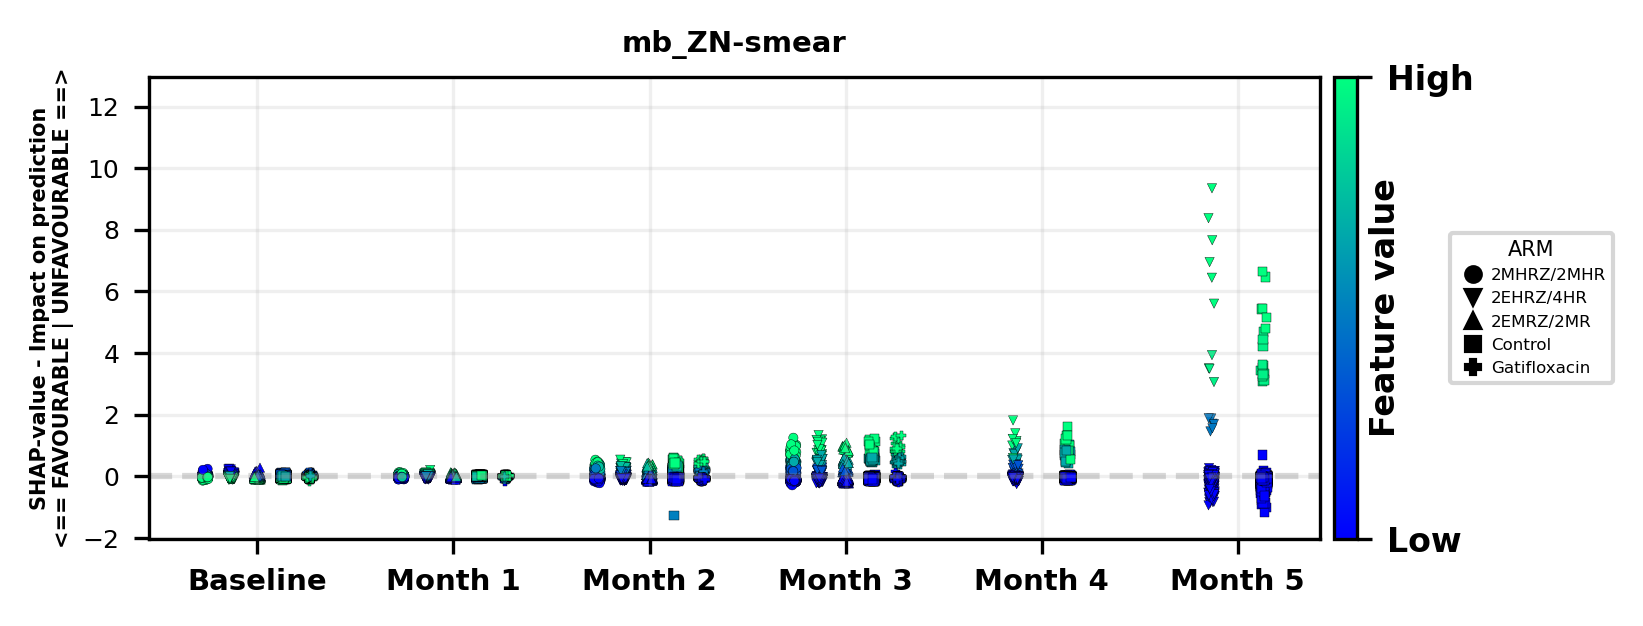

In [373]:
from matplotlib.colors import Normalize
import matplotlib as mpl
from matplotlib.lines import Line2D      
from matplotlib.cm import ScalarMappable
from matplotlib import colors as mcolors
from matplotlib.font_manager import FontProperties
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

#####
# - Set mean to true, if you want to average the SHAP-values acros the 25 CV-s for the same patients
# - Set to False, if all CV repeats of the same patients should be plotted as individual dots in the SHAP-plot
mean=True



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label=parameters_for_analysis[data_param_key]['result_cat']
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    for model_name in model_names_for_plotting[1:]:

        l,k=[],[]
        
        for period_end_day in period_end_days[:]:      
            
            if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                print('Skipping all period!')
                continue
                
            print(f'{period_end_day}')
    
            for training_data_type in training_data_types[1:]:
                print(f'{training_data_type} model')


                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)

                
                #print(merged_x_test_across_cv.index)
                merged_x_test_across_cv['period']=period_end_day
                l.append(merged_x_test_across_cv)

                merged_shap_across_cv['period']=period_end_day
                merged_shap_across_cv['USUBJID']=merged_x_test_across_cv.index.tolist()
                k.append(merged_shap_across_cv)

        
        ## CONCATENATE SHAP VALUES AND RAW VARIABLES ACROSS PERIODS
        x=pd.concat(l)
        shap=pd.concat(k)
        
        data_type='test'

        
        ## SUBSET TO TESTING DATA & ADD OUTCOME LABEL
        x_=x[x['data_type']==data_type]
        shap_=shap[shap['data_type']==data_type]

        if 'RELAPSE' in outcome_label:
            x_[outcome_label]=pats_with_relapse_df.loc[x_.index,outcome_label].values
            shap_[outcome_label]=pats_with_relapse_df.loc[shap_['USUBJID'],outcome_label].values
        else:
            x_[outcome_label]=outcome_df.loc[x_.index,outcome_label].replace(label2id).values
            shap_[outcome_label]=outcome_df.loc[shap_['USUBJID'],outcome_label].replace(label2id).values

        ##### ======================================================================
        #### Average SHAP-values of patients across CV-splits within each period

        ## List of non-numerical columns to leave out of average calculation
        cols_to_drop=['data_type', 
                      #'pred_prob', 
                      #'true_labels',
                     'cv_repeat_num',
                     'ARM', 
                     #'period',
                      'USUBJID',
                     #outcome_label,
                      #outcome_label.capitalize(),
                     ]
        ## Average the SHAP-values and prediction probabilities of patients across the CV-splits, as due to the 25 CV-splits made, 
        #  one patient appears multiple times in the test.
        shap__=shap_.copy()
        #shap__['period']=shap__['period'].replace({'baseline':0,'all':182})

        if mean==True:
            shap__ = shap__.groupby(['period','USUBJID','ARM']).apply(lambda x: x.loc[:,~x.columns.isin(cols_to_drop)].mean())
            
            ## Drop duplicates of the raw input value of the test set as well, to match the avergage shap-value dataframe
            x__ = x_.reset_index().drop_duplicates(['period','USUBJID']).sort_values(['USUBJID','period'])#.set_index('USUBJID')
        else:
            shap__ = shap__.groupby(['period','USUBJID','ARM']).apply(lambda x: x.loc[:,~x.columns.isin(cols_to_drop+['period'])])
            x__=x_.sort_values(['USUBJID','period'])
            #x__ = x_.reset_index().drop_duplicates(['period','USUBJID']).sort_values(['USUBJID','period'])#.set_index('USUBJID')
        
        shap__=shap__.sort_values(['USUBJID','period']).reset_index()


        ##### ======================================================================
        #### Plot SHAP-values across time periods


        cols_to_drop=['data_type', 'pred_prob', 'true_labels', 'USUBJID', 'cv_repeat_num',
                 'ARM', 'period','test_pred_prob_calibr',outcome_label,outcome_label.capitalize()][:-1]


        ## Replace periods names with numbers to order them based on time
        shap__['period']=shap__['period'].replace({'baseline':0,'all':182})
        x__['period']=x__['period'].replace({'baseline':0,'all':182})
        
        ## Add outcome label capitalized instead of all caps
        shap__[outcome_label.capitalize()] = shap__[outcome_label].replace({1:'UNFAVOURABLE',0:'FAVOURABLE'})
        x__[outcome_label.capitalize()] = x__[outcome_label].replace({1:'UNFAVOURABLE',0:'FAVOURABLE'})
        
        
        ## Extract variables names from shap-df
        vars=[col for col in shap_.columns.tolist() if col not in cols_to_drop][:]
        #vars=['mb_ZN-smear']
        
        ncols=2
        nrows=int(np.ceil(len(vars)/ncols))
        
        ## List of closed markers that can be filled in
        marker_list = [*Line2D.markers]
        marker_list = ['o',"v",'^','s',"P","X","D"]
        
        
        ## Name of hue column used for splitting the stripplot per period. Each hue value gets a different marker assigned
        hue_var=outcome_label.capitalize()
        #hue_var=None
        hue_var='ARM'
        #hue_var='STUYDID'
        
        #marker_styles = {'FAVOURABLE': 'o', 'UNFAVOURABLE': 'X'} 
        #marker_styles = {'FAVOURABLE': 'o', 'UNFAVOURABLE': 'X'} 
        #marker_style_list=['o','X','s','']
        #marker_styles = {0: 'o', 1: 'X'} 
        
        vars=['mb_ZN-smear']
        for var_n,var_name in enumerate(vars[:1]):
    
        
            #ax=fig.add_subplot(nrows,ncols,var_n+1)
            fig,ax=plt.subplots(1,1,figsize=(6,2))
            print(var_name)
            
            # Prepare data
            periods = np.sort(shap__.loc[~shap__[var_name].isna(),"period"].astype(int).unique())
            
            numerical_values = x__[var_name].values  # Numerical variable for coloring
            
            
            xticklabels=[ 'Month 6' if day == 182 
                                    else 'Baseline' if day == 0 
                                    else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, np.int64) 
                                    else None 
                                    for day in periods]
            
            
            if hue_var is not None:
                hue_var_labels = shap__[hue_var].unique()
                
                marker_styles=dict(zip(hue_var_labels,marker_list[:]))
                
                # Create a dictionary to store boxplot data for each period and outcome_label
                boxplot_data = {p: [shap__.loc[(shap__["period"] == p) & (shap_[outcome_label] == lbl), 
                                               var_name].dropna() 
                                     for lbl in hue_var_labels] for p in periods}
                
            
                cmap_boxplot=sns.color_palette('tab10', len(hue_var_labels))
                color_mapping=dict(zip(hue_var_labels,cmap_boxplot))
                color_mapping_dict = {i:col for i,col in color_mapping.items()}  # Adjust based on number of categories
            
           # Store scatter legend handles
            scatter_legend_handles = []
            
            # Plot boxplots
            xtick_positions = []  # To store x-tick locations
            xtick_labels = []  # To store formatted x-tick labels
        
            width = 0.2  # Space between groups
            
            # Adjust x positions for separate boxplots
            x_positions = np.arange(len(periods))
            
            '''
            # Plot boxplots
            for i, p in enumerate(periods):
                
                box = ax.boxplot(boxplot_data[p], positions=[x_positions[i] - width/2, x_positions[i] + width/2], 
                                 widths=width, patch_artist=True, showfliers=False)
            
                # Customize boxplot colors (optional)
                for patch, lbl in zip(box['boxes'], hue_var_labels):
                    color=color_mapping_dict[lbl]
                    patch.set_facecolor(color)
                    patch.set_alpha(0.3)  # Match Seaborn's transparency effect
        
        
                # Store x-tick positions and labels
                xtick_positions.extend([x_positions[i] - width/2, x_positions[i] + width/2])
                xtick_labels.extend([f"{p}\n({lbl})" for lbl in outcome_labels])  # Format: "period\n(outcome)"
            '''
            
            
            # Define spacing parameters
            period_spacing = 1.8  # Adjust to control spacing between periods
            hue_spacing = 1.2* (1/len(hue_var_labels))  # Adjust to control spacing between hue labels within a period
            
            # Compute x positions for periods
            x_positions = np.arange(len(periods)) * period_spacing  
        
            x__['scaled_values']=np.nan
            
            # Add stripplot using ax.scatter() and color by numerical variable
            for i, p in enumerate(periods):
        
                # Normalize color mapping for numerical values 
                scaler=MinMaxScaler()
                scaled_values=scaler.fit_transform(x__.loc[(x__["period"] == p),var_name].values.reshape(-1, 1)).flatten()
                x__.loc[(x__["period"] == p),'scaled_values'] = scaled_values

                pal_name='winter'

                ## Normalise: if binary, set the low to 0 and upper value to 1
                if x__[var_name].isin([0, 1]).all()==True:
                    min_norm=0
                    max_norm=1

                ## If cont., get quantiles for norm. bounds
                else:  
                    min_norm=np.quantile(scaled_values,0.01)
                    max_norm=np.quantile(scaled_values,0.99)   
                    
                norm = mcolors.Normalize(vmin=min_norm, vmax=max_norm)
                cmap = sns.color_palette(pal_name, as_cmap=True)
                #cmap = mpl.cm.viridis 
        
                if hue_var is not None:
                    num_labels = len(hue_var_labels)
                    hue_offsets = np.linspace(-hue_spacing * (num_labels - 1) / 2, 
                                               hue_spacing * (num_labels - 1) / 2, 
                                               num_labels)
                    
                    #for j, lbl in enumerate(hue_var_labels):
                    for j, (lbl, offset) in enumerate(zip(hue_var_labels, hue_offsets)):
                        subset = shap__[(shap__["period"] == p) \
                                        & (shap__[hue_var] == lbl)\
                                        & (~shap__[var_name].isna())]
                        
                        y_values = subset[var_name]
                        

                        color_values = x__.loc[((shap__["period"] == p) \
                                            & (shap__[hue_var] == lbl)\
                                            & (~shap__[var_name].isna())).values\
                                            ,'scaled_values'].values  #
        
                        # Adjust scatter points to center hue groups around each period
                        x_jitter = (hue_spacing / 4) * (np.random.rand(len(y_values)) - 0.5)  # Small jitter
                        x_positions_adjusted = np.full_like(y_values, x_positions[i] + offset) + x_jitter
        
                               
                        # Adjust scatter points to dodge them for different labels
                        #x_jitter = (step / 3) * (np.random.rand(len(y_values)) - 0.5)  # Add small jitter for visibility
                        #x_positions_adjusted = np.full_like(y_values, x_positions[i] + (-width/2 + j * width)) + x_jitter
        
                        sc = ax.scatter(x_positions_adjusted, y_values, 
                                    c=color_values, cmap=cmap, norm=norm, s=5, 
                                    #markeredgewidth=0.1,
                                    edgecolor='black',
                                    lw=0.1,
                                    alpha=1,
                                    marker=marker_styles[lbl])
        
                                    
                        if i == 0:  # Add only one entry per outcome_label
                            scatter_legend_handles.append(Line2D([], [], 
                                                                        color='black', 
                                                                        marker=marker_styles[lbl], 
                                                                        linestyle='None',
                                                                        markersize=1, 
                                                                        label=lbl))
            
                
                if hue_var is None:
                    subset = shap__[(shap__["period"] == p)\
                                    & (~shap__[var_name].isna())]
                    y_values = subset[var_name]#.dropna()
                    color_values = x__.loc[((shap__["period"] == p)\
                                            &(~shap__[var_name].isna())).values,'scaled_values']  # Get corresponding numerical values
                    
                    #color_values = shap_.loc[(shap_["period"] == p) & (shap_[hue_var] == lbl),'pred_prob'].values
                    print('period',p)
                    print()
                    
                    
                    # Adjust scatter points to dodge them for different labels
                    x_jitter = (width / 3) * (np.random.rand(len(y_values)) - 0.5)  # Add small jitter for visibility
                    x_positions_adjusted = np.full_like(y_values, x_positions[i]) + x_jitter
        
                    sc = ax.scatter(x_positions_adjusted, y_values, 
                                    c=color_values, cmap=cmap, norm=norm, s=5, 
                                    #markeredgewidth=0.1,
                                    edgecolor='black',
                                    lw=0.1,
                                    alpha=1,
                                    #marker=marker_styles[lbl],
                                   )
            
        
        
            # Add colorbar
            cbar = fig.colorbar(sc, ax=ax,pad=0.01)
            #cbar.set_ticks([y_values.quantile(0.02), y_values.quantile(0.98)])
         
            #if np.all(np.sort(np.unique(x__[var_name]))==np.array([0,1])):
            if x__[var_name].isin([0, 1]).all()==True:
                cbar.set_ticks([np.min(cbar.get_ticks()),np.max(cbar.get_ticks())])
            else:
                cbar.set_ticks([min_norm,max_norm])
            cbar.set_ticklabels(['Low', 'High'],fontsize=8,fontweight='bold')
            cbar.set_label(f'Feature value', fontsize=8, labelpad=-25,fontweight="bold")
                                        
        
            if hue_var is not None:
                # Add legend for boxplot categories
                ax.legend(handles=scatter_legend_handles, 
                          title=hue_var, 
                          fontsize=4, 
                          markerscale=3.5,
                          loc='center',
                          bbox_to_anchor=(1.18,0.5),
                          handletextpad=0.1,
                          alignment='center',
                          title_fontproperties=FontProperties(size=5)
                          
                          )
            
            
            # Formatting
            ax.set_xticks(x_positions)
            ax.set_xticklabels(xticklabels, fontsize=7, fontweight="bold")
            #ax.set_ylabel(f'{var_name} SHAP value', fontsize=8, fontweight="bold")

            ylabel='FAVOURABLE | UNFAVOURABLE'
            if 'relapse' in data_param_key:
                ylabel='NO RELAPSE | RELAPSE'
            ax.set_ylabel(f"SHAP-value - Impact on prediction\n<== {ylabel} ==>",fontsize=5, fontweight="bold",labelpad=2)
            #ax.set_xlabel("Period", fontsize=12, fontweight="bold")

            #quant_lev=0.00001
            #y_low_lim = shap__[var_name].quantile(quant_lev)
            #y_upper_lim = shap__[var_name].quantile(1-quant_lev)

            core_min, core_max = extract_core_range_bi_valley(shap_[var_name], plot=False)
            if core_min is not None and core_max is not None:
                print(f'Adjusted ylim: min:{core_min*1.05} - max:{core_max*1.05}')
                ax.set_ylim(core_min*1.05,core_max*1.05)
        
            
            ax.grid(True, linestyle="-", alpha=0.2)
            ax.set_title(var_name,fontsize=7,fontweight='bold')       
            ax.tick_params(axis='y',labelsize=6)
            ax.axhline(linestyle='--',alpha=0.3,color='grey')
        
            plt.subplots_adjust(wspace=0.2)
        
            ## ADD SUPTITLE
            if data_param_key in suptitle_study_dict.keys():
                study_names=suptitle_study_dict[data_param_key]
                prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                train_ds_type=suptitle_training_type_dict[training_data_type]
                if isinstance(period_end_day,int):
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
                if period_end_day=='all':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
                if period_end_day=='baseline':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
            else:
                suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} -\n{training_data_type} data - {model_name}"
            
            #fig.suptitle(suptitle,fontsize=8,y=1.15, x=0.45,fontweight='bold')
        
            
            ### SAVE PLOTS
            data_dir_=f'../data/plots/raw_SHAP_values_all_datapoints_across_time/{data_param_key}/{model_name}'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{var_name}_correlations_across_time.png')
            #fig.savefig(fn, bbox_inches='tight', dpi=300)
            #plt.close()

        


#### SHAP values across time - curves

In [ ]:
return_important_features_across_periods(l,k)

Extracting relapse information...


/tmp/ipykernel_235079/1656178082.py:1710: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)


 tb21_22_2984_pats_22_vars_result_at_end_of_treatment 

last_therapy_day model
baseline
Loading SHAP-values for model XGBoost
31
Loading SHAP-values for model XGBoost
62
Loading SHAP-values for model XGBoost
93
Loading SHAP-values for model XGBoost
125
Loading SHAP-values for model XGBoost
160
Loading SHAP-values for model XGBoost
Skipping all period!


/tmp/ipykernel_235079/3058327811.py:831: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shap_across_periods_[cols_to_add_back] = shap_across_periods[cols_to_add_back].values
/tmp/ipykernel_235079/3058327811.py:831: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shap_across_periods_[cols_to_add_back] = shap_across_periods[cols_to_add_back].values
/tmp/ipykernel_235079/3058327811.py:831: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

imp_vars_ ../data/plots/raw_SHAP_curves_across_time/tb21_22_2984_pats_22_vars_result_at_end_of_treatment/last_therapy_day_XGBoost_curves_across_time.csv
Alanine aminotransferase ['Bottom 25%' 'Top 25%']


ValueError: could not convert string to float: 'Bottom 25%'

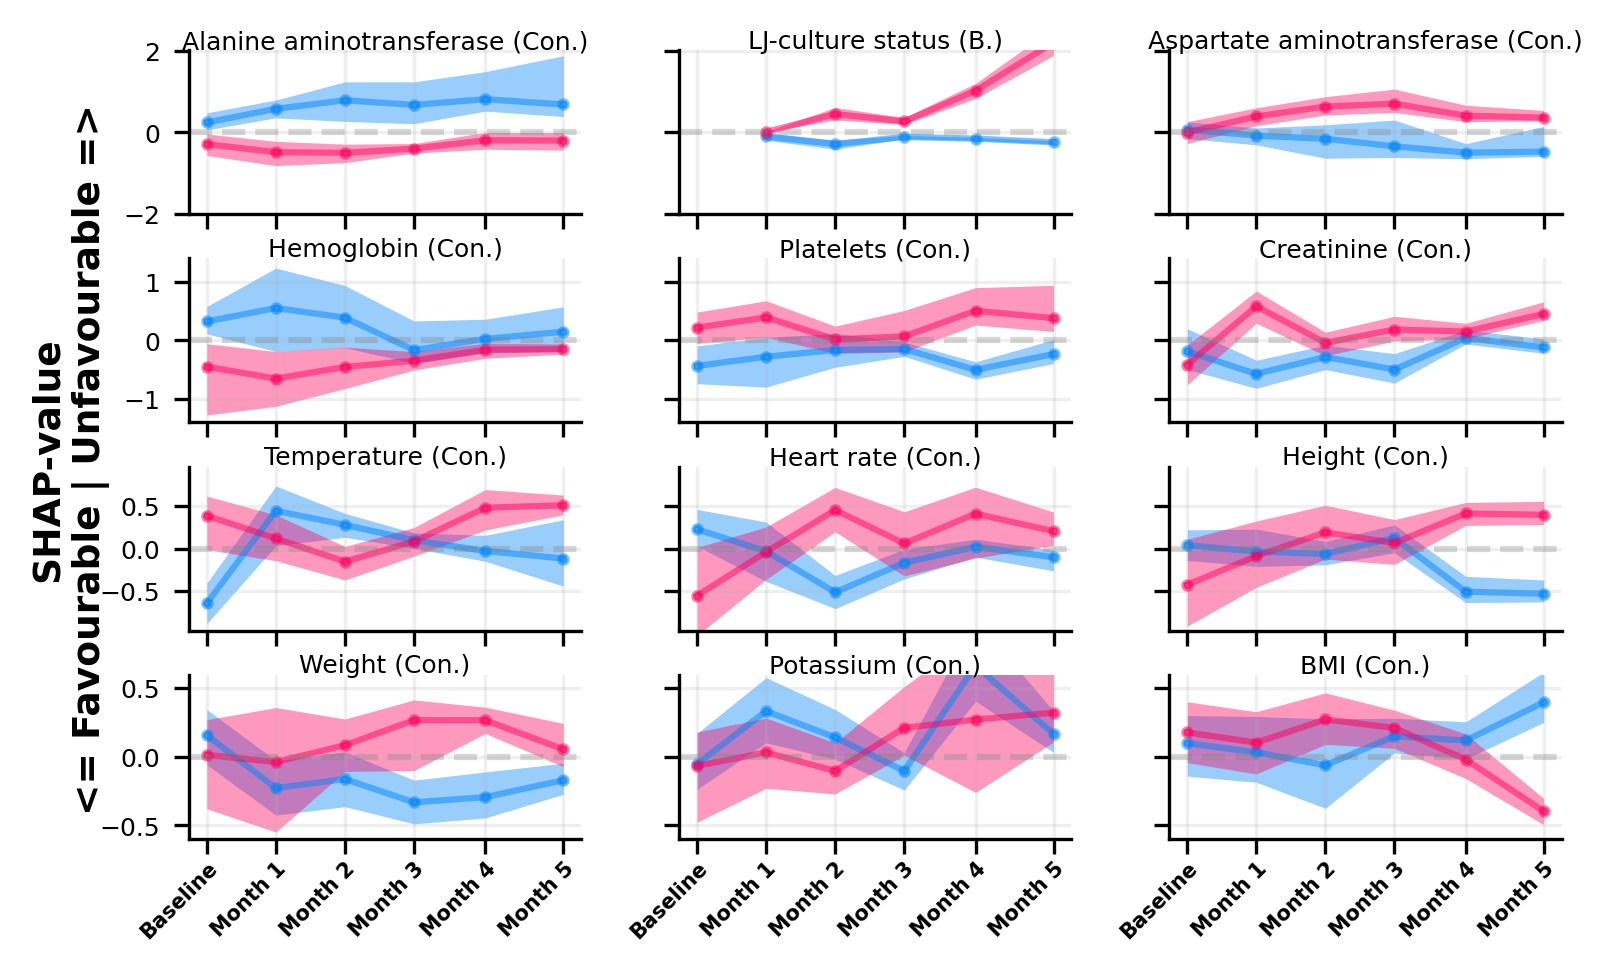

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm




from matplotlib.colors import Normalize
import matplotlib as mpl
from matplotlib.lines import Line2D      
from matplotlib.cm import ScalarMappable
from matplotlib import colors as mcolors
from matplotlib.font_manager import FontProperties
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

#####
# - Set mean to true, if you want to average the SHAP-values acros the 25 CV-s for the same patients
# - Set to False, if all CV repeats of the same patients should be plotted as individual dots in the SHAP-plot
mean=False


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label=parameters_for_analysis[data_param_key]['result_cat']
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    for training_data_type in training_data_types[1:]:
        print(f'{training_data_type} model')
        
        for model_name in model_names_for_plotting[:1]:

        
        

            l,k=[],[]
        
            for period_end_day in period_end_days[:]:      
                
                if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                    print('Skipping all period!')
                    continue

                if outcome_label=='RELAPSE' and period_end_day in [160,'all']:
                    print('Skipping 160 and all period!')
                    continue
                    
                print(f'{period_end_day}')

                
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)

                
                #print(merged_x_test_across_cv.index)
                merged_x_test_across_cv['period']=period_end_day
                k.append(merged_x_test_across_cv)

                merged_shap_across_cv['period']=period_end_day
                merged_shap_across_cv['USUBJID']=merged_x_test_across_cv.index.tolist()
                l.append(merged_shap_across_cv)
                
        
            ## CONCATENATE SHAP VALUES AND RAW VARIABLES ACROSS PERIODS
            #x=pd.concat(k)
            #shap=pd.concat(l)
      
            
            metric = 'mean'
            metric='quant'
            # metric in ['cov','corr','mean','std_level_means','skew','quant',][-1:]:
            imp_vars_,shap_,x_ = return_important_features_across_periods(l,k,metric=metric,quant_thr=0.95)
            
            vars_to_plot = imp_vars_.index.tolist()[:12]
            ncols=3
            nrows=int(np.ceil(len(vars_to_plot)/ncols))

            extreme_q=0.25
            keep_only_extreme_categories=True

            areas = calculate_auc_between_bottom_and_top_curves(vars_to_plot,x_,shap_,ncols,nrows,extreme_q)
            vars_to_plot= areas.sort_values(ascending=False).index.tolist()

            imp_vars_ = imp_vars_.loc[vars_to_plot,:]

            
            #fig = plt.figure(figsize=(ncols*4, nrows*2))
            #gs = GridSpec(nrows=nrows, ncols=ncols, figure=fig, wspace=0.15, hspace=0.15)
            figsize=(ncols*2, nrows*0.8)
            fig, axes = plt.subplots(
                nrows=nrows,
                ncols=ncols,
                figsize=figsize,
                sharex=True,
                #sharey=False,
                sharey='row',
            )
            
            axes = axes.flatten()
            
            cmap_ = colors.red_blue
            
            d={}
           
            
            
            #vars_to_plot=['Age'] + vars_to_plot
            
            for i, var_name in enumerate((vars_to_plot[:])):
                #ax = fig.add_subplot(gs[i // ncols, i % ncols],)#sharey=True)
                row_ind, col_ind = i // ncols, i % ncols
                ax = axes[i]
                #print(var_name)
            
            
                fig, summary, group_handles = plot_population_curves_by_feature_strata(
                    shap_df=shap_,
                            x_df=x_,
                            var_name=var_name,
                            hue_var=None,#'ARM',              # <- no hue
                            add_iqr_band=True,
                            #strata_display="colorbar", # works for binary too
                            cmap_name = colors.red_blue,
                            facet_by_arm = False, 
                            id_col= "USUBJID",
                            period_col = "period",
                            cv_col="cv_repeat_num",
                            #collapse_repeats= "median",     # "median" or "mean" per patient-period
                            #summary_stat = "median",
                            #add_iqr_band=True,
                            strata_display=None,#"colorbar",
                            #cmap_name="winter",
                            binary_threshold_unique=7,     # treat <=2 unique values as categorical
                            min_n_per_bin_per_period= 1,
                            display_hue_legend=False,
                            figsize_single=(4, 1.8),
                            ax=ax,
                            row_ind=row_ind,
                            col_ind=col_ind,
                            #strata_mode="quantiles", ## split continupus variables into q quantiles
                            q=2,
                            strata_mode="extremes", ## Takes only the top extreme_q quantile and bottom extreme_q values of cont. var, and plots them
                            extreme_q=extreme_q,
                            collapse_repeats='mean',     # keep repeats
                            summary_stat="median",     # ok, but note overweighting
                            iqr_alpha = 0.4,
                            keep_only_extreme_categories=keep_only_extreme_categories, # If there are orfinal variables with multiple levels, keep only the extremes
                
                )
                d[var_name]=summary
                
                n_unique = x_[var_name].nunique()
                if n_unique<=2:
                    var_type='B.'
                
                if n_unique>2 and n_unique<7:
                    var_type='Ord.'
                
                if n_unique>7:
                    var_type='Con.'

                ax_title=f'{var_name} ({var_type})'
                ax.set_title(ax_title,fontsize=6,y=0.86)
                abs_ylim=np.max(np.abs(ax.get_ylim()))
                ax.set_ylim(-abs_ylim,abs_ylim)
               
                

            for ax in fig.axes:
                #ax.tick_params(axis="x", labelbottom=True)  # force labels ON
                #ax.tick_params(axis='x', pad=1,labelsize=5,labelbottom=True)
                ax.tick_params(axis="x", labelbottom=False)
                ax.tick_params(axis="y", labelsize=6)
            

            bottom_row_axes = fig.axes[-ncols:]
            for ax in bottom_row_axes:
                #ax.tick_params(axis="x", labelbottom=True)
                ax.tick_params(axis='x', pad=1,labelsize=5,labelbottom=True)
                plt.setp(
                    ax.get_xticklabels(),
                    rotation=45,
                    ha="right",
                    rotation_mode="anchor",
                    fontweight="bold",
                )
            
            ylabel='Favourable | Unfavourable'
            if 'relapse' in data_param_key:
                ylabel='No relapse | Relapse'
            
            ylabel_ = f"SHAP-value\n<= {ylabel} =>"
            
            plt.text(
                    0.02, 0.5,           # -0.13: controls horizontal distance from axis
                    ylabel_,
                    #transform=ax.transAxes,
                    transform=fig.transFigure,
                    fontsize=9, fontweight='bold',
                    ha='center', va='center',
                    rotation='vertical'
                )
            
            
            
            plt.subplots_adjust(wspace=0.25,hspace=0.27)
            
            
            #plt.tight_layout()
            if len(group_handles)>0:
                #leg_ax.axis("off")   # hide dummy axes
            
                fig.legend(
                        handles=group_handles,
                        title=hue_var,
                        loc="upper right",
                        bbox_to_anchor=(0.95,0.95),
                        #fontsize=15,
                        #title=
                            )
    
    
            ### SAVE PLOTS
            data_dir_=f'../data/plots/raw_SHAP_curves_across_time/{data_param_key}'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{training_data_type}_{model_name}_curves_across_time.png')
            #fig.savefig(fn, bbox_inches='tight', dpi=300)
            #plt.close()

            ## Save important variables for later use
            fn=os.path.join(data_dir_,
                        f'{training_data_type}_{model_name}_curves_across_time.csv')
            print('imp_vars_',fn)
            imp_vars_.to_csv(fn)



            ### CREATE LEGEND FOR FIGURE
            leg_fig = return_legends_for_curve_plots(extreme_q=extreme_q,
                                           d=d,
                                           cat_cmap=cmap_,
                                            keep_only_extreme_categories=keep_only_extreme_categories)

            ## SAVE LEGEND
            data_dir_=f'../data/plots/raw_SHAP_curves_across_time/{data_param_key}'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{training_data_type}_{model_name}_curves_across_time_legend.png')
            leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
            #plt.close()

            '''

            
           ####  CREATE COLORBAR ON UNIQUE PLOT
            from matplotlib.cm import ScalarMappable
            from matplotlib.colors import ListedColormap, BoundaryNorm
            
            cbar_fig,cbar_ax=plt.subplots(1,1,figsize=(5,5))
            cbar_ax.axis("off") 
            
            
            cmap_='winter'
            cmap_ = colors.red_blue
            
            ## Get colormaps for stripplot
            norm = Normalize(vmin=0,vmax=1)#vmin=x_test_plot_df['value'].min(), vmax=x_test_plot_df['value'].max())
            #sm = ScalarMappable(norm=norm, cmap=pal_name)
            sm = ScalarMappable(norm=norm, cmap=cmap_)
            
            
            # Add the colorbar
            # Create a divider for the current axis
            #cbar = cbar_fig.colorbar(sm, ax=cbar_fig.axes, fraction=0.02, pad=0.02)
            cbar = cbar_fig.colorbar(sm, ax=cbar_ax, 
                                     #orientation='vertical', 
                                     pad=0.002,
                                     aspect=30,
                                     orientation='horizontal')
            cbar.set_label('Variable Value',fontsize=12,
                           labelpad=-10, 
                           
                           fontweight='bold')
            
            # Customize colorbar to show 'High' and 'Low'
            cbar_low_tick=max(0,0)
            cbar_high_tick=min(1,1)
            cbar.set_ticks([cbar_low_tick,cbar_high_tick])
            cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
            '''

            ## SAVE LEGEND
            data_dir_=f'../data/plots/raw_SHAP_curves_across_time/{data_param_key}'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{training_data_type}_{model_name}_curves_across_time_cbar.png')
            #cbar_fig.savefig(fn, bbox_inches='tight', dpi=300)
            #plt.close()
            


In [38]:
x_.groupby('period').apply(lambda x:x['Creatinine'].quantile(0.75))

period
31          83.5
62          82.0
93          82.0
125         85.5
160         86.5
baseline    88.0
dtype: float64

In [64]:
var_cols = ['Age', 'ce_Sweat', 'ce_Cough', 'ce_Chest pain', 'ce_Fever',
           'ce_Haemoptysis', 'Weight', 'Temperature', 'Diastolic blood pressure',
           'Systolic blood pressure', 'Heart rate', 'Height', 'Creatinine',
           'Hemoglobin', 'Alanine aminotransferase', 'Aspartate aminotransferase',
           'Potassium', 'Platelets', 'Zn-smear', 'LJ-culture', 'mh_Dyspnea',
           'mh_Fever', 'mh_Weight loss', 'mh_Cough', 'mh_Chest pain',
           'mh_Haemoptysis', 'mh_Sweat', 'Race_Asian', 'Race_Black',
           'Race_Mixed race or coloured', 'Race_Other', 'Male_Sex', 'BMI',
           'LJ-culture status', 'Placebo cumul. dose', 'Rifampicin cumul. dose',
           'Pyrazinamide cumul. dose', 'Ethambutol cumul. dose',
           'Isoniazid cumul. dose', 'Moxifloxacin cumul. dose',
           'Gatifloxacin cumul. dose', 'Drug appl. days',]
x_.columns

Index(['Age', 'ce_Sweat', 'ce_Cough', 'ce_Chest pain', 'ce_Fever',
       'ce_Haemoptysis', 'Weight', 'Temperature', 'Diastolic blood pressure',
       'Systolic blood pressure', 'Heart rate', 'Height', 'Creatinine',
       'Hemoglobin', 'Alanine aminotransferase', 'Aspartate aminotransferase',
       'Potassium', 'Platelets', 'Zn-smear', 'LJ-culture', 'mh_Dyspnea',
       'mh_Fever', 'mh_Weight loss', 'mh_Cough', 'mh_Chest pain',
       'mh_Haemoptysis', 'mh_Sweat', 'Race_Asian', 'Race_Black',
       'Race_Mixed race or coloured', 'Race_Other', 'Male_Sex', 'BMI',
       'LJ-culture status', 'Placebo cumul. dose', 'Rifampicin cumul. dose',
       'Pyrazinamide cumul. dose', 'Ethambutol cumul. dose',
       'Isoniazid cumul. dose', 'Moxifloxacin cumul. dose',
       'Gatifloxacin cumul. dose', 'Drug appl. days', 'cv_repeat_num',
       'period', 'ARM', 'pred_prob'],
      dtype='object')

In [66]:
x__ = x_.groupby(['period','USUBJID']).apply(lambda x:x[var_cols].mean())
shap__ = shap_.groupby(['period','USUBJID']).apply(lambda x:x[var_cols].mean())

In [78]:
groups=x__.groupby('period',as_index=False).apply(lambda x:pd.cut(x=x['Creatinine'],
                                           bins=[x['Creatinine'].min()-1,
                                                 x['Creatinine'].quantile(0.25),
                                                 x['Creatinine'].quantile(1-0.25),
                                                 x['Creatinine'].max()+1],
                                          labels=['Low',
                                                  'Interm.',
                                                  'High']))

groups =groups.reset_index().set_index(['period','USUBJID'])
groups = groups.sort_index()

In [81]:
p

Creatinine
period   USUBJID                    
31       TB-1021/1001709    0.004682
         TB-1021/1001933   -0.033505
         TB-1021/1002157    0.062176
         TB-1021/1003511   -0.028387
         TB-1021/1003959   -0.305622
...                              ...
baseline TB-1022/53502     -0.002735
         TB-1022/53503      0.009289
         TB-1022/53504      0.002763
         TB-1022/53505     -0.008125
         TB-1022/53506     -0.000442

[13939 rows x 1 columns]

In [85]:
groups

level_0 Creatinine
period   USUBJID                            
31       TB-1021/1001709        0    Interm.
         TB-1021/1001933        0        Low
         TB-1021/1002157        0    Interm.
         TB-1021/1003511        0    Interm.
         TB-1021/1003959        0        Low
...                           ...        ...
baseline TB-1022/53502          5    Interm.
         TB-1022/53503          5    Interm.
         TB-1022/53504          5    Interm.
         TB-1022/53505          5        Low
         TB-1022/53506          5    Interm.

[13939 rows x 2 columns]

In [87]:
p = shap__.reset_index()[['USUBJID','period','Creatinine']]
p = p.set_index(['period','USUBJID'])
p = p.sort_index()
p['groups'] = groups['Creatinine'].values
p.groupby(['period','groups']).apply(lambda x: x['Creatinine'].quantile(0.5))

period    groups 
31        Low       -0.160595
          Interm.   -0.018682
          High       0.166663
62        Low       -0.049227
          Interm.   -0.005055
          High       0.056073
93        Low       -0.017642
          Interm.   -0.001377
          High       0.018508
125       Low       -0.022449
          Interm.   -0.001061
          High       0.017952
160       Low       -0.488788
          Interm.   -0.058210
          High       0.489339
baseline  Low        0.013911
          Interm.    0.000857
          High      -0.014940
dtype: float64

period    USUBJID        
31        TB-1021/1001709    Interm.
          TB-1021/1001709    Interm.
          TB-1021/1001933        Low
          TB-1021/1001933        Low
          TB-1021/1001933        Low
                              ...   
baseline  TB-1022/53506      Interm.
          TB-1022/53506      Interm.
          TB-1022/53506      Interm.
          TB-1022/53506      Interm.
          TB-1022/53506      Interm.
Name: Creatinine, Length: 70062, dtype: category
Categories (3, object): ['Low' < 'Interm.' < 'High']

ValueError: Length of values (406840) does not match length of index (70062)

<Axes: xlabel='period', ylabel='Creatinine'>

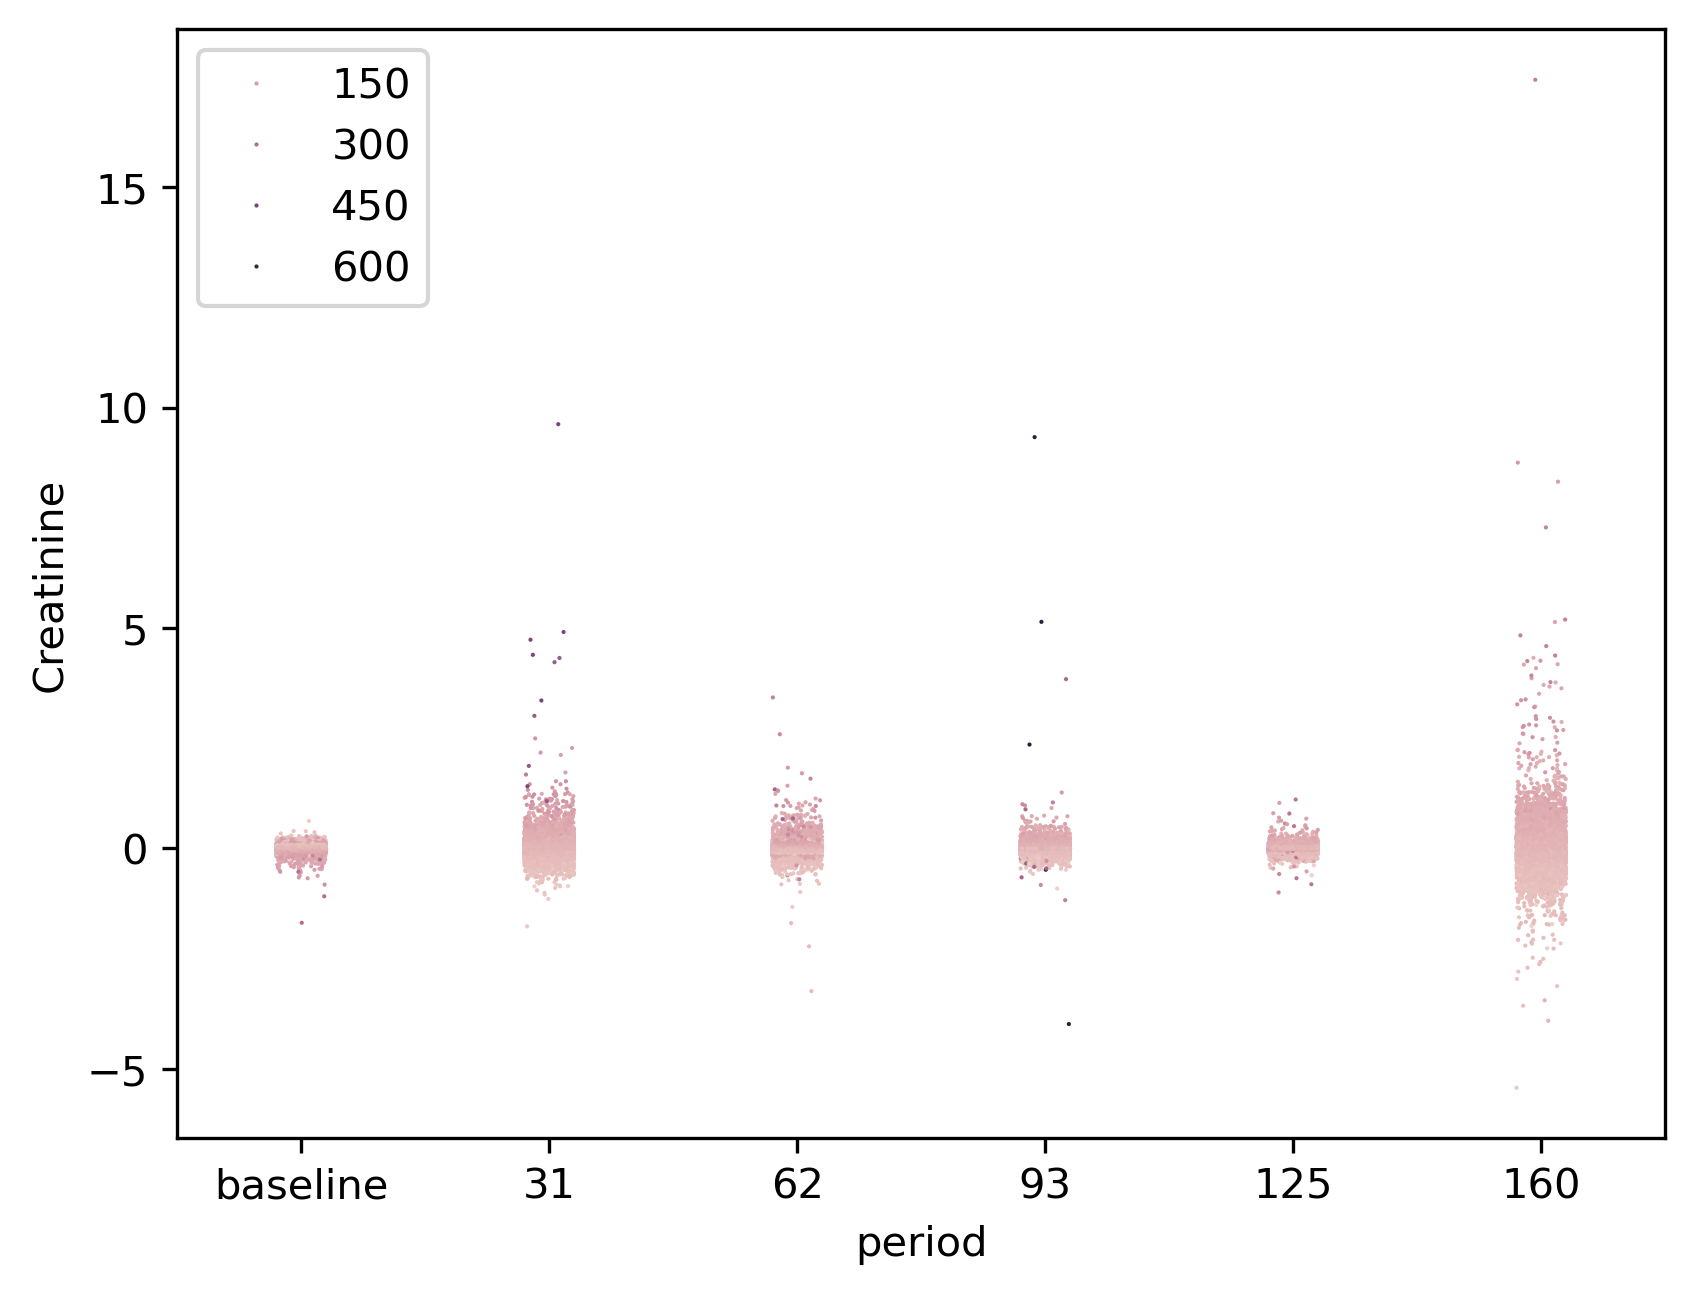

In [36]:


sns.stripplot(data = shap_,
            x='period',
            y='Creatinine',
              s=1,
            hue=x_['Creatinine'].values)

In [27]:
shap_[['USUBJID','period','Creatinine']].groupby('period').apply()#.columns

,USUBJID,period,Creatinine
0,TB-1021/1001933,baseline,0.039720
1,TB-1021/1006439,baseline,0.066314
2,TB-1021/1008007,baseline,0.036617
3,TB-1021/1008231,baseline,-0.127851
4,TB-1021/1009127,baseline,-0.017355
...,...,...,...
235,TB-1022/53142,160,-0.428142
236,TB-1022/53143,160,-0.526275
237,TB-1022/53149,160,-0.121121
238,TB-1022/53489,160,-0.215900


In [24]:
type(plt.cm.get_cmap('Set2'))

matplotlib.colors.ListedColormap

In [74]:
def return_legends_for_curve_plots(extreme_q,d,cat_cmap):

    import matplotlib.pyplot as plt
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.patches import Patch
    from matplotlib.colorbar import ColorbarBase
    from matplotlib.colors import Normalize
    
    extreme_q=0.25
    
    cat_colormaps=['Paired','Set2','Set1','Paired','tab10']
    ### CREATE CUSTOM LEGEND FOR REGIONS
        # Create a list for column colors
    col_colrs_list = []
    legends = []  # Store legend details
    
    col_color_var_list = ['Binary','Categorical','Continuous']
    
    for n,colour_coln in enumerate(col_color_var_list[:]):
        #cat_cmap = cat_colormaps[n]
        cat_cmap = colors.red_blue
        
    
        if colour_coln=='Binary':
            col_vars=['Negative','Positive']
    
        if colour_coln=='Categorical':
            max_unique,max_var=0,0
            for var in d.keys():
                if 'feat_bin' in d[var].columns:
                    if max_unique<d[var]['feat_bin'].nunique():
                        max_unique = d[var]['feat_bin'].nunique()
                        max_var = var
            
            col_vars=np.sort(d[max_var]['feat_bin'].unique())
            col_vars = [f'Level {int(float(v))}' for v in col_vars]
    
        if colour_coln=='Continuous':
            col_vars = [f"Bottom {extreme_q}%",f"Top {1-extreme_q}%"]
            
    
                    
        ordered_clusters_colors = colors.red_blue# plt.cm.get_cmap(cat_cmap)# len(col_vars))  
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        
        
        # Add legend for categorical variable
        #patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
        #    for region in col_vars]
    
        #cat_cmap = colors.red_blue  # your LinearSegmentedColormap
    
        vals = np.linspace(0, 1, len(col_vars), endpoint=True)
        rgba = [cat_cmap(v) for v in vals]
        
        ordered_clusters_color_mapping = dict(zip(col_vars, rgba))
        
        patch_handles = [
            Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars
        ]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})
        
    
    
    
    
    
    leg_fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")   # hide dummy axes
    
    # --- layout controls ---
    x_left = 0.05
    y_top = 0.95
    pad = 0.02
    
    cbar_width = 0.03
    cbar_height = 0.18
    
    x_cursor = x_left
    
    leg_fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    
    for legend in legends:
        if legend.get("label") == "cv_repeat_num":
            continue
    
        # -------------------------
        # categorical legend blocks
        # -------------------------
        if legend.get("type") == "categorical":
    
            leg = leg_fig.legend(
                handles=legend["handles"],
                title=legend["label"],
                loc="upper left",
                bbox_to_anchor=(x_cursor, y_top),
                ncols=1 if len(legend["handles"])<3 else 3,
                bbox_transform=leg_fig.transFigure,
                frameon=True,
                fontsize=14,
                handletextpad=0.55,
                columnspacing=0.8,
                title_fontproperties={"weight": "bold", "size": 15},
                borderaxespad=0.0,
            )
    
            fig.canvas.draw()
    
            bbox_disp = leg.get_window_extent(renderer=renderer)
            bbox_fig = bbox_disp.transformed(leg_fig.transFigure.inverted())
    
            # move cursor right by actual legend width
            x_cursor = bbox_fig.x1 + pad
    
        # -------------------------
        # continuous colorbar blocks
        # -------------------------
        elif legend.get("type") == "continuous":
    
            y0 = y_top - cbar_height
    
            cbar_ax = leg_fig.add_axes([
                x_cursor,
                y0,
                cbar_width,
                cbar_height
            ])
    
            cb = ColorbarBase(
                cbar_ax,
                cmap=legend["colormap"],
                norm=legend["norm"],
                orientation="vertical",
            )
    
            cb.set_label(legend["label"], fontsize=10)
    
            x_cursor = x_cursor + cbar_width + pad
    
    return leg_fig

In [62]:
col_vars

array(['0.0', '1.0', '2.0', '3.0', '4.0'], dtype=object)

In [47]:
col_vars=np.sort(d[max_var]['feat_bin'])
col_vars

array(['0.0', '0.0', '0.0', '0.0', '0.0', '0.0', '1.0', '1.0', '1.0',
       '1.0', '1.0', '1.0', '2.0', '2.0', '2.0', '2.0', '2.0', '2.0',
       '3.0', '3.0', '3.0', '3.0', '3.0', '3.0', '4.0', '4.0', '4.0',
       '4.0', '4.0', '4.0'], dtype=object)

In [534]:
lo = x_31.loc[:,'Moxifloxacin cumul. dose'].quantile(0.2)
hi = x_31.loc[:,'Moxifloxacin cumul. dose'].quantile(1-0.2)


In [536]:
x_31.loc[x_31['Moxifloxacin cumul. dose']>hi,:]

,Age,ce_Sweat,ce_Cough,ce_Chest pain,ce_Fever,ce_Haemoptysis,Weight,Temperature,Diastolic blood pressure,Systolic blood pressure,...,Pyrazinamide cumul. dose,Ethambutol cumul. dose,Isoniazid cumul. dose,Moxifloxacin cumul. dose,Gatifloxacin cumul. dose,Drug appl. days,cv_repeat_num,period,ARM,pred_prob
USUBJID,,,,,,,,,,,,,,,,,,,,,
TB-1021/1698938,27.0,0.0,1.0,1.0,0.0,0.0,57.5,38.30,70.0,121.0,...,45000.0,36000.0,0.0,12000.0,0.0,30.0,0,31,2EMRZ/2MR,0.487537
TB-1021/1832552,24.0,1.0,1.0,0.0,0.0,0.0,49.6,36.20,71.0,115.0,...,31000.0,0.0,9300.0,12400.0,0.0,31.0,0,31,2MHRZ/2MHR,0.574478
TB-1021/2325973,23.0,0.0,1.0,0.0,0.0,0.0,49.0,36.00,50.0,100.0,...,31000.0,24800.0,0.0,12400.0,0.0,31.0,0,31,2EMRZ/2MR,0.431265
TB-1021/2364528,25.0,0.0,1.0,0.0,0.0,0.0,57.0,36.00,60.0,92.0,...,30000.0,24000.0,0.0,12000.0,0.0,30.0,0,31,2EMRZ/2MR,0.306735
TB-1021/2396517,64.0,0.0,0.0,0.0,0.0,0.0,83.0,36.60,66.0,104.0,...,60000.0,0.0,9000.0,12000.0,0.0,30.0,0,31,2MHRZ/2MHR,0.725858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TB-1021/2555268,25.0,0.0,1.0,0.0,0.0,0.0,43.7,36.60,72.0,124.0,...,30000.0,24000.0,0.0,12000.0,0.0,30.0,24,31,2EMRZ/2MR,0.582483
TB-1021/2610267,34.0,0.0,0.0,0.0,0.0,0.0,42.8,36.40,76.0,116.0,...,31000.0,24800.0,0.0,12400.0,0.0,31.0,24,31,2EMRZ/2MR,0.575805
TB-1021/2777514,27.0,0.0,0.0,1.0,0.0,1.0,56.3,36.10,78.0,119.0,...,30000.0,0.0,9000.0,12000.0,0.0,30.0,24,31,2MHRZ/2MHR,0.284547


In [539]:
x_31.loc[x_31['Moxifloxacin cumul. dose']<=lo,:]

,Age,ce_Sweat,ce_Cough,ce_Chest pain,ce_Fever,ce_Haemoptysis,Weight,Temperature,Diastolic blood pressure,Systolic blood pressure,...,Pyrazinamide cumul. dose,Ethambutol cumul. dose,Isoniazid cumul. dose,Moxifloxacin cumul. dose,Gatifloxacin cumul. dose,Drug appl. days,cv_repeat_num,period,ARM,pred_prob
USUBJID,,,,,,,,,,,,,,,,,,,,,
TB-1021/1011182,45.0,0.0,1.0,1.0,0.0,0.0,51.900000,36.200000,90.000000,118.000000,...,28000.0,22400.0,8400.0,0.0,0.0,28.0,0,31,2EHRZ/4HR,0.148028
TB-1021/1011747,29.0,0.0,1.0,0.0,0.0,0.0,45.800000,36.600000,78.000000,118.000000,...,29000.0,23200.0,8700.0,0.0,0.0,29.0,0,31,2EHRZ/4HR,0.291323
TB-1021/1017105,32.0,0.0,1.0,1.0,0.0,0.0,86.400000,36.500000,66.000000,101.000000,...,58000.0,46400.0,8700.0,0.0,0.0,29.0,0,31,2EHRZ/4HR,0.155849
TB-1021/1017816,22.0,1.0,1.0,1.0,1.0,0.0,50.600000,36.700000,72.000000,120.000000,...,29000.0,23200.0,8700.0,0.0,0.0,29.0,0,31,2EHRZ/4HR,0.364526
TB-1021/1034351,26.0,0.0,1.0,1.0,0.0,0.0,47.800000,36.200000,90.000000,143.000000,...,27000.0,21600.0,8100.0,0.0,0.0,27.0,0,31,2EHRZ/4HR,0.224178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TB-1022/53147,39.0,1.0,1.0,1.0,1.0,0.0,53.900000,36.700000,61.000000,117.000000,...,43200.0,29700.0,8100.0,0.0,0.0,27.0,24,31,Control,0.524401
TB-1022/53483,34.0,1.0,1.0,1.0,1.0,0.0,45.466667,36.766667,54.333333,116.333333,...,20400.0,0.0,3825.0,0.0,6800.0,17.0,24,31,Gatifloxacin,0.385476
TB-1022/53487,46.0,1.0,1.0,1.0,1.0,0.0,49.000000,36.800000,61.666667,110.333333,...,16800.0,11550.0,3150.0,0.0,0.0,14.0,24,31,Control,0.266639


In [ ]:
x.loc[(shap_['period']==31).values,'Moxifloxacin cumul. dose']

In [526]:
x_.loc[(shap_['period']==31).values,'Moxifloxacin cumul. dose'].unique()

array([11600.,     0.,  7200., 11200., 10800.,  8800., 10400., 12000.,
       12400., 10000.,  6000.,  6400.,  9600.,  8400.,  7600.,  9200.])

<Axes: ylabel='Moxifloxacin cumul. dose'>

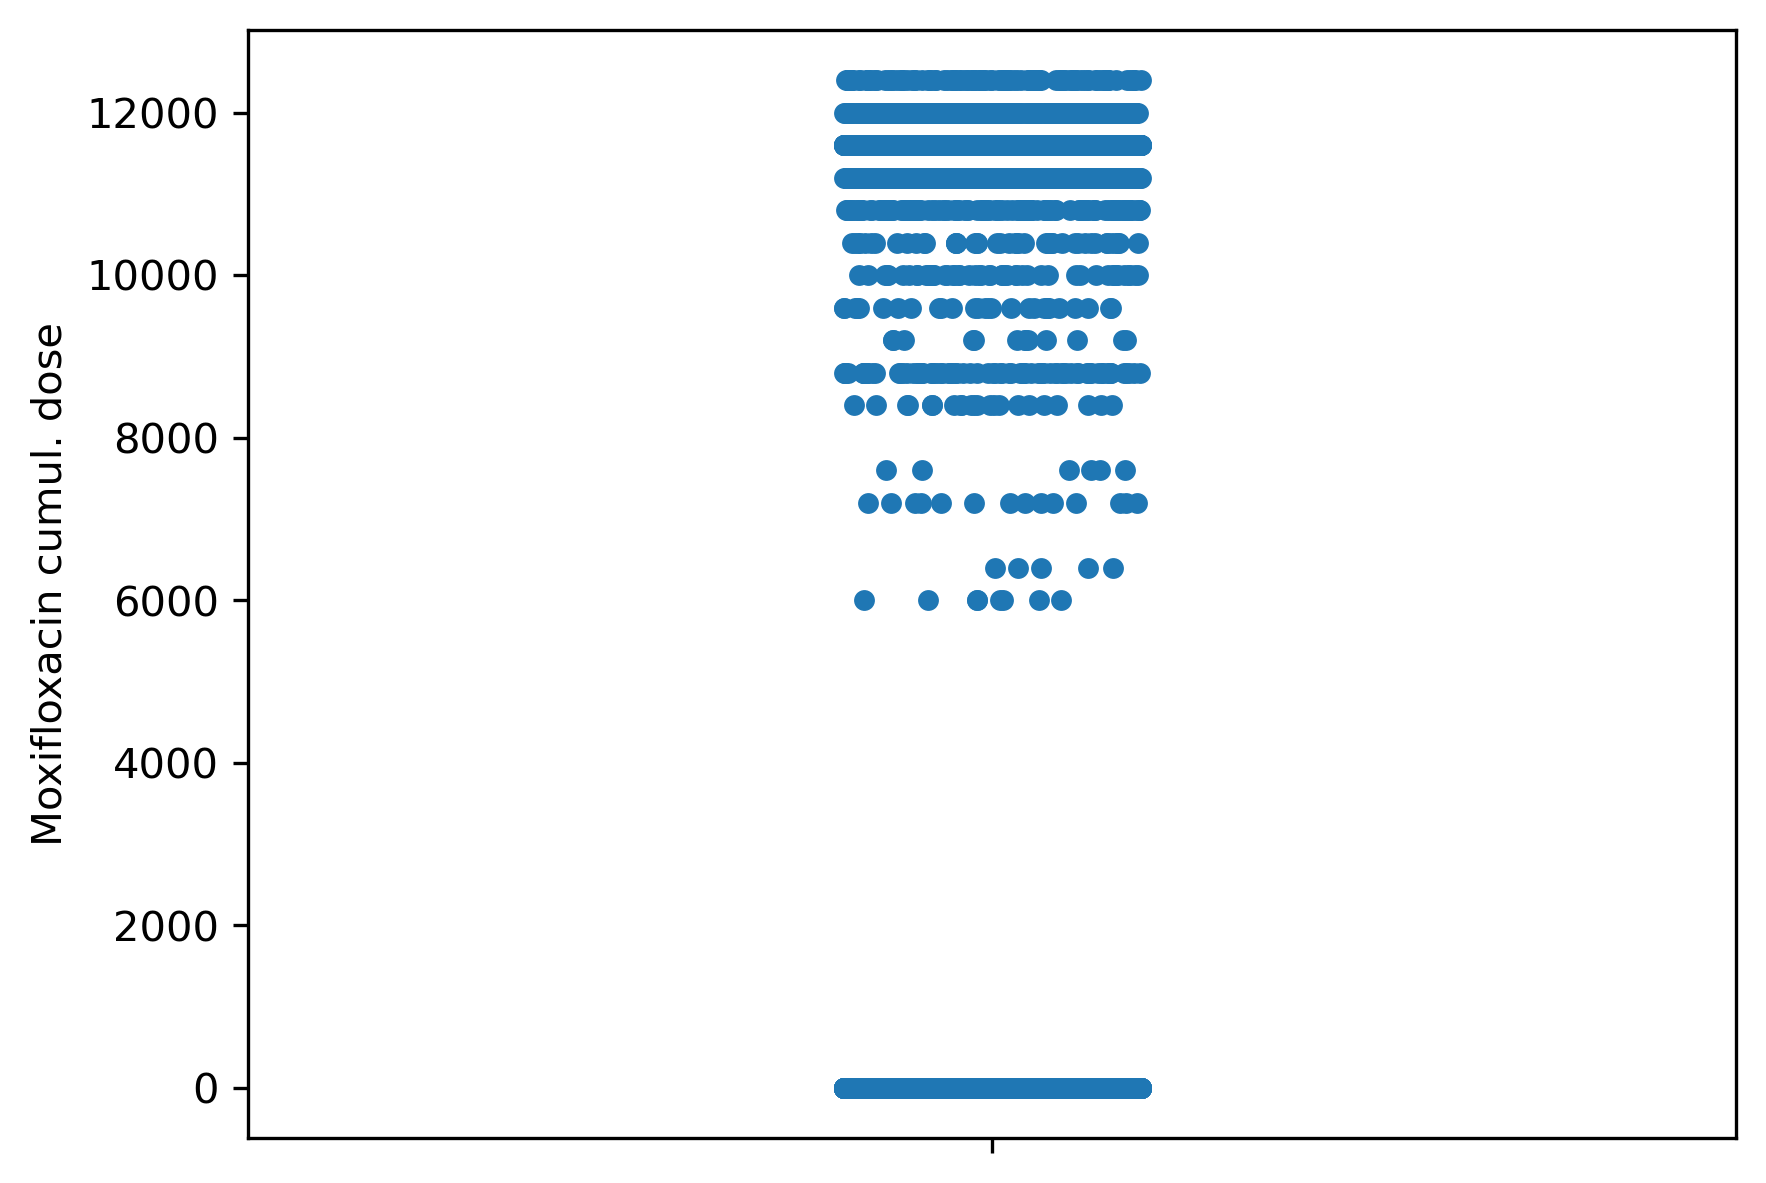

In [521]:
sns.stripplot(x_.loc[(shap_['period']==31).values,'Moxifloxacin cumul. dose'])

In [500]:
d[var_name]

,feat_bin,period,center,n,q25,q75
0,Bottom 25%,31,0.058539,1233,0.007584,0.345383
1,Bottom 25%,62,0.393250,416,0.372703,0.415855
2,Bottom 25%,93,0.361234,411,0.341845,0.386142
3,Bottom 25%,125,0.379222,409,0.351212,0.412517
4,Top 25%,93,-0.203253,736,-0.236458,-0.152564
5,Top 25%,125,-0.073904,1662,-0.200265,-0.023648


In [ ]:
sns.scatterplot(data=pl,
            x='feature_value',
            y='SHAP_values',
            hue='period')

In [ ]:
# Add stripplot using ax.scatter() and color by numerical variable
for i, p in enumerate(periods):
    for j, lbl in enumerate(hue_var_labels):
        subset = shap_[(shap_["period"] == p) & (shap_[hue_var] == lbl)]
        y_values = subset[var_name].dropna()
        color_values = x_.loc[(x_["period"] == p) & (x_[hue_var] == lbl),var_name].values  # Get corresponding numerical values

        sns.lineplot()

In [ ]:
x_.index

In [ ]:
#sns.scatterplot(data=shap_,x='pred_prob',y='mb_LJ-culture_CULTURE_STATUS',hue=outcome_label)

# Create a FacetGrid
g = sns.FacetGrid(shap_, col="period", col_wrap=3, height=4, sharex=True, sharey=True)

# Map the scatterplot onto the FacetGrid
g.map_dataframe(sns.scatterplot, x="pred_prob", y="mb_LJ-culture_CULTURE_STATUS", hue=outcome_label)

# Add legend
g.add_legend()

plt.show()

In [ ]:
x_[outcome_label]=outcome_df.loc[x_.index,outcome_label].values
shap_[outcome_label]=outcome_df.loc[shap_['USUBJID'],outcome_label].values

In [ ]:
sns.violinplot(data=shap_,
              x='period',
              y= "mb_LJ-culture_CULTURE_STATUS",
              hue=outcome_label)
sns.stripplot(data=shap_,
              x='period',
              y= "mb_LJ-culture_CULTURE_STATUS",
              dodge=True,
              s=0.1,
              hue=outcome_label)

In [ ]:
a[(a['period']==125)&(a['data_type']=='test')].reset_index()['USUBJID'].value_counts().hist(bins=30)

In [ ]:
len((set(a[(a['period']==125)&(a['data_type']=='test')].index)) & (set(a[(a['period']==125)&(a['data_type']=='test')].index)))

### DEPRECATED - Plot absolute SHAP values averged per CV-rep for each Arm

In [ ]:
import shap 


figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']

model_names=['XGBoost','LogisticRegression'][:]

for data_param_key in [*parameters_for_analysis][1:2]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]
        
    

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']
            

            for model_name in model_names[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_test_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):

                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']


                        X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_)

                        X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        ## Shorten feature names
                        feature_names=X_test.columns.tolist()
                        feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                        feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                        feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
      

                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}']['shap_values'] 

                        ## Extract shap-values
                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names_split, vals)),
                                                      columns=['col_name','feature_importance_vals'])
                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                        
                        shap_abs_df_list.append(shap_abs_importance_df)

                        ## Add ARM and USUBID information to the shap value dataframe
                        rf_resultX['USUBJID']=X_test.index.tolist()
                        rf_resultX['cv_repeat_num']=cv_repeat_num

                        arm_pat_dict=X.loc[X['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                        rf_resultX['ARM']=X_test.index.map(arm_pat_dict)
                        shap_df_list.append(rf_resultX)


                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                        X_test_norm=(X_test-X_test.min())/(X_test.max()-X_test.min())
                        X_test_norm['cv_repeat_num']=cv_repeat_num
                        X_test_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                        X_test_list.append(X_test_norm)
                        
                        
                        #ax=axes[cv_repeat_num]
                        #plt.sca(ax)
                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                        #                    feature_names=feature_names_split,sort=False,show=False)
                        
                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                        
                        #if plot_type=='dot':
                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                        
                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                        
                
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT
                
                merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_test_list,axis=0) 



                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
                
                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                
                ncols=3
                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                    ax=fig.add_subplot(nrows,ncols,n+1)
                    
                    ## Subset to ARM shap values 
                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                
                    ## Calculate the mean of raw SHAP values per CV-rep
                    #shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:(x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].mean()))
                    
                    ## Calculate the mean of absolute SHAP values per CV-rep
                    shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].abs().mean())
                
                    ## Melt to long format
                    shap_plot_df=pd.melt(shap_plot_df.reset_index(),id_vars=['cv_repeat_num'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                    #x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                
                    ## PLot SHAP values as a barplot + a stripplot
                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='sd',fill=False,ax=ax)
                    sns.stripplot(data=shap_plot_df,y='variable',x='value',hue='cv_repeat_num',ax=ax,s=7,jitter=0.05)
                
                    ## Sert axis labels and titles
                    #ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontsize=10,fontweight='bold')
                    ax.set_xlabel('Impact on model output magnitude averaged per CV-repetition',fontsize=8,fontweight='bold')
                    ax.tick_params(axis='y', labelsize=15)
                    ax.set_ylabel(None)
                    ax.set_title(f'Arm - {arm}',fontsize=15,fontweight='bold')
                    plt.tight_layout()
                    #ax.set_xlim(-1.3,1.6)
                    #ax.set_xlim(None,1.2)
                
                ## Create suptitle
                if data_param_key in suptitle_study_dict.keys():
                    study_names=suptitle_study_dict[data_param_key]
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    if period_end_day!='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                    if period_end_day=='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                else:
                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)     




## Investigate SHAP-values and pred. prob.

### Scatterplot

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


#training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()
    
    X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                             'Control-arm regimen (6 month regimen)':'Control'},regex=False)
    '''
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    arm_cumul_colnames=[f"{arm}_drugs_cumul" for arm in X['ARM'].unique()]
    X[arm_cumul_colnames]=0
    
    for arm in X['ARM'].unique():
        X.loc[X['ARM']==arm,f"{arm}_drugs_cumul"]=X.loc[X["ARM"]==arm,'dr_reg_study_drugs_cumul'].values
    
    X=X.drop(columns=['dr_reg_study_drugs_cumul'])
    '''


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
    for period_end_day in period_end_days[-1:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X)
        print(len(pat_ids_))

        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames 
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[1:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):
                        print('cv_repeat_num',cv_repeat_num)
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']

                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                             ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()


                        X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                        X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        #train_test_shap_list=[]
                        for X_data,prefix in zip([X_train,X_test],['train','test']):

                            arm_pat_dict=X.loc[X['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                            
                            ## Shorten feature names
                            feature_names=X_data.columns.tolist()
                            feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                            feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                            feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                            feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                            X_data.columns=feature_names_split

                                
                            ## Extract shap-values
                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']

                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                            rf_resultX['data_type']=prefix

                            rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                            rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                            ## Add ARM and USUBID information to the shap value dataframe
                            rf_resultX['USUBJID']=X_data.index.tolist()
                            rf_resultX['cv_repeat_num']=cv_repeat_num
                            rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                            #train_test_shap_list.append(rf_resultX)
                            
                            ## Add dataframe of CV-repeat to list for later concatenation
                            shap_df_list.append(rf_resultX)

                            ## Min-max normlaize X_test + add cv_repeat_num to X_test
                            X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                            X_data_norm['cv_repeat_num']=cv_repeat_num
                            X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                            X_data_norm['data_type']=prefix
                            X_data_list.append(X_data_norm)
                        
           
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                

                for data_type in ['train','test']:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ncols=3
                    nrows=int(np.ceil(merged_shap_across_cv_dtype['ARM'].unique().shape[0]/ncols))
                    fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                       
                    for arm in merged_shap_across_cv_dtype['ARM'].unique()[:]:
    
                        study=X_subset.loc[X_subset['ARM']==arm,'STUDYID'].unique()[0]
                        
                        shap_arm_df=merged_shap_across_cv_dtype[merged_shap_across_cv_dtype['ARM']==arm]
                        x_test_arm_df=merged_x_test_across_cv_dtype[(merged_x_test_across_cv_dtype['ARM']==arm)]
                    
                        #hi_prob_preds=arm_df.loc[arm_df['test_probabilities']>arm_df['test_probabilities'].quantile(0.95),:]
                        #low_prob_preds=arm_df.loc[arm_df['test_probabilities']<arm_df['test_probabilities'].quantile(0.2),:]
                        
                        hi_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']>0.8,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                        low_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']<0.1,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                    
                        hi_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']>0.8).values,:]
                        low_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']<0.1).values,:]
                        
                        hi_prob_preds_plot_df=pd.melt(hi_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                        low_prob_preds_plot_df=pd.melt(low_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                    
                        hi_prob_x_test_plot_df=pd.melt(hi_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                        low_prob_x_test_plot_df=pd.melt(low_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                    
                    
                    
                        fig,axes=plt.subplots(1,2,figsize=(15,8))
                    
                        for pred_df,x_test_df,ax_title,ax in zip([hi_prob_preds_plot_df,low_prob_preds_plot_df],
                                                              [hi_prob_x_test_plot_df,low_prob_x_test_plot_df],
                                                              ['Pats with pred.prob.>0.8','Pats with pred.prob.<0.1'],
                                                                axes):
                            
                            norm = Normalize(vmin=x_test_df['value'].min(), vmax=x_test_df['value'].max())
                            sm = ScalarMappable(norm=norm, cmap='inferno')
                            pal=sns.color_palette("inferno", as_cmap=True)
                            
                            stripplot = sns.stripplot(data=pred_df,y='variable',x='value',palette=pal,ax=ax,alpha=1,
                                                                hue=x_test_df['value'].values,s=3.5,jitter=0.2,linewidth=0.5)
                            
                            sns.barplot(data=pred_df,y='variable',x='value',errorbar='se',fill=False,ax=ax,alpha=0.5)
                    
                            ax.set_facecolor((0.9, 0.9, 0.9, 0.3))
                    
                    
                            ax.legend_.remove()
                        
                            # Add the colorbar
                            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                            cbar.set_label('Feature Value',fontsize=12,fontweight='bold',labelpad=0.001)
                            
                            # Customize colorbar to show 'High' and 'Low'
                            cbar.set_ticks([x_test_df['value'].quantile(0.02), x_test_df['value'].quantile(0.98)])
                            cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
                            
                            ax.set_xlabel('Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>',fontsize=17,fontweight='bold')
                            #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                            ax.tick_params(axis='both', labelsize=12)
                            ax.set_ylabel(None)
                            ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}\n{ax_title}",fontsize=20,fontweight='bold')
                            plt.tight_layout()
                    
                            xlim_min=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.001)
                            xlim_max=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.999)
                    
                            #xlim_min=1.05 * np.min(shap_arm_df.loc[:,~shap_arm_df.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities')].values)
                            #xlim_max=1.05 * np.max(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM')].values)
                            ax.set_xlim(xlim_min,xlim_max)
                            #ax.set_xlim(-4.5,5.5)
                            ax.axvline(x=0,alpha=0.2)
                        
                        if data_param_key in suptitle_study_dict.keys():
                            study_names=suptitle_study_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            train_ds_type=suptitle_training_type_dict[training_data_type]
                            if isinstance(period_end_day,int):
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='all':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='baseline':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                        else:
                            suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.15) 
                

In [ ]:
merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].columns

### Clustermap

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


training_data_types=['all_days_in_period','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()
    
    X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                             'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)
    '''
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    arm_cumul_colnames=[f"{arm}_drugs_cumul" for arm in X['ARM'].unique()]
    X[arm_cumul_colnames]=0
    
    for arm in X['ARM'].unique():
        X.loc[X['ARM']==arm,f"{arm}_drugs_cumul"]=X.loc[X["ARM"]==arm,'dr_reg_study_drugs_cumul'].values
    
    X=X.drop(columns=['dr_reg_study_drugs_cumul'])
    '''


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    
    for period_end_day in period_end_days[-1:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X)
        print(len(pat_ids_))

        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames 
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[1:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                    
                    for cv_repeat_num in range(5):#range(len([*cv_results])):
                        print('cv_repeat_num',cv_repeat_num)
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']

                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                             ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()


                        X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                        X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        #train_test_shap_list=[]
                        for X_data,prefix in zip([X_train,X_test],['train','test']):

                            arm_pat_dict=X.loc[X['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                            
                            ## Shorten feature names
                            feature_names=X_data.columns.tolist()
                            feature_names_split=feature_names
                            #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                            #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                            #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                            #feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                            X_data.columns=feature_names_split

                                
                            ## Extract shap-values
                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']

                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                            rf_resultX['data_type']=prefix

                            rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                            rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                            ## Add ARM and USUBID information to the shap value dataframe
                            rf_resultX['USUBJID']=X_data.index.tolist()
                            rf_resultX['cv_repeat_num']=cv_repeat_num
                            rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                            #train_test_shap_list.append(rf_resultX)
                            
                            ## Add dataframe of CV-repeat to list for later concatenation
                            shap_df_list.append(rf_resultX)

                            ## Min-max normlaize X_test + add cv_repeat_num to X_test
                            X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                            X_data_norm['cv_repeat_num']=cv_repeat_num
                            X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                            X_data_norm['data_type']=prefix
                            X_data_list.append(X_data_norm)
                        
           
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                

                for data_type in ['train','test'][:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])


                    all_nan_cols=merged_x_test_across_cv_dtype.isna().all()[merged_x_test_across_cv_dtype.isna().all().values].index.tolist()
       

                    ## Extract only patients with the highest and lowest pred. probability
                    
                    a=merged_shap_across_cv_dtype.loc[(merged_shap_across_cv_dtype['pred_prob']>0.9)\
                                    |(merged_shap_across_cv_dtype['pred_prob']<0.2)\
                                    ,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)]
                    

                    ## Extract all patients
                    a=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)].copy()
                    
                    ## Add STUDYID
                    aa=X[['USUBJID','STUDYID']].drop_duplicates(subset=['USUBJID']).set_index('USUBJID')
                    a['STUDYID'] = aa.loc[a['USUBJID'].values.tolist()].values.flatten()

                    if outcome_label=='RELAPSE':
                        a['RELAPSE_DAY']=pats_with_relapse_df.loc[a['USUBJID'].tolist(),'RELAPSE_DAY'].values
                        a['RELAPSE_DAY']=a['RELAPSE_DAY'].fillna(0)
                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY'])
                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY']
                        #a=a.loc[a.index.get_level_values('RELAPSE_DAY')>0,:]

                        # Sort 'a' by the levels 'RELAPSE_DAY','ARM' and 'cv_repeat_num'
                        a = a.sort_index(level=['RELAPSE_DAY','ARM', 'cv_repeat_num'][:])

                    if outcome_label!='RELAPSE':
                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob'])
                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob']                        
                    
                        # Sort 'a' by the levels 'ARM' and 'cv_repeat_num'
                        a = a.sort_index(level=['ARM', 'cv_repeat_num'][:])
                    
                    
                    
                    ### CREATE CUSTOM LEGEND FOR REGIONS
                    # Create a list for column colors
                    col_colrs_list = []
                    legends = []  # Store legend details
                    
                    
                    
                    for n,colour_coln in enumerate(col_color_var_list):
                    
                        if colour_coln in ['pred_prob','RELAPSE_DAY']:
                            # Map continuous variable to a colormap
                            col_vars=np.sort(a.index.get_level_values(colour_coln))
                            norm = plt.Normalize(#vmin=0.5,
                                                 vmin=np.quantile(col_vars,0.01), 
                                                 vmax=np.quantile(col_vars,0.99))  # Normalize the continuous values
                            colormap = matplotlib.colormaps['rocket'] # Use a colormap for continuous variables
                            continuous_colors = [colormap(norm(val)) for val in a.reset_index()[colour_coln]]  # Map to colors
                            col_colrs_list.append(continuous_colors)
                    
                            # Add colorbar for continuous variable legend
                            legends.append({"type": "continuous",
                                            "label": colour_coln,
                                            "norm": norm,
                                            "colormap": colormap})
                        else:
                            col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                            ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                        
                            col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                    
                            # Add legend for categorical variable
                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                for region in col_vars]
                            
                            legends.append({"type": "categorical",
                                            "label": colour_coln,
                                            "handles": patch_handles})



                    ## Plot Clustermap
                    g=sns.clustermap(a.T,
                                     col_colors=col_colrs_list,
                                      vmin=np.quantile(a.values,0.001),                                    
                                      vmax=np.quantile(a.values,0.999),
                                     row_cluster=True, 
                                     col_cluster=True, 
                                     method='ward', 
                                     metric='euclidean', 
                                     figsize=(17,12),
                                     yticklabels=True,
                                     xticklabels=False,
                                     cmap='viridis',
                                     dendrogram_ratio=(0.08,0.15),
                                     colors_ratio=0.025,
                                     #z_score=0,
                                     cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                     cbar_kws={'label':'Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'},
                                  )
                    
                    g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                    g.ax_cbar.yaxis.set_label_position("left")
                    g.ax_cbar.yaxis.tick_left()
                    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=12, fontweight='bold')


                    
                    # Add legends
                    fig = g.fig  # Access the figure from clustermap
                    for i, legend in enumerate(legends):
                        cont_leg_num=0
                        if legend["type"] == "categorical":
                            fig.legend(
                                handles=legend["handles"],
                                title=legend["label"],
                                loc="upper right",
                                bbox_to_anchor=(1.1, 0.9 - i * 0.1),
                                frameon=True,
                                fontsize=8,
                                title_fontsize=10
                            )
                        elif legend["type"] == "continuous":
                            cbar_ax = fig.add_axes([1.1+cont_leg_num*0.1, 0.9 - i * 0.1, 0.03, 0.35])  # Adjust position and size
                            ColorbarBase(
                                cbar_ax,
                                cmap=legend["colormap"],
                                norm=legend["norm"],
                                orientation='vertical',
                            ).set_label(legend["label"], fontsize=10)
                            cont_leg_num=cont_leg_num+1
                    
                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                    # Calculate the y positions for the ticks
                    
                    num_col_colors = len(col_color_var_list)
                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                    g.ax_col_colors.set_yticks(yticks)
                    
                    # Set the tick labels on the right side
                    g.ax_col_colors.yaxis.tick_right()
                    
                    # Set the tick labels for each color bar
                    col_col_names=col_color_var_list
                    g.ax_col_colors.set_yticklabels(col_col_names, 
                                                    fontsize=12,  # Adjust fontsize here
                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                    weight='bold'
                                                   )
                    if data_param_key in suptitle_study_dict.keys():
                        study_names=suptitle_study_dict[data_param_key]
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        train_ds_type=suptitle_training_type_dict[training_data_type]
                        if isinstance(period_end_day,int):
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='all':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='baseline':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                    else:
                        suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                    fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 


                    ### SAVE PLOTS
                    os.makedirs(f'../data/plots/raw_SHAP_values_clustermaps',exist_ok=True)
                    fn=os.path.join(f'../data/plots/raw_SHAP_values_clustermaps/',
                                f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_clutermaps.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)

In [ ]:
merged_shap_across_cv.columns

In [ ]:
plot_df['relapse']=plot_df['RELAPSE_DAY'].map()


In [ ]:
['no' if x==0 else for x in plot_df['RELAPSE_DAY'] 

In [ ]:
plot_df

In [ ]:
plot_df=a.reset_index()
plot_df['relapse']=np.nan
plot_df.loc[(plot_df['RELAPSE_DAY']>0)&(plot_df['RELAPSE_DAY']<300),'relapse']='early'
plot_df.loc[plot_df['RELAPSE_DAY']>=300,'relapse']='late'

sns.(data=plot_df,x='pred_prob',hue='true_labels',cut=0)

In [ ]:

plot_df=a.reset_index()
plot_df['pred_logits']=np.log(plot_df['pred_prob'] / (1 - plot_df['pred_prob']))
#sns.lmplot(data=plot_df,y='pred_logits',x='RELAPSE_DAY',hue='ARM')
sns.jointplot(data=plot_df,y='pred_prob',x='RELAPSE_DAY',hue='ARM')

In [ ]:
arm='2EMRZ/2MR'
#arm='2EHRZ/4HR'
a.loc[a.index.get_level_values('true_labels')==1,:]
a.loc[(a.index.get_level_values('pred_prob')>0.95)\
     &(a.index.get_level_values('true_labels')==0)\
     #&(a.index.get_level_values('ARM')==arm)
     ,'mb_LJ-culture']

In [ ]:
X['ARM'].unique()

In [ ]:
pat='TB-1021/1028897'
pat='TB-1021/1013715'
pat='TB-1021/2484759'
col_list=['DAY'] + X_subset.columns[X_subset.columns.str.contains('mb_')].tolist()


X.loc[X['USUBJID']==pat,col_list].sort_values('DAY')

# FEATURE IMPORTANCE: SHAPIQ-VALUES

## Calculate SHAPIQ values

### Functions

In [ ]:

### CALCULATE SHAP-SCORES (FEATURE IMPORTANCE) ####
def calculate_shapiq_values(X_train,X_test,model,model_name):
    import shapiq
    import joblib

    n_cores=len(list(os.sched_getaffinity(0)))
  
    #importances_dict[training_method][train_ds_type+'_train_data'][model_type_name]={}

    if model_name in ['RandomForest','GradientBoost','XGBoost']:
        explainer = shapiq.TreeExplainer(model=model, index="k-SII", min_order=1, max_order=3)
        shapiq_values=explainer.explain_X(X_test.values,n_jobs=n_cores)

    elif model_name in ['LogisticRegression','Lasso','Ridge','ElasticNet']:


        explainer = shapiq.TabularExplainer(
                        # attributes of the explainer
                        model=model,
                        data=X_train.values,
                        index="SII",
                        max_order=2,
                        # attributes of the imputer
                        imputer="conditional",
                        sample_size=1000,
                        conditional_budget=2**12,
                        conditional_threshold=0.04)
        print('Explainer setup')  
        #shapiq_values = explainer.explain_X(X_test,n_jobs=1,)

        def explain_instance(x):
            return explainer.explain(x, budget=2**13)

        parallel = joblib.Parallel(n_jobs=n_cores)
        
        shapiq_values = []
        #for i in range(X_test.shape[0]):
        #    ivs.append(explainer.explain(X_test[i, :], budget=2**12))

        #shapiq_values = parallel(joblib.delayed(explain_instance)(X_test[i, :]) for i in X_test.shape[0])
        shapiq_values = parallel(joblib.delayed(explain_instance)(X_test[i, :]) for i in tqdm(range(X_test.shape[0]))
                            )

                                                 

    return shapiq_values

import time
start = time.time()
shapiq_values=calculate_shapiq_values(X_train,X_test.values[:,:],model,model_name)
stop = time.time()

print((stop-start)/60)

In [ ]:
ddd=shapiq_values[0].get_n_order(2).to_dict()

In [ ]:
ddd.keys()

In [ ]:
shapiq_interaction_names=[f"{X_test.columns[interact[0]]} - {X_test.columns[interact[1]]}" for interact,ind in ddd['interaction_lookup'].items()]
shapiq_interaction_names=[x.replace('_STD_NUM_RESULT','') for x in shapiq_interaction_names]
shapiq_interaction_names=[x.replace('_STD_CAT_ORDINAL_RESULT','') for x in shapiq_interaction_names]

shapiq_interaction_vals = np.array([shapiq_values[n].get_n_order(2).to_dict()['values'] for n in range(len(shapiq_values))])

#data=[
shap_iq_df = pd.DataFrame(columns=shapiq_interaction_names,
             data=shapiq_interaction_vals,
             index=X_test.index)


arm_df = X_subset_.drop_duplicates('USUBJID')[['USUBJID','ARM']].set_index('USUBJID')
shap_iq_df['ARM']=arm_df.loc[shap_iq_df.index,'ARM'].values

shap_iq_df=shap_iq_df.reset_index().set_index(['USUBJID','ARM'])


In [ ]:
(shap_iq_df.abs().mean().sort_values())#.index[:]
#y_data[outcome_label].values
#y_data.loc[shap_iq_df.index,outcome_label]
shap_iq_df

In [ ]:
most_impt_inter=(shap_iq_df.abs().mean().sort_values()).index[-30:]
shapiq_plot_df=pd.melt(shap_iq_df[most_impt_inter].reset_index(),id_vars=['USUBJID','ARM'])
hue='ARM'
#hue = y_data.loc[shapiq_plot_df['hue'],outcome_label].values

fig,ax=plt.subplots(1,1,figsize=(5,12))
sns.stripplot(data=shapiq_plot_df,
              x='value',
              y='variable',
              s=3,
              #alpha=0.4,
              linewidth=0.1,
              edgecolor='black',
              hue=hue,
              ax=ax)

sns.barplot(data=shapiq_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)

In [ ]:
dir(shapiq_values)
#_ = shapiq.network_plot(
#    first_order_values=shapiq_values[0].get_n_order_values(1),
#    second_order_values=shapiq_values[0].get_n_order_values(2),
#    feature_names=X_test.columns,
#)


#fig,ax=plt.subplots(1,1,figsize=(5,10))
ax =shapiq.plot.bar_plot(shapiq_values, 
                     feature_names=X_test.columns,
                     show=False,
                     abbreviate=False,
                     max_display=60,
                     )
ax.figure.set_size_inches(7,15)


In [ ]:
shapiq_values[1]

In [ ]:

fig,ax = shapiq_values[1].plot_si_graph(
    feature_names=X_test.columns,
    show=False,
    size_factor=1.5,
    node_size_scaling=1,
    compactness=10,
    #n_interactions=3,
    draw_threshold=0.05)

ax.figure.set_size_inches(12,12)


In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

model_names=['XGBoost','LogisticRegression']

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    for period_end_day in period_end_days[-1:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X)
        print(len(pat_ids_))



        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
        for training_data_type in training_data_types[1:]:
            print(f'Running training with {training_data_type} model')


            for model_name in model_names[1:]:
                
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                
                for cv_repeat_num in range(len([*cv_results])):
                    print(f'Calculating SHAP-values for model {model_name},CV-repeat number:{cv_repeat_num}')

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                        #+ ['dr_reg_study_drugs_cumul']
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    ## Drop rows, where the variables columns selcted for analysis contains NaNs
                    if period_end_day!='baseline':
                        cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                        X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()

                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                    

                    X_train,X_test = scale_by_training_data(X_train, X_test)

                    if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'], dict):
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][0]

                    ## Calculate SHAP-values * prediction probabilities for both training and testing data
                    for X_data,y_data,prefix in zip([X_train,X_test][1:],[y_train,y_test][1:],['train','test'][1:]):
                        print(prefix)
                        
                        shapiq_values=calculate_shapiq_values(X_train,X_data,model,model_name)
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shapiq_values']=shapiq_values

                        #print(shap_values.values.shape)

                        #pred_prob = model.predict_proba(X_data)[:, 1]
                        #cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']=pred_prob
                        #cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']=y_data.values
                        
                    
       

                training_results['cv_results']=cv_results
        
                #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                #with open(fn, 'wb') as handle:
                #    pickle.dump(training_results, handle)
        


# RAW-values - prediction logits

## Functions

In [ ]:
## Functions
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, df_a.nunique() > 1]
    df_b=df_b.loc[:,df_b.nunique()>1]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=np.float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


def calculate_corr_with_fdr(X_subset,pred_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            pred_df_subset = pred_df.loc[pats_with_vals, :]

            #print(pred_df_subset.isna().any())
            #print(val_df.isna().any())
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            
            #for n,col in enumerate(pred_df_subset.columns[:]):
    
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                if corr_method=='pearson':
                    corr, p_value = pearsonr(val_df.values, pred_df_subset.values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
            
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                corr, p_value = pointbiserialr(val_df.astype(int), pred_df_subset.values.flatten())

                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var}')
                    #print(val_df)
                
            #print(corr,p_value)
            correlations.append(corr)
            pvalues.append(p_value)
            var_names.append(var)


    # Convert the results to a DataFrame for easy viewing
    corr_df = pd.DataFrame(data=correlations,index=var_names)    
    pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    _, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 
    

    return corr_df.T,pval_df.T,fdr_df.T


#corr_df, pval_df ,fdr_df = calculate_corr_with_fdr(X_subset_test,predict_prob_df,corr_method=corr_method)

#### =============================== ######
## https://gist.github.com/ryananeff/c66cdf086979b13e855f2c3d0f3e54e1
def acat_test(pvalues,weights=None):

    import numpy as np
    import scipy as sp
    '''acat_test()
    Aggregated Cauchy Assocaition Test
    A p-value combination method using the Cauchy distribution.
    
    Inspired by: https://github.com/yaowuliu/ACAT/blob/master/R/ACAT.R
    
    Author: Ryan Neff
    
    Inputs:
        pvalues: <list or numpy array>
            The p-values you want to combine.
        weights: <list or numpy array>, default=None
            The weights for each of the p-values. If None, equal weights are used.
    
    Returns:
        pval: <float>
            The ACAT combined p-value.
    '''
    if any(np.isnan(pvalues)):
        raise Exception("Cannot have NAs in the p-values.")
    if any([(i>1)|(i<0) for i in pvalues]):
        raise Exception("P-values must be between 0 and 1.")
    if any([i==1 for i in pvalues])&any([i==0 for i in pvalues]):
        raise Exception("Cannot have both 0 and 1 p-values.")
    if any([i==0 for i in pvalues]):
        print("Warn: p-values are exactly 0.")
        return 0
    if any([i==1 for i in pvalues]):
        print("Warn: p-values are exactly 1.")
        return 1
    if weights==None:
        weights = [1/len(pvalues) for i in pvalues]
    elif len(weights)!=len(pvalues):
        raise Exception("Length of weights and p-values differs.")
    elif any([i<0 for i in weights]):
        raise Exception("All weights must be positive.")
    else:
        weights = [i/len(weights) for i in weights]
    
    pvalues = np.array(pvalues)
    weights = np.array(weights)
    
    if any([i<1e-16 for i in pvalues])==False:
        cct_stat = sum(weights*np.tan((0.5-pvalues)*np.pi))
    else:
        is_small = [i<(1e-16) for i in pvalues]
        is_large = [i>=(1e-16) for i in pvalues]
        cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)
        cct_stat += sum(weights[is_large]*np.tan((0.5-pvalues[is_large])*np.pi))
    
    if cct_stat>1e15:
        pval = (1/cct_stat)/np.pi
    else:
        pval = 1 - sp.stats.cauchy.cdf(cct_stat)
    
    return pval



#### =============================== ######
def print_correlations_volcano_plot(corr_df_sign,suptitle):

    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Assuming you have your acat_corr_pvals, acat_corr_fdr, and d defined
    
    fig = plt.figure(figsize=(15,8))
    
    # Generate a color palette (or you can define custom colors)
    palette = sns.color_palette("husl", len(corr_df_sign.columns))
    
    # Create sorted x-axis labels (now these will represent the y-axis after flipping)
    x_axis_labels = -np.log10(acat_corr_pvals.loc[corr_df_sign.columns.tolist()]).sort_values(ascending=False)
    
    # Loop through each variable ('varn') and its color
    for idx, varn in enumerate(x_axis_labels.index):
        color = palette[idx]  # Assign a unique color for each variable
        
        # Plot all points for the current variable with flipped axes
        plt.scatter(
            y=[-np.log10(acat_corr_pvals.loc[varn])] * len(corr_df_sign[varn]),  # Same y-value for all points (formerly x-values)
            x=corr_df_sign[varn],  # x-values are now the values in the current column of 'd' (formerly y-values)
            color=color,  # Color all points for this variable the same
            label=varn  # Add the label once for the legend
        )
        
        # Calculate the mean and standard deviation for error bars
        mean_val = np.mean(corr_df_sign[varn])
        std_dev = np.std(corr_df_sign[varn])  # Standard deviation
    
        # Add mean and error bars with flipped axes (standard deviation instead of SEM)
        plt.errorbar(
            y=-np.log10(acat_corr_pvals.loc[varn]),  # Same y-value for the mean (formerly x-values)
            x=mean_val,  # Mean value for the x-axis (formerly y-values)
            xerr=std_dev,  # Error bar on the x-axis (standard deviation)
            fmt='o',  # 'o' for circle marker
            color=color,  # Same color as the scatter points
            capsize=5,  # Length of the error bar caps
            markersize=8,  # Size of the marker for the mean
            markeredgewidth=2,  # Width of the edge of the marker
            markeredgecolor=color  # Color for the edge of the marker
        )
    
        # Add the variable name text next to the error bar, with a line connecting to the mean dot
        plt.annotate(
            varn,  # The variable name
            xy=(mean_val, -np.log10(acat_corr_pvals.loc[varn])),  # Position of the mean point
            #xytext=(mean_val +  0.1, -np.log10(acat_corr_pvals.loc[varn]) + 0.05),  # Offset for the label
            xytext=(mean_val, -np.log10(acat_corr_pvals.loc[varn]) - 0.1), 
            textcoords='data',
            fontsize=10,
            color='black',  # Same color as the points and error bar
            ha='center',  # Horizontal alignment to the left of the annotation
            va='center',  # Vertical alignment
            arrowprops=dict(
                        arrowstyle="->",  # Use a simple arrow
                        color=color,  # Ensure the arrow matches the point color
                        lw=1  # Line width of the arrow
                    )
            )
        
    
    # Show the legend
    plt.legend()
    #plt.ylim(0,None)
    plt.xlabel('Correlation with UNFAVOURABLE outcome',fontsize=20,fontweight='bold')
    plt.ylabel('-log10(FDR)',fontsize=20,fontweight='bold')
    #plt.yscale('log')
    plt.grid()
    plt.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Show the plot
    plt.show()


#### =============================== ######
def plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask):

    '''
    OLD CLUSTERMAP CODE
    g=sns.clustermap(corr_df_wo_nans,
                     figsize=(corr_df_wo_nans.shape[1]*0.5,corr_df_wo_nans.shape[0]*1.9),
                     col_cluster=False,
                     row_cluster=False,
                     dendrogram_ratio=(0.1,0.1),
                     mask=sign_mask, 
                     cmap=cmap, 
                     center=0,
                     vmin=-1, 
                     vmax=1,
                     annot=True,
                     fmt='.2f')
    
    suptitle=f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days - input vars {data_inclusion_type}\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    g.fig.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Add grey tiles for masked values
    g.ax_heatmap.set_facecolor('grey')
    
    '''
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 
    #print([x.split('__')[0] if '__' in x else x.split('_last_day') for x in corr_df_wo_nans.columns])
    variable_counts = X_subset[[x.split('__')[0] if '__' in x else x.split('_last_day')[0] for x in corr_df_wo_nans.columns]].apply(lambda x: x[~x.isna()].shape[0])
    
    # Sort the columns of the correlation DataFrame based on the number of patients
    sorted_indices = variable_counts.sort_values(ascending=False).index
    sorted_indices_ = [y for x in sorted_indices for y in corr_df_wo_nans.columns if y.startswith(x)]
    corr_df_sorted = corr_df_wo_nans.loc[:,sorted_indices_]
    
    
    # Update the sign_mask to match the sorted columns
    sign_mask_sorted = sign_mask.loc[:, sorted_indices_]
    
    
    # Set up the figure layout
    # Set up the figure layout
    figsize=(corr_df_wo_nans.shape[1]*0.4, corr_df_wo_nans.shape[0]*2.5)
    figsize=(18,13)
    fig, (ax_hist, ax_heatmap) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [5, 10]}, constrained_layout=True
    )
    #gs = fig.add_gridspec(2, 1, height_ratios=[1, 10], hspace=0.1)
    
    # Plot the histogram for patient counts
    #ax_hist = fig.add_subplot(gs[0])

    # Plot the histogram for patient counts
    #print('variable_counts',variable_counts)
    ax_hist.bar(sorted_indices, variable_counts.sort_values(ascending=False), color='blue')
    
    # Set the x tick labels
    ax_hist.set_ylabel('Number of Patients',fontsize=15,fontweight='bold')
    ax_hist.set_xticks([])
    ax_hist.set_xlim(-0.5, len(sorted_indices) - 0.5)
    
    # Plot the heatmap for correlation
    sns.heatmap(
        #corr_df_wo_nans,
        corr_df_sorted,
        ax=ax_heatmap,
        mask=sign_mask_sorted,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        cbar_kws={'shrink': 0.5}
    )
    # Add grey tiles for masked values
    ax_heatmap.set_facecolor('grey')
    
    # Set labels and alignment
    new_xticklabels = [
        label.get_text()  if '__' not in label.get_text()  else label.get_text().replace('__','\n',1) for label in ax_heatmap.get_xticklabels()]

    ax_heatmap.set_xticklabels(new_xticklabels, rotation=90, ha='right', fontsize=10)
    
    new_yticklabels = [f"CV-split {int(label.get_text())+1}" for label in ax_heatmap.get_yticklabels()]
    ax_heatmap.set_yticklabels(new_yticklabels, fontsize=10)
    ax_hist.set_yticklabels(ax_hist.get_yticklabels(), fontsize=15)
    
    # Add a suptitle above both plots
    plt.suptitle(
        f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n"
        f"- input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])}\n"
        f"{data_param_key} - {training_data_type} {X.shape[1]} vars",
        fontweight='bold', fontsize=20, y=1.12
    )
    
    plt.show()



#### =============================== ######
def plot_ACAT_boxplot_with_bar_on_top(X_subset,corr_df_sign,suptitle,data_param_key):
    '''
    OLD CODE
    #sorted_columns = corr_df_sign.columns.sort_values()
    sorted_columns = X_subset[corr_df_sign.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted = corr_df_sign[sorted_columns]
    
    sns.boxplot(corr_df_sign_sorted,boxprops=dict(facecolor="none") )
    sns.stripplot(corr_df_sign_sorted,jitter=0)
    
    fig.suptitle(suptitle,fontsize=12,fontweight='bold',y=1.05)
    plt.ylabel('Correlation with UNFAVOURABLE outcome',fontsize=10,fontweight='bold')
    # Rotate the x-axis tick labels
    plt.xticks(rotation=60, ha='right', fontsize=9)  # Adjust rotation and horizontal alignment
    plt.yticks(fontsize=15)  # Adjust rotation and horizontal alignment
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.grid()
    '''

    ## Extract the final variables' FDR values and corelation as separate dataframes
    final_corr_df_pivot=corr_df_sign.reset_index().pivot(columns=['index'],index=['cv_repeat'])#.columns.get_level_values(0)=='fdr'
    final_fdr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='fdr']
    final_corr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='corr']
    final_var_name_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='var_name']

    final_fdr_df.columns = final_fdr_df.columns.get_level_values('index')
    final_corr_df.columns = final_corr_df.columns.get_level_values('index')

    
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 

    #print('X_subset_\n',X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]])

    #variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].apply(lambda x: x[~x.isna()].shape[0])
    var_counts_colnames=[p.split('__')[0] for p in final_fdr_df.columns] + ['USUBJID']
    variable_counts = X_subset_[var_counts_colnames].set_index('USUBJID').groupby('USUBJID').apply(lambda x: ~x.isna().all()).sum(axis=0).sort_values(ascending=False)
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()
    
    ## Sort the matching TS feature columns based on the sorted variable name columns
    sorted_ts_feat_columns=final_var_name_df.T.reset_index().set_index(0).loc[sorted_columns,'index'].values
    corr_df_sign_sorted = final_corr_df[sorted_ts_feat_columns]
    
    # Set up the figure layout
    figsize=(max(corr_df_sign_sorted.shape[1] * 0.6,5),5.5)
    print(figsize)
    
    fig, (ax_bar, ax_box) = plt.subplots(2, 1, figsize=figsize,
                                        gridspec_kw={'height_ratios': [2, 5]}, constrained_layout=True)
    
    # Plot the bar plot for the number of patients per column
    ax_bar.bar(sorted_columns, variable_counts[sorted_columns], color='blue')
    ax_bar.set_ylabel('Num. of\npatients', fontsize=10, fontweight='bold')
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.5, len(sorted_columns) - 0.5)

    
    # Plot the boxplot and stripplot for correlation
    for subs_to_replace in ['_STD_CAT_ORDINAL_RESULT','_STD_NUM_RESULT','_STD_CAT_RESULT','su_','lb_','dr_reg_','vs_']:
        corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace(subs_to_replace,'')

    
    sns.boxplot(data=corr_df_sign_sorted, ax=ax_box, boxprops=dict(facecolor="none"))
    sns.stripplot(data=corr_df_sign_sorted, jitter=0, ax=ax_box)
    
    # Add titles and labels
    fig.suptitle(
        suptitle, fontsize=12, fontweight='bold', y=1.15)

    y_label='UNFAVOURABLE probability'
    if 'relapse' in data_param_key:
        y_label='RELAPSE probability'
    
    ax_box.set_ylabel(f'Correlation with\n{y_label}', fontsize=12, fontweight='bold')
    
    # Rotate the x-axis tick labels
    ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=60, ha='right', fontsize=9)
    ax_box.tick_params(axis='y', labelsize=15)
    #ax_box.set_ylim(-1.05,1.05)
    ax_box.set_xlabel(None)
    
    # Add a horizontal line at y=0
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add grid lines
    ax_box.grid(True)

    
    plt.show()

#### =============================== ######
def calc_correlation_with_pred_logits(X_subset_test,period_end_day,
                                      predict_prob_df,corr_method,fdr_thr):

    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr

    #print('const_var_names',const_var_names)
    ## Loop over cont variables and:
    #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
    
    p_val_list,corr_list=[],[]
    
    for var_name in (X_test.columns.tolist()):#,position=0, leave=True):
        
        
        ## If period is baseline (only one timepoint of variable is available) or variable is from later timepoints, 
        # but only has a constant value, (i.e. sex, race, ...),correlate the value itself with prediciton logits
        #if var_name in const_var_names or period_end_day=='baseline':
        #pats_with_vals = X_subset_test.loc[~X_subset_test[var_name].isna(),'USUBJID'].tolist()
        #pats_wo_vals = X_subset_test.loc[X_subset_test[var_name].isna(),'USUBJID'].tolist()
        pats_with_vals = X_subset_test[~X_subset_test[var_name].isna()].index.tolist()
        pats_wo_vals = X_subset_test[X_subset_test[var_name].isna()].index.tolist()

        #print(var_name)
        #print('pats_with_vals',pats_with_vals)
        #print(X_subset_test)

        #if len(pats_with_vals)<1:
        #    continue
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset_test.loc[pats_with_vals, var_name].isin([0, 1]).all()
        
        #if is_binary==False: 
            #print(var_name,'is not binary!')

        ## Skip variable if it has only one uniqe value for all patients in the data, as correlation computation is not possible.
        if len(X_subset_test.loc[pats_with_vals])<2:
            #print(f'One unique value for variable: {var_name}, correletaion computation not possible!')
            continue
        
        # Calculate Pearson correlation and p-value
        if is_binary==False:
            
            #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
            X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby('USUBJID').apply(lambda x:x[var_name].unique()[0])
            #set(X_subset_test_unique.index)&()

            #print('X_subset_test_unique\n',X_subset_test_unique)
            if len(X_subset_test_unique.loc[pats_with_vals])<2:
                #print(f'{var_name} less than 2 patients!')
                continue
            
            if corr_method=='pearson':
                corr, p_value = pearsonr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values.flatten())
            
            if corr_method=='spearman':
                corr, p_value = spearmanr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values)

            #if str(p_value)=='nan':
            #    print(f'{corr_method} p_value is nan for non-binary variable: {var_name}')
                #print(val_df)

            if str(p_value)!='nan':
                #print('corr, p_value',corr, p_value)
                p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))

            #print('corr, p_value',corr, p_value)
            
        if is_binary==True:
            #print(val_df.unique())
            #print(val_df.dtype)
            #print(pred_df_subset.values)
            #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
            X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby('USUBJID').apply(lambda x:x[var_name].unique()[0])

            if len(X_subset_test_unique.loc[pats_with_vals])<2:
                #print(f'{var_name} less than 2 patients!')
                continue
            
            #corr, p_value = pointbiserialr(X_subset_test.loc[pats_with_vals, var_name].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
            corr, p_value = pointbiserialr(X_subset_test_unique.loc[pats_with_vals].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
            
            if str(p_value)=='nan':
                print(f'Point-biserial p_value is nan for binary variable: {var_name}')
                #print(val_df)

            if str(p_value)!='nan':
                #print('corr, p_value',corr, p_value)
                p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))
    
    
    p_val_concat=pd.concat(p_val_list,axis=0)
    corr_concat=pd.concat(corr_list,axis=0)

    
    fdr_corrected_results =fdrcorrection(p_val_concat.values.flatten(), alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    p_val_concat.columns=['p_value']
    p_val_concat['fdr']=fdr_corrected_p_values
    p_val_concat['corr']=corr_concat.values
    p_val_concat['var_name']=[ind.split('__')[0] if '__' in ind else ind.split('_last_day')[0] for ind in p_val_concat.index]

    return p_val_concat


#plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)

#p_val_concat = calc_correlation_with_pred_logits(X_test,period_end_day,
#                                                 cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)

## Across studies - correlation calculation

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][4:5]:
    
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        #pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    cv_res_df_list,cv_res_df_per_study_list=[],[]
    fig,ax=plt.subplots(1,1,figsize=(12,5.5))
    
    
    for period_end_day in period_end_days[-1:]:  
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames         
                            #+ arm_cumul_colnames \
                    
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:


            #ncols=train_params['num_cv_repeats']
            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            scores,cv_num_list,model_name_list,scores_per_study_list,\
                            cv_num_per_study_list,model_name_per_study_list,study_list=[],[],[],[],[],[],[]

            for model_name in model_names[:]:
                print(model_name)

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for corr_method in ['pearson','spearman']:
                    print(corr_method)
                
                    corr_df_list,fdr_df_list,pval_df_list=[],[],[]

                    for cv_repeat_num in range(len([*cv_results])):
    
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']
    
                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
    
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    
    
                        ## 1. Drop patients with no drug regimen data
                        ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs 
                        if period_end_day!='baseline':
    
                            ## 1. 
                            dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
                            pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
                            X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()
    
                            ## 2. 
                            cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
                            #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
                            #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                            X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
                            
                            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()
    
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))
    
                        X_train,X_test,y_train,y_test,\
                                        X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day,
                                                                                                     outcome_label,
                                                                                                     cv_repeat_num=cv_repeat_num,
                                                                                                     final_pat_ids_for_analysis=final_pat_ids_for_a
                        
                        
                        X_train,X_test = scale_by_training_data(X_train, X_test)
    
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
    
                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                        if training_results['train_params']['weight_by_label_freq']==True:
    
                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                            label_weights=y_test[outcome_label].map(label_weights_dict).values
    
                        if training_results['train_params']['weight_by_label_freq']==False:
                            label_weights=None 
    
                        ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                        test_probs=[]
                        #for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                        for n in range(0,1):
                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                            test_probabilities = model.predict_proba(X_test)[:, 1]
                            test_probs.append(test_probabilities)
                            
                        final_test_probabilities =np.mean(np.array(test_probs),axis=0)
    
                        logits = np.log(test_probabilities / (1 - test_probabilities))
                                        
                        predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                        #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                        X_subset_test=X_subset_.loc[X_subset['USUBJID'].isin(X_test.index),~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)

                        #if 'relapse' in data_param_key:
                        #    X_subset_test.index = X_subset_test.index.rename(name='index')

                        fdr_thr=0.05
                        #corr_method='pearson'
                        #corr_method='spearman'
                        cont_vars_per_patient=None
                        p_val_concat = calc_correlation_with_pred_logits(X_test,period_end_day,
                                                                         predict_prob_df,corr_method,fdr_thr)
                        p_val_concat['cv_repeat']=cv_repeat_num
                        pval_df_list.append(p_val_concat)

                    pval_df_all_splits=pd.concat(pval_df_list,axis=0)

                    from statsmodels.stats.multitest import fdrcorrection
    
                    #fdr_thr=0.05
                    fdr_thr=1

                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                    num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                    pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                    
                    ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                    acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                    
                    ## Get variable only that survived the FDR correction
                    corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]

                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                    #. with the lowest average FDR for each a variable
                    #if period_end_day!='baseline':
                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)

                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())

                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()

                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()

                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]


                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                    suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars \n{data_param_key} - {training_data_type}" 

                    # VOLCANO-PLOT
                    ## Plot the correlation of the surviving variables Volcano-plot style
                    #print_correlations_volcano_plot(corr_df_sign,suptitle)

                    if corr_df_sign.shape[0]>0:
                        # BOXPLOT
                        #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)
                        
                        ## Save dataframe
                        data_dir_=f'../data/raw_var_RAW_pred_logit_correlations'
                        os.makedirs(data_dir_,exist_ok=True)
                        
                        fn=os.path.join(data_dir_,
                                        f"{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_raw_var_RAW_pred_logit_{corr_method}_corr.pickle")                                                
                        corr_df_sign.to_csv(fn)
                        print('Corr-method',corr_method,corr_df_sign.shape)
                        #print(fn)
                    
                    else:
                        print('No significant correlation detected!')
                        continue
    

## Across studies - plotting correlation

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][4:5]:
    
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        #pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    cv_res_df_list,cv_res_df_per_study_list=[],[]
    #fig,ax=plt.subplots(1,1,figsize=(12,5.5))
    
    
    for period_end_day in period_end_days[:]:  
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X)
        print(len(pat_ids_))
        
        
        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n+++++++++++++++++')

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        #print(f'Period: {period_end_day} days')
        
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames         
                            #+ arm_cumul_colnames \
                    
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:


            #ncols=train_params['num_cv_repeats']
            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            scores,cv_num_list,model_name_list,scores_per_study_list,\
                            cv_num_per_study_list,model_name_per_study_list,study_list=[],[],[],[],[],[],[]

            for model_name in model_names[1:]:
                print(model_name)

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for corr_method in ['pearson','spearman'][1:]:
                    print(corr_method)
                
                    corr_df_list,fdr_df_list,pval_df_list=[],[],[]

                    for cv_repeat_num in range(len([*cv_results])):
    
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']
    
                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
    
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    
    
                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                            
                            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()
    

                    ## Save dataframe
                    data_dir_=f'../data/raw_var_RAW_pred_logit_correlations'
                    os.makedirs(data_dir_,exist_ok=True)
                    
                    fn=os.path.join(data_dir_,
                                    f"{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_raw_var_RAW_pred_logit_{corr_method}_corr.pickle")                                                

                    corr_df_sign=pd.read_csv(fn,index_col=0)

                    
                    from statsmodels.stats.multitest import fdrcorrection
    
                    fdr_thr=0.05
                    #fdr_thr=1

                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                    num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                    corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                    
                    ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                    acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                    
                    ## Get variable only that survived the FDR correction
                    corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]

                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                    #. with the lowest average FDR for each a variable
                    #if period_end_day!='baseline':
                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)

                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())

                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()

                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.1]['index'].tolist()

                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]


                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                    suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                    # VOLCANO-PLOT
                    ## Plot the correlation of the surviving variables Volcano-plot style
                    #print_correlations_volcano_plot(corr_df_sign,suptitle)

                    if corr_df_sign.shape[0]>0:
                        # BOXPLOT
                        plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)

                     ### SAVE PLOTS
                        #data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}'
                        data_dir_=f'../data/plots/raw_var_RAW_pred_prob_correlations/{data_param_key}'
                        os.makedirs(data_dir_,exist_ok=True)
            
                        fn=os.path.join(data_dir_,
                                        f"{model_name}_{period_end_day}_days_{training_data_type}_raw_var_RAW_pred_logit_{corr_method}_corr.png") 
                        plt.gcf().savefig(fn, bbox_inches='tight', dpi=300)
                        
                                            
                    
                    else:
                        print('No significant correlation detected!')
                        continue
                

In [ ]:
pd.crosstab(pats_with_relapse_df['ARM'],pats_with_relapse_df['RELAPSE'],normalize=False).sum(axis=1)

In [ ]:
conf_matrix=pd.crosstab(pats_with_relapse_df['ARM'],pats_with_relapse_df['RELAPSE'],normalize=False)#.round(4)*100
sum_per_row = pd.crosstab(pats_with_relapse_df['ARM'],pats_with_relapse_df['RELAPSE'],normalize=False).sum(axis=1)

conf_matrix.div(sum_per_row.to_frame()[0].tolist(),axis=0).round(3)*100

In [ ]:
sum_per_row.to_frame()

In [ ]:
sum_per_row.values

# PREDICTION LOSS OVER TIME

## Functions

In [ ]:
def concat_raw_pred_probs_dfs(raw_merged_shap_across_cv,raw_merged_x_test_across_cv):
    
    raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_prob',#'true_labels',
                                                                                      'USUBJID','cv_repeat_num','ARM']]

    '''
    llm=llm_merged_shap_across_cv[['pred_prob',#'true_labels',
                                   'USUBJID','cv_repeat_num','ARM']]

    llm['ARM'] = llm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                        'Control-arm regimen (6 month regimen)':'Control'},regex=False)
    '''
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))
    
    raw['raw_pred_prob_norm']=pd.concat(l).values
    raw['raw_pred_prob']=raw['pred_prob']

    '''
    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))
    
    
    llm['llm_pred_prob_norm']=pd.concat(l).values
    llm['llm_pred_prob']=llm['pred_prob']
    '''
    
    raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #raw['exp_setup']='raw_data'
    #llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #llm['exp_setup']='LLM'
    
    #raw['raw_logits']=np.log(raw['raw_pred_prob_norm'] / (1 - raw['raw_pred_prob_norm']))
    #llm['llm_logits']=np.log(llm['llm_pred_prob_norm'] / (1 - llm['llm_pred_prob_norm']))


    ## CALCULATE RAW LOGITS FROM THE RAW PREDICTION PROBS.
    raw['raw_logits']=np.log(raw['raw_pred_prob'] / (1 - raw['raw_pred_prob']))
    #llm['llm_logits']=np.log(llm['llm_pred_prob'] / (1 - llm['llm_pred_prob']))

    ## NORMALISE RAW LOGITS PER CV FROM THE RAW PREDICTION LOGITS.
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['raw_logits']-x['raw_logits'].min())/(x['raw_logits'].max()-x['raw_logits'].min()))
    raw['raw_logits_norm']=pd.concat(l).values

    '''
    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['llm_logits']-x['llm_logits'].min())/(x['llm_logits'].max()-x['llm_logits'].min()))
    llm['llm_logits_norm']=pd.concat(l).values
    '''
    
  
    ## MERGE VALUES OF TEST DATA VARIABLES 
    x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    
    prob_df = pd.concat([raw,#llm,
                         x_test__],axis=1)
    prob_df=prob_df.loc[:,~prob_df.columns.duplicated()]


    ## ADD TRUE LABELS
    if outcome_label=='RELAPSE':
        prob_df['true_labels']= pats_with_relapse_df.loc[prob_df.reset_index()['USUBJID'],'RELAPSE'].values

    if outcome_label=='RESULT_AT_END_OF_TREATMENT': 
        prob_df['true_labels']= eot_outcome_df.loc[prob_df.reset_index()['USUBJID']].values

    return prob_df


####===============
def avg_pred_probs_across_cvs(plot_df,arm_pat_dict):
    
    num_col = [col for col in plot_df.columns if col not in ['ARM','data_type']]
    plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
    arm_pat_df = pd.DataFrame(data=arm_pat_dict.values(),index=arm_pat_dict.keys())
    plot_df_mean['ARM']=arm_pat_df.loc[plot_df_mean.index,0].values

    return plot_df_mean



##=============
def safe_auc(df, pred_prob_coln, cv_results, cv_repeat_num,max_fpr):
    from sklearn.metrics import roc_auc_score
    
    y_true = df['true_labels']
    y_score = df[pred_prob_coln]

    if len(set(y_true)) < 2:
        return np.nan

    # Lookup class weights for this CV split
    label_weights = cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 

    # Convert each true label to its weight
    sample_weight = y_true.map(label_weights)
    
    roc = roc_auc_score(y_true, 
                        y_score, 
                        sample_weight=sample_weight,
                        max_fpr=max_fpr)

    return roc




####===============================
def plot_facet_grid_scatter_kdeplot(prob_df,hue,facet_col,x_coln,y_coln):

    import seaborn as sns
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from matplotlib.patches import Patch
    
    
    #x_coln = 'llm_pred_prob_norm'
    #y_coln = 'raw_pred_prob_norm'
    #hue = 'true_labels'
    #facet_col = 'ARM'
    #hue = 'ARM'
    #facet_col = 'true_labels'
    
    # Prepare consistent color mapping
    unique_hues = sorted(prob_df[hue].dropna().unique())
    palette = sns.color_palette(n_colors=len(unique_hues))
    hue_to_color = dict(zip(unique_hues, palette))
    
    # Create FacetGrid
    g = sns.FacetGrid(
        data=prob_df,
        col=facet_col,
        col_wrap=3,
        height=3,
        aspect=1.2,
        margin_titles=True
    )
    
    # Scatterplot per facet
    def scatter(data, color, **kwargs):
        sns.scatterplot(
            data=data,
            x=x_coln,
            y=y_coln,
            hue=hue,
            palette=hue_to_color,
            s=20,
            alpha=0.6,
            legend=False,
            **kwargs )

        data_xmin=np.nanmin(data[[x_coln]].values)
        data_xmax=np.nanmax(data[[x_coln]].values)
        data_ymin=np.nanmin(data[[y_coln]].values)
        data_ymax=np.nanmax(data[[y_coln]].values)

        ax = plt.gca()
        ax.set_xlim(data_xmin,data_xmax*1.1)
        ax.set_ylim(data_ymin,data_ymax*1.1)
        
        # Add diagonal line y = x
        ax = plt.gca()
        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])
        ]
        ax.plot(lims, lims, linestyle='--', color='red', alpha=0.3)
        
    g.map_dataframe(scatter)
    

    for ax, (facet_val, subdf) in zip(g.axes.flat, g.facet_data()):
        # Inset for top KDE (x-axis)
        ax_top = inset_axes(ax, width="100%", height="40%", loc='upper center',
                            bbox_to_anchor=(0, 0.9, 1, 0.35),  # stays inside
                            bbox_transform=ax.transAxes, borderpad=0)
    
        # Inset for side KDE (y-axis)
        ax_side = inset_axes(ax, width="40%", height="100%", loc='center right',
                             bbox_to_anchor=(0.8, 0, 0.35, 1),
                             bbox_transform=ax.transAxes, borderpad=0)
    
        # Plot KDEs per hue group
        for hval in unique_hues:
            sub_subdf = subdf[subdf[hue] == hval]
            if sub_subdf.shape[0] >= 2:
                sns.kdeplot(
                    data=sub_subdf,
                    x=x_coln,
                    fill=True,
                    ax=ax_top,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
                sns.kdeplot(
                    data=sub_subdf,
                    y=y_coln,
                    fill=True,
                    ax=ax_side,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
    
        ax_top.axis('off')
        ax_side.axis('off')
    
    
    # Add shared legend manually
    handles = [
        Patch(color=hue_to_color[h], label=str(h))
        for h in unique_hues
    ]
    g.fig.legend(handles=handles, title=hue, loc='center', ncol=1, fontsize=8, bbox_to_anchor=(0.8, 0.3))
    
    #plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)

    return g



####=========================

def plot_roc_auc_per_arm_across_raw_llm(prob_df,raw_pred_prob_coln,llm_pred_prob_coln,max_fpr,ensembl_prob_coln=None):

    #if 'cv_repeat_num' in prob_df.columns:
    groupby_colnames=['cv_repeat_num', 'ARM']

    #if 'cv_repeat_num' not in prob_df.columns:
    #    groupby_colnames=['cv_repeat_num', 'ARM'][1:]
    
    
    result1 = prob_df.groupby(groupby_colnames).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=raw_pred_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0],
                        )).to_frame()
    
    result1['model']='raw'
    result2 = prob_df.groupby(groupby_colnames).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=llm_pred_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0]
                        )).to_frame()
    
    result2['model']='llm'

    if ensembl_prob_coln is not None:
        result3 = prob_df.groupby(groupby_colnames).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=ensembl_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0]
                        )).to_frame()
        
        result3['model']='ensemble'
        result = pd.concat([result1,result2,result3])

    if ensembl_prob_coln is None:   
        result = pd.concat([result1,result2])
    
    
    fig,ax=plt.subplots(1,1,figsize=(10,4))
    sns.boxplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                boxprops={'fill': None},
                legend=False,
                ax=ax,
                y=0)
    
    
    sns.stripplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                dodge=True,
                ax=ax,
                y=0)

    ax.set_ylabel('ROC-AUC',fontsize=12)
    ax.yaxis.grid(True) 
    ax.set_ylim(0.4,1)
    
    ax.axhline(y=0.5,color='black', linestyle='dashed')
    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
    ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

    return fig



###=================
def create_baseline_caviation_map():
    
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    
    def get_baseline_cavitation(x):
        vals=x['re_Cavitation_STD_CAT_RESULT'].dropna().unique()
        if len(vals)>0:
            return vals[0]
        else:
            return np.nan
    
    cav_map=X.loc[X['DAY']<60,:].groupby('USUBJID').apply(lambda x:get_baseline_cavitation(x))
    cav_map = cav_map.replace({'YES':1,'NO':0})

    return cav_map

cav_map = create_baseline_caviation_map()

## Concat predictions over time

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

parameters_for_analysis_raw= [*parameters_for_analysis][1:2]
#parameters_for_analysis_llm= [*parameters_for_analysis][2:3]

period_end_days_=period_end_days[:]
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[1:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][-1:]
llm_training_data_types_ = ['full','pca'][:1]


kk,kk_=[],[]


### loop over ML models, train them & training results in a dictionary
print('\n======= Loading Raw data model======\n')

for raw_data_param_key in (parameters_for_analysis_raw):
    print('\n===========',raw_data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']

    if outcome_label=='RELAPSE':
        id2label={0: "NO RELAPSE", 1: "RELAPSE"}
        label2id={"NO RELAPSE": 0, "RELAPSE": 1}
    else:
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    
    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days_:      
        print(f'{period_end_day}')

        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        for raw_training_data_type in raw_data_training_data_types_:
            print(f'{raw_training_data_type} model')


            for model_name in model_names_:
                #print(f'Loading SHAP-values for model {model_name}')
                

                ### LOAD SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)


                ### =======

                ### ======= LOAD LLM LOGITS! ===== ###
            
                #print('\n======= Loading LLM model======\n')
                #for data_param_key in parameters_for_analysis_:
            
                ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                if 'pat_ids_fn' in parameters_for_analysis[raw_data_param_key].keys():
                    fn=f"../data/{parameters_for_analysis[raw_data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
                else:
                    fn=f'../data/{raw_data_param_key}_final_pat_ids_for_analysis.pickle'
                with open(fn, 'rb') as handle:
                    final_pat_ids_for_analysis=pickle.load(handle)
                
                #print(data_param_key)
                #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                #X=pd.read_csv(fn,index_col=0,low_memory=False)
                
                ## Define X and y dataframes for training
                #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
                else:
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                X_imp=pd.read_csv(fn,index_col=0)
                
               
                ## CONCAT RAW PREDICITON PROB. AND LLM PROBS. WITH INPUT DATA
                prob_df = concat_raw_pred_probs_dfs(raw_merged_shap_across_cv,
                                                        #llm_merged_shap_across_cv,
                                                        raw_merged_x_test_across_cv)

                #prob_df['ensembl_pred_prob_norm'] = ((prob_df['llm_pred_prob_norm'] + prob_df['raw_pred_prob_norm'])/2).values
                
                prob_df_mean = avg_pred_probs_across_cvs(prob_df,arm_pat_dict)
                
                #x_coln = 'llm_pred_prob_norm'
                #y_coln = 'raw_pred_prob_norm'
                
                #x_coln='llm_logits_norm'
                #y_coln='raw_logits_norm'

                #x_coln='llm_logits'
                #y_coln='raw_logits'
                prob_df['period']=period_end_day
                kk.append(prob_df)
                
                prob_df_mean['period']=period_end_day
                kk_.append(prob_df_mean)
                

                '''
                hue = 'true_labels'
                facet_col = 'ARM'
                #hue = 'ARM'
                #facet_col = 'true_labels'
                g = plot_facet_grid_scatter_kdeplot(prob_df_mean,
                                                    #prob_df,
                                                    hue,
                                                    facet_col,
                                                    x_coln,y_coln)
                suptitle=f"{data_param_key} - {period_end_day}\nRAW: {raw_training_data_type} - {model_name}\nLLM:{llm_data_inclusion_type}- {model_name}"
                g.fig.suptitle(suptitle,y=1.15,fontweight='bold')
                
                
                
                raw_pred_prob_coln='raw_pred_prob_norm'
                llm_pred_prob_coln='llm_pred_prob_norm'
                ensembl_prob_coln = 'ensembl_pred_prob_norm'
               

                
                max_fpr=1
                fig = plot_roc_auc_per_arm_across_raw_llm(prob_df,
                                                          #prob_df_mean,
                                                          raw_pred_prob_coln,
                                                          llm_pred_prob_coln,
                                                          max_fpr,
                                                         ensembl_prob_coln)
                fig.suptitle(suptitle,y=1.12,fontweight='bold')
                '''
                


                                

## Calculate pred. loss and cluster patients over time

In [ ]:
sns.violinplot(data=x_test_,
               x='re_Cavitation',
               y='mb_ZN-smear')

sns.stripplot(data=x_test_,
               x='re_Cavitation',
               y='mb_ZN-smear')

plt.figure(figsize=(3,1.5))
ct=pd.crosstab(x_test_['mb_ZN-smear'],x_test_['re_Cavitation'])
#ct = ct.apply(lambda x:x/(ct.sum(axis=1).values))*100

sns.heatmap(ct.T,
           annot=True,
           fmt='.0f')

In [ ]:
x_test_['treat_phenotype']=np.nan

x_test_.loc[(x_test_['mb_ZN-smear']<=1.0)|\
            (x_test_['re_Cavitation']==0),'treat_phenotype']='easy_to_treat'

x_test_.loc[(x_test_['mb_ZN-smear']>=3.0)|\
            (x_test_['re_Cavitation']==1),'treat_phenotype']='hard_to_treat'


x_test_['treat_phenotype'].value_counts(dropna=False)

In [ ]:
x_test_.columns

In [ ]:
prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)


import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import log_loss


low_prob_thr=0.3
high_prob_thr=1-low_prob_thr

avg_pred_prob_per_pat=True

if avg_pred_prob_per_pat==True:
    clust_df =prob_df_mean_conc.copy()

if avg_pred_prob_per_pat==False:
    clust_df = prob_df_conc.copy()
#pred_prob_coln='raw_pred_prob_norm'

clust_result_dict={}

#for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob']:

    clust_df[f'{pred_prob_coln}_loss']=(clust_df[pred_prob_coln] - clust_df['true_labels']).abs().values
    #clust_df[f'{pred_prob_coln}_loss']  =  (-1*(clust_df[pred_prob_coln] * np.log10(clust_df[pred_prob_coln]))+\
    #                                        ((1-clust_df[pred_prob_coln])*np.log10(1-clust_df['llm_pred_prob_norm'])))
    #clust_df[f'{pred_prob_coln}_loss'] = log_loss(clust_df['true_labels'], clust_df[pred_prob_coln])


    clust_df['STUDYID'] = (clust_df.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
    clust_df['ARM'] = clust_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                                 'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    
    clust_df['true_labels_']=clust_df['true_labels'].map(id2label)
    #clust_df_wide = clust_df.reset_index().pivot(index='USUBJID',columns=['period'],values=f'{pred_prob_coln}_label')

    if avg_pred_prob_per_pat==True:
        clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','ARM','STUDYID','true_labels_'],
                                                     columns=['period'],
                                                     values=f'{pred_prob_coln}_loss')
    if avg_pred_prob_per_pat==False:
        clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','cv_repeat_num','ARM','STUDYID','true_labels_'],
                                                     columns=['period'],
                                                     values=f'{pred_prob_coln}_loss')
        
    clust_df_wide.columns.name=None
    clust_result_dict[pred_prob_coln] = clust_df_wide





pred_label_loss_dict={}

#for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm','diff_pred_prob_norm']:
for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob'][:]:

    
    #clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','cv_repeat_num'],columns=['period'],values='label')
    if pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm','raw_pred_prob','llm_pred_prob']:

        clust_df_wide = clust_result_dict[f'{pred_prob_coln}']
        cmap_='coolwarm'

    if pred_prob_coln in ['diff_pred_prob_norm']:
        clust_df_wide = clust_result_dict['raw_pred_prob_norm'] - clust_result_dict['llm_pred_prob_norm'] 
        
    if pred_prob_coln in ['diff_pred_prob']:
        clust_df_wide = clust_result_dict['raw_pred_prob'] - clust_result_dict['llm_pred_prob'] 
        

        
        clust_df_wide=clust_df_wide.abs()
        cmap_='viridis'


    period_end_days__= period_end_days[:-1] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else period_end_days
    clust_df_wide=clust_df_wide.loc[:,period_end_days__]
    
    periods_to_show= period_end_days[:-3] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else  period_end_days[:-2]
    
    
    plot_df =clust_df_wide.dropna(how='any', axis=0,subset=periods_to_show)
    plot_df = plot_df.loc[:,periods_to_show]




    ## ADD BASELINE CAVIATION INFO WHERE AVAILABLE
    data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
    fn=os.path.join(data_dir_,
                    f'{raw_data_param_key}_days_{raw_training_data_type}_baseline_X_test_across_CV_splits.csv.gz')
    raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
    
    c=raw_merged_x_test_across_cv.columns[~raw_merged_x_test_across_cv.columns.str.contains('cv_repeat_num')]
    x_test_ = raw_merged_x_test_across_cv.drop_duplicates(subset=c)
    x_test_['re_Cavitation']=np.nan
    x_test_['re_Cavitation'] = cav_map.loc[x_test_.index].values
    
    
    ## ADD IMPORTANT BASELINE VARIABLES THAT DECIDE IF EASY TO TREAT OR HARD TO TREAT
    ett_cols=['AGE','SEX_M','mb_ZN-smear','re_Cavitation','BMI']
    plot_df[ett_cols]=np.nan
    plot_df[ett_cols]=x_test_.loc[plot_df.index.get_level_values('USUBJID'),ett_cols].values
    plot_df = plot_df.reset_index().set_index(['USUBJID','ARM','STUDYID','true_labels_']+ett_cols)

    
    
    from matplotlib.colors import ListedColormap
    
    # Define your 4 colors
    cmap = ListedColormap(["#1f77b4",  # blue → confident_unfavour
                           "#2ca02c",  # green → confident_favour
                           "#ff7f0e",  # orange → unconfident_unfavour
                           "#d62728"]) # red → unconfident_favour

    colormaps=['cool','rocket','RdBu','cool','rocket','RdBu']
    cat_colormaps=['tab10','Set2','Set1','Paired','tab10','Set2','Set1','Paired',]
    #num_col_color_vars = ['pred_prob_norm','RELAPSE_DAY','DAYS_TO_RELAPSE']
    num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE','AGE','mb_ZN-smear','BMI']
    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))

    col_color_var_list=['STUDYID',#'cv_repeat_num',
                       'ARM','true_labels_',]+ett_cols #'pred_prob_norm',]#'RELAPSE_DAY','DAYS_TO_RELAPSE']



    ### CREATE CUSTOM LEGEND FOR REGIONS
    # Create a list for column colors
    col_colrs_list = []
    legends = []  # Store legend details

        

    for n,colour_coln in enumerate(col_color_var_list):
    
        if colour_coln in num_col_color_vars:
    
            # Extract column values
            col_vals = plot_df.reset_index()[colour_coln]
            
            # Identify NaNs
            nan_mask = col_vals.isna()
        
            # Normalize only the non-NaN values
            non_nan_values = col_vals[~nan_mask]
            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                 vmax=np.quantile(non_nan_values, 0.98))
        
            # Choose colormap
            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
        
            # Apply color mapping (gray for NaNs, colormap for valid values)
            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
            
            col_colrs_list.append(continuous_colors)
            
            # Add colorbar for continuous variable (only for non-NaN values)
            legends.append({"type": "continuous",
                            "label": colour_coln,
                            "norm": norm,
                            "colormap": colormap})
    
    
        #elif colour_coln=='cv_repeat_num':
        #    continue
            
        else:
            cat_cmap = cat_colormaps[n]
            
            col_vars=np.sort(plot_df.reset_index()[colour_coln].astype(str).unique())
            ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)# len(col_vars))  
            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
        
            col_colrs_list.append(plot_df.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
    
            # Add legend for categorical variable
            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                for region in col_vars]
            
            legends.append({"type": "categorical",
                            "label": colour_coln,
                            "handles": patch_handles})

     # Extract linkage matrix for columns
    col_linkage = sch.linkage(plot_df, method="ward", metric="euclidean") 
    max_clust_num=3
    col_clusters = fcluster(col_linkage, t=max_clust_num, criterion='maxclust')
    #=6
    #col_clusters = fcluster(col_linkage, t=t, criterion='distance')
    
    
    pred_label_loss_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
    
    #clust_result_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
    
    clust_df[f'{pred_prob_coln}_cluster'] = clust_df.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))).values

    
    ## Save clustes for each data approach (raw or LLM)
    if pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob','diff_pred_prob_norm','diff_pred_prob']:
        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                        f'{raw_data_param_key}_days_{raw_training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')


        cl_df=clust_df.copy()
        
        if pred_prob_coln in ['diff_pred_prob_norm']:
            
            raw_loss =(clust_df['raw_pred_prob_norm'] - clust_df['true_labels']).abs().values
            llm_loss =(clust_df['llm_pred_prob_norm'] - clust_df['true_labels']).abs().values   
            cl_df['diff_pred_prob_norm_loss']=(raw_loss - llm_loss)


        if pred_prob_coln in ['diff_pred_prob']:

           raw_loss =(clust_df['raw_pred_prob'] - clust_df['true_labels']).abs().values
           llm_loss =(clust_df['llm_pred_prob'] - clust_df['true_labels']).abs().values       
           cl_df['diff_pred_prob_loss']=(raw_loss - llm_loss)

        cl_df = cl_df[[f'{pred_prob_coln}_loss','period',f'{pred_prob_coln}_cluster','true_labels']]
            
        print(f'Saved to {fn}')
        cl_df.to_csv(fn)

    if pred_prob_coln in ['llm_pred_prob_norm','llm_pred_prob','diff_pred_prob_norm','diff_pred_prob']:
        data_dir_=f'../data/model_interpretation/LLM/pred_prob_clusters'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pred_prob_coln}_pred_prob_clusters.csv')

        cl_df=clust_df.copy()
        
        if pred_prob_coln in ['diff_pred_prob_norm']:
            
            raw_loss =(clust_df['raw_pred_prob_norm'] - clust_df['true_labels']).abs().values
            llm_loss =(clust_df['llm_pred_prob_norm'] - clust_df['true_labels']).abs().values   
            cl_df['diff_pred_prob_norm_loss']=(raw_loss - llm_loss)


        if pred_prob_coln in ['diff_pred_prob']:

           raw_loss =(clust_df['raw_pred_prob'] - clust_df['true_labels']).abs().values
           llm_loss =(clust_df['llm_pred_prob'] - clust_df['true_labels']).abs().values       
           cl_df['diff_pred_prob_loss']=(raw_loss - llm_loss)
            
        cl_df = cl_df[[f'{pred_prob_coln}_loss','period',f'{pred_prob_coln}_cluster','true_labels']]
        print(f'Saved to {fn} ')
        cl_df.to_csv(fn)
    
    

    # Step 3: Map each cluster to a unique color
    num_clusters = len(set(col_clusters))  # Number of unique clusters
    col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
    cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
    
    # Step 4: Apply colors to the column dendrogram
    dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
    col_colrs_list.append(dendro_colors)


    legends.append({"type": "categorical",
                        "label": "Dendrogram cluster",
                        "handles":[Patch(color=color, label=str(dendr_clust))
                                    for dendr_clust,color in cluster_color_mapping.items()]})
    col_color_var_list.append('Hierarchical_clusters')

    
    cbar_label='Loss: abs(Label - pred. prob.)'
    g= sns.clustermap(
        plot_df.T,#.astype(int),
        col_cluster=True,
        row_cluster=False,
        col_colors=col_colrs_list,
        yticklabels=True,
        xticklabels=False,
        colors_ratio=(0,0.07),
        dendrogram_ratio=(0.15, 0.17),
        figsize=(12, 7.5),
        cbar_pos=(0.1, 0.25, 0.03, 0.5),
        cbar_kws={'label':cbar_label},
        #cmap=cmap,
        cmap=cmap_,
        method='ward',
        #vmin=0,
        #vmax=3  # important: ensure full colormap range is used
    
    )
    g.ax_cbar.yaxis.set_label_position("left")
    g.ax_cbar.yaxis.tick_left()
    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
    g.ax_cbar.tick_params(axis='y',labelsize=17)
    g.ax_heatmap.tick_params(axis='y',labelsize=12)
    g.fig.suptitle(f'{outcome_label} - {pred_prob_coln}',fontsize=16,fontweight='bold',y=1.05)
    g.ax_heatmap.set_xlabel('Patients',fontsize=18)


    # Add legends
    cont_leg_num=0
    fig = g.fig  # Access the figure from clustermap
    i=0
    for _, legend in enumerate(legends):
    
        if legend["label"]=='cv_repeat_num':
            continue
    
        if legend["type"] == "categorical":
            if i==0:
                label_size=0
            
            fig.legend(
                handles=legend["handles"],
                title=legend["label"],
                loc="upper right",
                bbox_to_anchor=(1.2, 0.8 - i * 0.07 -label_size),
                frameon=True,
                fontsize=10,
                title_fontsize=11
            )
            label_size=len(legend["handles"])*0.09
            
            i=i+1
            
        elif legend["type"] == "continuous":
    
            cbar_ax = fig.add_axes([1.25, 0.7 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
            ColorbarBase(
                cbar_ax,
                cmap=legend["colormap"],
                norm=legend["norm"],
                orientation='vertical',
            ).set_label(legend["label"], fontsize=10)
            cont_leg_num=cont_leg_num+1
            #i+1
    
        
    
    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
    # Calculate the y positions for the ticks
    
    num_col_colors = len(col_color_var_list)
    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
    g.ax_col_colors.set_yticks(yticks)
    
    # Set the tick labels on the right side
    g.ax_col_colors.yaxis.tick_right()
    
    # Set the tick labels for each color bar
    col_col_names=col_color_var_list
    g.ax_col_colors.set_yticklabels(col_col_names, 
                                    fontsize=12,  # Adjust fontsize here
                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                    weight='bold'
                                   )



In [ ]:
#pred_label_loss_dict[pred_prob_coln]
p=plot_df.reset_index()
p[pred_prob_coln] = p['USUBJID'].map(pred_label_loss_dict[pred_prob_coln]).values

In [ ]:
from sklearn.preprocessing import MinMaxScaler

p_std=p.copy()
p_std[ett_cols] = MinMaxScaler().fit_transform(p[ett_cols])
p_std['risk_score'] = p_std[ett_cols].sum(axis=1)#.hist(bins=50)


In [ ]:
pca_embedding[:,0:2]

In [ ]:
import umap  # pip install umap-learn

manifold = umap.UMAP().fit(p_std[ett_cols].dropna())
X_reduced = manifold.transform(p_std[ett_cols].dropna())
p_std_= p_std[~p_std[ett_cols].isna().any(axis=1)]
p_std_[['UMAP1','UMAP2']]=X_reduced

from sklearn.decomposition import PCA
pca_reducer = PCA(n_components=3)
pca_embedding=pca_reducer.fit_transform(p_std[ett_cols].dropna())

p_std_[['PCA1','PCA2']]=pca_embedding[:,0:2]


sns.scatterplot(
    data=p_std_,
    x='PCA1',
    y='PCA2',
    s=5,
    hue='ARM',
    #palette='viridis',
)

In [ ]:

ncols=1
nrows=1

p_std_['risk_score'] = MinMaxScaler().fit_transform(p_std_['risk_score'].values.reshape(-1, 1))

for period_end_day in plot_df.columns[:1]:
    #fig=plt.figure(figsize=(7.5,5.5))
    #fig.suptitle(period_end_day,y=1.02,fontweight='bold')

    #for n,(label,label_df) in enumerate(p_std_.groupby('true_labels_')):
    n=0
    label_df = p_std_.copy()
    #ax=fig.add_subplot(nrows,ncols,n+1)
    '''
    sns.kdeplot(data=label_df,
                x=period_end_day,
                y='risk_score',
                hue='true_labels_',
                #y='true_labels_',
                   cut=0,
                fill=True,
                alpha=0.5,
                #legend=False
                ax=ax
               )
    '''

    sns.jointplot(data=label_df,
            x=period_end_day,
            y='risk_score',
            hue='true_labels_',
            #y='true_labels_',
            marginal_kws={'cut':0,'common_norm':False},
            #fill=True,
            alpha=0.5,
            #legend=False
            ax=ax
           )
    #ax.set_title(label)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)


In [ ]:
# plt.figure(figsize=(5,2.5))
sns.violinplot(data=p,
            x='raw_pred_prob',
            hue='re_Cavitation',
            y='true_labels_',
               cut=0,
               legend=False
           )

sns.stripplot(data=p,
            x='raw_pred_prob',
            hue='re_Cavitation',
            y='true_labels_',
              dodge=True,
           )



# COMPARE PRED LOSS CLUSTERS

## Functions

In [ ]:


import pandas as pd
import numpy as np

def detect_binary_columns(df, exclude_cols=None):
    """
    Automatically detect binary and non-binary columns in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Your data.
    exclude_cols : list of str, optional
        Columns to exclude from detection (e.g., ['patient_id', 'cluster']).

    Returns
    -------
    binary_cols : list
        Columns with exactly two unique non-null values (e.g., 0/1, True/False).
    numeric_cols : list
        Columns that are numeric but not binary.
    categorical_cols : list
        Non-numeric columns (strings, categories).
    """

    if exclude_cols is None:
        exclude_cols = []

    binary_cols = []
    numeric_cols = []
    categorical_cols = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        # Drop missing values for unique count
        unique_vals = df[col].dropna().unique()
        n_unique = len(unique_vals)

        if n_unique == 2:
            # Check if both values are from {0,1} or True/False or similar
            if set(unique_vals).issubset({0, 1, True, False, '0', '1'}):
                binary_cols.append(col)
            else:
                # Still binary but maybe categorical (e.g., 'Male'/'Female')
                binary_cols.append(col)
        else:
            if n_unique <6:
                categorical_cols.append(col)

            else:
                numeric_cols.append(col)
                
            # Classify numeric vs categorical
            #if np.issubdtype(df[col].dropna().dtype, np.number):
            #    numeric_cols.append(col)
            #else:
            #    categorical_cols.append(col)

    return binary_cols, numeric_cols, categorical_cols



import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

def compare_clusters(df, cluster_col, numeric_vars, binary_vars, cluster_a, cluster_b):
    """
    Compare numerical and binary variables between two patient clusters and apply FDR correction.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing all variables and a cluster assignment column.
    cluster_col : str
        Column name indicating the cluster assignment (e.g. 'cluster' or 'group').
    numeric_vars : list of str
        List of column names of numeric variables.
    binary_vars : list of str
        List of column names of binary variables (0/1).
    cluster_a, cluster_b : values
        The two cluster labels to compare (e.g., 'high_loss' and 'low_loss').

    Returns
    -------
    pd.DataFrame
        DataFrame with variable name, test type, raw p-value, and FDR-adjusted p-value.
    """

    results = []

    df_a = df[df[cluster_col] == cluster_a]
    df_b = df[df[cluster_col] == cluster_b]

    # --- Numeric variables (Mann–Whitney U test) ---
    for var in numeric_vars:
        vals_a = df_a[var].dropna()
        vals_b = df_b[var].dropna()
        if len(vals_a) > 1 and len(vals_b) > 1:
            stat, p = mannwhitneyu(vals_a, vals_b, alternative='two-sided')
            results.append((var, 'Mann–Whitney U', p))
        else:
            results.append((var, 'Mann–Whitney U', np.nan))

    # --- Binary variables (Fisher's exact test) ---
    for var in binary_vars:
        # Build contingency table
        contingency = pd.crosstab(df[cluster_col], df[var])
        if contingency.shape == (2, 2):
            _, p = fisher_exact(contingency)
            results.append((var, 'Fisher exact', p))
        else:
            results.append((var, 'Fisher exact', np.nan))

    results_df = pd.DataFrame(results, columns=['variable', 'test', 'p_value'])

    '''
    # --- FDR correction ---
    valid_p = results_df['p_value'].dropna()
    _, p_adj, _, _ = multipletests(valid_p, method='fdr_bh')

    # Insert corrected p-values back into dataframe
    results_df.loc[~results_df['p_value'].isna(), 'p_fdr'] = p_adj

    # Sort by adjusted p-value
    results_df = results_df.sort_values('p_fdr', na_position='last')
    '''

    return results_df








import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, fisher_exact, chi2_contingency
# from statsmodels.stats.multitest import multipletests  # uncomment if using FDR correction

def compare_clusters(df, cluster_col, numeric_vars, binary_vars, categorical_vars, cluster_a, cluster_b):
    """
    Compare numeric, binary, and categorical variables between two patient clusters and apply FDR correction.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing all variables and a cluster assignment column.
    cluster_col : str
        Column name indicating the cluster assignment (e.g. 'cluster' or 'group').
    numeric_vars : list of str
        List of column names of numeric variables.
    binary_vars : list of str
        List of column names of binary variables (0/1).
    categorical_vars: list of str
        List of column names of categorical variables with potentially more than 2 levels.
    cluster_a, cluster_b : values
        The two cluster labels to compare (e.g. 'high_loss' and 'low_loss').

    Returns
    -------
    pd.DataFrame
        DataFrame with variable name, test type, raw p-value.
    """

    results = []

    df_a = df[df[cluster_col] == cluster_a]
    df_b = df[df[cluster_col] == cluster_b]

    # --- Numeric variables (Mann–Whitney U test) ---
    for var in numeric_vars:
        vals_a = df_a[var].dropna()
        vals_b = df_b[var].dropna()
        if len(vals_a) > 1 and len(vals_b) > 1:
            stat, p = mannwhitneyu(vals_a, vals_b, alternative='two-sided')
            results.append((var, 'Mann–Whitney U', p))
        else:
            results.append((var, 'Mann–Whitney U', np.nan))
    
    # --- Binary variables (Fisher's exact test) ---
    for var in binary_vars:
        # Build contingency table between cluster and binary variable
        contingency = pd.crosstab(df[cluster_col], df[var])
        #if contingency.shape == (2, 2):
        if contingency.shape == (2, 2):
        
            _, p = fisher_exact(contingency)
            results.append((var, 'Fisher exact', p))
            
        elif contingency.shape[0] > 2 or contingency.shape[1] > 2:
            _, p, _, _ = chi2_contingency(contingency)
            results.append((var, 'Chi-square', p))
            
        else:
            results.append((var, 'Fisher exact', np.nan))
    
    # --- Categorical variables (>2 levels) (Chi-square test) ---
    for var in categorical_vars:
        contingency = pd.crosstab(df[cluster_col], df[var])
        #print(var,'\n',contingency)
        if contingency.shape[0] > 2 or contingency.shape[1] > 2:
            _, p, _, _ = chi2_contingency(contingency)
            results.append((var, 'Chi-square', p))
        else:
            results.append((var, 'Chi-square', np.nan))

    results_df = pd.DataFrame(results, columns=['variable', 'test', 'p_value'])

    '''
    # --- FDR correction (optional) ---
    valid_p = results_df['p_value'].dropna()
    _, p_adj, _, _ = multipletests(valid_p, method='fdr_bh')
    results_df.loc[~results_df['p_value'].isna(), 'p_fdr'] = p_adj
    results_df = results_df.sort_values('p_fdr', na_position='last')
    '''

    return results_df


###=========

def correlate_with_loss(df, loss_col, numeric_vars, binary_vars, categorical_vars):

    import pandas as pd
    import numpy as np
    from scipy.stats import spearmanr, pointbiserialr, kruskal
    """
    Correlate numeric, binary, and categorical variables with patient loss values.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing all variables and a loss column.
    loss_col : str
        Column name indicating the loss values.
    numeric_vars : list of str
        List of column names of numeric variables.
    binary_vars : list of str
        List of column names of binary variables (0/1).
    categorical_vars: list of str
        List of column names of categorical variables with potentially more than 2 levels.

    Returns
    -------
    pd.DataFrame
        DataFrame with variable name, test type, correlation/statistic, and raw p-value.
    """

    results = []

    # --- Numeric variables (Spearman correlation) ---
    for var in numeric_vars:
        vals = df[[var, loss_col]].dropna()
        if len(vals) > 1:
            corr, p = spearmanr(vals[var], vals[loss_col])
            results.append((var, 'Spearman', corr, p))
        else:
            results.append((var, 'Spearman', np.nan, np.nan))

    # --- Binary variables (Point-biserial correlation) ---
    for var in binary_vars:
        vals = df[[var, loss_col]].dropna()
        if len(vals) > 1 and vals[var].nunique() == 2:
            corr, p = pointbiserialr(vals[var], vals[loss_col])
            results.append((var, 'Point-biserial', corr, p))
        else:
            results.append((var, 'Point-biserial', np.nan, np.nan))

    # --- Categorical variables (>2 levels) (Kruskal–Wallis H-test) ---
    for var in categorical_vars:
        vals = df[[var, loss_col]].dropna()
        groups = [group[loss_col].values for name, group in vals.groupby(var)]
        if len(groups) > 1:
            stat, p = kruskal(*groups)
            results.append((var, 'Kruskal–Wallis', stat, p))
        else:
            results.append((var, 'Kruskal–Wallis', np.nan, np.nan))

    results_df = pd.DataFrame(results, columns=['variable', 'test', 'correlation/statistic', 'p_value'])

    '''
    # --- FDR correction (optional) ---
    valid_p = results_df['p_value'].dropna()
    _, p_adj, _, _ = multipletests(valid_p, method='fdr_bh')
    results_df.loc[~results_df['p_value'].isna(), 'p_fdr'] = p_adj
    results_df = results_df.sort_values('p_fdr', na_position='last')
    '''

    return results_df






###=================
def create_baseline_caviation_map():
    
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    
    def get_baseline_cavitation(x):
        vals=x['re_Cavitation_STD_CAT_RESULT'].dropna().unique()
        if len(vals)>0:
            return vals[0]
        else:
            return np.nan
    
    cav_map=X.loc[X['DAY']<60,:].groupby('USUBJID').apply(lambda x:get_baseline_cavitation(x))
    cav_map = cav_map.replace({'YES':1,'NO':0})

    return cav_map

cav_map = create_baseline_caviation_map()



pred_loss_clust_names={'tb21_22_2984_pats_22_vars_relapse':
                                {f'{model_name}_raw_pred_prob_norm_cluster':{1.0:'hard_to_predict',
                                                                             2.0:'intermediate',
                                                                             3.0:'easy_to_predict'},

                                 f'{model_name}_raw_pred_prob_cluster':{1.0:'easy_to_predict',
                                                                        2.0:'hard_to_predict',
                                                                        3.0:'intermediate'},
                                 
                                f'{model_name}_llm_pred_prob_norm_cluster':{1.0:'hard_to_predict',
                                                                            2.0:'easy_to_predict',
                                                                           3.0:'intermediate'}},


                       'tb21_22_2263_pats_24_vars_relapse':
                                {f'{model_name}_raw_pred_prob_norm_cluster':{1.0:'hard_to_predict',
                                                                             2.0:'easy_to_predict',
                                                                             3.0:'intermediate'},

                                 f'{model_name}_raw_pred_prob_cluster':{1.0:'hard_to_predict',
                                                                        2.0:'easy_to_predict',
                                                                        3.0:'intermediate'},

                                f'{model_name}_llm_pred_prob_norm_cluster':{1.0:'hard_to_predict',
                                                                            2.0:'easy_to_predict',
                                                                           3.0:'intermediate'}},
                       
                        'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':
                                {f'{model_name}_raw_pred_prob_norm_cluster':{1.0:'easy_to_predict',
                                                                             2.0:'hard_to_predict',
                                                                             3.0:'intermediate'},
                                f'{model_name}_raw_pred_prob_cluster':{1.0:'easy_to_predict',
                                                                        2.0:'hard_to_predict',
                                                                        3.0:'intermediate'},
                                f'{model_name}_llm_pred_prob_norm_cluster':{1.0:'hard_to_predict',
                                                                            2.0:'intermediate',
                                                                           3.0:'easy_to_predict'}}

                       }
    


## Compare variables across pred loss clusters

In [ ]:
import umap
from sklearn.decomposition import PCA


col_columns=['STUDYID','AGE','SEX','RACE','ARM']


for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

     ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)

    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)


    

    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    results_list,X_full_list=[],[]
    
    for period_end_day in period_end_days[:]: 
        print('period_end_day',period_end_day)
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print(len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
                            
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        


        if len(columns_to_drop)>0:
                columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                ## If colunm name is in the temp_cols_to_keep list, don't drop it
                columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

        ## 1. Drop patients with no drug regimen data
        ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
        
        if period_end_day!='baseline':

            ## 1. 
            dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
            pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
            X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

            ## 2. 
            cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
            #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
            #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
            X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
            
            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
        if period_end_day=='baseline':
            X_subset_=X_subset.copy()
            X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]

        rand_state=42

        ## Extract value for each patient from the concatenated patient data (multiple timepoints/patient ==> use drop_duplicates to get the unique values)
        meta_df=data_conc.groupby('USUBJID').apply(lambda x: x[col_columns].drop_duplicates()).reset_index().drop(columns=['level_1']).set_index('USUBJID')

        ## Max day during therapy
        max_days_df=data_conc.groupby('USUBJID').apply(lambda x: x['DAY'].max())

        for training_data_type in training_data_types[1:]:
        
            X_train,X_test,y_train,y_test,\
                                        X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day,
                                                                                                     outcome_label,)
                                                                                                     #cv_repeat_num=cv_repeat_num,
                                                                                                     #final_pat_ids_for_analysis=final_pat_ids_for_analysis)
            X_full_=pd.concat([X_train,X_test],axis=0)

            
            for model_name in model_names[1:]:
                
                for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob',
                                       'llm_pred_prob_norm','llm_pred_prob',
                                       'diff_pred_prob_norm','diff_pred_prob']:

                    if 'raw' in pred_prob_coln or 'diff' in pred_prob_coln:
                        
                                    
                        #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
        
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')

                    if 'llm' in pred_prob_coln:
                        fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]
                    comm_idx = list(set(clust_df_.index)&set(X_full_.index))
    
                    
                    X_full_[[f'{model_name}_{pred_prob_coln}_loss',
                             f'{model_name}_{pred_prob_coln}_cluster']]=np.nan
                    
                    X_full_.loc[comm_idx,[f'{model_name}_{pred_prob_coln}_loss',
                                                 f'{model_name}_{pred_prob_coln}_cluster']]=clust_df_.loc[comm_idx,[f'{pred_prob_coln}_loss',
                                                                                                                                        f'{pred_prob_coln}_cluster']].values
                    
                    X_full_[f'{model_name}_{pred_prob_coln}_loss'] = X_full_[f'{model_name}_{pred_prob_coln}_loss'].astype(float)
                
                
                
                if period_end_day=='baseline': 
                    X_full_[[outcome_label,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']]=pats_with_relapse_df.loc[X_full_.index,[outcome_label,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
                    
                
                X_full_['period_end_day']=period_end_day
                X_full_['re_baseline_Caviation']=np.nan
                X_full_['re_baseline_Caviation']=cav_map.loc[X_full_.index].values
                
                X_full_list.append(X_full_)
                
                
                cols_to_exclude=X_full_.columns[X_full_.columns.str.contains('cluster|loss|period_end_day')]
                binary_cols, numeric_cols, categorical_cols = detect_binary_columns(X_full_, exclude_cols=cols_to_exclude)


                for cluster_col in ['LogisticRegression_raw_pred_prob_norm_cluster',
                                    'LogisticRegression_raw_pred_prob_cluster',
                                    'LogisticRegression_llm_pred_prob_norm_cluster'][:2]:
                    #cluster_col = 'LogisticRegression_raw_pred_prob_norm_cluster'
                    #cluster_col = 'LogisticRegression_diff_pred_prob_norm_cluster'

                    #if cluster_col
    
                    results = compare_clusters(
                        df=X_full_,
                        cluster_col=cluster_col,
                        numeric_vars=numeric_cols,
                        binary_vars=binary_cols ,
                        categorical_vars=categorical_cols,
                        cluster_a=1.0,
                        cluster_b=2.0)
    
                    results['period_end_day']=period_end_day
                    results['model_name']=model_name
                    results['training_data_type']=training_data_type
                    results['cluster_col']=cluster_col
                    
                    results_list.append(results)
                    
            
    results_concat = pd.concat(results_list)
    results_concat=results_concat.reset_index().drop(columns=['index'])
    
    
    constant_vars = X_subset_.columns[(X_subset_.groupby('USUBJID').apply(lambda x:x.nunique())==1).all()].tolist()
    
    idx_to_drop=results_concat[(results_concat['variable'].isin(constant_vars))&\
                        (results_concat['period_end_day']!='baseline')].index
    
    results_concat_ = results_concat.drop(index=idx_to_drop)
    
    valid_p = results_concat_['p_value'].dropna()
    _, p_adj, _, _ = multipletests(valid_p, method='fdr_bh')
    
    # Insert corrected p-values back into dataframe
    results_concat_.loc[~results_concat_['p_value'].isna(), 'p_fdr'] = p_adj
    
    # Sort by adjusted p-value
    results_concat_ = results_concat_.sort_values('p_fdr', na_position='last')
    results_concat_.sort_values('p_fdr')


    ## SAve results
    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_vars_compared_across_pred_loss_clusters.csv')
    results_concat_.to_csv(fn)

    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_data.csv')
    X_full_concat = pd.concat(X_full_list,axis=0)
    X_full_concat.to_csv(fn)


## Plot significantly different variables

In [ ]:
X_full_concat.columns

In [ ]:



clust_colnames=[f'{model_name}_raw_pred_prob_norm_cluster',
                f'{model_name}_raw_pred_prob_cluster',
                f'{model_name}_llm_pred_prob_norm_cluster'][1:2]

for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)


    ## Load results
    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_vars_compared_across_pred_loss_clusters.csv')
    results_concat_=pd.read_csv(fn,index_col=0)

    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_data.csv')
    X_full_concat=pd.read_csv(fn,index_col=0)

    for clust_colname in clust_colnames:
        print(X_full_concat.loc[X_full_concat['period_end_day']=='baseline',clust_colname].value_counts().sort_index())
        

    
    for period_end_day in period_end_days[:]:                
    

        for training_data_type in training_data_types[1:]:
        
            for model_name in model_names[1:]:
                
                X_full_=X_full_concat[X_full_concat['period_end_day']==str(period_end_day)].drop(columns=['period_end_day'])
                
                cols_to_exclude=X_full_.columns[X_full_.columns.str.contains('cluster|loss')]
                binary_cols, numeric_cols, categorical_cols = detect_binary_columns(X_full_, exclude_cols=cols_to_exclude)

                for cluster_col in clust_colnames:

                   

                    sign_vars = results_concat_[(results_concat_['p_fdr']<0.0001)&\
                                    (results_concat_['period_end_day']==str(period_end_day))&\
                                     (results_concat_['model_name']==model_name)&\
                                     (results_concat_['training_data_type']==training_data_type)&\
                                    (results_concat_['cluster_col']==cluster_col)]

                    
    
                    if len(sign_vars)>0:
    
                        ncols=min(4,len(sign_vars))
                        nrows=int(np.ceil(len(sign_vars)/ncols))
                        #nrows=
                        fig=plt.figure(figsize=(ncols*4,nrows*3))
                        
                        n=0
                        for _,sign_var in enumerate(sign_vars.sort_values('p_fdr')['variable'].tolist()):
                            
                            if 'dr_reg' in sign_var:
                                continue
                            
                            ax=fig.add_subplot(nrows,ncols,n+1)
                        
                            #if sign_var in binary_cols:
                            pl_df=X_full_.copy()

                            if 'llm' in cluster_col:
                                pl_df[cluster_col]=pl_df[cluster_col].replace(pred_loss_clust_names['tb21_22_2984_pats_22_vars_relapse'][cluster_col])
                            else:
                                pl_df[cluster_col]=pl_df[cluster_col].replace(pred_loss_clust_names[data_param_key][cluster_col])

                         
    
                            if sign_var in numeric_cols:
                                
                                sns.violinplot(data=pl_df,
                                            x=cluster_col,
                                            y=sign_var,
                                               cut=0,
                                            ax=ax)
                            
                                sns.stripplot(data=pl_df,
                                            x=cluster_col,
                                            y=sign_var,
                                            ax=ax)
                                
                                ax.set_xlabel(None)
                            
                            if sign_var not in numeric_cols:
                                pl_df_=pd.crosstab(pl_df[cluster_col],pl_df[sign_var])
                                pl_df_ = pl_df_.apply(lambda x:x/pl_df_.sum(axis=1))*100
    
                                if pl_df_.shape[1]==2:
                                    annot_fs=15
                                
                                if pl_df_.shape[1]>2:
                                    annot_fs=10
                                
                                sns.heatmap(pl_df_,
                                           cmap='viridis',
                                           annot=True,
                                           fmt='.2f',
                                            annot_kws={'fontsize':annot_fs},
                                            ax=ax,
                                           cbar=False)
                                ax.set_xlabel(None)
            
                            fdr=sign_vars.loc[sign_vars['variable']==sign_var,'p_fdr'].values[0]
                            # Position the text in the upper-right corner of the plot
                            ax.text(
                                0.95, 0.95,                # x,y position in axes coordinates (relative)
                                f"FDR = {fdr:.3g}",      # formatted text
                                transform=ax.transAxes,    # interpret coordinates as relative to axes
                                ha='right', va='top',      # alignment
                                fontsize=10, fontweight='bold',
                                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
                        
                            ax.set_title(sign_var,fontsize=11)
                            ax.set_ylabel(None)
                            fig.suptitle(f'Period: {period_end_day}\n{cluster_col}',fontsize=13,y=1.05,fontweight='bold')
                            n=n+1
                        
                        plt.tight_layout()
                    

In [ ]:
np.sort(results_concat_['variable'].unique())#.sort_values()

## Correlate pred. loss with input variables

In [ ]:
X_subset_.shape

In [ ]:
import umap
from sklearn.decomposition import PCA


col_columns=['STUDYID','AGE','SEX','RACE','ARM']


for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    fn='../data/'+parameters_for_analysis[[*parameters_for_analysis][0]]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X,race_colnames = load_and_modify_preprocessed_data(data_param_key)
    
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()



    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    results_list,X_full_list=[],[]
    
    for period_end_day in period_end_days[:]: 
        print('period_end_day',period_end_day)
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        #  ==> keep only patients who took TB drugs in period (not only placebo)
        #  ==> for EOT outcome prediction: 
        #      patients in 4-month arms considered in Baseline-Month 3
        #.     patients in 6-month arms considered in Baseline-Month 5
        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days,last_init_ther_days,
                                                       pats_with_relapse_df,period_end_day,X,outcome_label)
        print('len(pat_ids_)',len(pat_ids_))

        if len(pat_ids_)==0:
            print(f'No patients considered for {data_param_key} - period:{period_end_day}')
            continue
        
        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):
            
            ## Select last visit in period cutoff based on threshold before cutoff & after cutoff
            X_subset = select_visits_with_dual_thresholds(
                                                df=X[X['USUBJID'].isin(pat_ids_)],
                                                time_col='DAY',
                                                patient_col='USUBJID',
                                                cutoff_day=period_end_day,
                                                before_threshold=20,
                                                after_threshold=10)

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
                            
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        


        if len(columns_to_drop)>0:
                columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                ## If colunm name is in the temp_cols_to_keep list, don't drop it
                columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

        ## 1. Drop patients with no drug regimen data
        ## 2. Drop rows, where the variables columns selcted for analysis contains NaNs
        
        if period_end_day!='baseline':

            ## 1. 
            dr_reg_cols=X_subset.columns[X_subset.columns.str.contains('dr_reg')].tolist()
            pats_wo_drug_reg = X_subset.loc[X_subset[dr_reg_cols].isna().any(axis=1),'USUBJID'].unique()
            X_subset_=X_subset.loc[~X_subset['USUBJID'].isin(pats_wo_drug_reg),:].copy()

            ## 2. 
            cols_for_anal=X_subset_.drop(columns=columns_to_drop_).columns.tolist()
            #X_subset_ = X_subset[['DAY']+cols_for_anal].sort_values(by=['DAY']).groupby('USUBJID',as_index=False).apply(lambda x: x.loc[x.index[-1],:]).dropna(how='any',axis=1)
            #X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
            X_subset_=X_subset_[['DAY']+cols_for_anal].copy()
            
            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
        if period_end_day=='baseline':
            X_subset_=X_subset.copy()
            X_subset_ = X_subset_.loc[:,~X_subset_.columns.str.startswith('ARM_')]

        rand_state=42

        ## Extract value for each patient from the concatenated patient data (multiple timepoints/patient ==> use drop_duplicates to get the unique values)
        meta_df=data_conc.groupby('USUBJID').apply(lambda x: x[col_columns].drop_duplicates()).reset_index().drop(columns=['level_1']).set_index('USUBJID')

        ## Max day during therapy
        max_days_df=data_conc.groupby('USUBJID').apply(lambda x: x['DAY'].max())

        for training_data_type in training_data_types[1:]:
        
            X_train,X_test,y_train,y_test,\
                                        X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                         y,
                                                                                                         pat_ids_,
                                                                                                         train_params['test_size_ratio'],
                                                                                                         rand_state,
                                                                                                         training_data_type,
                                                                                                         columns_to_drop_,
                                                                                                         period_end_day,
                                                                                                         outcome_label)
                                                                                                         #cv_repeat_num=cv_repeat_num,
                                                                                                         #final_pat_ids_for_analysis=final_pat_ids_for_analysis)
            
            X_full_=pd.concat([X_train,X_test],axis=0)

            print(X_full_.index.shape)
            
            for model_name in model_names[1:]:
                
                for pred_prob_coln in [#'raw_pred_prob_norm',
                                       'raw_pred_prob',
                                       #'llm_pred_prob_norm',
                                       'llm_pred_prob',
                                       #'diff_pred_prob_norm',
                                        'diff_pred_prob']:

                    if 'raw' in pred_prob_coln or 'diff' in pred_prob_coln:
                        
                                    
                        #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
        
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')

                    if 'llm' in pred_prob_coln:

                        data_inclusion_type = ['baseline_last_day', 'baseline_vars', 'all_days'][0]
                        
                        #fn=f"../data/model_interpretation/LLM/pred_prob_clusters/{data_param_key}_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        fn=f"../data/model_interpretation/LLM/pred_prob_clusters/{data_param_key}_BioMistral-7B_base_LogisticRegression_full_{data_inclusion_type}_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]
                    comm_idx = list(set(clust_df_.index)&set(X_full_.index))
    
                    
                    X_full_[[f'{model_name}_{pred_prob_coln}_loss',
                             f'{model_name}_{pred_prob_coln}_cluster']]=np.nan
                    
                    X_full_.loc[comm_idx,[f'{model_name}_{pred_prob_coln}_loss',
                                                 f'{model_name}_{pred_prob_coln}_cluster']]=clust_df_.loc[comm_idx,[f'{pred_prob_coln}_loss',
                                                                                                                                        f'{pred_prob_coln}_cluster']].values
                    
                    X_full_[f'{model_name}_{pred_prob_coln}_loss'] = X_full_[f'{model_name}_{pred_prob_coln}_loss'].astype(float)
                
                
                
                if period_end_day=='baseline': 
                    X_full_[[outcome_label,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']]=pats_with_relapse_df.loc[X_full_.index,[outcome_label,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
                
                X_full_['period_end_day']=period_end_day
                X_full_[outcome_label]=y.loc[X_full_.index,outcome_label].values
                X_full_['re_baseline_Caviation']=np.nan
                X_full_['re_baseline_Caviation']=cav_map.loc[X_full_.index].values
                X_full_list.append(X_full_)
                
                
                cols_to_exclude=X_full_.columns[X_full_.columns.str.contains('cluster|loss|period_end_day')]
                binary_cols, numeric_cols, categorical_cols = detect_binary_columns(X_full_, exclude_cols=cols_to_exclude)


                for loss_col in [#'LogisticRegression_raw_pred_prob_norm_loss',
                                   'LogisticRegression_raw_pred_prob_loss',
                                   #'LogisticRegression_llm_pred_prob_norm_loss',
                                    'LogisticRegression_llm_pred_prob_loss',
                                    ][:]:
                    #cluster_col = 'LogisticRegression_raw_pred_prob_norm_cluster'
                    #cluster_col = 'LogisticRegression_diff_pred_prob_norm_cluster'

                    #if cluster_col
                    '''
                    results = compare_clusters(
                        df=X_full_,
                        cluster_col=cluster_col,
                        numeric_vars=numeric_cols,
                        binary_vars=binary_cols ,
                        categorical_vars=categorical_cols,
                        cluster_a=1.0,
                        cluster_b=2.0)
                    '''

                    results = correlate_with_loss(df=X_full_,
                                                    loss_col=loss_col,
                                                    numeric_vars=numeric_cols,
                                                    binary_vars=binary_cols,
                                                    categorical_vars=categorical_cols)

    
                    results['period_end_day']=period_end_day
                    results['model_name']=model_name
                    results['training_data_type']=training_data_type
                    results['loss_col']=loss_col
                    
                    results_list.append(results)
                    
            
    results_concat = pd.concat(results_list)
    results_concat=results_concat.reset_index().drop(columns=['index'])
    
    
    constant_vars = X_subset_.columns[(X_subset_.groupby('USUBJID').apply(lambda x:x.nunique())==1).all()].tolist()
    
    idx_to_drop=results_concat[(results_concat['variable'].isin(constant_vars))&\
                        (results_concat['period_end_day']!='baseline')].index
    
    results_concat_ = results_concat.drop(index=idx_to_drop)
    
    valid_p = results_concat_['p_value'].dropna()
    _, p_adj, _, _ = multipletests(valid_p, method='fdr_bh')
    
    # Insert corrected p-values back into dataframe
    results_concat_.loc[~results_concat_['p_value'].isna(), 'p_fdr'] = p_adj
    
    # Sort by adjusted p-value
    results_concat_ = results_concat_.sort_values('p_fdr', na_position='last')
    results_concat_.sort_values('p_fdr')


    ## SAve results
    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_vars_correlated_with_pred_loss.csv')
    results_concat_.to_csv(fn)

    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_data.csv')
    X_full_concat = pd.concat(X_full_list,axis=0)
    X_full_concat.to_csv(fn)


In [ ]:
data_conc['mb_ZN-smear_STD_CAT_ORDINAL_RESULT'].unique()

In [ ]:
data_conc['mb_ZN-smear_STD_CAT_RESULT'].unique()

## Plot correlation

In [ ]:
loss_colnames=[#f'{model_name}_raw_pred_prob_norm_loss',
                f'{model_name}_raw_pred_prob_loss',
                f'{model_name}_llm_pred_prob_loss',
                ][:2]

for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    #fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    fn='../data/'+parameters_for_analysis[[*parameters_for_analysis][0]]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)


    ## Load results
    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_vars_correlated_with_pred_loss.csv')
    results_concat_=pd.read_csv(fn,index_col=0)

    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_data.csv')
    X_full_concat=pd.read_csv(fn,index_col=0)

    #for loss_colname in loss_colnames:
    #    print(X_full_concat.loc[X_full_concat['period_end_day']=='baseline',loss_colname].value_counts().sort_index())
        

    
    for period_end_day in period_end_days[:1]:                
        print(period_end_day)

        for training_data_type in training_data_types[1:]:
        
            for model_name in model_names[1:]:
                
                X_full_=X_full_concat[X_full_concat['period_end_day']==str(period_end_day)].drop(columns=['period_end_day'])
                
                cols_to_exclude=X_full_.columns[X_full_.columns.str.contains('cluster|loss')]
                binary_cols, numeric_cols, categorical_cols = detect_binary_columns(X_full_, exclude_cols=cols_to_exclude)

                for loss_col in loss_colnames[:]:
                    print(loss_col)

                    if 'raw' in loss_col or 'diff' in loss_col:
                        
                                    
                        #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'

                        pred_prob_coln=loss_col.replace(f'{model_name}_','').replace('_loss','')
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')

                    if 'llm' in loss_col:
                        pred_prob_coln=loss_col.replace(f'{model_name}_','').replace('_loss','')
                        #fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        #fn=f"../data/model_interpretation/LLM/pred_prob_clusters/{data_param_key}_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"

                        data_inclusion_type = ['baseline_last_day', 'baseline_vars', 'all_days'][0]                        
                        fn=f"../data/model_interpretation/LLM/pred_prob_clusters/{data_param_key}_BioMistral-7B_base_LogisticRegression_full_{data_inclusion_type}_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]

                    sign_vars = results_concat_[(results_concat_['p_fdr']<0.01)&\
                                                (results_concat_['period_end_day']==str(period_end_day))&\
                                                 (results_concat_['model_name']==model_name)&\
                                                 (results_concat_['training_data_type']==training_data_type)&\
                                                (results_concat_['loss_col']==loss_col)]
            
                                
    
                    if len(sign_vars)>0:
                        
    
                        ncols=min(3,len(sign_vars))
                        nrows=int(np.ceil(len(sign_vars)/ncols))
                        #nrows=
                        fig=plt.figure(figsize=(ncols*4,nrows*3))
                        
                        n=0
                        for _,sign_var in enumerate(sign_vars.sort_values('p_fdr')['variable'].tolist()):
                            #print(sign_var)
                            if 'dr_reg' in sign_var:
                                continue
                            
                            ax=fig.add_subplot(nrows,ncols,n+1)
                        
                            #if sign_var in binary_cols:
                            pl_df=X_full_.copy()
                            pl_df['ARM']=pl_df.reset_index()['USUBJID'].map(arm_pat_dict).values

                            #if 'llm' in cluster_col:
                            #    pl_df[loss_col]=pl_df[loss_col].replace(pred_loss_clust_names['tb21_22_2984_pats_22_vars_relapse'][cluster_col])
                            #else:
                            #    pl_df[loss_col]=pl_df[loss_col].replace(pred_loss_clust_names[data_param_key][cluster_col])

                         
    
                            if sign_var in numeric_cols:

                                #pl_df[loss_col] = pl_df[loss_col].astype(float)
                                sns.scatterplot(data=pl_df,
                                                y=loss_col,
                                                x=sign_var,
                                                hue=outcome_label,
                                               ax=ax)           
                                
                                #ax.set_xlabel(None)
                                
                            if sign_var not in numeric_cols:

                                  
                                pl_df[sign_var]=pl_df[sign_var].astype(str)
                                order=np.sort(pl_df[sign_var].unique())
                                
                                sns.violinplot(data=pl_df,
                                               orient='v',
                                            y=loss_col,
                                            x=sign_var,
                                               order=order,
                                               hue=outcome_label,
                                               facecolor=(1, 0, 0, 0.0),
                                               cut=0,
                                               legend=False,
                                            ax=ax)
                            
                                sns.stripplot(data=pl_df,
                                            y=loss_col,
                                            x=sign_var,
                                              order=order,
                                              hue=outcome_label,
                                              linewidth=0.1,
                                              alpha=0.4,
                                              dodge=True,
                                            orient='v',
                                            ax=ax)
                                
                       
                                #ax.set_xlabel(None)
                                #ax.set_ylabel(None)
                           
            
                            fdr=sign_vars.loc[sign_vars['variable']==sign_var,'p_fdr'].values[0]
                            # Position the text in the upper-right corner of the plot
                            ax.text(
                                0.95, 0.95,                # x,y position in axes coordinates (relative)
                                f"FDR = {fdr:.3g}",      # formatted text
                                transform=ax.transAxes,    # interpret coordinates as relative to axes
                                ha='right', va='top',      # alignment
                                fontsize=10, fontweight='bold',
                                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

                            sign_var_ = re.sub('_STD_CAT_ORDINAL_RESULT','', sign_var)
                            sign_var_ = re.sub('_STD_NUM_RESULT','',sign_var_)
                           
                        
                            ax.set_title(None,fontsize=11)
                            ax.set_xlabel(sign_var_,fontsize=10,fontweight='bold')
                            ax.set_ylabel(loss_col.replace(f'{model_name}_',''))
                            ax.set_ylim(0,1)
                            fig.suptitle(f'Period: {period_end_day}\n{loss_col}',fontsize=13,y=1.05,fontweight='bold')
                            n=n+1
                        
                        plt.tight_layout()

## Plot correlation - within arms

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import re

loss_colnames=[#f'{model_name}_raw_pred_prob_norm_loss',
                f'{model_name}_raw_pred_prob_loss',
                f'{model_name}_llm_pred_prob_loss',
                ][:2]

for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    #fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    fn='../data/'+parameters_for_analysis[[*parameters_for_analysis][0]]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)


    ## Load results
    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_vars_correlated_with_pred_loss.csv')
    results_concat_=pd.read_csv(fn,index_col=0)

    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_data.csv')
    X_full_concat=pd.read_csv(fn,index_col=0)

    #for loss_colname in loss_colnames:
    #    print(X_full_concat.loc[X_full_concat['period_end_day']=='baseline',loss_colname].value_counts().sort_index())
        

    
    for period_end_day in period_end_days[:1]:                
        print(period_end_day)

        for training_data_type in training_data_types[1:]:
        
            for model_name in model_names[1:]:
                
                X_full_=X_full_concat[X_full_concat['period_end_day']==str(period_end_day)].drop(columns=['period_end_day'])
                
                cols_to_exclude=X_full_.columns[X_full_.columns.str.contains('cluster|loss')]
                binary_cols, numeric_cols, categorical_cols = detect_binary_columns(X_full_, exclude_cols=cols_to_exclude)

                for loss_col in loss_colnames:
                    print(loss_col)

                    if 'raw' in loss_col or 'diff' in loss_col:
                        
                                    
                        #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'

                        pred_prob_coln=loss_col.replace(f'{model_name}_','').replace('_loss','')
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')

                    if 'llm' in loss_col:
                        pred_prob_coln=loss_col.replace(f'{model_name}_','').replace('_loss','')
                        #fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        fn=f"../data/model_interpretation/LLM/pred_prob_clusters/{data_param_key}_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]

                    sign_vars = results_concat_[(results_concat_['p_fdr']<0.0001)&\
                                    (results_concat_['period_end_day']==str(period_end_day))&\
                                     (results_concat_['model_name']==model_name)&\
                                     (results_concat_['training_data_type']==training_data_type)&\
                                    (results_concat_['loss_col']==loss_col)]

                    
    
                    if len(sign_vars)>0:
                        
    
                        
                        
                        n=0
                        for _,sign_var in enumerate(sign_vars.sort_values('p_fdr')['variable'].tolist()):
                            #print(sign_var)
                            #if 'dr_reg' in sign_var:
                            #    continue
                            
                           
                        
                            #if sign_var in binary_cols:
                            pl_df=X_full_.copy()
                            pl_df['ARM']=pl_df.reset_index()['USUBJID'].map(arm_pat_dict).values

                            #if 'llm' in cluster_col:
                            #    pl_df[loss_col]=pl_df[loss_col].replace(pred_loss_clust_names['tb21_22_2984_pats_22_vars_relapse'][cluster_col])
                            #else:
                            #    pl_df[loss_col]=pl_df[loss_col].replace(pred_loss_clust_names[data_param_key][cluster_col])

                         
    
                            

                            #ncols=min(4,len(pl_df['ARM'].unique()))
                            ncols=len(pl_df['ARM'].unique())
                            nrows=int(np.ceil(len(sign_vars)/ncols))
                            #nrows=
                            fig=plt.figure(figsize=(ncols*4,nrows*3))

                            for n,arm in enumerate(pl_df['ARM'].unique()):

                                pl_df_=pl_df[pl_df['ARM']==arm]
                                ax=fig.add_subplot(nrows,ncols,n+1)

                                if sign_var in numeric_cols:
                                    
    
                                    #pl_df[loss_col] = pl_df[loss_col].astype(float)
                                    sns.scatterplot(data=pl_df_,
                                                    y=loss_col,
                                                    x=sign_var,
                                                    hue=outcome_label,
                                                   ax=ax)           
                                    
                                    ax.set_xlabel(None)
                            
                                if sign_var not in numeric_cols:
    
                                      
                                    pl_df_[sign_var]=pl_df_[sign_var].astype(str)
                                    order=np.sort(pl_df_[sign_var].unique())
                                    
                                    sns.violinplot(data=pl_df_,
                                                   orient='v',
                                                y=loss_col,
                                                x=sign_var,
                                                   order=order,
                                                   hue=outcome_label,
                                                   facecolor=(1, 0, 0, 0.0),
                                                   cut=0,
                                                   legend=False,
                                                ax=ax)
                                
                                    sns.stripplot(data=pl_df_,
                                                y=loss_col,
                                                x=sign_var,
                                                  order=order,
                                                  hue=outcome_label,
                                                  linewidth=0.1,
                                                  alpha=0.4,
                                                  dodge=True,
                                                orient='v',
                                                ax=ax)
                                    
                           
                                    ax.set_xlabel(None)
                                    #ax.set_ylabel(None)
            
                                fdr=sign_vars.loc[sign_vars['variable']==sign_var,'p_fdr'].values[0]
                                # Position the text in the upper-right corner of the plot
                                ax.text(
                                    0.95, 0.95,                # x,y position in axes coordinates (relative)
                                    f"FDR = {fdr:.3g}",      # formatted text
                                    transform=ax.transAxes,    # interpret coordinates as relative to axes
                                    ha='right', va='top',      # alignment
                                    fontsize=10, fontweight='bold',
                                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

                                sign_var_ = re.sub('STD_CAT_ORDINAL_RESULT','', sign_var)
                                sign_var_ = re.sub('STD_NUM_RESULT','',sign_var_)
                                arm_ = arm.replace('Gati-arm regimen (4 month regimen)','Gatifloxacin')
                                arm_ = arm_.replace('Control-arm regimen (6 month regimen)','Control')

                                
                             
                                
                                ax.set_title(f'{arm_}\n{sign_var_}',fontsize=11)
                                ax.set_ylabel(loss_col.replace(f'{model_name}_',''))
                                fig.suptitle(f'Period: {period_end_day}\n{loss_col}',fontsize=13,y=1.16,fontweight='bold')
                                #n=n+1
                        
                        plt.tight_layout()

In [ ]:
pl_df['ARM'].unique()

## Clustermaps

In [ ]:
import matplotlib
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import MinMaxScaler

loss_colnames=[f'{model_name}_raw_pred_prob_norm_loss',
                f'{model_name}_raw_pred_prob_loss',
                f'{model_name}_llm_pred_prob_norm_cluster'][:2]

for data_param_key in [*parameters_for_analysis][-1:]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)


    ## Load results
    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_vars_correlated_with_pred_loss.csv')
    results_concat_=pd.read_csv(fn,index_col=0)

    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
    fn=os.path.join(data_dir_,
                   f'{data_param_key}_input_data.csv')
    X_full_concat=pd.read_csv(fn,index_col=0)

    #for loss_colname in loss_colnames:
    #    print(X_full_concat.loc[X_full_concat['period_end_day']=='baseline',loss_colname].value_counts().sort_index())
        

    
    for period_end_day in period_end_days[:4]:                
        print(period_end_day)

        for training_data_type in training_data_types[1:]:
        
            for model_name in model_names[1:]:
                
                X_full_=X_full_concat[X_full_concat['period_end_day']==str(period_end_day)].drop(columns=['period_end_day'])
                
                cols_to_exclude=X_full_.columns[X_full_.columns.str.contains('cluster|loss')]
                binary_cols, numeric_cols, categorical_cols = detect_binary_columns(X_full_, exclude_cols=cols_to_exclude)

                for loss_col in loss_colnames[:1]:
                    #print(loss_col)

                    if 'raw' in loss_col or 'diff' in loss_col:
                        
                                    
                        #data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'

                        pred_prob_coln=loss_col.replace(f'{model_name}_','').replace('_loss','')
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')

                    if 'llm' in loss_col:
                        fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"
                        
        
                    try:
                        clust_df=pd.read_csv(fn,index_col=0)
                    except FileNotFoundError:
                        print(f'{fn} does not exist. Skipping to next model')
                        continue
        
                    clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]

                    sign_vars = results_concat_[(results_concat_['p_fdr']<0.0000001)&\
                                    (results_concat_['period_end_day']==str(period_end_day))&\
                                     (results_concat_['model_name']==model_name)&\
                                     (results_concat_['training_data_type']==training_data_type)&\
                                    (results_concat_['loss_col']==loss_col)]


                    X_full_=X_full_.loc[:,~X_full_.columns.str.contains('diff_pred')]
                    X_full_=X_full_.dropna(how='all',axis=1)
                    
                    for cn in pred_loss_clust_names[data_param_key]:
                        if cn in X_full_.columns:
                            X_full_[cn]=X_full_[cn].map(pred_loss_clust_names[data_param_key][cn]).values
                    
                    cols_to_idx = X_full_.reset_index().columns[ X_full_.reset_index().columns.str.contains(f'pred_prob_|{outcome_label}|USUBJID')].tolist()
                    a=X_full_.reset_index().set_index(cols_to_idx)
                    
                    num_col_color_vars = np.array(cols_to_idx)[[bool(re.search(f'{loss_col}|DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE', cols_to_idx[n])) for n in range(len(cols_to_idx))]].tolist()
                    cat_col_color_vars = np.array(cols_to_idx)[[not bool(re.search(f'_loss|DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE', cols_to_idx[n])) for n in range(len(cols_to_idx))]].tolist()
                    
                    cat_col_color_vars.remove('USUBJID')


                    a = a.sort_index(level=[loss_col])

                    
                    
                    ### CREATE CUSTOM LEGEND FOR REGIONS
                    # Create a list for column colors
                    col_colrs_list = []
                    legends = []  # Store legend details
                                 
                
                    colormaps=['cool','rocket','RdBu','inferno','cool','rocket','RdBu','inferno']
                    cat_colormaps=['tab10','Set2','Set1','Paired','tab20']
                    #num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE',f'{model_name}_{pred_prob_coln}_loss',]
                    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
                    cat_cmap_dict=dict(zip(cat_col_color_vars,cat_colormaps))

                    col_color_var_list = num_col_color_vars + cat_col_color_vars
                    
                    for n,colour_coln in enumerate(col_color_var_list):
     
                        if colour_coln in num_col_color_vars:
    
                            # Extract column values
                            col_vals = a.reset_index()[colour_coln]
                            
                            # Identify NaNs
                            nan_mask = col_vals.isna()
                        
                            # Normalize only the non-NaN values
                            non_nan_values = col_vals[~nan_mask]
                            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                 vmax=np.quantile(non_nan_values, 0.98))
                        
                            # Choose colormap
                            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                        
                            # Apply color mapping (gray for NaNs, colormap for valid values)
                            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                            
                            col_colrs_list.append(continuous_colors)
                            
                            # Add colorbar for continuous variable (only for non-NaN values)
                            legends.append({"type": "continuous",
                                            "label": colour_coln,#.replace(model_name,''),
                                            "norm": norm,
                                            "colormap": colormap})


                        
                        else:
                            cat_cmap = cat_cmap_dict[colour_coln] #cat_colormaps[cat_cmap_n]
                            col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                            ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)  # Use a colormap with enough distinct colors
                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                        
                            col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                    
                            # Add legend for categorical variable
                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                for region in col_vars]
                            
                            legends.append({"type": "categorical",
                                            "label": colour_coln.replace(f'{model_name}_',''),
                                            "handles": patch_handles})
                            #cat_cmap_n=cat_cmap_n+1

                    ### Take the absolute value of the SHAP-values, and calculate the normalised contribution of each variable per patient
                    #b=a.copy()
                    #a=a.abs()#.dropna()
                    #a = a.div(a.sum(axis=1),axis=0)
                    #a=a*100

                    '''
                     # Extract linkage matrix for columns
                    col_linkage = sch.linkage(a, method="ward", metric="euclidean") 
                    
                    # Step 2: Use fcluster to get cluster assignments
                    from scipy.cluster.hierarchy import fcluster
                    
                    # Choose a distance threshold (adjust `t` as needed)
                    t = 1  
                    t=0.5
                    t=0.75
                    t = 6
                    col_clusters = fcluster(col_linkage, t=t, criterion='distance')
                    
                    # Step 3: Map each cluster to a unique color
                    num_clusters = len(set(col_clusters))  # Number of unique clusters
                    col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
                    cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}

                    
                    # Step 4: Apply colors to the column dendrogram
                    dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
                    col_colrs_list.append(dendro_colors)


                    legends.append({"type": "categorical",
                                        "label": "Dendrogram cluster",
                                        "handles":[Patch(color=color, label=str(dendr_clust))
                                                    for dendr_clust,color in cluster_color_mapping.items()]})
                    col_color_var_list.append('Hierarchical_clusters')
                    '''

                    cbar_label='Normalised SHAP-value per patient'
                    #cbar_label='Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'

                    
                    
                    ## PLOT CLUSTERMAP
                    figsize=(12, max(9,a.shape[1]*0.15))
                    #a = a.loc[:,a.sum(axis=0)>np.quantile(a.sum(axis=0),0.2)]
                    a = a.dropna(how='all',axis=1)

                    a[a.columns] = MinMaxScaler().fit_transform(a)
                    a=a.loc[:,a.columns.isin(sign_vars['variable'].tolist())]

                    

                    cmap_='viridis' if np.nanmin(a.values)>=0 else 'coolwarm'
                    g=sns.clustermap(a.T,
                                     col_colors=col_colrs_list,
                                      vmin=np.quantile(a.values,0.001),                                    
                                      vmax=np.quantile(a.values,0.999),
                                     row_cluster=True, 
                                     col_cluster=True, 
                                     #colors_ratio=0.01,
                                     method='ward', 
                                     metric='euclidean', 
                                     figsize=figsize,
                                     yticklabels=True,
                                     xticklabels=False,
                                     cmap=cmap_,
                                     dendrogram_ratio=(0.08,0.08),
                                     colors_ratio=0.045,
                                     #z_score=0,
                                     standard_scale=0,
                                     cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                     cbar_kws={'label':cbar_label},
                                     #tree_kws={'colors':dendro_colors,'linewidths':1.5}
                                  )
                    
                    g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                    g.ax_cbar.yaxis.set_label_position("left")
                    g.ax_cbar.yaxis.tick_left()
                    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
                    g.ax_cbar.tick_params(axis='y',labelsize=17)
                    g.ax_heatmap.tick_params(axis='y',labelsize=12)
                    g.fig.suptitle(f"{loss_col} - {period_end_day}",fontweight='bold')

                
                    
                    # Add legends
                    cont_leg_num=0
                    cat_leg_num=0
                    fig = g.fig  # Access the figure from clustermap
                    for i, legend in enumerate(legends):
                        #print('legend',legend["label"],legend["type"])

                        label_size=0
                        if legend["type"] == "categorical":
                            if cat_leg_num==0:
                                label_size=0
                            
                            fig.legend(
                                handles=legend["handles"],
                                title=legend["label"].replace(' ','\n'),
                                loc="upper right",
                                bbox_to_anchor=(1.25, 0.9 - cat_leg_num * 0.15 -label_size),
                                frameon=False,
                                fontsize=10,
                                
                                title_fontsize=11
                            )
                            label_size=len(legend["handles"])*0.15
                            #print('cat_leg_num',cat_leg_num,'label_size',label_size)
                            cat_leg_num=cat_leg_num+1
                            
                        elif legend["type"] == "continuous":

                            cbar_ax = fig.add_axes([1.3, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                            ColorbarBase(
                                cbar_ax,
                                cmap=legend["colormap"],
                                norm=legend["norm"],
                                orientation='vertical',
                            ).set_label(legend["label"], fontsize=10)
                            cont_leg_num=cont_leg_num+1
                    
                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                    # Calculate the y positions for the ticks
                    
                    num_col_colors = len(col_color_var_list)
                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                    g.ax_col_colors.set_yticks(yticks)
                    
                    # Set the tick labels on the right side
                    g.ax_col_colors.yaxis.tick_right()
                    
                    # Set the tick labels for each color bar
                    col_col_names=[l.replace(f'{model_name}_','') for l in col_color_var_list]
                    g.ax_col_colors.set_yticklabels(col_col_names, 
                                                    fontsize=12,  # Adjust fontsize here
                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                    weight='bold'
                                                   )

                    

In [ ]:


sns.jointplot(data=a.reset_index(),
                x='LogisticRegression_raw_pred_prob_norm_loss',
                y='LogisticRegression_llm_pred_prob_norm_loss',
              marginal_kws={'cut':0,'common_norm':False},
               hue='RELAPSE')

In [ ]:
X_full_[colour_coln].dropna()

In [ ]:
cat_col_color_vars

In [ ]:
X_full_.set_index(cols_to_idx.tolist())

In [ ]:
X_full_.columns#[outcome_label]

In [ ]:
cols_dict={}
for cl,cl_df in data_conc_.groupby(f'{model_name}_{pred_prob_coln}_cluster'):

    cols=data_conc.loc[data_conc['USUBJID'].isin(cl_df.index.get_level_values('USUBJID'))&\
                     (data_conc['DAY']<10),:].dropna(how='all',axis=1).columns

    print(data_conc.loc[data_conc['USUBJID'].isin(cl_df.index.get_level_values('USUBJID')),:].dropna(how='all',axis=1).shape)

    #cl_df.apply(lambda x:x.dropna(how='all'))
    #cols=cl_df.dropna(how='all').columns
    print(len(cols))

    cols_dict[cl]=cols
    

In [ ]:
=(list(set(cols_dict[2.0]) - set(cols_dict[1.0])))

In [ ]:
hard_to_predict_only=(list(set(cols_dict[1.0]) - set(cols_dict[2.0])))

In [ ]:
hard_pats=X_subset.loc[X_subset[f'{model_name}_{pred_prob_coln}_cluster']==1.0,'USUBJID'].unique()

In [ ]:
data_conc.loc[data_conc['USUBJID'].isin(hard_pats)&\
                     (data_conc['DAY']<10),['USUBJID','DAY']+np.sort(hard_to_predict_only).tolist()].set_index(['USUBJID','DAY']).isna().sum().sort_values()

In [ ]:
data_conc.loc[data_conc['USUBJID'].isin(cl_df.index),:]

# END